# **Программная реализация алгоритмов к магистерской диссертации**

# На тему (рус.) «Подходы к инженерии требований при гибкой разработке ПО с использованием аппарата нечетких множеств»

# На тему (англ.) «Fuzzy Set-Based Approaches to Requirements Engineering in Agile Software Development»

# 1 Приоритизация требований по методу MoSCoW при принятии решений одним экспертом

# 1.1. Fuzzy_MoSCoW при принятии решений одним экспертом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Нечеткий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка в ноутбуке**

In [83]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [84]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [85]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [86]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [87]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [88]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [89]:
# нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задаем нечеткие веса (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

type IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразуем NFR-термы в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразуем FR_NFR термы в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FR_NFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results


In [90]:
# Пример запуска_1 эксперт

NFR = ["Mo", "Co", "S"]  # NFR1=Mo, NFR2=Co, NFR3=S

# 10 FR (произвольное число)
FRs = [
    ["Mo", "S",  "Mo"],   # FR1: (FR1_NFR1, FR1_NFR2, FR1_NFR3)
    ["Co", "Co",  "S"],   # FR2
    ["S",  "S", "S" ],    # FR3
    ["Mo",  "S", "S" ],   # FR4
    ["S",  "Mo", "S" ],   # FR5
    ["Mo",  "S", "Co" ],  # FR6
    ["Mo",  "S", "Co" ],  # FR7
    ["S",  "Mo", "Mo" ],  # FR8
    ["S",  "Mo", "S" ],   # FR9
    ["Co",  "Mo", "S" ],   # FR10
]

results = pfr_moscow_it2(NFR, FRs)

for r in results:
    print(f"{r['fr']}: PFR_IT2 = {r['pfr']}")

FR1: PFR_IT2 = ((6.46, 12.6, 15.81, 20.65), (8.31, 12.6, 15.81, 19.03))
FR2: PFR_IT2 = ((1.16, 4.46, 9.07, 14.03), (1.81, 4.46, 9.07, 12.43))
FR3: PFR_IT2 = ((4.0, 7.43, 12.71, 19.96), (5.08, 7.43, 12.71, 17.49))
FR4: PFR_IT2 = ((5.66, 10.57, 14.55, 20.3), (7.14, 10.57, 14.55, 18.36))
FR5: PFR_IT2 = ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
FR6: PFR_IT2 = ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
FR7: PFR_IT2 = ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
FR8: PFR_IT2 = ((5.25, 10.35, 14.66, 20.66), (6.83, 10.35, 14.66, 18.63))
FR9: PFR_IT2 = ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
FR10: PFR_IT2 = ((2.2, 6.02, 10.75, 16.21), (3.12, 6.02, 10.75, 14.43))


In [91]:
# Применяем оператор согласованной линейной редукции типов ко всему списку нечетких приоритетов
a = 0.6

results_reduction = []
for r in results:  # results = вывод pfr_moscow_it2(...)
    reduced = cltr_type_reduction(r["pfr"], a)
    results_reduction.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr"],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
        "ratings": r["ratings"],
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (7.57, 12.6, 15.81, 19.68)
FR2: a=0.6, (1.55, 4.46, 9.07, 13.07)
FR3: a=0.6, (4.65, 7.43, 12.71, 18.48)
FR4: a=0.6, (6.55, 10.57, 14.55, 19.14)
FR5: a=0.6, (5.18, 8.32, 13.39, 18.9)
FR6: a=0.6, (5.18, 9.09, 12.73, 16.43)
FR7: a=0.6, (5.18, 9.09, 12.73, 16.43)
FR8: a=0.6, (6.2, 10.35, 14.66, 19.44)
FR9: a=0.6, (5.18, 8.32, 13.39, 18.9)
FR10: a=0.6, (2.75, 6.02, 10.75, 15.14)


In [92]:
# Применяем альфа-срез ко всему списку редуцированных нечетких приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
        "ratings": r["ratings"],
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (11.59; 16.58)
FR2: альфа=0.8, (3.88; 9.87)
FR3: альфа=0.8, (6.87; 13.86)
FR4: альфа=0.8, (9.77; 15.47)
FR5: альфа=0.8, (7.69; 14.49)
FR6: альфа=0.8, (8.31; 13.47)
FR7: альфа=0.8, (8.31; 13.47)
FR8: альфа=0.8, (9.52; 15.62)
FR9: альфа=0.8, (7.69; 14.49)
FR10: альфа=0.8, (5.37; 11.63)


In [93]:
# Вычисляем центроид для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=14.08
2. FR4: centroid=12.62
3. FR8: centroid=12.57
4. FR5: centroid=11.09
5. FR9: centroid=11.09
6. FR6: centroid=10.89
7. FR7: centroid=10.89
8. FR3: centroid=10.37
9. FR10: centroid=8.5
10. FR2: centroid=6.88


Алгоритм учета взаимосвязанности функциональных требований

In [94]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый дефаззифицированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    # Проверка размера матрицы
    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    # Проверка главной диагонали и симметричности
    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        # "FR1" -> 0, "FR10" -> 9
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    # Проверка, что ranked_list содержит полный набор FR1..FRn
    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    # Копия списка + сохраняем исходный ранг
    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    # Сопоставление: индекс в матрице -> элемент ranked_list
    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    # Поиск связанных групп требований по матрице в исходной нумерации FR
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    # В каждой связанной группе всем присваиваем максимум centroid
    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    # Пересортировка по скорректированной оценке
    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [95]:
# Матрица взаимосвязей 10x10
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=14.08, скорректированный centroid=14.08
2. FR4: исходный centroid=12.62, скорректированный centroid=14.08
3. FR8: исходный centroid=12.57, скорректированный centroid=12.57
4. FR9: исходный centroid=11.09, скорректированный centroid=12.57
5. FR10: исходный centroid=8.50, скорректированный centroid=12.57
6. FR5: исходный centroid=11.09, скорректированный centroid=11.09
7. FR6: исходный centroid=10.89, скорректированный centroid=10.89
8. FR7: исходный centroid=10.89, скорректированный centroid=10.89
9. FR3: исходный centroid=10.37, скорректированный centroid=10.37
10. FR2: исходный centroid=6.88, скорректированный centroid=6.88


Визуализации исходного и итогового приоритизированного списков функциональных требований

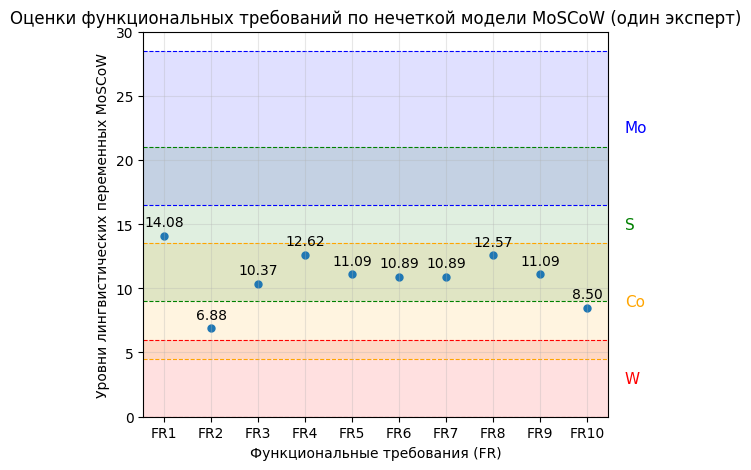

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = [r["fr"] for r in results_alpha]

# Оценки требований: берем уже вычисленные центроиды
scores = [r["centroid"] for r in results_alpha]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) - 0.2   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW (один эксперт)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

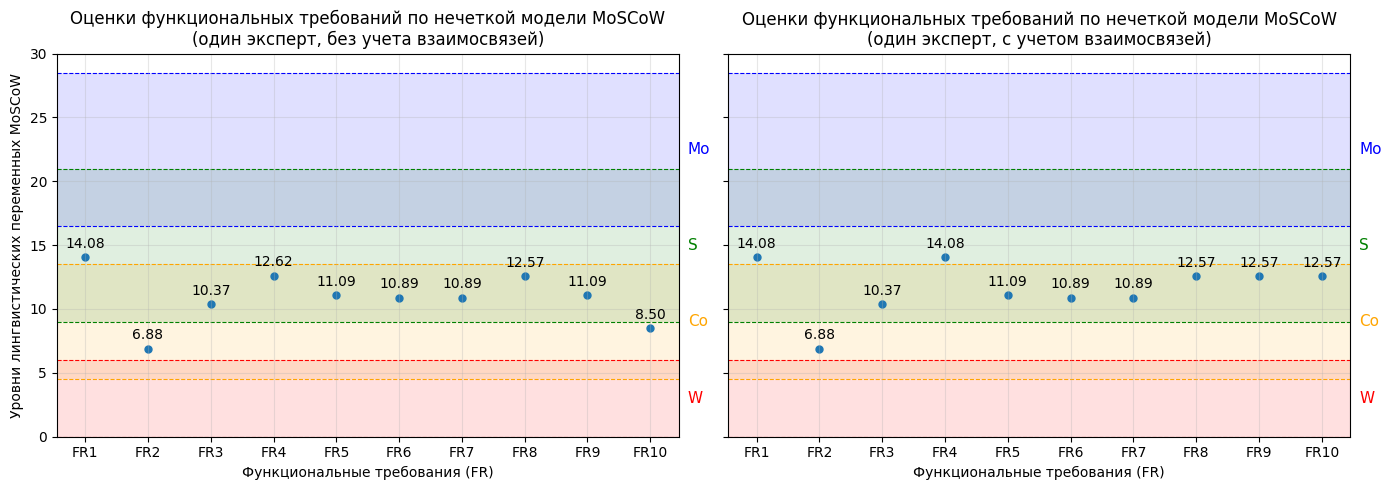

In [96]:
# Подписи функциональных требований
fr_labels = [r["fr"] for r in results_alpha]

# Исходные и скорректированные оценки требований
scores = [r["centroid"] for r in results_alpha]
adjusted_scores_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Оценки функциональных требований по нечеткой модели MoSCoW\n(один эксперт, без учета взаимосвязей)",
    "Оценки функциональных требований по нечеткой модели MoSCoW\n(один эксперт, с учетом взаимосвязей)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Нечеткий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка из файла/ в файл Excel**

In [ ]:
# Реализация нечеткого MoSCoW c произвольным количеством функциональных и нефункциональных требований требований.
# Решение принимается одним экспертом. Загрузка данных и выгрузка результатов - из файла / в файл
import re
from typing import Dict, Any, Optional, Sequence, List
import openpyxl
from openpyxl.styles import Font, Alignment

_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)


def load_single_expert_sheet(ws) -> Dict[str, Any]:
    # 1) строка заголовков NFR
    nfr_header_row = None
    nfr_cols, nfr_names = [], []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 1:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 2) строка приоритетов NFR (следующая строка)
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    # 3) шапка FR-таблицы (строка с повтором NFR1..NFRn)
    fr_header_row = None
    fr_cols = []
    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR на листе '{ws.title}'.")

    # 4) строки FR
    fr_names, fr_matrix = [], []
    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v).strip())

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "nfr_priorities": nfr_priorities,
        "fr_names": fr_names,
        "fr_vs_nfr": fr_matrix,
    }

def fuzzy_moscow_from_excel(
    in_path: str,
    out_path: Optional[str] = None,
    alpha: float = 0.8,
    source_sheet_name: Optional[str] = None,
    result_sheet_name: str = "Нечеткий MoSCoW_итог",
) -> str:
    wb = openpyxl.load_workbook(in_path)

    if source_sheet_name is None:
        source_sheet_name = wb.sheetnames[0]

    ws_in = wb[source_sheet_name]
    data = load_single_expert_sheet(ws_in)

    # расчет
    results = pfr_moscow_it2(
        data["nfr_priorities"],
        data["fr_vs_nfr"],
        fr_names=data["fr_names"],
    )

    rows = []
    for r in results:
        cut = alpha_cut(r["pfr"], alpha)                 # ((u1,u2),(l1,l2))
        mid_umf, mid_lmf = midpoints_of_alpha_cut(cut)   # (mid_umf, mid_lmf)
        avg_mid = (mid_umf + mid_lmf) / 2

        (a,b,c,d), (e,f,g,h) = r["pfr"]
        (u1,u2), (l1,l2) = cut

        rows.append({
            "FR": r["fr"],
            "umf": (a,b,c,d),
            "lmf": (e,f,g,h),
            "u_cut": (u1,u2),
            "l_cut": (l1,l2),
            "mid_umf": mid_umf,
            "mid_lmf": mid_lmf,
            "avg_mid": avg_mid,
        })

    rows_sorted = sorted(rows, key=lambda x: x["avg_mid"], reverse=True)

    # лист результата
    if result_sheet_name in wb.sheetnames:
        wb.remove(wb[result_sheet_name])
    ws_out = wb.create_sheet(result_sheet_name)

    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # alpha
    ws_out["A1"] = "альфа"
    ws_out["B1"] = alpha
    ws_out["A1"].font = bold
    ws_out["B1"].font = bold

    # объединения
    ws_out.merge_cells("A3:A4")
    ws_out.merge_cells("B3:B4")
    ws_out.merge_cells("C3:J3")
    ws_out.merge_cells("K3:N3")
    ws_out.merge_cells("O3:P3")
    ws_out.merge_cells("Q3:Q4")

    ws_out["A3"] = "Rank"
    ws_out["B3"] = "FR"
    ws_out["C3"] = "Итоговый приоритет функционального требования в виде нечеткого числа"
    ws_out["K3"] = "Дефаззификация при заданном уровне альфа-среза"
    ws_out["O3"] = "Расчет центроида"
    ws_out["Q3"] = "Центроид_итог"

    for addr in ["A3","B3","C3","K3","O3","Q3"]:
        ws_out[addr].font = bold
        ws_out[addr].alignment = center

    ws_out["C4"] = "Верхняя функция принадлежности"
    ws_out["G4"] = "Нижняя функция принадлежности"
    ws_out["K4"] = "Верхний альфа-срез"
    ws_out["M4"] = "Нижний альфа-срез"
    ws_out["O4"] = "Верхняя ФП"
    ws_out["P4"] = "Нижняя ФП"

    for addr in ["C4","G4","K4","M4","O4","P4"]:
        ws_out[addr].font = bold
        ws_out[addr].alignment = center

    # данные
    start_row = 5
    for rank, item in enumerate(rows_sorted, start=1):
        r = start_row + (rank - 1)
        ws_out.cell(r, 1).value = rank
        ws_out.cell(r, 2).value = item["FR"]

        a,b,c,d = item["umf"]
        e,f,g,h = item["lmf"]
        u1,u2 = item["u_cut"]
        l1,l2 = item["l_cut"]

        # UMF C..F
        ws_out.cell(r, 3).value = round(a, 2)
        ws_out.cell(r, 4).value = round(b, 2)
        ws_out.cell(r, 5).value = round(c, 2)
        ws_out.cell(r, 6).value = round(d, 2)

        # LMF G..J
        ws_out.cell(r, 7).value = round(e, 2)
        ws_out.cell(r, 8).value = round(f, 2)
        ws_out.cell(r, 9).value = round(g, 2)
        ws_out.cell(r,10).value = round(h, 2)

        # alpha-cuts K..N
        ws_out.cell(r,11).value = round(u1, 2)
        ws_out.cell(r,12).value = round(u2, 2)
        ws_out.cell(r,13).value = round(l1, 2)
        ws_out.cell(r,14).value = round(l2, 2)

        # centroids O..Q
        ws_out.cell(r,15).value = round(item["mid_umf"], 2)
        ws_out.cell(r,16).value = round(item["mid_lmf"], 2)
        ws_out.cell(r,17).value = round(item["avg_mid"], 2)

    # базовые ширины для просмотра
    ws_out.column_dimensions["A"].width = 10
    ws_out.column_dimensions["B"].width = 10
    for col in "CDEFGHIJ":
        ws_out.column_dimensions[col].width = 18
    for col in "KLMN":
        ws_out.column_dimensions[col].width = 16
    for col in "OPQ":
        ws_out.column_dimensions[col].width = 14

    ws_out.row_dimensions[3].height = 30
    ws_out.row_dimensions[4].height = 20

    if out_path is None:
        out_path = in_path

    wb.save(out_path)
    return out_path

In [ ]:
# пример запуска
in_file = "Загрузочные данные_MoSCoW_один эксперт.xlsx"
out_file = "Итоги_Fuzzy MoSCoW_один эксперт.xlsx"

saved_path = fuzzy_moscow_from_excel(
    in_path=in_file,
    out_path=out_file,
    alpha=0.8,
    result_sheet_name="Нечеткий MoSCoW_итог",
)

print("Saved to:", saved_path)

Saved to: Итоги_Fuzzy MoSCoW_один эксперт.xlsx


# 1.2. Четкий MoSCoW при принятии решений одним экспертом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Четкий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка в ноутбуке**

In [78]:
# Реализация четкого MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Загрузка в виде списка параметров в строке кода
from typing import List, Sequence, Dict, Any

MOSCOW_NFR_WEIGHTS = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}

def pfr_moscow_ranked(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn)
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # список FR, каждый FR имеет длину = n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    # Имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Веса NFR
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_triplet in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_triplet) != n:
            raise ValueError(
                f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_triplet)}."
            )

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_triplet]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W")

        pfr = sum(w_nfr * w_fr for w_nfr, w_fr in zip(nfr_w, fr_w))

        results.append({
            "fr": name,
            "pfr": pfr,
            "ratings": list(fr_triplet),
        })

    # сортировка по убыванию PFR (при равенстве - сохраняем исходный порядок)
    results_sorted = sorted(results, key=lambda x: x["pfr"], reverse=True)
    return results_sorted


In [79]:
# пример: n = 3 NFR
NFR = ["Mo", "Co", "S"]  # NFR1=Mo, NFR2=Co, NFR3=S

# 10 FR (произвольное число)
FRs = [
    ["Mo", "S",  "Mo"],   # FR1: (FR1_NFR1, FR1_NFR2, FR1_NFR3)
    ["Co", "Co",  "S"],   # FR2
    ["S",  "S", "S" ],    # FR3
    ["Mo",  "S", "S" ],   # FR4
    ["S",  "Mo", "S" ],   # FR5
    ["Mo",  "S", "Co" ],  # FR6
    ["Mo",  "S", "Co" ],  # FR7
    ["S",  "Mo", "Mo" ],  # FR8
    ["S",  "Mo", "S" ],   # FR9
    ["Co",  "Mo", "S" ],   # FR10
]

ranked = pfr_moscow_ranked(NFR, FRs)

for item in ranked:
    print(f"{item['fr']}: PFR = {round(item['pfr'], 2)}")

FR1: PFR = 14.15
FR4: PFR = 12.45
FR8: PFR = 12.45
FR6: PFR = 10.8
FR7: PFR = 10.8
FR5: PFR = 10.75
FR9: PFR = 10.75
FR3: PFR = 9.9
FR10: PFR = 8.28
FR2: PFR = 6.6


Алгоритм учета взаимосвязанности функциональных требований

In [80]:
def adjust_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый ранжированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        # "FR1" -> 0, "FR10" -> 9
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    # Проверим, что все FR корректно покрывают матрицу
    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    # Копия списка + исходный ранг
    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_pfr"] = item["pfr"]
        adjusted.append(new_item)

    # Быстрый доступ: индекс FR в матрице -> элемент ranked_list
    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    # Поиск связанных компонент по матрице в исходной нумерации FR
    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    # В каждой связанной группе выравниваем по максимуму pfr
    for comp in components:
        max_pfr = max(matrix_idx_to_item[i]["pfr"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_pfr"] = max_pfr

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_pfr"], x["original_rank"])
    )

    return adjusted_sorted


Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [81]:
# Матрица взаимосвязей 10x10
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_ranked = adjust_ranked_by_interdependencies(ranked, relation_matrix)

print("\nСкорректированный ранжированный список:")
for item in adjusted_ranked:
    print(
        f"{item['fr']}: "
        f"исходный PFR = {round(item['pfr'], 2)}, "
        f"скорректированный PFR = {round(item['adjusted_pfr'], 2)}"
    )


Скорректированный ранжированный список:
FR1: исходный PFR = 14.15, скорректированный PFR = 14.15
FR4: исходный PFR = 12.45, скорректированный PFR = 14.15
FR8: исходный PFR = 12.45, скорректированный PFR = 12.45
FR9: исходный PFR = 10.75, скорректированный PFR = 12.45
FR10: исходный PFR = 8.28, скорректированный PFR = 12.45
FR6: исходный PFR = 10.8, скорректированный PFR = 10.8
FR7: исходный PFR = 10.8, скорректированный PFR = 10.8
FR5: исходный PFR = 10.75, скорректированный PFR = 10.75
FR3: исходный PFR = 9.9, скорректированный PFR = 9.9
FR2: исходный PFR = 6.6, скорректированный PFR = 6.6


Визуализации исходного и итогового приоритизированного списков функциональных требований

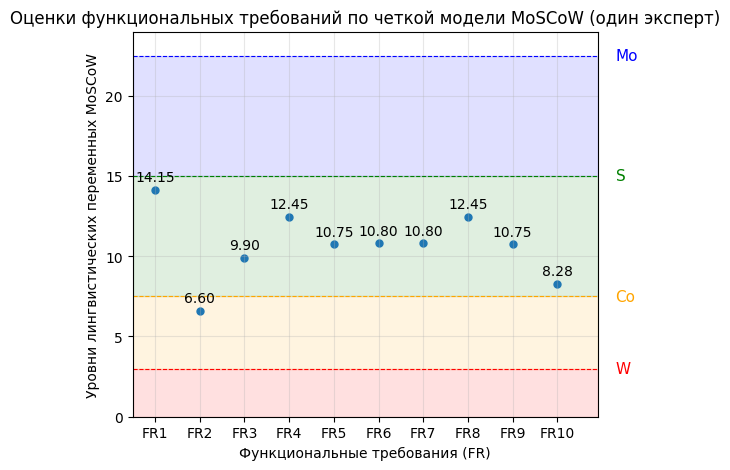

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Преобразуем результаты в словарь: {FR: pfr}
pfr_by_fr = {item["fr"]: item["pfr"] for item in ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [pfr_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW (один эксперт)")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

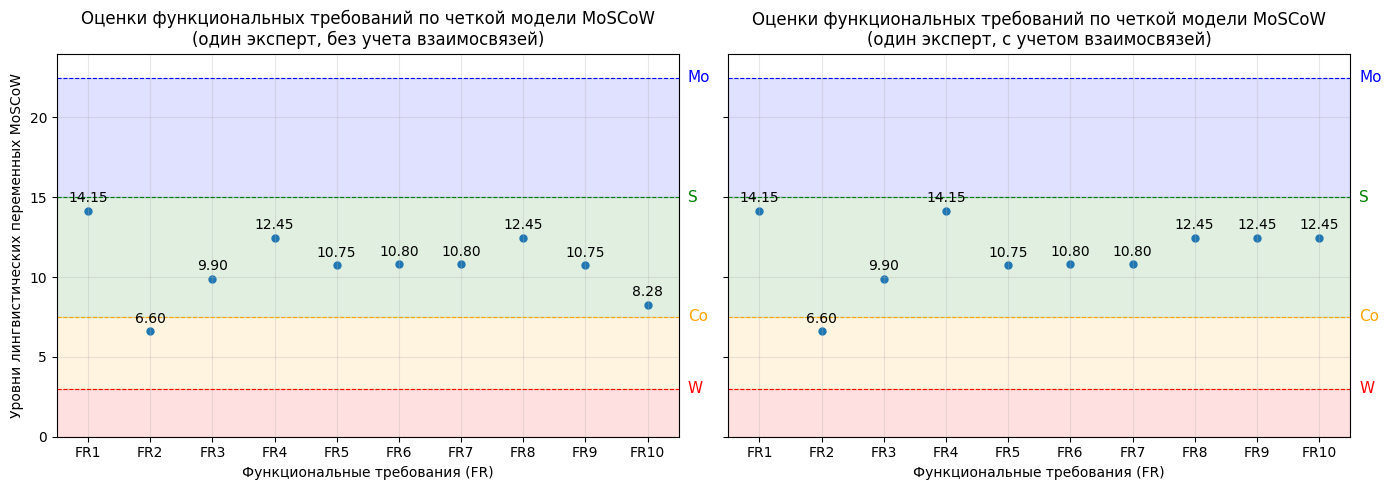

In [82]:
# Преобразуем результаты в словари: {FR: pfr} и {FR: adjusted_pfr}
pfr_by_fr = {item["fr"]: item["pfr"] for item in ranked}
adjusted_pfr_by_fr = {item["fr"]: item["adjusted_pfr"] for item in adjusted_ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [pfr_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_pfr_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Оценки функциональных требований по четкой модели MoSCoW\n(один эксперт, без учета взаимосвязей)",
    "Оценки функциональных требований по четкой модели MoSCoW\n(один эксперт, с учетом взаимосвязей)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    # Настройки осей
    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 24)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с оценками одного эксперта. Загрузка и выгрузка из файла/ в файл Excel**

In [ ]:
# Реализация четкого MoSCoW c произвольным количеством функциональных и нефункциональных требований требований.
# Загрузка и выгрузка - в файл Excel.
import re
from typing import Sequence, List, Dict, Any, Optional
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# Веса четкого MoSCoW
MOSCOW_NFR_WEIGHTS = {"MO": 7.5, "S": 5.0, "CO": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS = {"MO": 1.0, "S": 0.66, "CO": 0.33, "W": 0.0}


def normalize_moscow_label(x: Any) -> str:
    if x is None:
        raise ValueError("Обнаружено пустое значение приоритета.")
    s = str(x).strip()
    s_upper = s.upper()

    # Приведение распространенных вариантов
    if s_upper in {"MO", "M0"}:
        return "MO"
    if s_upper == "CO":
        return "CO"
    if s_upper == "S":
        return "S"
    if s_upper == "W":
        return "W"

    raise ValueError(f"Недопустимое значение приоритета: '{s}'. Допустимо: Mo, S, Co, W")


def load_moscow_from_excel(xlsx_path: str, sheet_name: Optional[str] = None) -> Dict[str, Any]:
    wb = openpyxl.load_workbook(xlsx_path, data_only=True)

    # Если лист не указан - берем первый
    if sheet_name is None:
        sheet_name = wb.sheetnames[0]

    # Если пользователь указал неверный лист - выдается ошибка
    if sheet_name not in wb.sheetnames:
        raise ValueError(
            f"Лист '{sheet_name}' не найден.\n"
            f"Доступные листы: {wb.sheetnames}\n"
            f"Подсказка: в файле лист называется иначе."
        )

    ws = wb[sheet_name]
    rows = [list(r) for r in ws.iter_rows(values_only=True)]

    nfr_pat = re.compile(r"^NFR\d+$", re.IGNORECASE)

    # 1) Находим строку заголовков NFR (где встречаются NFR1, NFR2, ...)
    nfr_header_idx = None
    nfr_names, nfr_cols = [], []

    for i, row in enumerate(rows):
        cols = [j for j, v in enumerate(row) if isinstance(v, str) and nfr_pat.match(v.strip())]
        if len(cols) >= 2:  # минимум 2 NFR -> считаем, что это нужная строка
            start = min(cols)
            tmp_names, tmp_cols = [], []
            for j in range(start, len(row)):
                v = row[j]
                if isinstance(v, str) and nfr_pat.match(v.strip()):
                    tmp_names.append(v.strip())
                    tmp_cols.append(j)
                else:
                    if tmp_names:
                        break
            # фиксируем первый найденный блок NFR
            nfr_names = tmp_names
            nfr_cols = tmp_cols
            nfr_header_idx = i
            break

    if nfr_header_idx is None:
        raise ValueError("Не удалось найти строку заголовков NFR (ожидались NFR1, NFR2, ...).")

    # 2) Находим строку с приоритетами NFR (ищем ближайшую ниже со словом 'приоритет', иначе берем следующую)
    nfr_priority_idx = None
    for k in range(nfr_header_idx + 1, min(nfr_header_idx + 8, len(rows))):
        left_cell = rows[k][0] if len(rows[k]) > 0 else None
        if isinstance(left_cell, str) and "приоритет" in left_cell.lower():
            nfr_priority_idx = k
            break
    if nfr_priority_idx is None:
        nfr_priority_idx = nfr_header_idx + 1

    nfr_priorities = []
    for j in nfr_cols:
        val = rows[nfr_priority_idx][j] if j < len(rows[nfr_priority_idx]) else None
        if val is None or str(val).strip() == "":
            raise ValueError(f"Пустой приоритет NFR в строке {nfr_priority_idx+1}, колонке {j+1}.")
        nfr_priorities.append(normalize_moscow_label(val))

    # 3) Находим первую строку FR (FR1/FR2/...)
    fr_first_idx = None
    for i, row in enumerate(rows):
        v = row[0] if len(row) > 0 else None
        if isinstance(v, str) and re.match(r"^FR\d+(\b|$)", v.strip(), re.IGNORECASE):
            fr_first_idx = i
            break
    if fr_first_idx is None:
        raise ValueError("Не удалось найти строки FR (ожидались FR1, FR2, ... в первом столбце).")

    # 4) Определяем строку заголовков NFR над таблицей FR (обычно строка над FR1)
    fr_header_idx = None
    for i in range(fr_first_idx - 1, -1, -1):
        row = rows[i]
        found = [v.strip() for v in row if isinstance(v, str) and v.strip() in nfr_names]
        if len(found) >= max(1, len(nfr_names) - 1):
            fr_header_idx = i
            break

    if fr_header_idx is not None:
        col_map = {}
        for j, v in enumerate(rows[fr_header_idx]):
            if isinstance(v, str) and v.strip() in nfr_names:
                col_map[v.strip()] = j
        try:
            fr_cols = [col_map[name] for name in nfr_names]
        except KeyError:
            # переход на верхний блок
            fr_cols = nfr_cols
    else:
        fr_cols = nfr_cols

    # 5) Читаем FR-строки
    fr_names, fr_matrix = [], []
    for i in range(fr_first_idx, len(rows)):
        if len(rows[i]) == 0:
            continue

        name_cell = rows[i][0]
        if name_cell is None:
            continue

        name = str(name_cell).strip()
        if not name:
            continue

        # Берем только строки FR...
        if not re.match(r"^FR\d+(\b|$)", name, re.IGNORECASE):
            # если после блока FR пошли другие строки - пропускаем
            continue

        vals = []
        for j in fr_cols:
            v = rows[i][j] if j < len(rows[i]) else None
            vals.append("" if v is None else str(v).strip())

        # пропускаем строки, где нет оценок
        if all(v == "" for v in vals):
            continue

        fr_names.append(name)
        fr_matrix.append([normalize_moscow_label(v) for v in vals])

    if not fr_names:
        raise ValueError("Не удалось прочитать строки FR с оценками.")

    return {
        "sheet": sheet_name,
        "nfr_names": nfr_names,
        "nfr_priorities": nfr_priorities,   # уже нормализованы: Mо/S/Cо/W
        "fr_names": fr_names,
        "fr_vs_nfr": fr_matrix,             # уже нормализованы: Mо/S/Cо/W
    }


def pfr_moscow_ranked_df(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str]
) -> pd.DataFrame:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("fr_names должен совпадать по длине с количеством FR.")

    # веса NFR
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[normalize_moscow_label(x)] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в NFR: {e}. Допустимо: Mo, S, Co, W")

    rows_out = []
    for name, ratings in zip(fr_names, fr_vs_nfr_priorities):
        if len(ratings) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(ratings)}.")

        try:
            ratings_norm = [normalize_moscow_label(x) for x in ratings]
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in ratings_norm]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимая оценка {e}. Допустимо: Mo, S, Co, W")

        pfr = sum(a * b for a, b in zip(nfr_w, fr_w))

        # Для вывода вернем обозначения в привычном виде
        def pretty_label(z: str) -> str:
            return {"MO": "Mo", "CO": "Co", "S": "S", "W": "W"}[z]

        row = {"FR": name, "PFR": float(pfr)}
        for i in range(n):
            row[f"NFR{i+1}"] = pretty_label(ratings_norm[i])
        rows_out.append(row)

    df = pd.DataFrame(rows_out)
    df = df.sort_values(["PFR", "FR"], ascending=[False, True], kind="mergesort").reset_index(drop=True)
    return df


def autosize_columns(ws, min_width: int = 12, max_width: int = 40):
    for col_cells in ws.columns:
        col_idx = col_cells[0].column
        max_len = 0
        for c in col_cells:
            v = c.value
            txt = "" if v is None else str(v)
            max_len = max(max_len, len(txt))
        ws.column_dimensions[get_column_letter(col_idx)].width = max(min_width, min(max_len + 2, max_width))


def write_summary_sheet(
    wb: openpyxl.Workbook,
    loaded: Dict[str, Any],
    df_ranked: pd.DataFrame,
    sheet_name: str = "Четкий MoSCoW_итог"
):
    # Если лист уже есть - удаляем и создаем заново
    if sheet_name in wb.sheetnames:
        del wb[sheet_name]
    ws = wb.create_sheet(title=sheet_name)

    # Стили
    header_font = Font(bold=True)
    title_font = Font(bold=True, size=12)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)
    left = Alignment(horizontal="left", vertical="center", wrap_text=True)

    r = 1

    # Заголовок
    ws.cell(r, 1, "Четкий MoSCoW — итоговая приоритизация (один эксперт)").font = title_font
    ws.cell(r, 1).alignment = left
    r += 2

    # Блок NFR
    ws.cell(r, 1, "1) Нефункциональные требования (NFR) и их веса").font = header_font
    ws.cell(r, 1).alignment = left
    r += 1

    nfr_names = loaded["nfr_names"]
    nfr_priorities = loaded["nfr_priorities"]

    ws.cell(r, 1, "NFR").font = header_font
    ws.cell(r, 2, "Приоритет NFR").font = header_font
    ws.cell(r, 3, "Вес NFR").font = header_font
    for c in range(1, 4):
        ws.cell(r, c).alignment = center
    r += 1

    pretty = {"MO": "Mo", "CO": "Co", "S": "S", "W": "W"}

    for name, pr in zip(nfr_names, nfr_priorities):
        ws.cell(r, 1, name)
        ws.cell(r, 2, pretty[pr])
        ws.cell(r, 3, float(MOSCOW_NFR_WEIGHTS[pr]))
        ws.cell(r, 1).alignment = left
        ws.cell(r, 2).alignment = center
        ws.cell(r, 3).alignment = center
        r += 1

    r += 1

    # Блок исходных оценок FR и расчета PFR
    ws.cell(r, 1, "2) Расчет PFR по функциональным требованиям (FR)").font = header_font
    ws.cell(r, 1).alignment = left
    r += 1

    # Заголовки
    ws.cell(r, 1, "FR").font = header_font
    ws.cell(r, 1).alignment = center
    for i, nfr in enumerate(nfr_names, start=2):
        ws.cell(r, i, nfr).font = header_font
        ws.cell(r, i).alignment = center
    pfr_col = 2 + len(nfr_names)
    ws.cell(r, pfr_col, "PFR").font = header_font
    ws.cell(r, pfr_col).alignment = center
    r += 1

    # Строки FR в исходном порядке
    pfr_map = {row["FR"]: float(row["PFR"]) for _, row in df_ranked.iterrows()}
    fr_names = loaded["fr_names"]
    fr_matrix = loaded["fr_vs_nfr"]

    for fr_name, ratings in zip(fr_names, fr_matrix):
        ws.cell(r, 1, fr_name)
        ws.cell(r, 1).alignment = left
        for i, val in enumerate(ratings, start=2):
            ws.cell(r, i, pretty[val])
            ws.cell(r, i).alignment = center
        ws.cell(r, pfr_col, pfr_map[fr_name])
        ws.cell(r, pfr_col).alignment = center
        r += 1

    r += 1

    # Блок итогового ранжирования
    ws.cell(r, 1, "3) Итоговая сортировка FR по убыванию PFR").font = header_font
    ws.cell(r, 1).alignment = left
    r += 1

    ws.cell(r, 1, "Место").font = header_font
    ws.cell(r, 2, "FR").font = header_font
    ws.cell(r, 3, "PFR").font = header_font
    for c in range(1, 4):
        ws.cell(r, c).alignment = center
    r += 1

    for idx, (_, row_df) in enumerate(df_ranked.iterrows(), start=1):
        ws.cell(r, 1, idx)
        ws.cell(r, 2, row_df["FR"])
        ws.cell(r, 3, float(row_df["PFR"]))
        ws.cell(r, 1).alignment = center
        ws.cell(r, 2).alignment = left
        ws.cell(r, 3).alignment = center
        r += 1

    # Форматирование чисел: два знака после запятой
    for row in ws.iter_rows():
        for cell in row:
            if isinstance(cell.value, (int, float)):
                cell.number_format = "0.00"

    # Автоширина
    autosize_columns(ws)

    return ws

def run_moscow_one_expert_excel(
    input_xlsx_path: str,
    output_xlsx_path: str = "Итоги_четкий MoSCoW_один эксперт.xlsx",
    input_sheet_name: Optional[str] = None
) -> pd.DataFrame:
    # Загрузка и расчет
    loaded = load_moscow_from_excel(input_xlsx_path, sheet_name=input_sheet_name)
    df_ranked = pfr_moscow_ranked_df(
        nfr_priorities=loaded["nfr_priorities"],
        fr_vs_nfr_priorities=loaded["fr_vs_nfr"],
        fr_names=loaded["fr_names"],
    )

    # Открываем исходный файл как книгу, чтобы сохранить первоначальный лист
    wb = openpyxl.load_workbook(input_xlsx_path)

    # Добавляем лист итогов
    write_summary_sheet(wb, loaded, df_ranked, sheet_name="Четкий MoSCoW_итог")

    # Сохраняем в новый файл
    wb.save(output_xlsx_path)

    return df_ranked


In [ ]:
# Запуск

xlsx_path = "Загрузочные данные_MoSCoW_один эксперт.xlsx"

df_ranked = run_moscow_one_expert_excel(
    input_xlsx_path=xlsx_path,
    output_xlsx_path = "Итоги_четкий MoSCoW_один эксперт.xlsx",
    input_sheet_name=None
)

print("Топ-10 FR по PFR:")
print(df_ranked[["FR", "PFR"]].head(10))

print("\nФайл сохранен: Итоги_четкий MoSCoW_один эксперт.xlsx")

Топ-10 FR по PFR:
     FR     PFR
0   FR1  14.150
1   FR4  12.450
2   FR8  12.450
3   FR6  10.800
4   FR7  10.800
5   FR5  10.750
6   FR9  10.750
7   FR3   9.900
8  FR10   8.275
9   FR2   6.600

Файл сохранен: Итоги_четкий MoSCoW_один эксперт.xlsx


# 2 Приоритизация требований по методу MoSCoW при коллективном принятии решений

# 2.1. Коллективное принятие решений методом взвешенной средней

# 2.1.1. Fuzzy_MoSCoW + групповая оценка методом взвешенной средней

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [97]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [98]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [99]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [100]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [101]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [102]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [103]:
# Нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задаем нечеткие веса (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразуем NFR-термы в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразуем FR_NFR термы в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FRvsNFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results


In [104]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов, итоговая оценка вычисляется методом взвешенной средней.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация

from typing import List, Sequence, Dict, Any, Tuple

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]

def group_pfr_moscow_it2_k_experts(
    experts: Sequence[Dict[str, Any]],
    expert_weights: Sequence[float],           # четкие ненормализованные веса W_Si
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,            # добавили флаг
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights):
        raise ValueError("Длины experts и expert_weights должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов (фиксируем один раз)
    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]

    # веса: raw - norm
    w_raw = [float(x) for x in expert_weights]
    if normalize_weights:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов экспертов = 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_raw_by_expert = {expert_names[i]: w_raw[i] for i in range(len(experts))}
    w_norm_by_expert = {expert_names[i]: w_norm[i] for i in range(len(experts))}

    # 1) вычисление нечетких PFR каждого эксперта
    per_expert_results: Dict[str, Dict[str, IT2]] = {}
    for e, name in zip(experts, expert_names):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        per_expert_results[name] = {item["fr"]: item["pfr"] for item in res}

    # 2) агрегация: sum( w_i_norm * PFR_i )
    out: List[Dict[str, Any]] = []

    for fr in fr_names:
        pfr_group: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        pfr_by_expert: Dict[str, IT2] = {}

        for name, wi_norm in zip(expert_names, w_norm):
            pfr_e = per_expert_results[name][fr]
            pfr_by_expert[name] = pfr_e

            # умножение IT2 на константу (вес эксперта)
            weighted = multiply_fuzzy_number_by_constant(pfr_e, wi_norm)
            pfr_group = add_intuitionistic_trapezoidal_fuzzy_numbers(pfr_group, weighted)

        out.append({
            "fr": fr,
            "pfr_group": pfr_group,
            "pfr_by_expert": pfr_by_expert,
            "w_raw_by_expert": w_raw_by_expert,
            "w_norm_by_expert": w_norm_by_expert,
        })

    return out

In [105]:
# Пример для группы из трех экспертов
# Ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S", "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S", "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

group_results = group_pfr_moscow_it2_k_experts(
    experts=experts,
    expert_weights=weights,
    normalize_weights=True
)

# пример печати весов
print("Weights raw:", group_results[0]["w_raw_by_expert"])
print("Weights norm:", group_results[0]["w_norm_by_expert"])

# пример печати нечеткого группового результата
for r in group_results:
    print(r["fr"], r["pfr_group"])


Weights raw: {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
Weights norm: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}
FR1 ((5.22, 10.72, 14.71, 19.93), (6.76, 10.72, 14.71, 18.21))
FR2 ((0.94, 4.45, 9.4, 14.4), (1.54, 4.45, 9.4, 12.81))
FR3 ((5.31, 10.01, 14.92, 21.71), (6.76, 10.01, 14.92, 19.4))
FR4 ((4.42, 9.12, 13.64, 19.28), (5.67, 9.12, 13.64, 17.41))
FR5 ((4.54, 9.36, 14.07, 20.18), (5.92, 9.36, 14.07, 18.13))
FR6 ((3.65, 8.06, 12.42, 17.51), (4.69, 8.06, 12.42, 15.85))
FR7 ((4.07, 8.68, 13.09, 18.39), (5.22, 8.68, 13.09, 16.65))
FR8 ((4.63, 9.71, 14.04, 19.51), (6.0, 9.71, 14.04, 17.69))
FR9 ((3.86, 8.66, 13.27, 18.94), (5.15, 8.66, 13.27, 17.07))
FR10 ((3.85, 8.63, 13.15, 18.61), (5.12, 8.63, 13.15, 16.81))


In [106]:
# Применяем оператор согласованной линейной редукции типов ко всему списку нечетких групповых приоритетов
a = 0.6

results_reduction = []
for r in group_results:
    reduced = cltr_type_reduction(r["pfr_group"], a)
    results_reduction.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_group"],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (6.14, 10.72, 14.71, 18.9)
FR2: a=0.6, (1.3, 4.45, 9.4, 13.45)
FR3: a=0.6, (6.18, 10.01, 14.92, 20.32)
FR4: a=0.6, (5.17, 9.12, 13.64, 18.16)
FR5: a=0.6, (5.37, 9.36, 14.07, 18.95)
FR6: a=0.6, (4.27, 8.06, 12.42, 16.51)
FR7: a=0.6, (4.76, 8.68, 13.09, 17.35)
FR8: a=0.6, (5.45, 9.71, 14.04, 18.42)
FR9: a=0.6, (4.63, 8.66, 13.27, 17.82)
FR10: a=0.6, (4.61, 8.63, 13.15, 17.53)


In [107]:
# Применяем альфа-срез ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (9.8; 15.55)
FR2: альфа=0.8, (3.82; 10.21)
FR3: альфа=0.8, (9.24; 16.0)
FR4: альфа=0.8, (8.33; 14.54)
FR5: альфа=0.8, (8.56; 15.05)
FR6: альфа=0.8, (7.3; 13.24)
FR7: альфа=0.8, (7.9; 13.94)
FR8: альфа=0.8, (8.86; 14.92)
FR9: альфа=0.8, (7.85; 14.18)
FR10: альфа=0.8, (7.83; 14.03)


In [108]:
# Вычисляем центроид для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=12.68
2. FR3: centroid=12.62
3. FR8: centroid=11.89
4. FR5: centroid=11.8
5. FR4: centroid=11.43
6. FR9: centroid=11.02
7. FR10: centroid=10.93
8. FR7: centroid=10.92
9. FR6: centroid=10.27
10. FR2: centroid=7.02


Алгоритм учета взаимосвязанности функциональных требований

In [109]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый дефаззифицированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [110]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,0,0],
    [1,0,0,1,0,0,0,0,0,0],
    [0,0,0,0,1,0,0,0,0,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,0,0,0,0,1,1,0,0,0],
    [0,0,0,0,0,0,0,1,1,1],
    [0,0,0,0,0,0,0,1,1,1],
    [0,0,0,0,0,0,0,1,1,1],
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=12.68, скорректированный centroid=12.68
2. FR4: исходный centroid=11.43, скорректированный centroid=12.68
3. FR3: исходный centroid=12.62, скорректированный centroid=12.62
4. FR8: исходный centroid=11.89, скорректированный centroid=11.89
5. FR9: исходный centroid=11.02, скорректированный centroid=11.89
6. FR10: исходный centroid=10.93, скорректированный centroid=11.89
7. FR5: исходный centroid=11.80, скорректированный centroid=11.80
8. FR7: исходный centroid=10.92, скорректированный centroid=10.92
9. FR6: исходный centroid=10.27, скорректированный centroid=10.92
10. FR2: исходный centroid=7.02, скорректированный centroid=7.02


Визуализации исходного и итогового приоритизированного списков функциональных требований

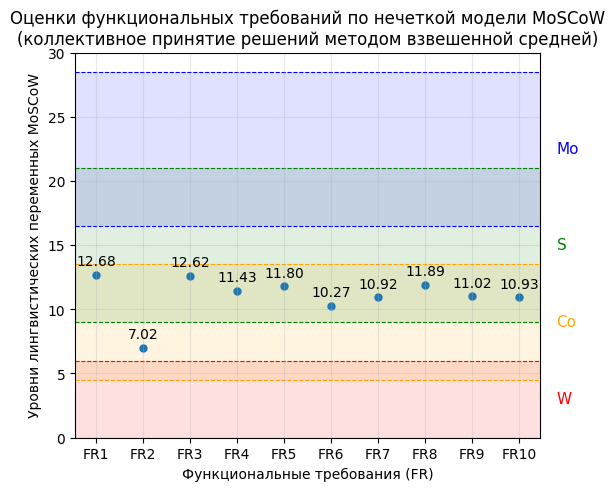

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Преобразуем результаты в словарь: {FR: centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) - 0.2   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW\n(коллективное принятие решений методом взвешенной средней)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

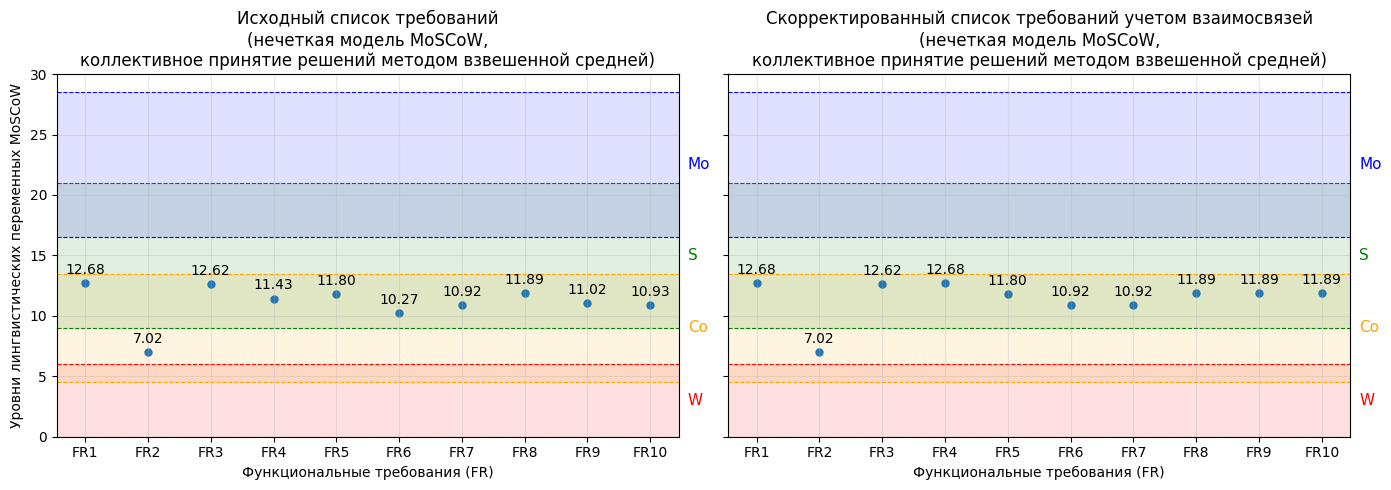

In [113]:
# Преобразуем результаты в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)",
    "Скорректированный список требований учетом взаимосвязей\n(нечеткая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [ ]:
# Нечеткий метод приоритизации MoSCoW для произвольного числа функциональных и нефункциональных требований.
# Решение принимается группой из произвольного числа экспертов, итоговая оценка вычисляется методом взвешенной средней.
# Веса экспертов четкие, изначально ненормализованные, в процессе реализации алгоритма выполняется их нормализация.
# Загрузка данных и выгрузка результатов - из файла / в файл

import re
from typing import Dict, Any, Sequence, Optional, List, Tuple
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# Задаем нечеткие веса (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 1) Загрузка листа эксперта

_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat  = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    # 1) ищем строку заголовков NFR (где есть минимум 2 NFRx)
    nfr_header_row = None
    nfr_cols: List[int] = []
    nfr_names: List[str] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1)
                if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 2) строка приоритетов NFR - следующая
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    # 3) шапка таблицы FR: строка, где встречаются все NFR1..NFRn
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 4) строки FR
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v).strip())

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "sheet_name": ws.title,
        "nfr": nfr_priorities,     # важно: это приоритеты NFR в термах Mo/S/Co/W
        "fr_names": fr_names,
        "frs": fr_matrix
    }

# 2) Групповая нечеткая оценка (четкие веса raw и norm)

def group_pfr_moscow_it2_k_experts(
    experts: Sequence[Dict[str, Any]],
    expert_weights: Sequence[float],
    fr_names: Sequence[str],
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights):
        raise ValueError("Длины experts и expert_weights должны совпадать.")

    expert_names = [e["name"] for e in experts]
    w_raw = [float(x) for x in expert_weights]

    if normalize_weights:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов = 0 — невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    # 1) PFR каждого эксперта (IT2)
    per_expert_pfr: Dict[str, Dict[str, IT2]] = {}
    for e in experts:
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)
        per_expert_pfr[e["name"]] = {item["fr"]: item["pfr"] for item in res}

    # 2) группа: сумма (PFR_e * w_norm_e)
    group_pfr: Dict[str, IT2] = {}
    for fr in fr_names:
        acc: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for name, wi in zip(expert_names, w_norm):
            weighted = multiply_fuzzy_number_by_constant(per_expert_pfr[name][fr], wi)
            acc = add_intuitionistic_trapezoidal_fuzzy_numbers(acc, weighted)
        group_pfr[fr] = acc

    return {
        "expert_names": expert_names,
        "weights_raw": w_raw,
        "weights_norm": w_norm,
        "per_expert_pfr": per_expert_pfr,
        "group_pfr": group_pfr,
    }

# 3) Подготовка строк таблицы (IT2 + alpha-cut + centroids + avg_mid) + сортировка

def build_defuzz_rows(pfr_by_fr: Dict[str, IT2], alpha: float) -> List[Dict[str, Any]]:
    rows = []
    for fr, it2 in pfr_by_fr.items():
        cut = alpha_cut(it2, alpha)                  # ((u1,u2),(l1,l2))
        mid_umf, mid_lmf = midpoints_of_alpha_cut(cut)
        avg_mid = round((mid_umf + mid_lmf) / 2, 2)

        (a,b,c,d), (e,f,g,h) = it2
        (u1,u2), (l1,l2) = cut

        rows.append({
            "FR": fr,
            "umf": (a,b,c,d),
            "lmf": (e,f,g,h),
            "u_cut": (u1,u2),
            "l_cut": (l1,l2),
            "mid_umf": mid_umf,
            "mid_lmf": mid_lmf,
            "avg_mid": avg_mid,
        })

    return sorted(rows, key=lambda x: x["avg_mid"], reverse=True)

# 4) Выгрузка: таблица весов + alpha + блоки экспертов + итог группы

def _set_col_width(ws, col_idx: int, width: float):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

def write_result_table(ws, start_row: int, title: str, alpha: float, rows_sorted: List[Dict[str, Any]]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # заголовки
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=17)
    c = ws.cell(start_row, 1)
    c.value = title
    c.font = bold
    c.alignment = center

    r1, r2 = start_row + 1, start_row + 2

    # объединения
    ws.merge_cells(start_row=r1, start_column=1, end_row=r2, end_column=1)     # Rank
    ws.merge_cells(start_row=r1, start_column=2, end_row=r2, end_column=2)     # FR
    ws.merge_cells(start_row=r1, start_column=3, end_row=r1, end_column=10)    # IT2
    ws.merge_cells(start_row=r1, start_column=11, end_row=r1, end_column=14)   # alpha cut
    ws.merge_cells(start_row=r1, start_column=15, end_row=r1, end_column=16)   # centroids
    ws.merge_cells(start_row=r1, start_column=17, end_row=r2, end_column=17)   # avg

    ws.cell(r1,1).value = "Rank"
    ws.cell(r1,2).value = "FR"
    ws.cell(r1,3).value = "PFR_IT2"
    ws.cell(r1,11).value = f"alpha-cut ({alpha})"
    ws.cell(r1,15).value = "Centroids"
    ws.cell(r1,17).value = "avg_mid"

    for col in [1,2,3,11,15,17]:
        ws.cell(r1,col).font = bold
        ws.cell(r1,col).alignment = center

    ws.cell(r2,3).value  = "UMF (a,b,c,d)"
    ws.cell(r2,7).value  = "LMF (e,f,g,h)"
    ws.cell(r2,11).value = "UMF [u1,u2]"
    ws.cell(r2,13).value = "LMF [l1,l2]"
    ws.cell(r2,15).value = "mid_UMF"
    ws.cell(r2,16).value = "mid_LMF"

    for col in [3,7,11,13,15,16]:
        ws.cell(r2,col).font = bold
        ws.cell(r2,col).alignment = center

    # данные
    data_start = start_row + 3
    for i, item in enumerate(rows_sorted, start=1):
        rr = data_start + (i - 1)
        ws.cell(rr,1).value = i
        ws.cell(rr,2).value = item["FR"]

        (a,b,c,d) = item["umf"]
        (e,f,g,h) = item["lmf"]
        (u1,u2) = item["u_cut"]
        (l1,l2) = item["l_cut"]

        # UMF
        for j, val in enumerate([a,b,c,d], start=3):
            ws.cell(rr,j).value = round(val, 2)
        # LMF
        for j, val in enumerate([e,f,g,h], start=7):
            ws.cell(rr,j).value = round(val, 2)
        # альфа-срезы
        ws.cell(rr,11).value = round(u1, 2)
        ws.cell(rr,12).value = round(u2, 2)
        ws.cell(rr,13).value = round(l1, 2)
        ws.cell(rr,14).value = round(l2, 2)
        # центроиды и итоговая средняя
        ws.cell(rr,15).value = round(item["mid_umf"], 2)
        ws.cell(rr,16).value = round(item["mid_lmf"], 2)
        ws.cell(rr,17).value = round(item["avg_mid"], 2)

    # ширина
    _set_col_width(ws, 1, 25.29)  # Rank
    _set_col_width(ws, 2, 14)     # FR
    for col in range(3, 15):
        _set_col_width(ws, col, 18)
    _set_col_width(ws, 15, 14)
    _set_col_width(ws, 16, 14)
    _set_col_width(ws, 17, 14)

    return data_start + len(rows_sorted) + 2


def fuzzy_group_moscow_from_excel(
    in_path: str,
    out_path: Optional[str] = None,
    weights: Optional[Sequence[float]] = None,      # raw веса (в порядке листов-экспертов)
    alpha: float = 0.8,
    result_sheet_name: str = "Нечеткий MoSCoW_коллектив",
    normalize_weights: bool = True,
    skip_result_sheet: bool = True,
    skip_sheets_without_nfr: bool = True,
) -> str:
    wb = openpyxl.load_workbook(in_path)

    experts_loaded: List[Dict[str, Any]] = []
    skipped: List[str] = []

    for sname in wb.sheetnames:
        if skip_result_sheet and sname == result_sheet_name:
            continue

        ws = wb[sname]
        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            if skip_sheets_without_nfr and "Не найдена строка заголовков NFR" in str(e):
                skipped.append(sname)
                continue
            raise

        experts_loaded.append({
            "name": data["sheet_name"],
            "nfr": data["nfr"],
            "fr_names": data["fr_names"],
            "frs": data["frs"],
        })

    if not experts_loaded:
        raise ValueError(f"Не найдено листов-экспертов с NFR-шапкой. Пропущено: {skipped}")

    # проверки FR одинаковые у всех
    base_fr_names = experts_loaded[0]["fr_names"]
    for e in experts_loaded[1:]:
        if e["fr_names"] != base_fr_names:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")

    k = len(experts_loaded)

    # начальные веса
    if weights is None:
        weights_raw = [1.0] * k
    else:
        if len(weights) != k:
            raise ValueError(f"weights должен быть длины {k} (по числу экспертов/листов).")
        weights_raw = list(weights)

    # групповая агрегация (raw и norm внутри)
    group_pack = group_pfr_moscow_it2_k_experts(
        experts=experts_loaded,
        expert_weights=weights_raw,
        fr_names=base_fr_names,
        normalize_weights=normalize_weights,
    )

    expert_names = group_pack["expert_names"]
    w_raw = group_pack["weights_raw"]
    w_norm = group_pack["weights_norm"]

    # пересоздаем лист результата
    if result_sheet_name in wb.sheetnames:
        wb.remove(wb[result_sheet_name])
    ws_out = wb.create_sheet(result_sheet_name)

    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    # 1. таблица весов raw/norm + SUM
    ws_out["A1"] = "Эксперт"
    ws_out["B1"] = "Вес_raw"
    ws_out["C1"] = "Вес_norm"
    for addr in ["A1","B1","C1"]:
        ws_out[addr].font = bold
        ws_out[addr].alignment = center

    for i, (name, wr, wn) in enumerate(zip(expert_names, w_raw, w_norm), start=2):
        ws_out.cell(i,1).value = name
        ws_out.cell(i,2).value = float(wr)
        ws_out.cell(i,3).value = round(float(wn), 2)

    sum_row = 2 + len(expert_names)
    ws_out.cell(sum_row,1).value = "SUM"
    ws_out.cell(sum_row,2).value = round(float(sum(w_raw)), 2)
    ws_out.cell(sum_row,3).value = round(float(sum(w_norm)), 2)
    for c in [1,2,3]:
        ws_out.cell(sum_row,c).font = bold

    ws_out.column_dimensions["A"].width = 25.29
    ws_out.column_dimensions["B"].width = 14
    ws_out.column_dimensions["C"].width = 14

    #  2. альфа
    alpha_row = sum_row + 2
    ws_out.cell(alpha_row,1).value = "уровень альфа-среза"
    ws_out.cell(alpha_row,2).value = alpha
    ws_out.cell(alpha_row,1).font = bold
    ws_out.cell(alpha_row,2).font = bold

    #  3. таблицы по экспертам
    next_row = alpha_row + 2

    for e in experts_loaded:
        # PFR_IT2 эксперта
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=e["fr_names"])
        pfr_by_fr = {item["fr"]: item["pfr"] for item in res}

        rows_sorted = build_defuzz_rows(pfr_by_fr, alpha)
        next_row = write_result_table(
            ws_out,
            start_row=next_row,
            title=f"Эксперт: {e['name']}",
            alpha=alpha,
            rows_sorted=rows_sorted
        )

    # 4. итог группы
    rows_sorted_group = build_defuzz_rows(group_pack["group_pfr"], alpha)
    next_row = write_result_table(
        ws_out,
        start_row=next_row,
        title="Итог группы (взвешенная средняя)",
        alpha=alpha,
        rows_sorted=rows_sorted_group
    )

    # сохранение
    if out_path is None:
        out_path = in_path
    wb.save(out_path)
    return out_path


In [ ]:
in_file  = "Загрузочные данные_MoSCoW_коллектив.xlsx"
out_file = "Итоги_Fuzzy MoSCoW_взвешенные средние.xlsx"

saved_path = fuzzy_group_moscow_from_excel(
    in_path=in_file,
    out_path=out_file,
    weights=[0.75, 0.75, 1],   # или None - все raw=1
    alpha=0.8,
    result_sheet_name="Нечеткий MoSCoW_коллектив",
    normalize_weights=True,
)

print("Saved to:", saved_path)


Saved to: Итоги_Fuzzy MoSCoW_взвешенные средние.xlsx


# 2.1.2. Четкий MoSCoW + взвешенные средние (КПР) для сравнения с нечетким алгоритмом

**Реализация четкого MoSCoW, когда решение принимается группой экспертов. Загрузка и выгрузка в ноутбуке**

In [114]:
# Алгоритм, когда решение принимается произвольным числом экспертов
# с произвольным числом функциональных (FR) и нефункциональных (NFR) требований

from typing import List, Sequence, Dict, Any, Tuple

MOSCOW_NFR_WEIGHTS = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}

def pfr_moscow_scores(
    nfr_priorities: Sequence[str],                 # ["Mo","Co","S"]
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # [["Mo","S","Mo"], ...]
    fr_names: Sequence[str] | None = None,
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса NFR
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    scores: Dict[str, float] = {}
    for name, ratings in zip(fr_names, fr_vs_nfr_priorities):
        if len(ratings) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(ratings)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in ratings]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W")

        scores[name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

def weighted_group_moscow_k_experts(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> Tuple[List[Dict[str, Any]], Dict[str, float]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    # проверим, что у всех экспертов одинаковое количество FR
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов (фиксируем один раз, чтобы не было рассинхронизации)
    expert_names = [experts[i].get("name", f"S{i+1}") for i in range(len(experts))]

    # нормировка весов (по умолчанию включена)
    w_raw = list(weights)
    if normalize_weights:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 — невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]  # исходные данные

    weights_norm_by_name: Dict[str, float] = {expert_names[i]: w_norm[i] for i in range(len(experts))}

    # считаем оценки каждого эксперта: от FR к PFR
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = pfr_moscow_scores(e["nfr"], e["frs"], fr_names=fr_names)

    # итоговая взвешенная средняя по каждому FR
    results: List[Dict[str, Any]] = []
    for fr in fr_names:
        group_pfr = 0.0
        by_expert: Dict[str, float] = {}

        for name, wi in zip(expert_names, w_norm):
            score = expert_scores[name][fr]
            by_expert[name] = score
            group_pfr += wi * score

        results.append({
            "fr": fr,
            "group_pfr": group_pfr,
            "by_expert": by_expert,
            # в каждой строке
            "weights_norm": weights_norm_by_name,
            "weights_raw": {expert_names[i]: w_raw[i] for i in range(len(experts))},
        })

    return sorted(results, key=lambda x: x["group_pfr"], reverse=True), weights_norm_by_name


In [115]:
# пример: 3 эксперта
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S",  "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S",  "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные веса

# Возвращаются results_sorted, weights_norm_by_name
group_ranked, weights_norm = weighted_group_moscow_k_experts(experts, weights)

# вывод нормализованных весов
weights_norm_rounded = {k: round(v, 2) for k, v in weights_norm.items()}
print(f"Normalized weights: {weights_norm_rounded}\n")

# вывод результатов
for item in group_ranked:
    by_expert_rounded = {k: round(v, 2) for k, v in item["by_expert"].items()}
    print(f"{item['fr']}: group={item['group_pfr']:.2f} | by_expert={by_expert_rounded}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: group=12.62 | by_expert={'S1': 14.15, 'S2': 12.43, 'S3': 11.62}
FR3: group=12.34 | by_expert={'S1': 9.9, 'S2': 15.75, 'S3': 11.6}
FR8: group=11.78 | by_expert={'S1': 12.45, 'S2': 12.43, 'S3': 10.8}
FR5: group=11.60 | by_expert={'S1': 10.75, 'S2': 15.75, 'S3': 9.12}
FR4: group=11.28 | by_expert={'S1': 12.45, 'S2': 14.1, 'S3': 8.28}
FR9: group=10.86 | by_expert={'S1': 10.75, 'S2': 13.28, 'S3': 9.12}
FR7: group=10.78 | by_expert={'S1': 10.8, 'S2': 14.1, 'S3': 8.28}
FR10: group=10.78 | by_expert={'S1': 8.28, 'S2': 13.28, 'S3': 10.78}
FR6: group=10.11 | by_expert={'S1': 10.8, 'S2': 14.1, 'S3': 6.6}
FR2: group=6.77 | by_expert={'S1': 6.6, 'S2': 8.25, 'S3': 5.78}


Алгоритм учета взаимосвязанности функциональных требований

In [116]:
def adjust_group_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый ранжированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_group_pfr"] = item["group_pfr"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_group_pfr = max(matrix_idx_to_item[i]["group_pfr"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_group_pfr"] = max_group_pfr

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_group_pfr"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [117]:
# Матрица взаимосвязей 10x10
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_group_ranked = adjust_group_ranked_by_interdependencies(group_ranked, relation_matrix)

print("\nСкорректированный ранжированный список:")
for item in adjusted_group_ranked:
    print(
        f"{item['fr']}: "
        f"исходный group_pfr = {round(item['group_pfr'], 2)}, "
        f"скорректированный group_pfr = {round(item['adjusted_group_pfr'], 2)}"
    )


Скорректированный ранжированный список:
FR1: исходный group_pfr = 12.62, скорректированный group_pfr = 12.62
FR4: исходный group_pfr = 11.28, скорректированный group_pfr = 12.62
FR3: исходный group_pfr = 12.34, скорректированный group_pfr = 12.34
FR8: исходный group_pfr = 11.78, скорректированный group_pfr = 11.78
FR9: исходный group_pfr = 10.86, скорректированный group_pfr = 11.78
FR10: исходный group_pfr = 10.78, скорректированный group_pfr = 11.78
FR5: исходный group_pfr = 11.6, скорректированный group_pfr = 11.6
FR7: исходный group_pfr = 10.78, скорректированный group_pfr = 10.78
FR6: исходный group_pfr = 10.11, скорректированный group_pfr = 10.78
FR2: исходный group_pfr = 6.77, скорректированный group_pfr = 6.77


Визуализации исходного и итогового приоритизированного списков функциональных требований

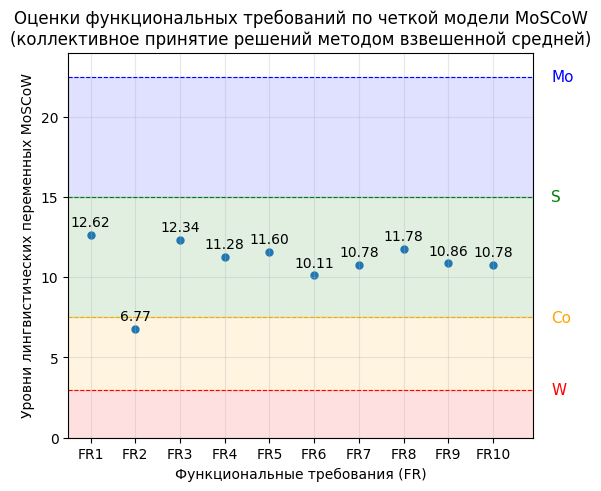

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Преобразуем результаты в словарь: {FR: group_pfr}
pfr_by_fr = {item["fr"]: item["group_pfr"] for item in group_ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [pfr_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW\n(коллективное принятие решений методом взвешенной средней)")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

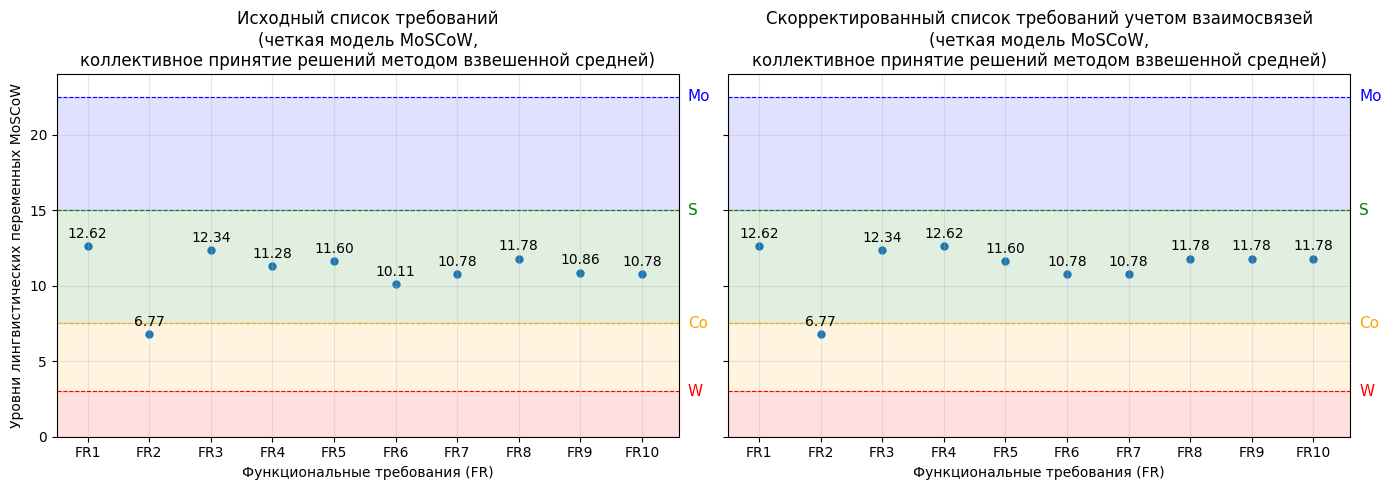

In [122]:
# Преобразуем результаты в словари: {FR: group_pfr} и {FR: adjusted_group_pfr}
pfr_by_fr = {item["fr"]: item["group_pfr"] for item in group_ranked}
adjusted_pfr_by_fr = {item["fr"]: item["adjusted_group_pfr"] for item in adjusted_group_ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [pfr_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_pfr_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)",
    "Скорректированный список требований учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений методом взвешенной средней)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.25
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 24)
    ax.set_xlim(-0.5, len(fr_labels) - 0.4)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [ ]:
# алгоритм, когда решение принимается произвольным числом экспертов. Загрузка и выгрузка данных - из файла / в файл Excel.
import re
from typing import List, Sequence, Dict, Any, Optional
import openpyxl
from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

# 1) Четкие веса MoSCoW
MOSCOW_NFR_WEIGHTS = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}


# 2) Алгоритм для одного эксперта
def pfr_moscow_ranked(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn)
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # список FR, каждый FR имеет длину = n
    fr_names: Sequence[str] | None = None,
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []
    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение {e}. Допустимо: Mo, S, Co, W")

        pfr = sum(w_nfr * w_fr for w_nfr, w_fr in zip(nfr_w, fr_w))
        results.append({"fr": name, "pfr": pfr, "ratings": list(fr_row)})

    return sorted(results, key=lambda x: x["pfr"], reverse=True)


def pfr_moscow_scores(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    ranked = pfr_moscow_ranked(nfr_priorities, fr_vs_nfr_priorities, fr_names=fr_names)
    return {x["fr"]: x["pfr"] for x in ranked}


# 3) Считывание листа эксперта из заданного шаблона
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    # 3.1) Поиск строки заголовков NFR (где встречаются NFR1, NFR2,...)
    nfr_header_row = None
    nfr_cols = []
    nfr_names = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 3.2) Строка приоритетов NFR - следующая строка
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    # 3.3) Поиск шапки таблицы FR (строка, где повторяются NFR1..NFRn)
    fr_header_row = None
    fr_cols = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        # поиск строки, где встречаются все NFR-имена
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            # построение точного соответствия NFR - колонка
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 3.4) Считывание FR-строки
    fr_names = []
    fr_matrix = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v).strip())

        # добавление строки (если она не пустая)
        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {
        "sheet_name": ws.title,
        "nfr_names": nfr_names,
        "nfr_priorities": nfr_priorities,
        "fr_names": fr_names,
        "fr_vs_nfr": fr_matrix,
    }


# 4) Групповая оценка + запись в новый лист
def group_moscow_from_excel(
    in_path: str,
    out_path: Optional[str] = None,
    weights: Optional[Sequence[float]] = None,
    result_sheet_name: str = "Четкий MoSCoW_коллектив",
    normalize_weights: bool = True,
) -> str:
    wb = openpyxl.load_workbook(in_path)

    # считывание всех экспертов из всех листов
    experts = []
    skipped_sheets = []

    for sname in wb.sheetnames:
        # 1) пропускаем лист результатов
        if sname == result_sheet_name:
            continue

        ws = wb[sname]

        # 2) пропускаем любые листы без NFR-шапки
        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            msg = str(e)
            if "Не найдена строка заголовков NFR" in msg:
                skipped_sheets.append(sname)
                continue
            # любые другие ошибки считаем "реальными" проблемами в данных/шаблоне
            raise

        experts.append(data)

    k = len(experts)
    if k == 0:
        raise ValueError(
            "Не найдено ни одного листа-эксперта с NFR-шапкой. "
            f"Пропущено листов: {skipped_sheets}"
        )

    # имена экспертов (после фильтрации листов)
    expert_names = [e["sheet_name"] for e in experts]

    # веса: raw + norm
    if weights is None:
        weights_raw = [1.0] * k
    else:
        if len(weights) != k:
            raise ValueError(f"weights должен быть длины {k} (по числу листов-экспертов).")
        weights_raw = list(weights)

    if normalize_weights:
        s = sum(weights_raw)
        if s == 0:
            raise ValueError("Сумма весов = 0, невозможно нормировать.")
        weights_norm = [x / s for x in weights_raw]
    else:
        weights_norm = weights_raw[:]

    # проверки идентичности размерности FR и NFR у всех экспертов
    base_fr = experts[0]["fr_names"]
    base_nfr_count = len(experts[0]["nfr_names"])

    for e in experts[1:]:
        if e["fr_names"] != base_fr:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")
        if len(e["nfr_names"]) != base_nfr_count:
            raise ValueError("У экспертов разное число NFR (количество столбцов NFR должно совпадать).")

    # PFR каждого эксперта
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e in experts:
        name = e["sheet_name"]
        expert_scores[name] = pfr_moscow_scores(
            e["nfr_priorities"],
            e["fr_vs_nfr"],
            fr_names=base_fr
        )

    # групповой результат (используем нормализованные веса)
    rows = []
    for fr in base_fr:
        group_pfr = 0.0
        by_expert = {}
        for name, wi_norm in zip(expert_names, weights_norm):
            sc = expert_scores[name][fr]
            by_expert[name] = round(sc, 2)
            group_pfr += wi_norm * sc

        rows.append({
            "FR": fr,
            "PFR_group": round(group_pfr, 2),
            "by_expert": by_expert,
        })

    rows_sorted = sorted(rows, key=lambda x: x["PFR_group"], reverse=True)

    # пересоздаем лист результата
    if result_sheet_name in wb.sheetnames:
        wb.remove(wb[result_sheet_name])
    ws_out = wb.create_sheet(result_sheet_name)

    bold = Font(bold=True)

    # Формат колонок
    # A - Эксперт / Rank
    ws_out.column_dimensions["A"].width = 25.29

    # (A) таблица весов: raw + norm + SUM
    ws_out["A1"] = "Эксперт"
    ws_out["B1"] = "Вес_raw"
    ws_out["C1"] = "Вес_norm"
    ws_out["A1"].font = bold
    ws_out["B1"].font = bold
    ws_out["C1"].font = bold

    for i, (name, w_raw, w_norm) in enumerate(zip(expert_names, weights_raw, weights_norm), start=2):
        ws_out.cell(i, 1).value = name
        ws_out.cell(i, 2).value = float(w_raw)
        ws_out.cell(i, 3).value = round(float(w_norm), 2)

    sum_row = 2 + len(expert_names)
    ws_out.cell(sum_row, 1).value = "SUM"
    ws_out.cell(sum_row, 2).value = round(float(sum(weights_raw)), 2)
    ws_out.cell(sum_row, 3).value = round(float(sum(weights_norm)), 2)
    ws_out.cell(sum_row, 1).font = bold
    ws_out.cell(sum_row, 2).font = bold
    ws_out.cell(sum_row, 3).font = bold

    # ширины для таблицы весов (чтобы текст был виден)
    ws_out.column_dimensions["B"].width = 14
    ws_out.column_dimensions["C"].width = 14

    # (B) таблица приоритетов
    start_row = sum_row + 2
    header_row = start_row

    # порядок: Rank, FR, PFR_экспертов..., PFR_group (последним)
    headers = ["Rank", "FR"] + [f"PFR_{name}" for name in expert_names] + ["PFR_group"]

    for j, h in enumerate(headers, start=1):
        cell = ws_out.cell(header_row, j)
        cell.value = h
        cell.font = bold

    for idx, item in enumerate(rows_sorted, start=1):
        r = header_row + idx
        ws_out.cell(r, 1).value = idx
        ws_out.cell(r, 2).value = item["FR"]

        # индивидуальные оценки экспертов
        for j, name in enumerate(expert_names, start=3):
            ws_out.cell(r, j).value = item["by_expert"][name]

        # PFR_group — последний столбец
        last_col = 3 + len(expert_names)
        ws_out.cell(r, last_col).value = item["PFR_group"]

    # Ширины колонок во 2-й таблице
    # FR (B) ширина 14
    ws_out.column_dimensions["B"].width = 14

    # столбцы с PFR экспертов: C..(C+k-1) ширина 30
    for j in range(3, 3 + len(expert_names)):
        col = get_column_letter(j)
        ws_out.column_dimensions[col].width = 30

    # PFR_group - последний столбец, ширина 30
    pfr_group_col_letter = get_column_letter(3 + len(expert_names))
    ws_out.column_dimensions[pfr_group_col_letter].width = 30

    # сохранение
    if out_path is None:
        out_path = in_path
    wb.save(out_path)
    return out_path


In [ ]:
# запуск
in_file = "Загрузочные данные_MoSCoW_коллектив.xlsx"
out_file = "Итоги_четкий MoSCoW_взвешенные средние.xlsx"

# weights:
#   None - raw-веса = 1 для каждого эксперта, затем нормализация даст 1/k
#   список - raw-веса в порядке листов (экспертов), затем нормализация даст доли суммы
saved_path = group_moscow_from_excel(
    in_path=in_file,
    out_path=out_file,
    weights=[0.75, 0.75, 1],  # или None, если веса должны быть одинаковыми
    result_sheet_name="Четкий MoSCoW_коллектив",
    normalize_weights=True
)

print("Saved to:", saved_path)


Saved to: Итоги_четкий MoSCoW_взвешенные средние.xlsx


# 2.2. Коллективное принятие решений при наличии консенсуса

# 2.2.1. Fuzzy_MoSCoW + Алгоритм Hsu 1996 для коллективного принятия решений

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.sciencedirect.com/science/article/pii/0165011495001859

Hsu H.-M., Chen C.-T. Aggregation of fuzzy opinions under group decision making // Fuzzy sets and systems. 1996 May 13;79(3). PP. 279-285

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [123]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [124]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [125]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [126]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [127]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [128]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [129]:
# нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задаем нечеткие веса (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразуем NFR-термы в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразуем FR_NFR термы в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FR_NFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results


In [130]:
# Расширение нечеткого MoSCoW для группы экспертов
EPS = 1e-12

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    """w_i = r_i / sum(r). Если sum(r)=0 -> равные веса."""
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]


def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],       # r_i (ненормализованные)
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    # веса: от raw к norm
    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    # Для каждого эксперта считаем IT2 PFR по всем FR
    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        # pfr_moscow_it2 в коде выше, возвращает список:
        # [{"fr": "FR1", "pfr": IT2}, ...]
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)

        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

In [131]:
# Пример для группы из трех экспертов
# Четкие ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S", "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S", "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

# имена FR (если не задать - будут FR1..FRm)
fr_names = [f"FR{i}" for i in range(1, len(S1["frs"]) + 1)]

prepared_experts = prepare_moscow_it2_inputs(
    experts=experts,
    expert_weights_raw=weights,
    fr_names=fr_names,
    normalize_weights=True,
)

print("Веса экспертов")
print("r (raw):", {e["name"]: round(e["r"], 2) for e in prepared_experts})
print("w (norm):", {e["name"]: round(e["w"], 2) for e in prepared_experts})

print("\nIT2-оценки PFR каждого эксперта по всем FR")
for e in prepared_experts:
    print(f"\nЭксперт {e['name']}:")
    for fr in fr_names:
        print(f"  {fr}: {e['ratings'][fr]}")



Веса экспертов
r (raw): {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
w (norm): {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

IT2-оценки PFR каждого эксперта по всем FR

Эксперт S1:
  FR1: ((6.46, 12.6, 15.81, 20.65), (8.31, 12.6, 15.81, 19.03))
  FR2: ((1.16, 4.46, 9.07, 14.03), (1.81, 4.46, 9.07, 12.43))
  FR3: ((4.0, 7.43, 12.71, 19.96), (5.08, 7.43, 12.71, 17.49))
  FR4: ((5.66, 10.57, 14.55, 20.3), (7.14, 10.57, 14.55, 18.36))
  FR5: ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
  FR6: ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
  FR7: ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
  FR8: ((5.25, 10.35, 14.66, 20.66), (6.83, 10.35, 14.66, 18.63))
  FR9: ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
  FR10: ((2.2, 6.02, 10.75, 16.21), (3.12, 6.02, 10.75, 14.43))

Эксперт S2:
  FR1: ((4.21, 9.89, 15.18, 21.21), (5.67, 9.89, 15.18, 19.23))
  FR2: ((1.16, 5.55, 11.28, 16.77), (1.96, 5.55, 11.28, 15.03))
  FR3: ((7.29, 13.32, 18.39, 25.32), (9.12, 13.32, 18.39, 22

In [132]:
# Построение матрицы согласия для любого числа нечетких оценок

type Trap = tuple[float, float, float, float]
type IT2Trap = tuple[Trap, Trap]  # (U, L)

def trap_mu(x: float, R: tuple[float, float, float, float]) -> float:
    a, b, c, d = R
    if x <= a or x >= d:
        return 0.0

    # левое плечо (b == a)
    if b <= a + EPS:
        if x <= c:
            return 1.0
        if d <= c + EPS:
            return 0.0
        return max(0.0, min(1.0, (d - x) / (d - c)))

    # правое плечо (c == d)
    if d <= c + EPS:
        if x >= b:
            return 1.0
        return max(0.0, min(1.0, (x - a) / (b - a)))

    # обычная трапеция
    if x < b:
        return max(0.0, min(1.0, (x - a) / (b - a)))
    if x <= c:
        return 1.0
    return max(0.0, min(1.0, (d - x) / (d - c)))


def area_R(R: tuple[float, float, float, float]) -> float:
    a, b, c, d = R
    if not (a <= b <= c <= d):
        raise ValueError("Нужно a <= b <= c <= d")
    return 0.5 * (b - a) + (c - b) + 0.5 * (d - c)


def _trap_int(yL: float, yR: float, dx: float) -> float:
    return 0.5 * (yL + yR) * dx


def intersection_area(Ri: tuple[float, float, float, float],
                      Rj: tuple[float, float, float, float]) -> float:
    ai, bi, ci, di = Ri
    aj, bj, cj, dj = Rj
    if not (ai <= bi <= ci <= di and aj <= bj <= cj <= dj):
        raise ValueError("Обе трапеции должны удовлетворять a <= b <= c <= d")

    xs = sorted({ai, bi, ci, di, aj, bj, cj, dj})
    total = 0.0

    for xL, xR in zip(xs, xs[1:]):
        dx = xR - xL
        if dx <= EPS:
            continue

        yiL, yiR = trap_mu(xL, Ri), trap_mu(xR, Ri)
        yjL, yjR = trap_mu(xL, Rj), trap_mu(xR, Rj)

        dL = yiL - yjL
        dR = yiR - yjR

        # min не меняется на отрезке
        if dL <= EPS and dR <= EPS:
            total += _trap_int(yiL, yiR, dx)
            continue
        if dL >= -EPS and dR >= -EPS:
            total += _trap_int(yjL, yjR, dx)
            continue

        # точка переключения (степень принадлежности i = степень принадлежности j)
        t = dL / (dL - dR)
        t = max(0.0, min(1.0, t))
        x0 = xL + t * dx

        yi0 = yiL + (yiR - yiL) * t
        yj0 = yjL + (yjR - yjL) * t

        if dL < 0:
            total += _trap_int(yiL, yi0, x0 - xL)
            total += _trap_int(yj0, yjR, xR - x0)
        else:
            total += _trap_int(yjL, yj0, x0 - xL)
            total += _trap_int(yi0, yiR, xR - x0)

    return total


def union_area(Ri: tuple[float, float, float, float],
               Rj: tuple[float, float, float, float]) -> float:
    a_int = intersection_area(Ri, Rj)
    return area_R(Ri) + area_R(Rj) - a_int


def similarity(Ri: tuple[float, float, float, float],
               Rj: tuple[float, float, float, float]) -> float:
    a_int = intersection_area(Ri, Rj)
    a_uni = area_R(Ri) + area_R(Rj) - a_int
    if a_uni <= EPS:
        return 0.0
    return a_int / a_uni


def similarity_matrix(Rs: list[tuple[float, float, float, float]]) -> list[list[float]]:
    n = len(Rs)
    # расчет площадей Ri
    areas = [area_R(Rs[i]) for i in range(n)]

    S = [[0.0] * n for _ in range(n)]
    for i in range(n):
        S[i][i] = 1.0  # идентичность: пересечение = объединение
        for j in range(i + 1, n):
            a_int = intersection_area(Rs[i], Rs[j])
            a_uni = areas[i] + areas[j] - a_int
            s = 0.0 if a_uni <= EPS else a_int / a_uni
            S[i][j] = s
            S[j][i] = s
    return S

def split_it2(Rs: list[IT2Trap]) -> tuple[list[Trap], list[Trap]]:
    Rs_U = [R[0] for R in Rs]
    Rs_L = [R[1] for R in Rs]
    return Rs_U, Rs_L

def agreement_matrices_it2_by_fr(experts: list[dict], fr_list: list[str] | None = None):
    if not experts:
        raise ValueError("experts пуст")

    # если fr_list не передан - знаечние берется у первого эксперта
    if fr_list is None:
        fr_list = list(experts[0]["ratings"].keys())

    # простая проверка: у всех экспертов должны быть все FR
    for e in experts:
        miss = [fr for fr in fr_list if fr not in e["ratings"]]
        if miss:
            raise ValueError(f"У эксперта {e.get('name','?')} нет оценок для: {miss}")

    AM_U: dict[str, list[list[float]]] = {}
    AM_L: dict[str, list[list[float]]] = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in experts]  # IT2 оценки всех экспертов для FR
        Rs_U, Rs_L = split_it2(Rs_it2)

        AM_U[fr] = similarity_matrix(Rs_U)
        AM_L[fr] = similarity_matrix(Rs_L)

    return AM_U, AM_L, fr_list


In [133]:
# Функция вывода на печать матриц согласия
def print_agreement_matrices_by_fr(AM: dict[str, list[list[float]]],
                                  expert_names: list[str],
                                  fr_list: list[str],
                                  title: str):
    print(title)
    header = [""] + expert_names
    print("   ".join(f"{h:>6}" for h in header))

    for fr in fr_list:
        S = AM[fr]
        print(f"\n{fr}:")
        for i, row in enumerate(S):
            line = [expert_names[i]] + [f"{x:.2f}" for x in row]
            print("   ".join(f"{c:>6}" for c in line))
    print()


In [134]:
# Вывод на печать матриц согласия
expert_names = [e["name"] for e in prepared_experts]

AM_U, AM_L, fr_list = agreement_matrices_it2_by_fr(prepared_experts, fr_list=None)

print("Матрицы согласия по верхним функциям принадлежности (UMF):")
for fr in fr_list:
    print(f"\n{fr}:")
    for row in AM_U[fr]:
        print([round(x, 2) for x in row])

print("\nМатрицы согласия по нижним функциям принадлежности (LMF):")
for fr in fr_list:
    print(f"\n{fr}:")
    for row in AM_L[fr]:
        print([round(x, 2) for x in row])

Матрицы согласия по верхним функциям принадлежности (UMF):

FR1:
[1.0, 0.75, 0.6]
[0.75, 1.0, 0.76]
[0.6, 0.76, 1.0]

FR2:
[1.0, 0.73, 0.82]
[0.73, 1.0, 0.61]
[0.82, 0.61, 1.0]

FR3:
[1.0, 0.37, 0.81]
[0.37, 1.0, 0.46]
[0.81, 0.46, 1.0]

FR4:
[1.0, 0.74, 0.4]
[0.74, 1.0, 0.3]
[0.4, 0.3, 1.0]

FR5:
[1.0, 0.42, 0.62]
[0.42, 1.0, 0.22]
[0.62, 0.22, 1.0]

FR6:
[1.0, 0.48, 0.39]
[0.48, 1.0, 0.18]
[0.39, 0.18, 1.0]

FR7:
[1.0, 0.48, 0.61]
[0.48, 1.0, 0.3]
[0.61, 0.3, 1.0]

FR8:
[1.0, 0.88, 0.67]
[0.88, 1.0, 0.69]
[0.67, 0.69, 1.0]

FR9:
[1.0, 0.73, 0.62]
[0.73, 1.0, 0.42]
[0.62, 0.42, 1.0]

FR10:
[1.0, 0.38, 0.6]
[0.38, 1.0, 0.64]
[0.6, 0.64, 1.0]

Матрицы согласия по нижним функциям принадлежности (LMF):

FR1:
[1.0, 0.7, 0.51]
[0.7, 1.0, 0.75]
[0.51, 0.75, 1.0]

FR2:
[1.0, 0.7, 0.8]
[0.7, 1.0, 0.56]
[0.8, 0.56, 1.0]

FR3:
[1.0, 0.27, 0.74]
[0.27, 1.0, 0.38]
[0.74, 0.38, 1.0]

FR4:
[1.0, 0.7, 0.31]
[0.7, 1.0, 0.21]
[0.31, 0.21, 1.0]

FR5:
[1.0, 0.33, 0.58]
[0.33, 1.0, 0.14]
[0.58, 0.14, 1.0]

In [135]:
# Вычисление средней степени согласия эксперта

def agreement_scores(S: list[list[float]]) -> list[float]:
    k = len(S)
    if k < 2:
        return [0.0] * k

    A = []
    for i in range(k):
        row_sum = sum(S[i]) - S[i][i]  # исключаем диагональ (=1)
        A.append(row_sum / (k - 1))
    return A

def split_it2(Rs: list[IT2Trap]) -> tuple[list[Trap], list[Trap]]:
    Rs_U = [R[0] for R in Rs]
    Rs_L = [R[1] for R in Rs]
    return Rs_U, Rs_L

def agreements_from_traps_it2(Rs: list[IT2Trap]):
    Rs_U, Rs_L = split_it2(Rs)

    S_U = similarity_matrix(Rs_U)
    A_U = agreement_scores(S_U)

    S_L = similarity_matrix(Rs_L)
    A_L = agreement_scores(S_L)

    return S_U, A_U, S_L, A_L

def agreement_scores_it2_by_fr(prepared_experts: list[dict], fr_list: list[str] | None = None):
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")

    if "ratings" not in prepared_experts[0]:
        raise ValueError("Ожидаю формат prepared_experts с ключом 'ratings'. "
                         "Передайте результат prepare_moscow_it2_inputs(...).")

    if fr_list is None:
        fr_list = list(prepared_experts[0]["ratings"].keys())

    A_U_by_fr: dict[str, list[float]] = {}
    A_L_by_fr: dict[str, list[float]] = {}
    S_U_by_fr: dict[str, list[list[float]]] = {}
    S_L_by_fr: dict[str, list[list[float]]] = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in prepared_experts]  # длина = k
        S_U, A_U, S_L, A_L = agreements_from_traps_it2(Rs_it2)

        S_U_by_fr[fr] = S_U
        S_L_by_fr[fr] = S_L
        A_U_by_fr[fr] = A_U
        A_L_by_fr[fr] = A_L

    return A_U_by_fr, A_L_by_fr, S_U_by_fr, S_L_by_fr, fr_list


In [136]:
A_U_by_fr, A_L_by_fr, S_U_by_fr, S_L_by_fr, fr_list = agreement_scores_it2_by_fr(
    prepared_experts,
    fr_list=None       # список требований берется автоматически из данных первого эксперта
)

for fr in fr_list:
    print(f"\n{fr}:")
    print("A_U(Ei):", [round(x, 2) for x in A_U_by_fr[fr]])
    print("A_L(Ei):", [round(x, 2) for x in A_L_by_fr[fr]])




FR1:
A_U(Ei): [0.68, 0.76, 0.68]
A_L(Ei): [0.6, 0.72, 0.63]

FR2:
A_U(Ei): [0.78, 0.67, 0.71]
A_L(Ei): [0.75, 0.63, 0.68]

FR3:
A_U(Ei): [0.59, 0.42, 0.63]
A_L(Ei): [0.51, 0.32, 0.56]

FR4:
A_U(Ei): [0.57, 0.52, 0.35]
A_L(Ei): [0.51, 0.46, 0.26]

FR5:
A_U(Ei): [0.52, 0.32, 0.42]
A_L(Ei): [0.45, 0.23, 0.36]

FR6:
A_U(Ei): [0.43, 0.33, 0.28]
A_L(Ei): [0.36, 0.26, 0.2]

FR7:
A_U(Ei): [0.54, 0.39, 0.46]
A_L(Ei): [0.47, 0.31, 0.38]

FR8:
A_U(Ei): [0.77, 0.79, 0.68]
A_L(Ei): [0.73, 0.76, 0.64]

FR9:
A_U(Ei): [0.67, 0.58, 0.52]
A_L(Ei): [0.62, 0.5, 0.46]

FR10:
A_U(Ei): [0.49, 0.51, 0.62]
A_L(Ei): [0.41, 0.43, 0.55]


In [137]:
# Расчет обобщенной средней степени согласия эксперта A(Ei)
def compute_A_general_for_all_fr(
    A_U_by_fr: dict[str, list[float]],
    A_L_by_fr: dict[str, list[float]],
    fr_names: list[str] | None = None
) -> dict[str, list[float]]:
    if fr_names is None:
        fr_names = list(A_U_by_fr.keys())

    A_by_fr: dict[str, list[float]] = {}

    for fr in fr_names:
        if fr not in A_U_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_U_by_fr")
        if fr not in A_L_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_L_by_fr")

        AU = A_U_by_fr[fr]
        AL = A_L_by_fr[fr]

        if len(AU) != len(AL):
            raise ValueError(f"{fr}: длины A_U и A_L не совпадают")

        A_by_fr[fr] = [(au + al) / 2.0 for au, al in zip(AU, AL)]

    return A_by_fr


def print_A_general_by_fr(
    A_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None,
    round_to: int = 3
):
    if fr_list is None:
        fr_list = list(A_by_fr.keys())

    for fr in fr_list:
        if fr not in A_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_by_fr")
        print(f"{fr}:", [round(x, round_to) for x in A_by_fr[fr]])

In [138]:
# Запуск
A_by_fr = compute_A_general_for_all_fr(
    A_U_by_fr=A_U_by_fr,
    A_L_by_fr=A_L_by_fr,
    fr_names=fr_names
)

print("Обобщенная средняя степень согласия экспертов A(Ei)")
print_A_general_by_fr(A_by_fr, fr_list=fr_names, round_to=2)

Обобщенная средняя степень согласия экспертов A(Ei)
FR1: [0.64, 0.74, 0.66]
FR2: [0.76, 0.65, 0.7]
FR3: [0.55, 0.37, 0.6]
FR4: [0.54, 0.49, 0.31]
FR5: [0.49, 0.28, 0.39]
FR6: [0.4, 0.29, 0.24]
FR7: [0.51, 0.35, 0.42]
FR8: [0.75, 0.77, 0.66]
FR9: [0.64, 0.54, 0.49]
FR10: [0.45, 0.47, 0.59]


In [139]:
# Вычисление относительных степеней согласия экспертов RAD(Ei) по каждому функциональному требованию
def relative_agreement(A: list[float]) -> list[float]:
    s = sum(A)
    if s <= EPS:
        n = len(A)
        return [1.0 / n] * n if n else []
    return [ai / s for ai in A]

def compute_RAD_for_all_fr(
    A_by_fr: dict[str, list[float]],
    fr_names: list[str] | None = None
) -> dict[str, list[float]]:
    if fr_names is None:
        fr_names = list(A_by_fr.keys())

    RAD_by_fr: dict[str, list[float]] = {}

    for fr in fr_names:
        if fr not in A_by_fr:
            raise ValueError(f"{fr}: нет ключа в A_by_fr")

        A = A_by_fr[fr]
        RAD_by_fr[fr] = relative_agreement(A)

    return RAD_by_fr

def print_RAD_by_fr(
    RAD_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None,
    round_to: int = 3
):
    if fr_list is None:
        fr_list = list(RAD_by_fr.keys())

    for fr in fr_list:
        if fr not in RAD_by_fr:
            raise ValueError(f"{fr}: нет ключа в RAD_by_fr")
        print(f"{fr}:", [round(x, round_to) for x in RAD_by_fr[fr]])


In [140]:
# Запуск
RAD_by_fr = compute_RAD_for_all_fr(
    A_by_fr=A_by_fr,
    fr_names=fr_names
)

print("Относительная степень согласия экспертов RAD(Ei)")
print_RAD_by_fr(RAD_by_fr, fr_list=fr_names, round_to=2)

Относительная степень согласия экспертов RAD(Ei)
FR1: [0.31, 0.36, 0.32]
FR2: [0.36, 0.31, 0.33]
FR3: [0.36, 0.25, 0.39]
FR4: [0.4, 0.37, 0.23]
FR5: [0.42, 0.24, 0.34]
FR6: [0.42, 0.31, 0.26]
FR7: [0.4, 0.27, 0.33]
FR8: [0.35, 0.35, 0.3]
FR9: [0.39, 0.32, 0.29]
FR10: [0.3, 0.31, 0.39]


In [141]:
# Коэффициент степени консенсуса экспертов СDC(Ei)
def get_weights_from_prepared(prepared_experts: list[dict]) -> list[float]:
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")
    if "w" not in prepared_experts[0]:
        raise ValueError("В prepared_experts нет ключа 'w'. Сначала вызовите prepare_moscow_it2_inputs(...).")
    return [float(e["w"]) for e in prepared_experts]


def consensus_degree(w: list[float], RAD: list[float], beta: float) -> list[float]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1]")
    if len(w) != len(RAD):
        raise ValueError("w и RAD должны быть одной длины")
    return [beta * wi + (1.0 - beta) * radi for wi, radi in zip(w, RAD)]


def compute_CDC_for_all_fr(
    prepared_experts: list[dict],
    RAD_by_fr: dict[str, list[float]],
    beta: float,
    fr_names: list[str] | None = None
) -> dict[str, list[float]]:
    w = get_weights_from_prepared(prepared_experts)

    if fr_names is None:
        fr_names = list(RAD_by_fr.keys())

    CDC_by_fr: dict[str, list[float]] = {}

    for fr in fr_names:
        if fr not in RAD_by_fr:
            raise ValueError(f"{fr}: нет ключа в RAD_by_fr")

        RAD = RAD_by_fr[fr]
        CDC_by_fr[fr] = consensus_degree(w, RAD, beta)

    return CDC_by_fr

def print_CDC_by_fr(
    CDC_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None,
    round_to: int = 3
):
    if fr_list is None:
        fr_list = list(CDC_by_fr.keys())

    for fr in fr_list:
        if fr not in CDC_by_fr:
            raise ValueError(f"{fr}: нет ключа в CDC_by_fr")
        print(f"{fr}:", [round(x, round_to) for x in CDC_by_fr[fr]])

In [142]:
# Запуск
beta = 0.4  # гиперпараметр
CDC_by_fr = compute_CDC_for_all_fr(
    prepared_experts=prepared_experts,
    RAD_by_fr=RAD_by_fr,
    beta=beta,
    fr_names=fr_names
)

print("Коэффициент степени консенсуса экспертов CDC(Ei)")
print_CDC_by_fr(CDC_by_fr, fr_list=fr_names, round_to=2)

Коэффициент степени консенсуса экспертов CDC(Ei)
FR1: [0.31, 0.34, 0.35]
FR2: [0.34, 0.3, 0.36]
FR3: [0.34, 0.27, 0.4]
FR4: [0.36, 0.34, 0.3]
FR5: [0.37, 0.26, 0.36]
FR6: [0.37, 0.31, 0.32]
FR7: [0.36, 0.28, 0.36]
FR8: [0.33, 0.33, 0.34]
FR9: [0.35, 0.31, 0.34]
FR10: [0.3, 0.31, 0.39]


In [143]:
# Вычисление взвешенной коллективной оценки в виде нечеткого трапециевидного числа 2-го типа
def aggregate_it2_trapezoids(Rs: list[IT2Trap], CDC: list[float]) -> IT2Trap:
    if len(Rs) != len(CDC):
        raise ValueError("Длины Rs и CDC должны совпадать")
    if not Rs:
        raise ValueError("Список Rs пуст")

    R_sum: IT2Trap = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))

    for R_i, cdc_i in zip(Rs, CDC):
        R_weighted = multiply_fuzzy_number_by_constant(R_i, cdc_i)
        R_sum = add_intuitionistic_trapezoidal_fuzzy_numbers(R_sum, R_weighted)

    return R_sum

def aggregate_group_it2_by_fr(
    prepared_experts: list[dict],
    CDC_by_fr: dict[str, list[float]],
    fr_list: list[str] | None = None
):
    if not prepared_experts:
        raise ValueError("prepared_experts пуст")
    if "ratings" not in prepared_experts[0]:
        raise ValueError("Ожидаю prepared_experts с ключом 'ratings'.")

    if fr_list is None:
        fr_list = list(prepared_experts[0]["ratings"].keys())

    R_group_by_fr = {}

    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in prepared_experts]  # длина=k

        if fr not in CDC_by_fr:
            raise ValueError(f"{fr}: нет ключа в CDC_by_fr")

        CDC = CDC_by_fr[fr]
        if len(Rs_it2) != len(CDC):
            raise ValueError(f"{fr}: длины Rs_it2 и CDC не совпадают")

        R_sum = aggregate_it2_trapezoids(Rs_it2, CDC)

        UMF_agg, LMF_agg = R_sum
        R_group_by_fr[fr] = (
            tuple(round(x, 3) for x in UMF_agg),
            tuple(round(x, 3) for x in LMF_agg),
        )

    return R_group_by_fr, fr_list

In [144]:
# Запуск
R_group_by_fr, fr_list = aggregate_group_it2_by_fr(
    prepared_experts=prepared_experts,
    CDC_by_fr=CDC_by_fr,
    fr_list=None
)

for fr in fr_list:
    print(f"{fr}: {R_group_by_fr[fr]}")

FR1: ((5.2, 10.73, 14.8, 20.07), (6.76, 10.73, 14.8, 18.33))
FR2: ((0.95, 4.49, 9.46, 14.46), (1.58, 4.49, 9.46, 12.87))
FR3: ((5.21, 9.8, 14.72, 21.52), (6.62, 9.8, 14.72, 19.21))
FR4: ((4.79, 9.64, 14.12, 19.77), (6.1, 9.64, 14.12, 17.89))
FR5: ((4.51, 9.21, 13.96, 20.14), (5.86, 9.21, 13.96, 18.07))
FR6: ((3.95, 8.46, 12.76, 17.83), (5.02, 8.46, 12.76, 16.17))
FR7: ((4.15, 8.78, 13.13, 18.36), (5.3, 8.78, 13.13, 16.64))
FR8: ((4.65, 9.77, 14.17, 19.72), (6.03, 9.77, 14.17, 17.87))
FR9: ((3.99, 8.76, 13.43, 19.22), (5.28, 8.76, 13.43, 17.3))
FR10: ((3.87, 8.65, 13.17, 18.64), (5.12, 8.65, 13.17, 16.83))


In [145]:
# Применяем оператор согласованной линейной редукции типов ко всем групповым нечетким приоритетам
a = 0.6

results_reduction = []
for fr in fr_list:
    reduced = cltr_type_reduction(R_group_by_fr[fr], a)
    results_reduction.append({
        "fr": fr,
        "pfr_it2": R_group_by_fr[fr],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (6.14, 10.73, 14.8, 19.03)
FR2: a=0.6, (1.33, 4.49, 9.46, 13.51)
FR3: a=0.6, (6.06, 9.8, 14.72, 20.13)
FR4: a=0.6, (5.58, 9.64, 14.12, 18.64)
FR5: a=0.6, (5.32, 9.21, 13.96, 18.9)
FR6: a=0.6, (4.59, 8.46, 12.76, 16.83)
FR7: a=0.6, (4.84, 8.78, 13.13, 17.33)
FR8: a=0.6, (5.48, 9.77, 14.17, 18.61)
FR9: a=0.6, (4.76, 8.76, 13.43, 18.07)
FR10: a=0.6, (4.62, 8.65, 13.17, 17.55)


In [146]:
# Применяем альфа-срез ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (9.81; 15.65)
FR2: альфа=0.8, (3.86; 10.27)
FR3: альфа=0.8, (9.05; 15.8)
FR4: альфа=0.8, (8.83; 15.02)
FR5: альфа=0.8, (8.43; 14.95)
FR6: альфа=0.8, (7.69; 13.57)
FR7: альфа=0.8, (7.99; 13.97)
FR8: альфа=0.8, (8.91; 15.06)
FR9: альфа=0.8, (7.96; 14.36)
FR10: альфа=0.8, (7.84; 14.05)


In [147]:
# Вычисляем центроид для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=12.73
2. FR3: centroid=12.43
3. FR8: centroid=11.98
4. FR4: centroid=11.93
5. FR5: centroid=11.69
6. FR9: centroid=11.16
7. FR7: centroid=10.98
8. FR10: centroid=10.95
9. FR6: centroid=10.63
10. FR2: centroid=7.06


Алгоритм учета взаимосвязанности функциональных требований

In [148]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый дефаззифицированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [150]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=12.73, скорректированный centroid=12.73
2. FR4: исходный centroid=11.93, скорректированный centroid=12.73
3. FR3: исходный centroid=12.43, скорректированный centroid=12.43
4. FR8: исходный centroid=11.98, скорректированный centroid=11.98
5. FR9: исходный centroid=11.16, скорректированный centroid=11.98
6. FR10: исходный centroid=10.95, скорректированный centroid=11.98
7. FR5: исходный centroid=11.69, скорректированный centroid=11.69
8. FR7: исходный centroid=10.98, скорректированный centroid=10.98
9. FR6: исходный centroid=10.63, скорректированный centroid=10.98
10. FR2: исходный centroid=7.06, скорректированный centroid=7.06


Визуализации исходного и итогового приоритизированного списков функциональных требований

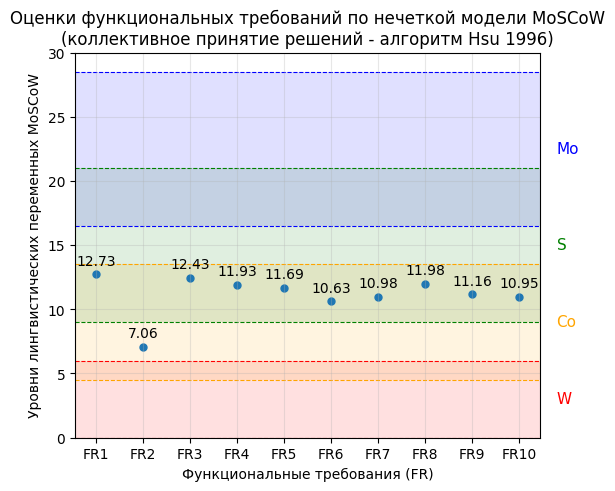

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Преобразуем результаты в словарь: {FR: centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) - 0.2   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW\n(коллективное принятие решений - алгоритм Hsu 1996)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

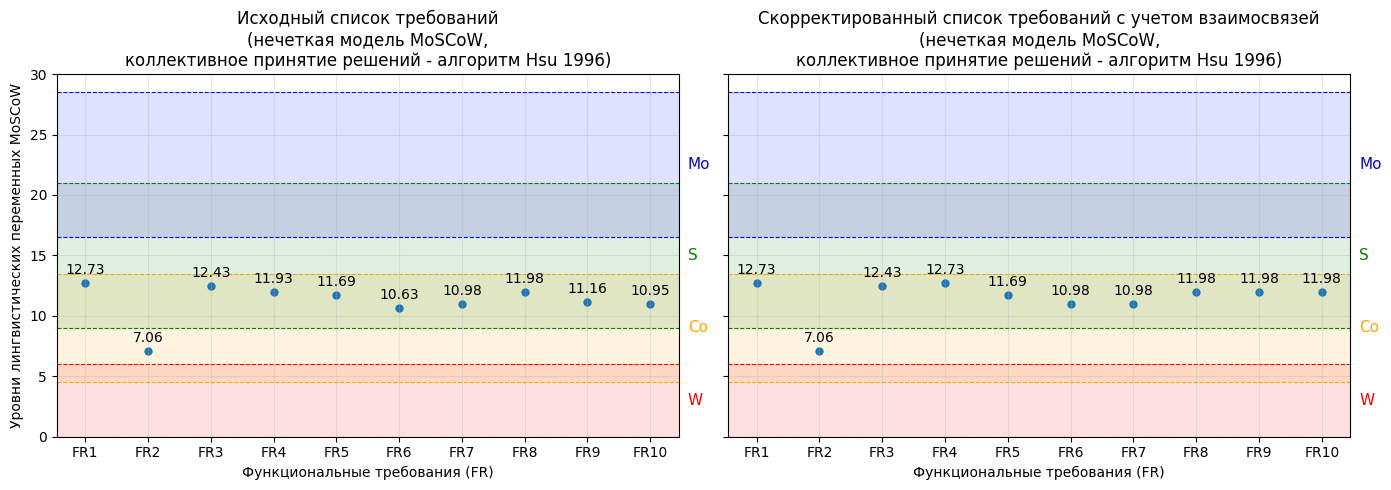

In [153]:
# Преобразуем результаты в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Hsu 1996)",
    "Скорректированный список требований с учетом взаимосвязей\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Hsu 1996)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл**

In [ ]:
# Версия с загрузкой данных из файла и выгрузкой итогов в файл
from typing import List, Dict, Any, Sequence, Tuple, Optional
import re

from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# Типы данных и констант
Trap = Tuple[float, float, float, float]
IT2  = Tuple[Trap, Trap]  # (UMF, LMF)
EPS = 1e-12


# Математические операции над нечеткими трапециевидными числами 2-го типа
def add_intuitionistic_trapezoidal_fuzzy_numbers(f1: IT2, f2: IT2) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = f1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = f2
    return (
        (round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
        (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)),
    )

def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X: IT2, Y: IT2) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0.0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))
    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

def multiply_fuzzy_number_by_constant(f: IT2, c: float) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = f
    if c < 0:
        return (
            (x4 * c, x3 * c, x2 * c, x1 * c),
            (x8 * c, x7 * c, x6 * c, x5 * c),
        )
    return (
        (x1 * c, x2 * c, x3 * c, x4 * c),
        (x5 * c, x6 * c, x7 * c, x8 * c),
    )

def alpha_cut(f: IT2, alpha: float) -> Tuple[Tuple[float, float], Tuple[float, float]]:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = f

    upper_start = alpha * x2 + (1 - alpha) * x1
    upper_end   = alpha * x3 + (1 - alpha) * x4

    lower_start = alpha * x6 + (1 - alpha) * x5
    lower_end   = alpha * x7 + (1 - alpha) * x8

    return (
        (round(upper_start, 3), round(upper_end, 2)),
        (round(lower_start, 3), round(lower_end, 2)),
    )

# Нечеткие веса MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8)),
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15)),
}


# Расчет нечетких оценок по одному эксперту
def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Optional[Sequence[str]] = None,
) -> List[Dict[str, Any]]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[str(x).strip()] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[str(x).strip()] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({"fr": name, "pfr": pfr_it2, "ratings": list(fr_row)})

    return results

# Чтение листов с оценками экспертов в Excel
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat  = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    # 1) строка заголовков NFR
    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 1:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            if nfr_names:
                nfr_header_row = r
                break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 2) приоритеты NFR (следующая строка)
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    # 3) строка-шапка FR таблицы (где присутствуют все NFR имена)
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 4) строки FR: имя FR в колонке A (1)
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v).strip())

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    if not fr_names:
        raise ValueError(f"Не найдено ни одной строки FR на листе '{ws.title}'.")

    return {
        "name": ws.title,
        "nfr": nfr_priorities,
        "fr_names": fr_names,
        "frs": fr_matrix,
    }

# Вычисление степени сходства для трапеций и матрицы согласия AM
def trap_mu(x: float, R: Trap) -> float:
    a, b, c, d = R
    if x <= a or x >= d:
        return 0.0

    if b <= a + EPS:  # левое плечо
        if x <= c:
            return 1.0
        if d <= c + EPS:
            return 0.0
        return max(0.0, min(1.0, (d - x) / (d - c)))

    if d <= c + EPS:  # правое плечо
        if x >= b:
            return 1.0
        return max(0.0, min(1.0, (x - a) / (b - a)))

    if x < b:
        return max(0.0, min(1.0, (x - a) / (b - a)))
    if x <= c:
        return 1.0
    return max(0.0, min(1.0, (d - x) / (d - c)))

def area_R(R: Trap) -> float:
    a, b, c, d = R
    if not (a <= b <= c <= d):
        raise ValueError("Нужно a <= b <= c <= d")
    return 0.5 * (b - a) + (c - b) + 0.5 * (d - c)

def _trap_int(yL: float, yR: float, dx: float) -> float:
    return 0.5 * (yL + yR) * dx

def intersection_area(Ri: Trap, Rj: Trap) -> float:
    ai, bi, ci, di = Ri
    aj, bj, cj, dj = Rj
    if not (ai <= bi <= ci <= di and aj <= bj <= cj <= dj):
        raise ValueError("Обе трапеции должны удовлетворять a <= b <= c <= d")

    xs = sorted({ai, bi, ci, di, aj, bj, cj, dj})
    total = 0.0

    for xL, xR in zip(xs, xs[1:]):
        dx = xR - xL
        if dx <= EPS:
            continue

        yiL, yiR = trap_mu(xL, Ri), trap_mu(xR, Ri)
        yjL, yjR = trap_mu(xL, Rj), trap_mu(xR, Rj)

        dL = yiL - yjL
        dR = yiR - yjR

        if dL <= EPS and dR <= EPS:
            total += _trap_int(yiL, yiR, dx)
            continue
        if dL >= -EPS and dR >= -EPS:
            total += _trap_int(yjL, yjR, dx)
            continue

        t = dL / (dL - dR)
        t = max(0.0, min(1.0, t))
        x0 = xL + t * dx

        yi0 = yiL + (yiR - yiL) * t
        yj0 = yjL + (yjR - yjL) * t

        if dL < 0:
            total += _trap_int(yiL, yi0, x0 - xL)
            total += _trap_int(yj0, yjR, xR - x0)
        else:
            total += _trap_int(yjL, yj0, x0 - xL)
            total += _trap_int(yi0, yiR, xR - x0)

    return total

def similarity_matrix(Rs: List[Trap]) -> List[List[float]]:
    n = len(Rs)
    areas = [area_R(Rs[i]) for i in range(n)]
    S = [[0.0] * n for _ in range(n)]
    for i in range(n):
        S[i][i] = 1.0
        for j in range(i + 1, n):
            a_int = intersection_area(Rs[i], Rs[j])
            a_uni = areas[i] + areas[j] - a_int
            s = 0.0 if a_uni <= EPS else a_int / a_uni
            S[i][j] = s
            S[j][i] = s
    return S


# Вычисление A_U, A_L, A_general, RAD, CDC
def agreement_scores(S: List[List[float]]) -> List[float]:
    k = len(S)
    if k < 2:
        return [0.0] * k
    A = []
    for i in range(k):
        row_sum = sum(S[i]) - S[i][i]
        A.append(row_sum / (k - 1))
    return A

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def compute_A_general(A_U: List[float], A_L: List[float]) -> List[float]:
    if len(A_U) != len(A_L):
        raise ValueError("A_U и A_L должны быть одинаковой длины")
    return [(au + al) / 2.0 for au, al in zip(A_U, A_L)]

def relative_agreement(A: List[float]) -> List[float]:
    s = sum(A)
    n = len(A)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ai / s for ai in A]

def consensus_degree_single(w_norm: List[float], RAD: List[float], beta: float, renorm: bool = True) -> List[float]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1]")
    if len(w_norm) != len(RAD):
        raise ValueError("w_norm и RAD должны быть одной длины")

    cdc = [beta * wi + (1.0 - beta) * ri for wi, ri in zip(w_norm, RAD)]

    # Нормировка
    if not renorm:
        return cdc

    s = sum(cdc)
    n = len(cdc)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [x / s for x in cdc]

def split_it2(Rs_it2: List[IT2]) -> Tuple[List[Trap], List[Trap]]:
    return [r[0] for r in Rs_it2], [r[1] for r in Rs_it2]

# Агрегация группы по единым CDC
def aggregate_trapezoids_1type(Rs: List[Trap], weights: List[float]) -> Trap:
    if len(Rs) != len(weights):
        raise ValueError("Длины Rs и weights должны совпадать")
    A = B = C = D = 0.0
    for (a, b, c, d), w in zip(Rs, weights):
        A += w * a
        B += w * b
        C += w * c
        D += w * d
    return (round(A, 2), round(B, 2), round(C, 2), round(D, 2))

def aggregate_group_it2_by_fr_single_cdc(
    experts_prepared: List[Dict[str, Any]],
    fr_list: List[str],
    CDC_by_fr: Dict[str, List[float]],
) -> Dict[str, IT2]:
    out: Dict[str, IT2] = {}
    for fr in fr_list:
        Rs_it2 = [e["ratings"][fr] for e in experts_prepared]
        Rs_U, Rs_L = split_it2(Rs_it2)
        w = CDC_by_fr[fr]  # единый CDC
        UMF_agg = aggregate_trapezoids_1type(Rs_U, w)
        LMF_agg = aggregate_trapezoids_1type(Rs_L, w)
        out[fr] = (UMF_agg, LMF_agg)
    return out

# Дефаззификация (альфа-срезы + центроиды) + сортировка
def _fr_num(fr: str) -> int:
    m = re.search(r"(\d+)", fr)
    return int(m.group(1)) if m else 10**9

def build_defuzz_rows(pfr_by_fr: Dict[str, IT2], alpha: float) -> List[Dict[str, Any]]:
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("alpha должен быть в диапазоне [0, 1]")

    rows = []
    for fr, it2 in pfr_by_fr.items():
        (U_alpha, L_alpha) = alpha_cut(it2, alpha)
        u_s, u_e = U_alpha
        l_s, l_e = L_alpha

        mid_U = (u_s + u_e) / 2
        mid_L = (l_s + l_e) / 2
        avg   = (mid_U + mid_L) / 2

        (a, b, c, d), (e, f, g, h) = it2
        rows.append({
            "FR": fr,
            "umf": (a, b, c, d),
            "lmf": (e, f, g, h),
            "u_cut": (u_s, u_e),
            "l_cut": (l_s, l_e),
            "mid_umf": round(mid_U, 2),
            "mid_lmf": round(mid_L, 2),
            "avg_mid": round(avg, 2),
            "_avg_raw": avg,
            "_fr_num": _fr_num(fr),
        })

    rows_sorted = sorted(rows, key=lambda x: (-x["_avg_raw"], x["_fr_num"]))
    for r in rows_sorted:
        r.pop("_avg_raw", None)
        r.pop("_fr_num", None)
    return rows_sorted

# Выгрузка данных в Excel
def _set_col_width(ws, col_idx: int, width: float):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

def write_weights_block(ws, start_row: int, expert_names: List[str], r_raw: List[float], w_norm: List[float]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row, 1).value = "Эксперт"
    ws.cell(start_row, 2).value = "Вес_raw (r)"
    ws.cell(start_row, 3).value = "Вес_norm (w)"
    for c in [1, 2, 3]:
        ws.cell(start_row, c).font = bold
        ws.cell(start_row, c).alignment = center

    for i, (nm, rr, ww) in enumerate(zip(expert_names, r_raw, w_norm), start=1):
        rrw = start_row + i
        ws.cell(rrw, 1).value = nm
        ws.cell(rrw, 2).value = float(rr)
        ws.cell(rrw, 3).value = round(float(ww), 2)

    sum_row = start_row + len(expert_names) + 1
    ws.cell(sum_row, 1).value = "SUM"
    ws.cell(sum_row, 2).value = round(sum(r_raw), 2)
    ws.cell(sum_row, 3).value = round(sum(w_norm), 2)
    for c in [1, 2, 3]:
        ws.cell(sum_row, c).font = bold

    ws.column_dimensions["A"].width = 25.29
    ws.column_dimensions["B"].width = 16
    ws.column_dimensions["C"].width = 16

    return sum_row + 2

def write_alpha_beta(ws, start_row: int, alpha: float, beta: float) -> int:
    bold = Font(bold=True)
    ws.cell(start_row, 1).value = "уровень альфа-среза (alpha)"
    ws.cell(start_row, 2).value = alpha
    ws.cell(start_row, 1).font = bold
    ws.cell(start_row, 2).font = bold

    ws.cell(start_row + 1, 1).value = "параметр beta (для CDC)"
    ws.cell(start_row + 1, 2).value = beta
    ws.cell(start_row + 1, 1).font = bold
    ws.cell(start_row + 1, 2).font = bold

    return start_row + 3

def write_result_table(ws, start_row: int, title: str, alpha: float, rows_sorted: List[Dict[str, Any]]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=17)
    t = ws.cell(start_row, 1)
    t.value = title
    t.font = bold
    t.alignment = center

    r1, r2 = start_row + 1, start_row + 2

    ws.merge_cells(start_row=r1, start_column=1, end_row=r2, end_column=1)    # Rank
    ws.merge_cells(start_row=r1, start_column=2, end_row=r2, end_column=2)    # FR
    ws.merge_cells(start_row=r1, start_column=3, end_row=r1, end_column=10)   # IT2
    ws.merge_cells(start_row=r1, start_column=11, end_row=r1, end_column=14)  # alpha cut
    ws.merge_cells(start_row=r1, start_column=15, end_row=r1, end_column=16)  # centroids
    ws.merge_cells(start_row=r1, start_column=17, end_row=r2, end_column=17)  # avg

    ws.cell(r1, 1).value = "Rank"
    ws.cell(r1, 2).value = "FR"
    ws.cell(r1, 3).value = "PFR_IT2"
    ws.cell(r1, 11).value = f"alpha-cut ({alpha})"
    ws.cell(r1, 15).value = "Centroids"
    ws.cell(r1, 17).value = "avg_mid"

    for col in [1, 2, 3, 11, 15, 17]:
        ws.cell(r1, col).font = bold
        ws.cell(r1, col).alignment = center

    ws.cell(r2, 3).value  = "UMF (a,b,c,d)"
    ws.cell(r2, 7).value  = "LMF (e,f,g,h)"
    ws.cell(r2, 11).value = "UMF [u1,u2]"
    ws.cell(r2, 13).value = "LMF [l1,l2]"
    ws.cell(r2, 15).value = "mid_UMF"
    ws.cell(r2, 16).value = "mid_LMF"

    for col in [3, 7, 11, 13, 15, 16]:
        ws.cell(r2, col).font = bold
        ws.cell(r2, col).alignment = center

    data_start = start_row + 3
    for i, item in enumerate(rows_sorted, start=1):
        rr = data_start + (i - 1)
        ws.cell(rr, 1).value = i
        ws.cell(rr, 2).value = item["FR"]

        (a, b, c, d) = item["umf"]
        (e, f, g, h) = item["lmf"]
        (u1, u2)     = item["u_cut"]
        (l1, l2)     = item["l_cut"]

        for j, val in enumerate([a, b, c, d], start=3):
            ws.cell(rr, j).value = round(val, 2)
        for j, val in enumerate([e, f, g, h], start=7):
            ws.cell(rr, j).value = round(val, 2)

        ws.cell(rr, 11).value = round(u1, 2)
        ws.cell(rr, 12).value = round(u2, 2)
        ws.cell(rr, 13).value = round(l1, 2)
        ws.cell(rr, 14).value = round(l2, 2)

        ws.cell(rr, 15).value = round(item["mid_umf"], 2)
        ws.cell(rr, 16).value = round(item["mid_lmf"], 2)
        ws.cell(rr, 17).value = round(item["avg_mid"], 2)

    _set_col_width(ws, 1, 10)
    _set_col_width(ws, 2, 10)
    for col in range(3, 15):
        _set_col_width(ws, col, 14)
    _set_col_width(ws, 15, 12)
    _set_col_width(ws, 16, 12)
    _set_col_width(ws, 17, 12)

    return data_start + len(rows_sorted) + 2

def write_dual_matrices_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    mats_left: Dict[str, List[List[float]]],
    mats_right: Dict[str, List[List[float]]],
    k: int,
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    left_start = 1
    left_width = 1 + k
    gap = 1
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    c = ws.cell(start_row, 1)
    c.value = title
    c.font = bold
    c.alignment = center

    ws.merge_cells(start_row=start_row + 1, start_column=left_start, end_row=start_row + 1, end_column=left_start + left_width - 1)
    ws.merge_cells(start_row=start_row + 1, start_column=right_start, end_row=start_row + 1, end_column=right_start + right_width - 1)
    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, right_start).value = subtitle_right
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, right_start).font = bold

    r = start_row + 3

    for fr in fr_list:
        M1 = mats_left[fr]
        M2 = mats_right[fr]

        ws.cell(r, left_start).value = fr
        ws.cell(r, right_start).value = fr
        ws.cell(r, left_start).font = bold
        ws.cell(r, right_start).font = bold

        for i in range(k):
            for j in range(k):
                ws.cell(r + i, left_start + 1 + j).value = round(float(M1[i][j]), 2)
                ws.cell(r + i, right_start + 1 + j).value = round(float(M2[i][j]), 2)

        r = r + k + 1

    _set_col_width(ws, left_start, 10)
    for c in range(left_start + 1, left_start + left_width):
        _set_col_width(ws, c, 10)
    _set_col_width(ws, right_start, 10)
    for c in range(right_start + 1, right_start + right_width):
        _set_col_width(ws, c, 10)

    return r + 1

def write_dual_vectors_block(
    ws,
    start_row: int,
    title: str,
    subtitle_left: str,
    subtitle_right: str,
    fr_list: List[str],
    vec_left: Dict[str, List[float]],
    vec_right: Dict[str, List[float]],
    k: int,
) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    left_start = 1
    left_width = 1 + k
    gap = 1
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    c = ws.cell(start_row, 1)
    c.value = title
    c.font = bold
    c.alignment = center

    ws.merge_cells(start_row=start_row + 1, start_column=left_start, end_row=start_row + 1, end_column=left_start + left_width - 1)
    ws.merge_cells(start_row=start_row + 1, start_column=right_start, end_row=start_row + 1, end_column=right_start + right_width - 1)
    ws.cell(start_row + 1, left_start).value = subtitle_left
    ws.cell(start_row + 1, right_start).value = subtitle_right
    ws.cell(start_row + 1, left_start).font = bold
    ws.cell(start_row + 1, right_start).font = bold

    r = start_row + 3
    for fr in fr_list:
        ws.cell(r, left_start).value = fr
        ws.cell(r, right_start).value = fr
        ws.cell(r, left_start).font = bold
        ws.cell(r, right_start).font = bold

        for j, val in enumerate(vec_left[fr], start=0):
            ws.cell(r, left_start + 1 + j).value = round(float(val), 2)
        for j, val in enumerate(vec_right[fr], start=0):
            ws.cell(r, right_start + 1 + j).value = round(float(val), 2)

        r += 1

    return r + 2

def write_single_vectors_block(
    ws,
    start_row: int,
    title: str,
    fr_list: List[str],
    vec: Dict[str, List[float]],
    k: int,
) -> int:

    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 1 + k  # A..(A+k)

    # Заголовки
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    c = ws.cell(start_row, 1)
    c.value = title
    c.font = bold
    c.alignment = center

    # Данные
    r = start_row + 2
    for fr in fr_list:
        ws.cell(r, 1).value = fr
        ws.cell(r, 1).font = bold
        for j, val in enumerate(vec[fr], start=0):
            ws.cell(r, 2 + j).value = round(float(val), 2)
        r += 1

    _set_col_width(ws, 1, 12)
    for c in range(2, 2 + k):
        _set_col_width(ws, c, 12)

    return r + 2

# Главная функция(чтение, расчеты, выгрузка результатов)
def run_all_append_one_sheet(
    input_xlsx: str,
    output_xlsx: str,
    weights_raw: List[float],
    alpha: float,
    beta: float,
    result_sheet_name: str = "Нечеткий MoSCoW_коллектив",
    skip_sheet_if_name_exists: bool = False,
) -> str:

    wb = load_workbook(input_xlsx)

    experts_loaded: List[Dict[str, Any]] = []
    skipped: List[str] = []

    # читаем все листы как экспертов (кроме итогового)
    for sname in wb.sheetnames:
        if sname == result_sheet_name and skip_sheet_if_name_exists:
            continue

        ws = wb[sname]
        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            if "Не найдена строка заголовков NFR" in str(e):
                skipped.append(sname)
                continue
            raise
        experts_loaded.append(data)

    if not experts_loaded:
        raise ValueError(f"Не найдено листов-экспертов с NFR-шапкой. Пропущено: {skipped}")

    # проверим одинаковый список FR у всех
    fr_list = experts_loaded[0]["fr_names"]
    for e in experts_loaded[1:]:
        if e["fr_names"] != fr_list:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")

    k = len(experts_loaded)
    if len(weights_raw) != k:
        raise ValueError(f"weights_raw должен быть длины {k} (по числу экспертов/листов).")

    # веса экспертов: raw и norm
    w_norm = normalize_weights_w(weights_raw)

    # Нечеткие оценки каждого эксперта по каждому FR
    experts_prepared: List[Dict[str, Any]] = []
    for e, r_i, w_i in zip(experts_loaded, weights_raw, w_norm):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_list)
        ratings = {item["fr"]: item["pfr"] for item in res}
        experts_prepared.append({
            "name": e["name"],
            "r": float(r_i),
            "w": float(w_i),
            "ratings": ratings,
        })

    # По каждому FR считаем:
    # AM_U, AM_L, A_U, A_L, A обобщенное, RAD, CDC
    AM_U_by_fr: Dict[str, List[List[float]]] = {}
    AM_L_by_fr: Dict[str, List[List[float]]] = {}

    A_U_by_fr: Dict[str, List[float]] = {}
    A_L_by_fr: Dict[str, List[float]] = {}
    A_by_fr:   Dict[str, List[float]] = {}

    RAD_by_fr: Dict[str, List[float]] = {}
    CDC_by_fr: Dict[str, List[float]] = {}

    for fr in fr_list:
        Rs_it2 = [ex["ratings"][fr] for ex in experts_prepared]
        Rs_U, Rs_L = split_it2(Rs_it2)

        AM_U = similarity_matrix(Rs_U)
        AM_L = similarity_matrix(Rs_L)
        AM_U_by_fr[fr] = AM_U
        AM_L_by_fr[fr] = AM_L

        A_U = agreement_scores(AM_U)
        A_L = agreement_scores(AM_L)
        A_U_by_fr[fr] = A_U
        A_L_by_fr[fr] = A_L

        A_gen = compute_A_general(A_U, A_L)
        A_by_fr[fr] = A_gen

        RAD = relative_agreement(A_gen)
        RAD_by_fr[fr] = RAD

        CDC = consensus_degree_single(w_norm, RAD, beta, renorm=True)
        CDC_by_fr[fr] = CDC

    # Расчет коллективной нечтекой оценки
    R_group_by_fr = aggregate_group_it2_by_fr_single_cdc(experts_prepared, fr_list, CDC_by_fr)

    # Создание нового листа
    if result_sheet_name in wb.sheetnames:
        wb.remove(wb[result_sheet_name])
    ws_out = wb.create_sheet(result_sheet_name)

    r = 1
    expert_names = [e["name"] for e in experts_prepared]

    # (1) веса raw/norm
    r = write_weights_block(ws_out, r, expert_names, list(weights_raw), w_norm)

    # (2) alpha/beta
    r = write_alpha_beta(ws_out, r, alpha, beta)

    # (3) блоки экспертов: PFR_IT2 + alpha-cut + mid + avg (с сортировкой)
    for e in experts_prepared:
        rows_sorted = build_defuzz_rows(e["ratings"], alpha)
        r = write_result_table(ws_out, r, title=f"Эксперт: {e['name']}", alpha=alpha, rows_sorted=rows_sorted)

    # (4) матрицы согласия AM (UMF/LMF рядом) - до обобщения
    r = write_dual_matrices_block(
        ws_out, r,
        title="Матрицы согласия (AM)",
        subtitle_left="Матрицы согласия по верхним функциям принадлежности (AM_UMF)",
        subtitle_right="Матрицы согласия по нижним функциям принадлежности (AM_LMF)",
        fr_list=fr_list,
        mats_left=AM_U_by_fr,
        mats_right=AM_L_by_fr,
        k=k
    )

    # (5) средняя степень согласия A_U и A_L
    r = write_dual_vectors_block(
        ws_out, r,
        title="Средняя степень согласия эксперта A(Ei)",
        subtitle_left="A_U(Ei) по UMF",
        subtitle_right="A_L(Ei) по LMF",
        fr_list=fr_list,
        vec_left=A_U_by_fr,
        vec_right=A_L_by_fr,
        k=k
    )

    # (6) обобщенная средняя степень согласия A(Ei)
    r = write_single_vectors_block(
        ws_out, r,
        title="Обобщенная средняя степень согласия эксперта A(Ei)",
        fr_list=fr_list,
        vec=A_by_fr,
        k=k
    )

    # (7) RAD(Ei)
    r = write_single_vectors_block(
        ws_out, r,
        title="Относительная степень согласия эксперта RAD(Ei)",
        fr_list=fr_list,
        vec=RAD_by_fr,
        k=k
    )

    # (8) CDC(Ei)
    r = write_single_vectors_block(
        ws_out, r,
        title="Коэффициент степени консенсуса эксперта CDC(Ei)",
        fr_list=fr_list,
        vec=CDC_by_fr,
        k=k
    )

    # (9) итог группы
    rows_sorted_group = build_defuzz_rows(R_group_by_fr, alpha)
    r = write_result_table(ws_out, r, title="Итог группы (CDC)", alpha=alpha, rows_sorted=rows_sorted_group)

    wb.save(output_xlsx)
    return output_xlsx

In [ ]:
# Запуск
INPUT_XLSX  = r"Загрузочные данные_MoSCoW_коллектив.xlsx"
OUTPUT_XLSX = r"Итоги_Fuzzy MoSCoW_Hsu 1996.xlsx"

WEIGHTS_RAW = [0.75, 0.75, 1.0]  # порядок = порядок листов-экспертов в файле
ALPHA = 0.8
BETA  = 0.4

saved_path = run_all_append_one_sheet(
    input_xlsx=INPUT_XLSX,
    output_xlsx=OUTPUT_XLSX,
    weights_raw=WEIGHTS_RAW,
    alpha=ALPHA,
    beta=BETA,
    result_sheet_name="Нечеткий MoSCoW_коллектив"
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_Fuzzy MoSCoW_Hsu 1996.xlsx


# 2.2.2. Четкий MoSCoW + Аналог алгоритма Hsu 1996 (КПР) для сравнения с нечетким алгоритмом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.sciencedirect.com/science/article/pii/0165011495001859

Hsu H.-M., Chen C.-T. Aggregation of fuzzy opinions under group decision making // Fuzzy sets and systems. 1996 May 13;79(3). PP. 279-285

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [154]:
from typing import Sequence, Any, Optional

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)  # {"Mo","S","Co","W"}


def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 — невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # NFR - веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    # FR_NFR - PFR
    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    # базовые проверки по структуре FR
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # FR names
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса экспертов
    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    # оценки каждого эксперта: {expert - оценки {fr - pfr}}
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,   # список в том же порядке, что expert_names
        "expert_scores": expert_scores,     # ключевой результат шага
    }

In [155]:
# Пример использования (3 эксперта)
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S",  "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S",  "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные

prepared = prepare_crisp_moscow_inputs(experts, weights)

print("Normalized weights:", {k: round(v, 2) for k, v in prepared["weights_norm"].items()})
print()

# Печать
fr_names = prepared["fr_names"]
expert_names = prepared["expert_names"]
expert_scores = prepared["expert_scores"]

for fr in fr_names:
    row = {expert: round(expert_scores[expert][fr], 2) for expert in expert_names}
    print(f"{fr}: {row}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: {'S1': 14.15, 'S2': 12.43, 'S3': 11.62}
FR2: {'S1': 6.6, 'S2': 8.25, 'S3': 5.78}
FR3: {'S1': 9.9, 'S2': 15.75, 'S3': 11.6}
FR4: {'S1': 12.45, 'S2': 14.1, 'S3': 8.28}
FR5: {'S1': 10.75, 'S2': 15.75, 'S3': 9.12}
FR6: {'S1': 10.8, 'S2': 14.1, 'S3': 6.6}
FR7: {'S1': 10.8, 'S2': 14.1, 'S3': 8.28}
FR8: {'S1': 12.45, 'S2': 12.43, 'S3': 10.8}
FR9: {'S1': 10.75, 'S2': 13.28, 'S3': 9.12}
FR10: {'S1': 8.28, 'S2': 13.28, 'S3': 10.78}


In [156]:
# Расчет матриц согласия (отношение меньшей оценки одного эксперта, на бОльшую оценку другого эксперта)
def build_am_matrices_by_fr(prepared: dict[str, Any]) -> dict[str, list[list[float]]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]  # {expert: {fr: pfr}}

    am_by_fr: dict[str, list[list[float]]] = {}

    for fr in fr_names:
        # вектор оценок экспертов по данному FR
        vals = [float(scores[ex][fr]) for ex in expert_names]
        k = len(vals)

        am = [[0.0] * k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                a, b = vals[i], vals[j]
                mx = max(a, b)
                if mx == 0.0:
                    am[i][j] = 1.0   # 0/0 - считаем полным согласием
                else:
                    am[i][j] = min(a, b) / mx

        am_by_fr[fr] = am

    return am_by_fr

In [157]:
# Вывод на печать матриц согласия
expert_names = prepared["expert_names"]  # порядок экспертов как в prepared

AM_by_fr = build_am_matrices_by_fr(prepared)
fr_list = prepared["fr_names"]

print("Матрицы согласия (AM) по каждому функциональному требованию (crisp):")
for fr in fr_list:
    print(f"\n{fr}:")
    for row in AM_by_fr[fr]:
        print([round(x, 2) for x in row])

Матрицы согласия (AM) по каждому функциональному требованию (crisp):

FR1:
[1.0, 0.88, 0.82]
[0.88, 1.0, 0.94]
[0.82, 0.94, 1.0]

FR2:
[1.0, 0.8, 0.88]
[0.8, 1.0, 0.7]
[0.88, 0.7, 1.0]

FR3:
[1.0, 0.63, 0.85]
[0.63, 1.0, 0.74]
[0.85, 0.74, 1.0]

FR4:
[1.0, 0.88, 0.66]
[0.88, 1.0, 0.59]
[0.66, 0.59, 1.0]

FR5:
[1.0, 0.68, 0.85]
[0.68, 1.0, 0.58]
[0.85, 0.58, 1.0]

FR6:
[1.0, 0.77, 0.61]
[0.77, 1.0, 0.47]
[0.61, 0.47, 1.0]

FR7:
[1.0, 0.77, 0.77]
[0.77, 1.0, 0.59]
[0.77, 0.59, 1.0]

FR8:
[1.0, 1.0, 0.87]
[1.0, 1.0, 0.87]
[0.87, 0.87, 1.0]

FR9:
[1.0, 0.81, 0.85]
[0.81, 1.0, 0.69]
[0.85, 0.69, 1.0]

FR10:
[1.0, 0.62, 0.77]
[0.62, 1.0, 0.81]
[0.77, 0.81, 1.0]


In [158]:
# Вычисление средней степени согласия экспертов
def average_agreement_by_fr(
    AM_by_fr: dict[str, list[list[float]]],
    expert_names: list[str],
) -> dict[str, dict[str, float]]:
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr: dict[str, dict[str, float]] = {}

    for fr, AM in AM_by_fr.items():
        if len(AM) != k or any(len(row) != k for row in AM):
            raise ValueError(f"{fr}: матрица AM должна быть размера {k}x{k}.")

        A_fr: dict[str, float] = {}
        for i, name in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[name] = s / (k - 1)
        A_by_fr[fr] = A_fr

    return A_by_fr

In [159]:
AM_by_fr = build_am_matrices_by_fr(prepared)
fr_list = prepared["fr_names"]
expert_names = prepared["expert_names"]

A_by_fr = average_agreement_by_fr(AM_by_fr, expert_names)

print("Средняя степень согласия экспертов (Ai) по каждому FR:")
for fr in fr_list:
    row = {e: round(A_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}:{row}")

Средняя степень согласия экспертов (Ai) по каждому FR:
FR1:{'S1': 0.85, 'S2': 0.91, 'S3': 0.88}
FR2:{'S1': 0.84, 'S2': 0.75, 'S3': 0.79}
FR3:{'S1': 0.74, 'S2': 0.68, 'S3': 0.79}
FR4:{'S1': 0.77, 'S2': 0.73, 'S3': 0.63}
FR5:{'S1': 0.77, 'S2': 0.63, 'S3': 0.71}
FR6:{'S1': 0.69, 'S2': 0.62, 'S3': 0.54}
FR7:{'S1': 0.77, 'S2': 0.68, 'S3': 0.68}
FR8:{'S1': 0.93, 'S2': 0.93, 'S3': 0.87}
FR9:{'S1': 0.83, 'S2': 0.75, 'S3': 0.77}
FR10:{'S1': 0.7, 'S2': 0.72, 'S3': 0.79}


In [160]:
# Расчет относительных степеней согласия экспертов по каждому функциональному требованию
def rad_by_fr(
    A_by_fr: dict[str, dict[str, float]],
    expert_names: list[str],
) -> dict[str, dict[str, float]]:
    RAD_by_fr: dict[str, dict[str, float]] = {}

    for fr, A_fr in A_by_fr.items():
        s = sum(A_fr[e] for e in expert_names)
        if s == 0:
            # равные доли
            RAD_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RAD_by_fr[fr] = {e: A_fr[e] / s for e in expert_names}

    return RAD_by_fr

In [161]:
RAD_by_fr = rad_by_fr(A_by_fr, expert_names)

print("RADi (нормализованные Ai) по каждому FR:")
for fr in fr_list:
    row = {e: round(RAD_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}:{row}")


RADi (нормализованные Ai) по каждому FR:
FR1:{'S1': 0.32, 'S2': 0.34, 'S3': 0.33}
FR2:{'S1': 0.35, 'S2': 0.32, 'S3': 0.33}
FR3:{'S1': 0.33, 'S2': 0.31, 'S3': 0.36}
FR4:{'S1': 0.36, 'S2': 0.34, 'S3': 0.29}
FR5:{'S1': 0.36, 'S2': 0.3, 'S3': 0.34}
FR6:{'S1': 0.37, 'S2': 0.33, 'S3': 0.29}
FR7:{'S1': 0.36, 'S2': 0.32, 'S3': 0.32}
FR8:{'S1': 0.34, 'S2': 0.34, 'S3': 0.32}
FR9:{'S1': 0.35, 'S2': 0.32, 'S3': 0.33}
FR10:{'S1': 0.32, 'S2': 0.33, 'S3': 0.36}


In [162]:
# Расчет коэффициента степени консенсуса экспертов по каждому функциональному требованию
def cdc_by_fr(
    RAD_by_fr: dict[str, dict[str, float]],
    weights_norm_by_name: dict[str, float],
    expert_names: list[str],
    beta: float = 0.4,
) -> dict[str, dict[str, float]]:
    if not (0 <= beta <= 1):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    CDC_by_fr: dict[str, dict[str, float]] = {}
    for fr, RAD_fr in RAD_by_fr.items():
        CDC_by_fr[fr] = {
            e: beta * float(weights_norm_by_name[e]) + (1 - beta) * float(RAD_fr[e])
            for e in expert_names
        }
    return CDC_by_fr

In [163]:
beta = 0.4  # гиперпараметр
CDC_by_fr = cdc_by_fr(
    RAD_by_fr=RAD_by_fr,
    weights_norm_by_name=prepared["weights_norm"],
    expert_names=prepared["expert_names"],
    beta=beta
)

print(f"CDCi по каждому FR (beta={beta}):")
for fr in fr_list:
    row = {e: round(CDC_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}:{row}")

CDCi по каждому FR (beta=0.4):
FR1:{'S1': 0.31, 'S2': 0.33, 'S3': 0.36}
FR2:{'S1': 0.33, 'S2': 0.31, 'S3': 0.36}
FR3:{'S1': 0.32, 'S2': 0.3, 'S3': 0.38}
FR4:{'S1': 0.34, 'S2': 0.33, 'S3': 0.34}
FR5:{'S1': 0.34, 'S2': 0.3, 'S3': 0.36}
FR6:{'S1': 0.34, 'S2': 0.32, 'S3': 0.34}
FR7:{'S1': 0.34, 'S2': 0.31, 'S3': 0.35}
FR8:{'S1': 0.32, 'S2': 0.32, 'S3': 0.35}
FR9:{'S1': 0.33, 'S2': 0.31, 'S3': 0.36}
FR10:{'S1': 0.31, 'S2': 0.32, 'S3': 0.38}


In [164]:
# Вычисление групповой оценки приоритета кадого функционального требования
def aggregate_group_pfr_by_cdc(
    expert_scores: dict[str, dict[str, float]],   # {expert: {fr: pfr}}
    CDC_by_fr: dict[str, dict[str, float]],       # {fr: {expert: cdc}}
    fr_names: list[str],
    expert_names: list[str],
) -> dict[str, float]:
    group_scores: dict[str, float] = {}

    for fr in fr_names:
        s = 0.0
        for e in expert_names:
            s += float(expert_scores[e][fr]) * float(CDC_by_fr[fr][e])
        group_scores[fr] = s

    return group_scores

In [165]:
group_scores = aggregate_group_pfr_by_cdc(
    expert_scores=prepared["expert_scores"],
    CDC_by_fr=CDC_by_fr,
    fr_names=prepared["fr_names"],
    expert_names=prepared["expert_names"],
)

print("Групповые приоритеты FR (взвешивание по CDC):")
for fr in prepared["fr_names"]:
    print(f"{fr}:{group_scores[fr]:.2f}")

# Ранжирование:
ranked = sorted(group_scores.items(), key=lambda x: x[1], reverse=True)
print("\nРанжирование:")
for fr, val in ranked:
    print(f"{fr}:{val:.2f}")


Групповые приоритеты FR (взвешивание по CDC):
FR1:12.68
FR2:6.81
FR3:12.32
FR4:11.59
FR5:11.66
FR6:10.45
FR7:10.94
FR8:11.86
FR9:10.96
FR10:10.79

Ранжирование:
FR1:12.68
FR3:12.32
FR8:11.86
FR5:11.66
FR4:11.59
FR9:10.96
FR7:10.94
FR10:10.79
FR6:10.45
FR2:6.81


Алгоритм учета взаимосвязанности функциональных требований

In [166]:
def adjust_crisp_scores_by_interdependencies(
    group_scores: Dict[str, float],
    relation_matrix: Sequence[Sequence[int]],
) -> List[tuple[str, float, float]]:
    """
    Корректирует итоговые групповые оценки FR с учетом взаимосвязи требований.

    group_scores: словарь вида {"FR1": value1, "FR2": value2, ...}
    relation_matrix задается в исходном порядке требований: FR1, FR2, ..., FRn

    Возвращает список кортежей:
    (fr, исходная_оценка, скорректированная_оценка),
    отсортированный по убыванию скорректированной оценки.
    """

    fr_names = list(group_scores.keys())
    n = len(fr_names)

    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(fr) for fr in fr_names]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в group_scores должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    original_scores = {fr: group_scores[fr] for fr in group_scores}
    adjusted_scores = {fr: group_scores[fr] for fr in group_scores}

    matrix_idx_to_fr = {fr_to_index(fr): fr for fr in group_scores}

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(original_scores[matrix_idx_to_fr[i]] for i in comp)
        for i in comp:
            adjusted_scores[matrix_idx_to_fr[i]] = max_score

    adjusted_ranked = sorted(
        [(fr, original_scores[fr], adjusted_scores[fr]) for fr in group_scores],
        key=lambda x: x[2],
        reverse=True
    )

    return adjusted_ranked

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [167]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_ranked = adjust_crisp_scores_by_interdependencies(group_scores, relation_matrix)

print("Скорректированное ранжирование:")
for fr, original_val, adjusted_val in adjusted_ranked:
    print(
        f"{fr}: "
        f"исходная оценка = {original_val:.2f}, "
        f"скорректированная оценка = {adjusted_val:.2f}"
    )

Скорректированное ранжирование:
FR1: исходная оценка = 12.68, скорректированная оценка = 12.68
FR4: исходная оценка = 11.59, скорректированная оценка = 12.68
FR3: исходная оценка = 12.32, скорректированная оценка = 12.32
FR8: исходная оценка = 11.86, скорректированная оценка = 11.86
FR9: исходная оценка = 10.96, скорректированная оценка = 11.86
FR10: исходная оценка = 10.79, скорректированная оценка = 11.86
FR5: исходная оценка = 11.66, скорректированная оценка = 11.66
FR6: исходная оценка = 10.45, скорректированная оценка = 10.94
FR7: исходная оценка = 10.94, скорректированная оценка = 10.94
FR2: исходная оценка = 6.81, скорректированная оценка = 6.81


Визуализации исходного и итогового приоритизированного списков функциональных требований

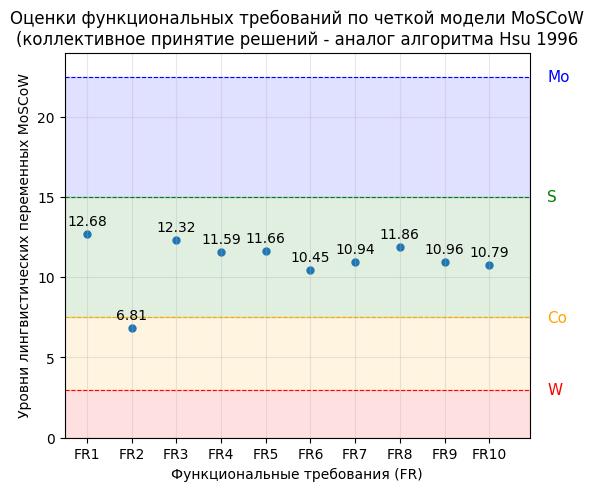

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [group_scores[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW\n(коллективное принятие решений - аналог алгоритма Hsu 1996")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

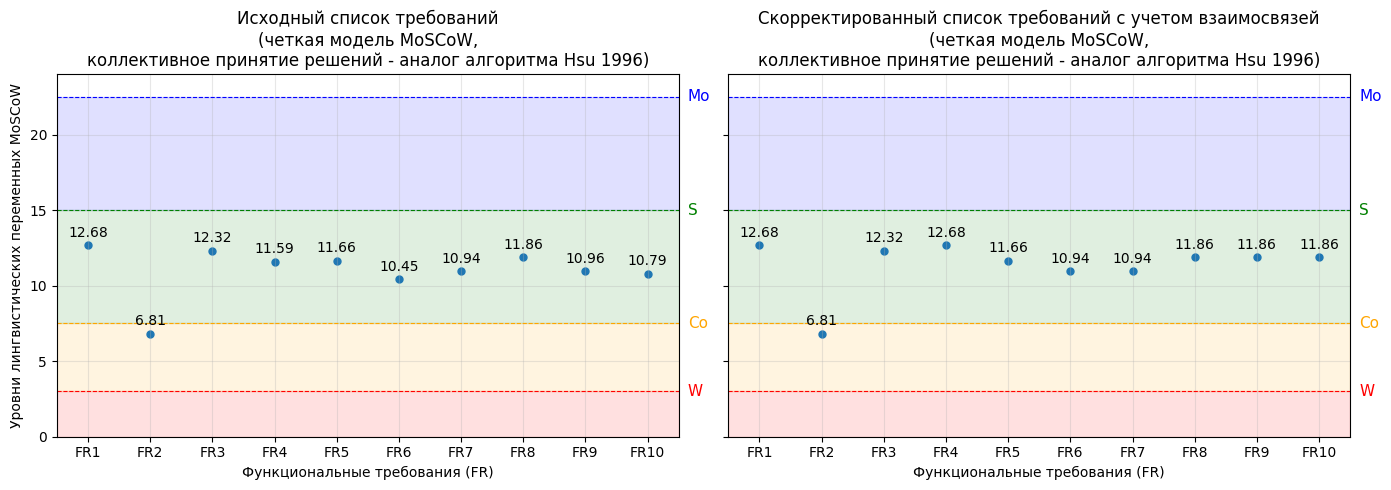

In [171]:
# Преобразуем скорректированный результат в словарь: {FR: adjusted_score}
adjusted_scores_by_fr = {fr: adjusted_val for fr, original_val, adjusted_val in adjusted_ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [group_scores[fr] for fr in fr_labels]
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Hsu 1996)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Hsu 1996)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 24)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [ ]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками.
# Произвольное число экспертов, функциональных требований и критериев их оценки.
# Загрузка и выгрузка из файла/ в файл Excel

import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}


# Парсинг одного листа эксперта из Excel
def parse_expert_sheet(ws):
    name = ws["A1"].value
    if not isinstance(name, str) or not name.strip():
        name = ws.title
    name = name.strip()

    # Ищем строку "Нефункциональное требование..."
    nfr_header_row = None
    for r in range(1, ws.max_row + 1):
        v = ws.cell(r, 1).value
        if isinstance(v, str) and "Нефункциональное требование" in v:
            nfr_header_row = r
            break
    if nfr_header_row is None:
        raise ValueError(f"Не нашла блок NFR в листе: {ws.title}")

    # Имена NFR
    nfr_names = []
    c = 2
    while True:
        v = ws.cell(nfr_header_row, c).value
        if v is None or (isinstance(v, str) and v.strip() == ""):
            break
        nfr_names.append(str(v).strip())
        c += 1
    n = len(nfr_names)
    if n == 0:
        raise ValueError(f"{ws.title}: не найдены имена NFR")

    # Приоритеты NFR в следующей строке
    pr_row = nfr_header_row + 1
    nfr_priorities = []
    for c in range(2, 2 + n):
        v = ws.cell(pr_row, c).value
        if v is None:
            raise ValueError(f"{ws.title}: пустой приоритет NFR (строка {pr_row}, столбец {c})")
        nfr_priorities.append(str(v).strip())

    # Ищем блок FR: строка с "Функциональное требование"
    fr_header_row = None
    for r in range(1, ws.max_row + 1):
        v = ws.cell(r, 1).value
        if isinstance(v, str) and "Функциональное требование" in v:
            fr_header_row = r
            break
    if fr_header_row is None:
        raise ValueError(f"Не нашла блок FR в листе: {ws.title}")

    # Заголовочная строка NFR для FR-таблицы: следующая строка
    fr_nfr_row = fr_header_row + 1

    # FR-строки начинаются еще на строку ниже
    fr_start = fr_nfr_row + 1

    fr_names = []
    frs = []
    r = fr_start
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or (isinstance(fr_name, str) and fr_name.strip() == ""):
            break
        fr_name = str(fr_name).strip()
        fr_names.append(fr_name)

        row_ratings = []
        for c in range(2, 2 + n):
            v = ws.cell(r, c).value
            if v is None:
                raise ValueError(f"{ws.title}: пустая оценка FR={fr_name} (строка {r}, столбец {c})")
            row_ratings.append(str(v).strip())
        frs.append(row_ratings)
        r += 1

    if not fr_names:
        raise ValueError(f"{ws.title}: не найдены FR строки")

    return {"name": name, "nfr": nfr_priorities, "frs": frs, "fr_names": fr_names, "nfr_names": nfr_names}


# Подготовка / расчеты
def normalize_expert_weights(experts, weights, normalize=True):
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 — невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    return names, w_norm, dict(zip(names, w_norm)), dict(zip(names, w_raw))


def moscow_pfr_scores_for_expert(nfr_priorities, fr_vs_nfr_priorities, fr_names):
    nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    scores = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))
    return scores


def prepare_crisp_moscow_inputs(experts, weights, fr_names=None, normalize_weights=True):
    if fr_names is None:
        fr_names = experts[0]["fr_names"]
    fr_names = list(fr_names)

    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    expert_scores = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(e["nfr"], e["frs"], fr_names)

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,
        "expert_scores": expert_scores,
    }

def build_am_matrices_by_fr(prepared):
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    am_by_fr = {}
    for fr in fr_names:
        vals = [float(scores[e][fr]) for e in expert_names]
        k = len(vals)

        am = [[0.0] * k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                a, b = vals[i], vals[j]
                mx = max(a, b)
                if mx == 0.0:
                    am[i][j] = 1.0   # 0/0 -> полное согласие
                else:
                    am[i][j] = min(a, b) / mx
        am_by_fr[fr] = am
    return am_by_fr

def average_agreement_by_fr(AM_by_fr, expert_names):
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта.")

    A_by_fr = {}
    for fr, AM in AM_by_fr.items():
        A_fr = {}
        for i, e in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[e] = s / (k - 1)
        A_by_fr[fr] = A_fr
    return A_by_fr

def rad_by_fr(A_by_fr, expert_names):
    RAD = {}
    for fr, A_fr in A_by_fr.items():
        s = sum(A_fr[e] for e in expert_names)
        if s == 0:
            RAD[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RAD[fr] = {e: A_fr[e] / s for e in expert_names}
    return RAD

def cdc_by_fr(RAD_by_fr, weights_norm_by_name, expert_names, beta=0.4):
    if not (0 <= beta <= 1):
        raise ValueError("beta должен быть в [0,1].")
    CDC = {}
    for fr, RAD_fr in RAD_by_fr.items():
        CDC[fr] = {
            e: beta * float(weights_norm_by_name[e]) + (1 - beta) * float(RAD_fr[e])
            for e in expert_names
        }
    return CDC

def contributions_and_group(prepared, CDC_by_fr):
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    contrib_by_fr = {}
    group = {}
    for fr in fr_names:
        contrib = {e: scores[e][fr] * CDC_by_fr[fr][e] for e in expert_names}
        contrib_by_fr[fr] = contrib
        group[fr] = sum(contrib.values())
    return contrib_by_fr, group


# Выгрузка на новый лист
def _write_table_title(ws, row, title, merge_to_col):
    ws.cell(row, 1, value=title).font = Font(bold=True)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=merge_to_col)
    ws.cell(row, 1).alignment = Alignment(wrap_text=True)
    return row + 1

def _write_headers(ws, row, headers):
    for c, h in enumerate(headers, start=1):
        cell = ws.cell(row, c, value=h)
        cell.font = Font(bold=True)
        cell.alignment = Alignment(wrap_text=True)
    return row + 1

def _autoset_col_width(ws, max_col, min_width=10, max_width=55):
    for c in range(1, max_col + 1):
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, c).value
            if v is None:
                continue
            max_len = max(max_len, len(str(v)))
        ws.column_dimensions[get_column_letter(c)].width = min(max(min_width, max_len + 2), max_width)

def export_crisp_consensus_to_excel(input_xlsx, output_xlsx, weights, beta=0.4, sheet_name="Четкий MoSCoW_коллектив"):
    wb = openpyxl.load_workbook(input_xlsx)

    # 1) читаем экспертов (все листы)
    experts = []
    fr_names = None
    for sname in wb.sheetnames:
        ed = parse_expert_sheet(wb[sname])
        if fr_names is None:
            fr_names = ed["fr_names"]
        experts.append({"name": ed["name"], "nfr": ed["nfr"], "frs": ed["frs"], "fr_names": ed["fr_names"]})

    # 2) считаем алгоритм
    prepared = prepare_crisp_moscow_inputs(experts, weights, fr_names=fr_names)
    AM = build_am_matrices_by_fr(prepared)
    A = average_agreement_by_fr(AM, prepared["expert_names"])
    RAD = rad_by_fr(A, prepared["expert_names"])
    CDC = cdc_by_fr(RAD, prepared["weights_norm"], prepared["expert_names"], beta=beta)
    contrib, group = contributions_and_group(prepared, CDC)

    # 3) создаем лист результата в конце
    if sheet_name in wb.sheetnames:
        wb.remove(wb[sheet_name])
    ws = wb.create_sheet(sheet_name)

    expert_names = prepared["expert_names"]
    fr_list = prepared["fr_names"]
    k = len(expert_names)
    merge_to_col = max(6, 1 + k)

    r = 1
    ws.cell(r, 1, value="Пример применения MoSCoW_четкая модель коллективного принятия решений").font = Font(bold=True)
    ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=merge_to_col)
    r += 2

    # Таблица 1 (веса)
    r = _write_table_title(ws, r, "Таблица 1_Удельные веса оценок экспертов для расчета итоговой взвешенной средней оценки", merge_to_col)
    r = _write_headers(ws, r, ["Перечень экспертов",
                               "Ненормализованные весовые коэффициенты для принятия решения экспертами",
                               "Нормализованные весовые коэффициенты для принятия решения экспертами"])
    for name in expert_names:
        ws.cell(r, 1, value=name)
        ws.cell(r, 2, value=float(prepared["weights_raw"][name]))
        ws.cell(r, 3, value=float(prepared["weights_norm"][name]))
        r += 1
    ws.cell(r, 1, value="Итого").font = Font(bold=True)
    ws.cell(r, 2, value=sum(float(prepared["weights_raw"][n]) for n in expert_names))
    ws.cell(r, 3, value=sum(float(prepared["weights_norm"][n]) for n in expert_names))
    r += 2

    # Таблица 2 (индивидуальные рейтинги)
    r = _write_table_title(ws, r, "Таблица 2_Индивидуальные экспертные рейтинги функциональных задач по MoSCoW", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + [f"Оценка {name}" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(prepared["expert_scores"][name][fr]))
        r += 1
    r += 2

    # beta
    ws.cell(r, 1, value="Коэфициент Бета").font = Font(bold=True)
    ws.cell(r, 2, value=float(beta))
    r += 2

    # Матрицы AM
    ws.cell(r, 1, value="Матрицы согласия (AM)").font = Font(bold=True)
    ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=merge_to_col)
    r += 1
    for fr in fr_list:
        ws.cell(r, 1, value=fr).font = Font(bold=True)
        mat = AM[fr]
        for i in range(k):
            for j in range(k):
                ws.cell(r + i, 2 + j, value=float(mat[i][j]))
        r += k + 1  # пустая строка после матрицы

    # Таблица 3 (Ai)
    r = _write_table_title(ws, r, "Таблица 3_ Средняя степень согласия эксперта (Ai)", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(A[fr][name]))
        r += 1
    r += 2

    # Таблица 4 (RADi)
    r = _write_table_title(ws, r, "Таблица 4_ Относительная степень согласия эксперта (RADi)", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(RAD[fr][name]))
        r += 1
    r += 2

    # Таблица 5 (CDCi)
    r = _write_table_title(ws, r, "Таблица 5_Коэффициент степени консенсуса эксперта CDCi", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(CDC[fr][name]))
        r += 1
    r += 2

    # Таблица 6 (вклады = оценка * CDCi)
    r = _write_table_title(ws, r, "Таблица 6_Коллективный рейтинг функциональных задач", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача"] + [f"Оценка {name}*CDCi" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(contrib[fr][name]))
        r += 1
    r += 2

    # Таблица 7 (сортировка итогов)
    r = _write_table_title(ws, r, "Таблица 7_сортировка коллективного рейтинга функциональных задач по убыванию", merge_to_col)
    r = _write_headers(ws, r, ["Функциональная задача", "Итоговый коллективный рейтинг функциональной задачи"])
    for fr, val in sorted(group.items(), key=lambda x: x[1], reverse=True):
        ws.cell(r, 1, value=fr)
        ws.cell(r, 2, value=float(val))
        r += 1

    _autoset_col_width(ws, max(3, 1 + k))
    wb.save(output_xlsx)


In [ ]:
# Пример запуска
input_path = "Загрузочные данные_MoSCoW_коллектив.xlsx"
output_path = "Итоги_четкий MoSCoW_Hsu 1996.xlsx"

weights = [0.75, 0.75, 1.0]  # ненормализованные веса экспертов, вводятся вручную
beta = 0.4                    # гиперпараметр, вводится вручную

export_crisp_consensus_to_excel(input_path, output_path, weights=weights, beta=beta)
print("Файл сохранен:", output_path)


Файл сохранен: Итоги_четкий MoSCoW_Hsu 1996.xlsx


# 2.3 Коллективное принятие решений (КПР) на основе меры сходства со стандартизированными оценками

# 2.3.1. Fuzzy_MoSCoW + Алгоритм Chen 1998 для коллективного принятия решений

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.tandfonline.com/doi/abs/10.1080/019697298125641

Chen, S. M. Aggregating fuzzy opinions in the group decision-making environment // Cybernetics & Systems. 1998, 29(4). PP. 363-376

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [172]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [173]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [174]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [175]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [176]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [177]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [178]:
# нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задаем нечеткие веса (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразуем NFR-термы в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразуем FR_NFR термы в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FRvsNFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results

In [179]:
# Расширение нечеткого MoSCoW для группы экспертов
EPS = 1e-12

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    """w_i = r_i / sum(r). Если sum(r)=0 -> равные веса."""
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]


def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],       # r_i (ненормализованные)
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    # веса: от raw к norm
    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    # Для каждого эксперта считаем IT2 PFR по всем FR
    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        # pfr_moscow_it2 в коде выше, возвращает список:
        # [{"fr": "FR1", "pfr": IT2}, ...]
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)

        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

In [180]:
# Пример для группы из трех экспертов
# Ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S", "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S", "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

# имена FR (если не задать - будут FR1..FRm)
fr_names = [f"FR{i}" for i in range(1, len(S1["frs"]) + 1)]

prepared_experts = prepare_moscow_it2_inputs(
    experts=experts,
    expert_weights_raw=weights,
    fr_names=fr_names,
    normalize_weights=True,
)

print("Веса экспертов")
print("r (raw):", {e["name"]: round(e["r"], 2) for e in prepared_experts})
print("w (norm):", {e["name"]: round(e["w"], 2) for e in prepared_experts})

print("\nIT2-оценки PFR каждого эксперта по всем FR")
for e in prepared_experts:
    print(f"\nЭксперт {e['name']}:")
    for fr in fr_names:
        print(f"  {fr}: {e['ratings'][fr]}")


Веса экспертов
r (raw): {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
w (norm): {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

IT2-оценки PFR каждого эксперта по всем FR

Эксперт S1:
  FR1: ((6.46, 12.6, 15.81, 20.65), (8.31, 12.6, 15.81, 19.03))
  FR2: ((1.16, 4.46, 9.07, 14.03), (1.81, 4.46, 9.07, 12.43))
  FR3: ((4.0, 7.43, 12.71, 19.96), (5.08, 7.43, 12.71, 17.49))
  FR4: ((5.66, 10.57, 14.55, 20.3), (7.14, 10.57, 14.55, 18.36))
  FR5: ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
  FR6: ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
  FR7: ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
  FR8: ((5.25, 10.35, 14.66, 20.66), (6.83, 10.35, 14.66, 18.63))
  FR9: ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
  FR10: ((2.2, 6.02, 10.75, 16.21), (3.12, 6.02, 10.75, 14.43))

Эксперт S2:
  FR1: ((4.21, 9.89, 15.18, 21.21), (5.67, 9.89, 15.18, 19.23))
  FR2: ((1.16, 5.55, 11.28, 16.77), (1.96, 5.55, 11.28, 15.03))
  FR3: ((7.29, 13.32, 18.39, 25.32), (9.12, 13.32, 18.39, 22

In [181]:
# Нормализация нечетких оценок и гиперпараметров

# IT2 трапеция: ((x1,x2,x3,x4),(x5,x6,x7,x8))
IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]

def normalize_y(y1: float, y2: float) -> tuple[float, float, float]:
    s = y1 + y2
    if s == 0:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    return y1 / s, y2 / s, s

def find_global_m_it2(prepared_experts: Sequence[Dict[str, Any]], fr_names: Sequence[str]) -> float:
    m = 0.0
    for e in prepared_experts:
        for fr in fr_names:
            it2: IT2 = e["ratings"][fr]
            (x1, x2, x3, x4), (x5, x6, x7, x8) = it2
            m = max(m, x4, x8)
    if m <= 0:
        raise ValueError("m должно быть > 0 (ожидаются положительные оценки).")
    return m

def normalize_it2_number(it2: IT2, m: float) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = it2
    return ((x1 / m, x2 / m, x3 / m, x4 / m),
            (x5 / m, x6 / m, x7 / m, x8 / m))

def normalize_it2_ratings_for_prepared_experts(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str]
) -> tuple[List[Dict[str, Any]], float]:
    if not prepared_experts:
        raise ValueError("prepared_experts не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    m = find_global_m_it2(prepared_experts, fr_names)

    new_list: List[Dict[str, Any]] = []
    for e in prepared_experts:
        new_ratings = {fr: normalize_it2_number(e["ratings"][fr], m) for fr in fr_names}
        new_list.append({
            "name": e["name"],
            "r": e.get("r"),
            "w": e["w"],               # уже нормализовано - оставляем как есть
            "ratings": new_ratings     # нормализованные IT2 оценки
        })

    return new_list, m

In [182]:
# Ненормализованные значения гиперпараметов:
# y1 - вес степеней важности экспертов, y2 - вес относительной степени согласия экспертов
y1, y2 = 0.9, 0.6

# 1) нормализуем y1, y2
y1_norm, y2_norm, sum_y = normalize_y(y1, y2)

# 2) нормализуем все IT2-оценки по глобальному m
prepared_experts_norm, m = normalize_it2_ratings_for_prepared_experts(prepared_experts, fr_names)

# вывод
print("1) Нормализация IT2-оценок всех экспертов по всем FR")
print(f"m (макс. правое значение среди всех оценок) = {round(m, 2)}")

for e in prepared_experts_norm:
    print(f"\nЭксперт {e['name']} (w_norm={round(e['w'], 2)}):")
    for fr in fr_names:
        it2 = e["ratings"][fr]
        # округлим для читаемости
        upper, lower = it2
        upper_r = tuple(round(x, 2) for x in upper)
        lower_r = tuple(round(x, 2) for x in lower)
        print(f"  {fr}: {upper_r}, {lower_r})")

print("\n2) Нормализация y1 и y2")
print(f"y1(вес степеней важности экспертов):              {round(y1_norm, 2)}")
print(f"y2(вес относительной степени согласия экспертов): {round(y2_norm, 2)}")


1) Нормализация IT2-оценок всех экспертов по всем FR
m (макс. правое значение среди всех оценок) = 25.32

Эксперт S1 (w_norm=0.3):
  FR1: (0.26, 0.5, 0.62, 0.82), (0.33, 0.5, 0.62, 0.75))
  FR2: (0.05, 0.18, 0.36, 0.55), (0.07, 0.18, 0.36, 0.49))
  FR3: (0.16, 0.29, 0.5, 0.79), (0.2, 0.29, 0.5, 0.69))
  FR4: (0.22, 0.42, 0.57, 0.8), (0.28, 0.42, 0.57, 0.73))
  FR5: (0.18, 0.33, 0.53, 0.8), (0.22, 0.33, 0.53, 0.71))
  FR6: (0.18, 0.36, 0.5, 0.68), (0.22, 0.36, 0.5, 0.63))
  FR7: (0.18, 0.36, 0.5, 0.68), (0.22, 0.36, 0.5, 0.63))
  FR8: (0.21, 0.41, 0.58, 0.82), (0.27, 0.41, 0.58, 0.74))
  FR9: (0.18, 0.33, 0.53, 0.8), (0.22, 0.33, 0.53, 0.71))
  FR10: (0.09, 0.24, 0.42, 0.64), (0.12, 0.24, 0.42, 0.57))

Эксперт S2 (w_norm=0.3):
  FR1: (0.17, 0.39, 0.6, 0.84), (0.22, 0.39, 0.6, 0.76))
  FR2: (0.05, 0.22, 0.45, 0.66), (0.08, 0.22, 0.45, 0.59))
  FR3: (0.29, 0.53, 0.73, 1.0), (0.36, 0.53, 0.73, 0.91))
  FR4: (0.24, 0.47, 0.65, 0.88), (0.3, 0.47, 0.65, 0.81))
  FR5: (0.29, 0.53, 0.73, 1.0), 

In [183]:
# Составление матриц согласия AM для верхних и нижних функций принадлежности каждого функционального требования FRi
Trap = Tuple[float, float, float, float]

def similarity_trap(A: Trap, B: Trap) -> float:
    a1, b1, c1, d1 = A
    a2, b2, c2, d2 = B
    return 1.0 - (abs(a1 - a2) + abs(b1 - b2) + abs(c1 - c2) + abs(d1 - d2)) / 4.0


def similarity_matrix_traps(traps: Sequence[Trap]) -> List[List[float]]:
    n = len(traps)
    if n == 0:
        raise ValueError("traps не должен быть пустым.")
    return [[similarity_trap(traps[i], traps[j]) for j in range(n)] for i in range(n)]


def build_similarity_matrices_it2_for_all_fr(
    prepared_experts_norm: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> tuple[Dict[str, List[List[float]]], Dict[str, List[List[float]]]]:
    if not prepared_experts_norm:
        raise ValueError("prepared_experts_norm не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    S_upper_by_fr: Dict[str, List[List[float]]] = {}
    S_lower_by_fr: Dict[str, List[List[float]]] = {}

    for fr in fr_names:
        uppers: List[Trap] = []
        lowers: List[Trap] = []
        for e in prepared_experts_norm:
            it2: IT2 = e["ratings"][fr]
            upper, lower = it2
            uppers.append(upper)
            lowers.append(lower)

        S_upper_by_fr[fr] = similarity_matrix_traps(uppers)
        S_lower_by_fr[fr] = similarity_matrix_traps(lowers)

    return S_upper_by_fr, S_lower_by_fr


def print_matrices(mats: Dict[str, List[List[float]]], round_to: int = 2) -> None:
    for key in mats:
        print(f"\n{key}:")
        for row in mats[key]:
            print([round(x, round_to) for x in row])

In [184]:
# Запуск
S_upper_by_fr, S_lower_by_fr = build_similarity_matrices_it2_for_all_fr(
    prepared_experts_norm=prepared_experts_norm,
    fr_names=fr_names
)

print("Матрицы сходства (Upper)")
print_matrices(S_upper_by_fr, round_to=2)

print("\n Матрицы сходства (Lower)")
print_matrices(S_lower_by_fr, round_to=2)

Матрицы сходства (Upper)

FR1:
[1.0, 0.94, 0.92]
[0.94, 1.0, 0.95]
[0.92, 0.95, 1.0]

FR2:
[1.0, 0.94, 0.97]
[0.94, 1.0, 0.91]
[0.97, 0.91, 1.0]

FR3:
[1.0, 0.8, 0.96]
[0.8, 1.0, 0.84]
[0.96, 0.84, 1.0]

FR4:
[1.0, 0.94, 0.84]
[0.94, 1.0, 0.79]
[0.84, 0.79, 1.0]

FR5:
[1.0, 0.82, 0.91]
[0.82, 1.0, 0.73]
[0.91, 0.73, 1.0]

FR6:
[1.0, 0.87, 0.85]
[0.87, 1.0, 0.72]
[0.85, 0.72, 1.0]

FR7:
[1.0, 0.87, 0.92]
[0.87, 1.0, 0.79]
[0.92, 0.79, 1.0]

FR8:
[1.0, 0.97, 0.93]
[0.97, 1.0, 0.93]
[0.93, 0.93, 1.0]

FR9:
[1.0, 0.94, 0.91]
[0.94, 1.0, 0.84]
[0.91, 0.84, 1.0]

FR10:
[1.0, 0.82, 0.91]
[0.82, 1.0, 0.92]
[0.91, 0.92, 1.0]

 Матрицы сходства (Lower)

FR1:
[1.0, 0.94, 0.91]
[0.94, 1.0, 0.95]
[0.91, 0.95, 1.0]

FR2:
[1.0, 0.94, 0.97]
[0.94, 1.0, 0.91]
[0.97, 0.91, 1.0]

FR3:
[1.0, 0.79, 0.95]
[0.79, 1.0, 0.84]
[0.95, 0.84, 1.0]

FR4:
[1.0, 0.94, 0.84]
[0.94, 1.0, 0.78]
[0.84, 0.78, 1.0]

FR5:
[1.0, 0.82, 0.92]
[0.82, 1.0, 0.73]
[0.92, 0.73, 1.0]

FR6:
[1.0, 0.87, 0.85]
[0.87, 1.0, 0.72]
[0.85, 

In [185]:
# Вычисление средней степени согласия эксперта A(Ei)

def average_agreement_from_S(
    S: List[List[float]],
    exclude_value: float = 1.0,
    eps: float = 1e-12
) -> List[float]:
    n = len(S)
    if n == 0 or any(len(row) != n for row in S):
        raise ValueError("Матрица S должна быть непустой и квадратной.")

    A: List[float] = []
    for i in range(n):
        vals = [S[i][j] for j in range(n) if abs(S[i][j] - exclude_value) > eps]
        if not vals:
            raise ValueError(f"В строке {i} после исключения {exclude_value} не осталось элементов.")
        A.append(sum(vals) / len(vals))
    return A

def compute_A_for_all_fr(
    S_upper_by_fr: Dict[str, List[List[float]]],
    S_lower_by_fr: Dict[str, List[List[float]]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[float]], Dict[str, List[float]]]:
    A_U_by_fr: Dict[str, List[float]] = {}
    A_L_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in S_upper_by_fr or fr not in S_lower_by_fr:
            raise ValueError(f"Нет матрицы S для {fr}.")
        A_U_by_fr[fr] = average_agreement_from_S(S_upper_by_fr[fr])
        A_L_by_fr[fr] = average_agreement_from_S(S_lower_by_fr[fr])

    return A_U_by_fr, A_L_by_fr

def print_A_by_fr(
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"\n{fr}:")
        print("A_U(Ei):", [round(x, round_to) for x in A_U_by_fr[fr]])
        print("A_L(Ei):", [round(x, round_to) for x in A_L_by_fr[fr]])

In [186]:
A_U_by_fr, A_L_by_fr = compute_A_for_all_fr(
    S_upper_by_fr=S_upper_by_fr,
    S_lower_by_fr=S_lower_by_fr,
    fr_names=fr_names
)

print_A_by_fr(A_U_by_fr, A_L_by_fr, fr_list=fr_names, round_to=2)


FR1:
A_U(Ei): [0.93, 0.94, 0.93]
A_L(Ei): [0.92, 0.95, 0.93]

FR2:
A_U(Ei): [0.95, 0.92, 0.94]
A_L(Ei): [0.95, 0.92, 0.94]

FR3:
A_U(Ei): [0.88, 0.82, 0.9]
A_L(Ei): [0.87, 0.82, 0.9]

FR4:
A_U(Ei): [0.89, 0.86, 0.81]
A_L(Ei): [0.89, 0.86, 0.81]

FR5:
A_U(Ei): [0.87, 0.78, 0.82]
A_L(Ei): [0.87, 0.78, 0.82]

FR6:
A_U(Ei): [0.86, 0.8, 0.79]
A_L(Ei): [0.86, 0.79, 0.78]

FR7:
A_U(Ei): [0.89, 0.83, 0.85]
A_L(Ei): [0.89, 0.83, 0.85]

FR8:
A_U(Ei): [0.95, 0.95, 0.93]
A_L(Ei): [0.95, 0.95, 0.93]

FR9:
A_U(Ei): [0.92, 0.89, 0.88]
A_L(Ei): [0.92, 0.88, 0.88]

FR10:
A_U(Ei): [0.87, 0.87, 0.91]
A_L(Ei): [0.86, 0.87, 0.91]


In [187]:
# Расчет обобщенной средней степени согласия экспертов A(Ei) по обеим функциям принадлежности

def compute_A_general_for_all_fr(
    A_U_by_fr: Dict[str, List[float]],
    A_L_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
    eps: float = 1e-12
) -> Dict[str, List[float]]:
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    A_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in A_U_by_fr:
            raise ValueError(f"Нет A_U_by_fr для {fr}.")
        if fr not in A_L_by_fr:
            raise ValueError(f"Нет A_L_by_fr для {fr}.")

        Au = A_U_by_fr[fr]
        Al = A_L_by_fr[fr]

        if len(Au) != len(Al):
            raise ValueError(f"{fr}: длины A_U и A_L должны совпадать (Au={len(Au)}, Al={len(Al)}).")
        if len(Au) == 0:
            raise ValueError(f"{fr}: списки A_U/A_L не должны быть пустыми.")

        A_by_fr[fr] = [(Au[i] + Al[i]) / 2.0 for i in range(len(Au))]

        # проверка отрицательных значений
        if any((a < -eps) for a in A_by_fr[fr]):
            raise ValueError(f"{fr}: обнаружены отрицательные значения A(Ei). Проверь матрицы сходства.")

    return A_by_fr

def print_A_general_by_fr(
    A_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"{fr}:",[round(x, round_to) for x in A_by_fr[fr]])


In [188]:
# Запуск
A_by_fr = compute_A_general_for_all_fr(
    A_U_by_fr=A_U_by_fr,
    A_L_by_fr=A_L_by_fr,
    fr_names=fr_names
)

print("Обобщенная средняя степень согласия экспертов A(Ei)")
print_A_general_by_fr(A_by_fr, fr_list=fr_names, round_to=2)

Обобщенная средняя степень согласия экспертов A(Ei)
FR1: [0.93, 0.94, 0.93]
FR2: [0.95, 0.92, 0.94]
FR3: [0.87, 0.82, 0.9]
FR4: [0.89, 0.86, 0.81]
FR5: [0.87, 0.78, 0.82]
FR6: [0.86, 0.79, 0.78]
FR7: [0.89, 0.83, 0.85]
FR8: [0.95, 0.95, 0.93]
FR9: [0.92, 0.89, 0.88]
FR10: [0.86, 0.87, 0.91]


In [189]:
# Вычисление относительной степени согласия экспертов RA(Ei)
def relative_agreement(A: Sequence[float], eps: float = 1e-12) -> Tuple[List[float], float]:
    if not A:
        raise ValueError("A не должен быть пустым.")
    sumA = float(sum(A))
    if abs(sumA) <= eps:
        raise ValueError("sum(A) не должно быть равно 0.")
    RA = [float(ai) / sumA for ai in A]
    return RA, sumA


def compute_RA_for_all_fr_general(
    A_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, List[float]], Dict[str, float]]:
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    RA_by_fr: Dict[str, List[float]] = {}
    sumA_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        if fr not in A_by_fr:
            raise ValueError(f"Нет A_by_fr для {fr}.")
        ra, sum_a = relative_agreement(A_by_fr[fr])
        RA_by_fr[fr] = ra
        sumA_by_fr[fr] = sum_a

    return RA_by_fr, sumA_by_fr

def print_RA_general_by_fr(
    RA_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"{fr}:", [round(x, round_to) for x in RA_by_fr[fr]])

In [190]:
# Запуск
RA_by_fr, sumA_by_fr = compute_RA_for_all_fr_general(
    A_by_fr=A_by_fr,
    fr_names=fr_names
)

print("Относительная степень согласия экспертов RA(Ei)")
print_RA_general_by_fr(RA_by_fr, fr_list=fr_names, round_to=2)

Относительная степень согласия экспертов RA(Ei)
FR1: [0.33, 0.34, 0.33]
FR2: [0.34, 0.33, 0.33]
FR3: [0.34, 0.32, 0.35]
FR4: [0.35, 0.34, 0.32]
FR5: [0.35, 0.32, 0.33]
FR6: [0.35, 0.33, 0.32]
FR7: [0.35, 0.32, 0.33]
FR8: [0.34, 0.34, 0.33]
FR9: [0.34, 0.33, 0.33]
FR10: [0.33, 0.33, 0.34]


In [191]:
# Вычисление коэффициента степени консенсуса экспертов C(Ei)

def consensus_coefficients(
    w_norm: Sequence[float],
    ra: Sequence[float],
    y1_norm: float,
    y2_norm: float
) -> List[float]:
    if len(w_norm) != len(ra):
        raise ValueError("Длины w_norm и RA должны совпадать.")
    return [y1_norm * w_norm[i] + y2_norm * ra[i] for i in range(len(ra))]


def extract_w_norm(prepared_experts_norm: Sequence[Dict[str, Any]]) -> List[float]:
    if not prepared_experts_norm:
        return []
    return [float(e["w"]) for e in prepared_experts_norm]


def compute_C_for_all_fr_general(
    prepared_experts_norm: Sequence[Dict[str, Any]],
    RA_by_fr: Dict[str, List[float]],
    fr_names: Sequence[str],
    y1_norm: float,
    y2_norm: float,
) -> Dict[str, List[float]]:
    if not prepared_experts_norm:
        raise ValueError("prepared_experts_norm не должен быть пустым.")
    if not fr_names:
        raise ValueError("fr_names не должен быть пустым.")

    w_norm = extract_w_norm(prepared_experts_norm)
    n_experts = len(w_norm)

    C_by_fr: Dict[str, List[float]] = {}

    for fr in fr_names:
        if fr not in RA_by_fr:
            raise ValueError(f"Нет RA_by_fr для {fr}.")
        if len(RA_by_fr[fr]) != n_experts:
            raise ValueError(
                f"{fr}: длина RA({len(RA_by_fr[fr])}) должна совпадать с числом экспертов ({n_experts})."
            )

        C_by_fr[fr] = consensus_coefficients(w_norm, RA_by_fr[fr], y1_norm, y2_norm)

    return C_by_fr

def print_C_general_by_fr(
    C_by_fr: Dict[str, List[float]],
    fr_list: Sequence[str],
    round_to: int = 3
) -> None:
    for fr in fr_list:
        print(f"{fr}:", [round(x, round_to) for x in C_by_fr[fr]])

In [192]:
# Запуск
C_by_fr = compute_C_for_all_fr_general(
    prepared_experts_norm=prepared_experts_norm,
    RA_by_fr=RA_by_fr,
    fr_names=fr_names,
    y1_norm=y1_norm,
    y2_norm=y2_norm
)

print("Коэффициент степени консенсуса экспертов C(Ei)")
print_C_general_by_fr(C_by_fr, fr_list=fr_names, round_to=2)

Коэффициент степени консенсуса экспертов C(Ei)
FR1: [0.31, 0.31, 0.37]
FR2: [0.32, 0.31, 0.37]
FR3: [0.31, 0.31, 0.38]
FR4: [0.32, 0.31, 0.37]
FR5: [0.32, 0.31, 0.37]
FR6: [0.32, 0.31, 0.37]
FR7: [0.32, 0.31, 0.37]
FR8: [0.31, 0.31, 0.37]
FR9: [0.32, 0.31, 0.37]
FR10: [0.31, 0.31, 0.38]


In [193]:
# Расчет результата агрегирования нечетких мнений R в виде IT2

def aggregate_group_it2_by_fr_general(
    prepared_experts: Sequence[Dict[str, Any]],  # исходные оценки (ненормализованные IT2)
    C_by_fr: Dict[str, List[float]],             # один C(Ei) по каждому FR
    fr_list: Sequence[str] | None = None
) -> Tuple[Dict[str, IT2], List[str]]:
    if not prepared_experts:
        raise ValueError("prepared_experts не должен быть пустым.")

    # если fr_list не задан - берем ключи у первого эксперта
    if fr_list is None:
        fr_list = list(prepared_experts[0]["ratings"].keys())
    fr_list = list(fr_list)

    n_experts = len(prepared_experts)
    zero_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))

    R_group_by_fr: Dict[str, IT2] = {}

    for fr in fr_list:
        if fr not in C_by_fr:
            raise ValueError(f"Нет C_by_fr для {fr}.")

        c = C_by_fr[fr]
        if len(c) != n_experts:
            raise ValueError(f"{fr}: длина C должна совпадать с числом экспертов.")

        total = zero_it2

        for idx, e in enumerate(prepared_experts):
            it2_val: IT2 = e["ratings"][fr]  # исходная IT2-оценка эксперта по FR

            # Один и тот же коэффициент применяем ко всем 8 параметрам IT2
            scaled_it2: IT2 = multiply_fuzzy_number_by_constant(it2_val, c[idx])

            # Суммирование IT2
            total = add_intuitionistic_trapezoidal_fuzzy_numbers(total, scaled_it2)

        R_group_by_fr[fr] = total

    return R_group_by_fr, fr_list

In [194]:
# Запуск
R_group_by_fr, fr_list = aggregate_group_it2_by_fr_general(
    prepared_experts=prepared_experts,  # исходные ненормализованные оценки
    C_by_fr=C_by_fr,
    fr_list=None
)

for fr in fr_list:
    print(f"{fr}: {R_group_by_fr[fr]}")

FR1: ((5.23, 10.74, 14.78, 20.02), (6.77, 10.74, 14.78, 18.27))
FR2: ((0.95, 4.49, 9.45, 14.46), (1.56, 4.49, 9.45, 12.87))
FR3: ((5.31, 10.0, 14.93, 21.74), (6.76, 10.0, 14.93, 19.42))
FR4: ((4.55, 9.29, 13.79, 19.45), (5.81, 9.29, 13.79, 17.57))
FR5: ((4.62, 9.42, 14.15, 20.31), (5.98, 9.42, 14.15, 18.25))
FR6: ((3.78, 8.23, 12.58, 17.67), (4.84, 8.23, 12.58, 16.0))
FR7: ((4.16, 8.8, 13.19, 18.47), (5.31, 8.8, 13.19, 16.73))
FR8: ((4.64, 9.73, 14.11, 19.6), (6.02, 9.73, 14.11, 17.79))
FR9: ((3.93, 8.73, 13.37, 19.08), (5.22, 8.73, 13.37, 17.18))
FR10: ((3.84, 8.62, 13.14, 18.62), (5.11, 8.62, 13.14, 16.81))


In [195]:
# Применяем оператор согласованной линейной редукции типов ко всем групповым нечетким приоритетам
a = 0.6

results_reduction = []
for fr in fr_list:
    reduced = cltr_type_reduction(R_group_by_fr[fr], a)
    results_reduction.append({
        "fr": fr,
        "pfr_it2": R_group_by_fr[fr],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (6.15, 10.74, 14.78, 18.97)
FR2: a=0.6, (1.32, 4.49, 9.45, 13.51)
FR3: a=0.6, (6.18, 10.0, 14.93, 20.35)
FR4: a=0.6, (5.31, 9.29, 13.79, 18.32)
FR5: a=0.6, (5.44, 9.42, 14.15, 19.07)
FR6: a=0.6, (4.42, 8.23, 12.58, 16.67)
FR7: a=0.6, (4.85, 8.8, 13.19, 17.43)
FR8: a=0.6, (5.47, 9.73, 14.11, 18.51)
FR9: a=0.6, (4.7, 8.73, 13.37, 17.94)
FR10: a=0.6, (4.6, 8.62, 13.14, 17.53)


In [196]:
# Применяем альфа-срез ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (9.82; 15.62)
FR2: альфа=0.8, (3.86; 10.26)
FR3: альфа=0.8, (9.24; 16.01)
FR4: альфа=0.8, (8.49; 14.7)
FR5: альфа=0.8, (8.62; 15.13)
FR6: альфа=0.8, (7.47; 13.4)
FR7: альфа=0.8, (8.01; 14.04)
FR8: альфа=0.8, (8.88; 14.99)
FR9: альфа=0.8, (7.92; 14.28)
FR10: альфа=0.8, (7.82; 14.02)


In [197]:
# Вычисляем центроид для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=12.72
2. FR3: centroid=12.62
3. FR8: centroid=11.94
4. FR5: centroid=11.88
5. FR4: centroid=11.59
6. FR9: centroid=11.1
7. FR7: centroid=11.02
8. FR10: centroid=10.92
9. FR6: centroid=10.44
10. FR2: centroid=7.06


Алгоритм учета взаимосвязанности функциональных требований

In [198]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый дефаззифицированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [201]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=12.72, скорректированный centroid=12.72
2. FR4: исходный centroid=11.59, скорректированный centroid=12.72
3. FR3: исходный centroid=12.62, скорректированный centroid=12.62
4. FR8: исходный centroid=11.94, скорректированный centroid=11.94
5. FR9: исходный centroid=11.10, скорректированный centroid=11.94
6. FR10: исходный centroid=10.92, скорректированный centroid=11.94
7. FR5: исходный centroid=11.88, скорректированный centroid=11.88
8. FR7: исходный centroid=11.02, скорректированный centroid=11.02
9. FR6: исходный centroid=10.44, скорректированный centroid=11.02
10. FR2: исходный centroid=7.06, скорректированный centroid=7.06


Визуализации исходного и итогового приоритизированного списков функциональных требований

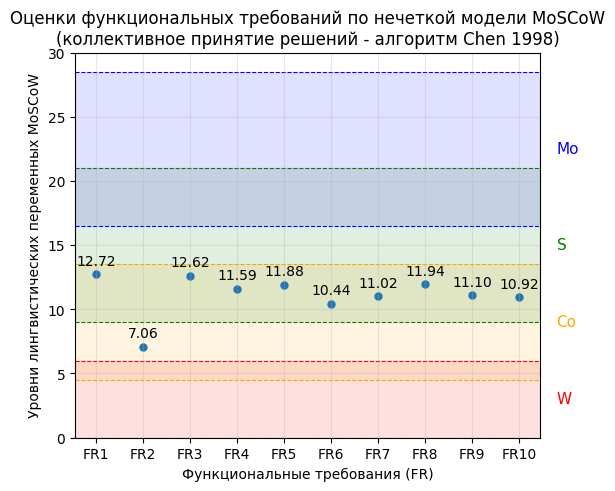

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Преобразуем результаты в словарь: {FR: centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) - 0.2   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW\n(коллективное принятие решений - алгоритм Chen 1998)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

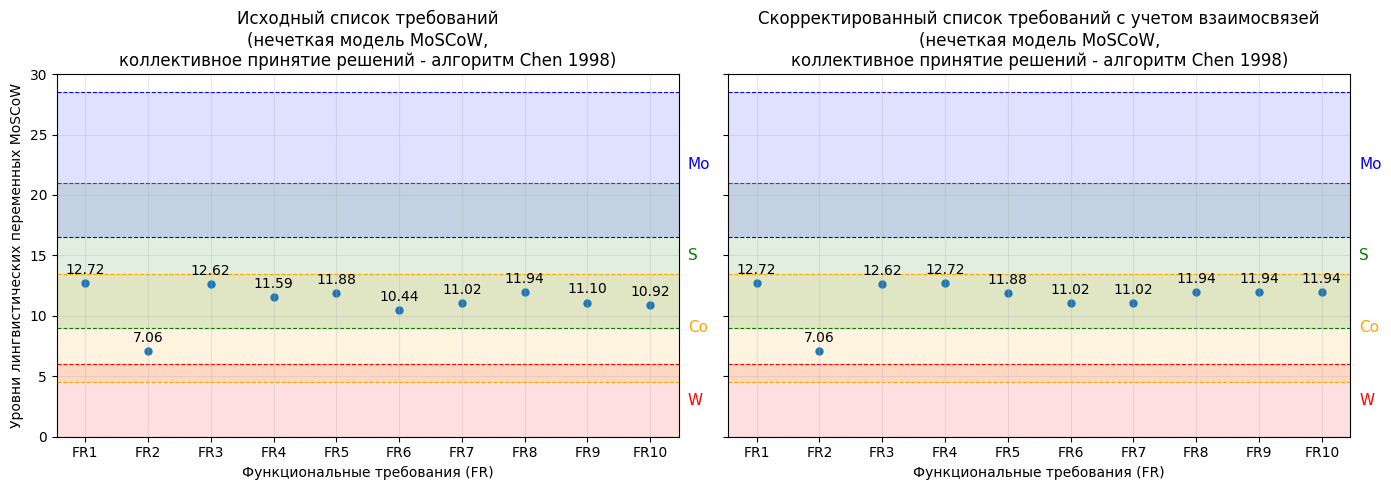

In [203]:
# Преобразуем результаты в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Chen 1998)",
    "Скорректированный список требований с учетом взаимосвязей\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Chen 1998)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл**

In [ ]:
# Версия с загрузкой данных из файла и выгрузкой итогов в файл Excel
from typing import List, Dict, Any, Sequence, Tuple, Optional
import re
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

Trap = Tuple[float, float, float, float]
IT2  = Tuple[Trap, Trap]
EPS = 1e-12

# 1) Математические операции над нечеткими числами
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1: IT2, fuzzy_number2: IT2) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return (
        (round(x1 + y1, 2), round(x2 + y2, 23), round(x3 + y3, 2), round(x4 + y4, 2)),
        (round(x5 + y5, 2), round(x6 + y6, 3), round(x7 + y7, 2), round(x8 + y8, 2)),
    )

def multiply_fuzzy_number_by_constant(fuzzy_number: IT2, constant: float) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        return (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    return (
        (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
        (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
    )

def alpha_cut(fuzzy_number: IT2, alpha: float):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    upper_start = alpha * x2 + (1 - alpha) * x1
    upper_end   = alpha * x3 + (1 - alpha) * x4
    lower_start = alpha * x6 + (1 - alpha) * x5
    lower_end   = alpha * x7 + (1 - alpha) * x8
    return (
        (round(upper_start, 2), round(upper_end, 2)),
        (round(lower_start, 2), round(lower_end, 2)),
    )


# 2) Веса MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8)),
}
MOSCOW_FR_REL_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15)),
}

def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X: IT2, Y: IT2) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))
    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Optional[Sequence[str]] = None,
) -> List[Dict[str, Any]]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[str(x).strip()] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []
    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[str(x).strip()] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2, multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({"fr": name, "pfr": pfr_it2, "ratings": list(fr_row)})
    return results

# 3) Загрузка листов экспертов
_nfr_pat = re.compile(r"^NFR\d+$", re.I)
_fr_pat  = re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str, Any]:
    # 1) строка заголовков NFR
    nfr_header_row = None
    nfr_names: List[str] = []
    nfr_cols: List[int] = []

    for r in range(1, ws.max_row + 1):
        row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        cols = [c for c, v in enumerate(row_vals, start=1) if isinstance(v, str) and _nfr_pat.match(v.strip())]
        if len(cols) >= 2:
            start = min(cols)
            for c in range(start, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip())
                    nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row = r
            break

    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # 2) строка приоритетов NFR
    nfr_priorities_row = nfr_header_row + 1
    nfr_priorities: List[str] = []
    for c in nfr_cols:
        v = ws.cell(nfr_priorities_row, c).value
        if v is None or str(v).strip() == "":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    # 3) шапка FR-таблицы (строка, где есть все NFR1..NFRn)
    fr_header_row = None
    fr_cols: List[int] = []

    for r in range(nfr_priorities_row + 1, ws.max_row + 1):
        vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
        found = {str(v).strip() for v in vals if isinstance(v, str)}
        if all(name in found for name in nfr_names):
            col_map = {}
            for c in range(1, ws.max_column + 1):
                v = ws.cell(r, c).value
                if isinstance(v, str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()] = c
            fr_cols = [col_map[name] for name in nfr_names]
            fr_header_row = r
            break

    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # 4) чтение строк FR
    fr_names: List[str] = []
    fr_matrix: List[List[str]] = []

    r = fr_header_row + 1
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or str(fr_name).strip() == "":
            break
        fr_name = str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break

        row = []
        for c in fr_cols:
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v).strip())

        if any(x != "" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)

        r += 1

    return {"name": ws.title, "nfr": nfr_priorities, "fr_names": fr_names, "frs": fr_matrix}


# 4) Нормализация и расчет степени согласия экспертов
def normalize_y(y1: float, y2: float) -> Tuple[float, float, float]:
    s = y1 + y2
    if abs(s) <= EPS:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    return (y1 / s, y2 / s, s)

def find_global_m_it2(experts_prepared: Sequence[Dict[str, Any]], fr_list: Sequence[str]) -> float:
    m = 0.0
    for e in experts_prepared:
        for fr in fr_list:
            (a,b,c,d), (e2,f,g,h) = e["ratings"][fr]
            m = max(m, float(d), float(h))
    if m <= 0:
        raise ValueError("m должно быть > 0.")
    return m

def normalize_it2_number(it2: IT2, m: float) -> IT2:
    (a,b,c,d), (e,f,g,h) = it2
    return ((a/m, b/m, c/m, d/m), (e/m, f/m, g/m, h/m))

def similarity_trap(A: Trap, B: Trap) -> float:
    a1,b1,c1,d1 = A
    a2,b2,c2,d2 = B
    s = 1.0 - (abs(a1-a2) + abs(b1-b2) + abs(c1-c2) + abs(d1-d2)) / 4.0
    return max(0.0, min(1.0, float(s)))

def similarity_matrix_traps(traps: Sequence[Trap]) -> List[List[float]]:
    n = len(traps)
    return [[similarity_trap(traps[i], traps[j]) for j in range(n)] for i in range(n)]

def average_agreement_from_S(S: List[List[float]], exclude_value: float = 1.0, eps: float = 1e-12) -> List[float]:
    n = len(S)
    A: List[float] = []
    for i in range(n):
        vals = [S[i][j] for j in range(n) if abs(S[i][j] - exclude_value) > eps]
        if not vals:
            raise ValueError(f"В строке {i} после исключения {exclude_value} не осталось элементов.")
        A.append(sum(vals) / len(vals))
    return A

def relative_agreement(A: Sequence[float], eps: float = 1e-12) -> Tuple[List[float], float]:
    if not A:
        raise ValueError("A не должен быть пустым.")
    sumA = float(sum(A))
    if abs(sumA) <= eps:
        raise ValueError("sum(A) не должно быть равно 0.")
    RA = [float(ai) / sumA for ai in A]
    return RA, sumA

def consensus_coefficients(w_norm: Sequence[float], ra: Sequence[float], y1_norm: float, y2_norm: float) -> List[float]:
    if len(w_norm) != len(ra):
        raise ValueError("Длины w_norm и RA должны совпадать.")
    return [y1_norm * w_norm[i] + y2_norm * ra[i] for i in range(len(ra))]

# 5) Дефаззификация
def build_defuzz_rows(pfr_by_fr: Dict[str, IT2], alpha: float) -> List[Dict[str, Any]]:
    rows = []
    for fr, it2 in pfr_by_fr.items():
        (U_alpha, L_alpha) = alpha_cut(it2, alpha)
        u_s, u_e = U_alpha
        l_s, l_e = L_alpha

        mid_U = round((u_s + u_e) / 2, 3)
        mid_L = round((l_s + l_e) / 2, 3)
        avg   = round((mid_U + mid_L) / 2, 3)

        (a,b,c,d), (e,f,g,h) = it2
        rows.append({
            "FR": fr,
            "umf": (a,b,c,d),
            "lmf": (e,f,g,h),
            "u_cut": (u_s,u_e),
            "l_cut": (l_s,l_e),
            "mid_umf": mid_U,
            "mid_lmf": mid_L,
            "avg_mid": avg
        })

    def fr_num(fr: str) -> int:
        try:
            return int(re.sub(r"\D", "", fr))
        except Exception:
            return 0

    return sorted(rows, key=lambda x: (-x["avg_mid"], fr_num(x["FR"])))

# 6) Запись листа с результатами в Excel
def _set_col_width(ws, col_idx: int, width: float):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

def write_weights_block(ws, start_row: int, expert_names: List[str], r_raw: List[float], w_norm: List[float]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.cell(start_row,1).value = "Эксперт"
    ws.cell(start_row,2).value = "Вес_raw (r)"
    ws.cell(start_row,3).value = "Вес_norm (w)"
    for c in [1,2,3]:
        ws.cell(start_row,c).font = bold
        ws.cell(start_row,c).alignment = center

    for i,(nm, rr, ww) in enumerate(zip(expert_names, r_raw, w_norm), start=1):
        rrw = start_row + i
        ws.cell(rrw,1).value = nm
        ws.cell(rrw,2).value = float(rr)
        ws.cell(rrw,3).value = round(float(ww), 2)

    sum_row = start_row + len(expert_names) + 1
    ws.cell(sum_row,1).value = "SUM"
    ws.cell(sum_row,2).value = round(sum(r_raw), 2)
    ws.cell(sum_row,3).value = round(sum(w_norm), 2)
    for c in [1,2,3]:
        ws.cell(sum_row,c).font = bold

    ws.column_dimensions["A"].width = 25.29
    ws.column_dimensions["B"].width = 16
    ws.column_dimensions["C"].width = 16

    return sum_row + 2

def write_alpha_params(ws, start_row: int, alpha: float, y1: float, y2: float, y1n: float, y2n: float) -> int:
    bold = Font(bold=True)
    ws.cell(start_row,1).value = "уровень альфа-среза (alpha)"; ws.cell(start_row,2).value = alpha
    ws.cell(start_row+1,1).value = "y1 (raw)"; ws.cell(start_row+1,2).value = y1
    ws.cell(start_row+2,1).value = "y2 (raw)"; ws.cell(start_row+2,2).value = y2
    ws.cell(start_row+3,1).value = "y1_norm"; ws.cell(start_row+3,2).value = y1n
    ws.cell(start_row+4,1).value = "y2_norm"; ws.cell(start_row+4,2).value = y2n
    for rr in range(start_row, start_row+5):
        ws.cell(rr,1).font = bold
        ws.cell(rr,2).font = bold
    return start_row + 6

def write_result_table(ws, start_row: int, title: str, alpha: float, rows_sorted: List[Dict[str, Any]]) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=17)
    t = ws.cell(start_row,1); t.value = title; t.font = bold; t.alignment = center

    r1, r2 = start_row+1, start_row+2

    ws.merge_cells(start_row=r1, start_column=1, end_row=r2, end_column=1)
    ws.merge_cells(start_row=r1, start_column=2, end_row=r2, end_column=2)
    ws.merge_cells(start_row=r1, start_column=3, end_row=r1, end_column=10)
    ws.merge_cells(start_row=r1, start_column=11, end_row=r1, end_column=14)
    ws.merge_cells(start_row=r1, start_column=15, end_row=r1, end_column=16)
    ws.merge_cells(start_row=r1, start_column=17, end_row=r2, end_column=17)

    ws.cell(r1,1).value="Rank"; ws.cell(r1,2).value="FR"
    ws.cell(r1,3).value="IT2"; ws.cell(r1,11).value=f"alpha-cut ({alpha})"
    ws.cell(r1,15).value="Centroids"; ws.cell(r1,17).value="avg_mid"

    for col in [1,2,3,11,15,17]:
        ws.cell(r1,col).font = bold
        ws.cell(r1,col).alignment = center

    ws.cell(r2,3).value="UMF (a,b,c,d)"
    ws.cell(r2,7).value="LMF (e,f,g,h)"
    ws.cell(r2,11).value="UMF [u1,u2]"
    ws.cell(r2,13).value="LMF [l1,l2]"
    ws.cell(r2,15).value="mid_UMF"
    ws.cell(r2,16).value="mid_LMF"
    for col in [3,7,11,13,15,16]:
        ws.cell(r2,col).font = bold
        ws.cell(r2,col).alignment = center

    data_start = start_row + 3
    for i,item in enumerate(rows_sorted, start=1):
        rr = data_start + (i-1)
        ws.cell(rr,1).value=i
        ws.cell(rr,2).value=item["FR"]
        (a,b,c,d)=item["umf"]; (e,f,g,h)=item["lmf"]
        (u1,u2)=item["u_cut"]; (l1,l2)=item["l_cut"]

        for j,val in enumerate([a,b,c,d], start=3): ws.cell(rr,j).value=round(val, 2)
        for j,val in enumerate([e,f,g,h], start=7): ws.cell(rr,j).value=round(val, 2)

        ws.cell(rr,11).value=round(u1,2); ws.cell(rr,12).value=round(u2,2)
        ws.cell(rr,13).value=round(l1,2); ws.cell(rr,14).value=round(l2,2)
        ws.cell(rr,15).value=round(item["mid_umf"],2)
        ws.cell(rr,16).value=round(item["mid_lmf"],2)
        ws.cell(rr,17).value=round(item["avg_mid"],2)

    _set_col_width(ws,1,10); _set_col_width(ws,2,10)
    for col in range(3,15): _set_col_width(ws,col,14)
    _set_col_width(ws,15,12); _set_col_width(ws,16,12); _set_col_width(ws,17,12)

    return data_start + len(rows_sorted) + 2

def write_dual_matrices_block(ws, start_row: int, title: str, subtitle_left: str, subtitle_right: str,
                             fr_list: List[str], mats_left: Dict[str, List[List[float]]],
                             mats_right: Dict[str, List[List[float]]], k: int) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    left_start = 1
    left_width = 1 + k
    gap = 1
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    c = ws.cell(start_row,1); c.value=title; c.font=bold; c.alignment=center

    ws.merge_cells(start_row=start_row+1, start_column=left_start, end_row=start_row+1, end_column=left_start+left_width-1)
    ws.merge_cells(start_row=start_row+1, start_column=right_start, end_row=start_row+1, end_column=right_start+right_width-1)
    ws.cell(start_row+1,left_start).value = subtitle_left;  ws.cell(start_row+1,left_start).font=bold
    ws.cell(start_row+1,right_start).value = subtitle_right; ws.cell(start_row+1,right_start).font=bold

    r = start_row + 3
    for fr in fr_list:
        M1 = mats_left[fr]; M2 = mats_right[fr]
        ws.cell(r,left_start).value=fr; ws.cell(r,left_start).font=bold
        ws.cell(r,right_start).value=fr; ws.cell(r,right_start).font=bold

        for i in range(k):
            for j in range(k):
                ws.cell(r+i, left_start+1+j).value = round(float(M1[i][j]), 2)
                ws.cell(r+i, right_start+1+j).value = round(float(M2[i][j]), 2)
        r = r + k + 1

    _set_col_width(ws, left_start, 10)
    for cidx in range(left_start+1, left_start+left_width): _set_col_width(ws, cidx, 10)
    _set_col_width(ws, right_start, 10)
    for cidx in range(right_start+1, right_start+right_width): _set_col_width(ws, cidx, 10)

    return r + 1

def write_dual_vectors_block(ws, start_row: int, title: str, subtitle_left: str, subtitle_right: str,
                            fr_list: List[str], vec_left: Dict[str, List[float]], vec_right: Dict[str, List[float]], k: int) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    left_start = 1
    left_width = 1 + k
    gap = 1
    right_start = left_start + left_width + gap
    right_width = 1 + k
    end_col = right_start + right_width - 1

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    c = ws.cell(start_row,1); c.value=title; c.font=bold; c.alignment=center

    ws.merge_cells(start_row=start_row+1, start_column=left_start, end_row=start_row+1, end_column=left_start+left_width-1)
    ws.merge_cells(start_row=start_row+1, start_column=right_start, end_row=start_row+1, end_column=right_start+right_width-1)
    ws.cell(start_row+1,left_start).value=subtitle_left; ws.cell(start_row+1,left_start).font=bold
    ws.cell(start_row+1,right_start).value=subtitle_right; ws.cell(start_row+1,right_start).font=bold

    r = start_row + 3
    for fr in fr_list:
        ws.cell(r,left_start).value=fr; ws.cell(r,left_start).font=bold
        ws.cell(r,right_start).value=fr; ws.cell(r,right_start).font=bold
        for j,val in enumerate(vec_left[fr], start=0):
            ws.cell(r,left_start+1+j).value = round(float(val), 2)
        for j,val in enumerate(vec_right[fr], start=0):
            ws.cell(r,right_start+1+j).value = round(float(val), 2)
        r += 1
    return r + 2

def write_single_vectors_block(ws, start_row: int, title: str,
                              fr_list: List[str], vec: Dict[str, List[float]], k: int) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    end_col = 1 + k
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=end_col)
    c = ws.cell(start_row,1); c.value=title; c.font=bold; c.alignment=center

    r = start_row + 2
    for fr in fr_list:
        ws.cell(r,1).value = fr
        ws.cell(r,1).font = bold
        for j,val in enumerate(vec[fr], start=0):
            ws.cell(r,2+j).value = round(float(val), 2)
        r += 1

    _set_col_width(ws, 1, 10)
    for col in range(2, end_col+1):
        _set_col_width(ws, col, 12)

    return r + 2

# 7) Главная функция (чтение, расчеты, запись результатов)
def run_all_append_one_sheet(
    input_xlsx: str,
    output_xlsx: str,
    weights_raw: List[float],      # порядок = порядок листов-экспертов в файле
    alpha: float,
    y1: float,
    y2: float,
    result_sheet_name: str = "Нечеткий MoSCoW_коллектив",
    skip_sheet_if_name_exists: bool = False,
) -> str:
    wb = load_workbook(input_xlsx)

    experts_loaded: List[Dict[str, Any]] = []
    skipped: List[str] = []

    for sname in wb.sheetnames:
        if sname == result_sheet_name and skip_sheet_if_name_exists:
            continue
        ws = wb[sname]
        try:
            data = load_expert_sheet(ws)
        except ValueError as e:
            if "Не найдена строка заголовков NFR" in str(e):
                skipped.append(sname)
                continue
            raise
        experts_loaded.append(data)

    if not experts_loaded:
        raise ValueError(f"Не найдено листов-экспертов с NFR-шапкой. Пропущено: {skipped}")

    fr_list = experts_loaded[0]["fr_names"]
    for e in experts_loaded[1:]:
        if e["fr_names"] != fr_list:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")

    k = len(experts_loaded)
    if len(weights_raw) != k:
        raise ValueError(f"weights_raw должен быть длины {k} (по числу экспертов/листов).")

    # нормализованные веса экспертов
    sW = sum(float(x) for x in weights_raw)
    w_norm = [1.0/k]*k if sW <= EPS else [float(x)/sW for x in weights_raw]

    # нормализация y1,y2
    y1_norm, y2_norm, _ = normalize_y(y1, y2)

    # PFR IT2 каждого эксперта (исходные оценки)
    experts_prepared: List[Dict[str, Any]] = []
    for e, r_i, w_i in zip(experts_loaded, weights_raw, w_norm):
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_list)
        ratings = {item["fr"]: item["pfr"] for item in res}
        experts_prepared.append({"name": e["name"], "r": float(r_i), "w": float(w_i), "ratings": ratings})

    # глобальное m для нормализации матриц
    m = find_global_m_it2(experts_prepared, fr_list)

    # структуры по FR
    AM_U_by_fr: Dict[str, List[List[float]]] = {}
    AM_L_by_fr: Dict[str, List[List[float]]] = {}
    A_U_by_fr: Dict[str, List[float]] = {}
    A_L_by_fr: Dict[str, List[float]] = {}
    A_by_fr:   Dict[str, List[float]] = {}
    RA_by_fr:  Dict[str, List[float]] = {}
    C_by_fr:   Dict[str, List[float]] = {}

    w_norm_vec = [ex["w"] for ex in experts_prepared]

    for fr in fr_list:
        Rs_norm_it2 = [normalize_it2_number(ex["ratings"][fr], m) for ex in experts_prepared]
        Rs_U = [r[0] for r in Rs_norm_it2]
        Rs_L = [r[1] for r in Rs_norm_it2]

        AM_U = similarity_matrix_traps(Rs_U)
        AM_L = similarity_matrix_traps(Rs_L)
        AM_U_by_fr[fr] = AM_U
        AM_L_by_fr[fr] = AM_L

        A_U = average_agreement_from_S(AM_U)
        A_L = average_agreement_from_S(AM_L)
        A_U_by_fr[fr] = A_U
        A_L_by_fr[fr] = A_L

        # A(Ei) = (A_U + A_L)/2
        A_gen = [(A_U[i] + A_L[i]) / 2.0 for i in range(k)]
        A_by_fr[fr] = A_gen

        # RA(Ei) уже по A(Ei)
        RA, _ = relative_agreement(A_gen)
        RA_by_fr[fr] = RA

        # Расчет C(Ei)
        C_by_fr[fr] = consensus_coefficients(w_norm_vec, RA, y1_norm, y2_norm)

    # Итог группы
    R_group_by_fr: Dict[str, IT2] = {}
    zero_it2: IT2 = ((0.0,0.0,0.0,0.0),(0.0,0.0,0.0,0.0))

    for fr in fr_list:
        total = zero_it2
        for i, ex in enumerate(experts_prepared):
            scaled = multiply_fuzzy_number_by_constant(ex["ratings"][fr], C_by_fr[fr][i])
            total = add_intuitionistic_trapezoidal_fuzzy_numbers(total, scaled)

        (a,b,c,d), (e2,f,g,h) = total
        R_group_by_fr[fr] = (
            (round(a,2),round(b,2),round(c,2),round(d,2)),
            (round(e2,2),round(f,2),round(g,2),round(h,2))
        )

    # Добавление листа в Excel
    if result_sheet_name in wb.sheetnames:
        wb.remove(wb[result_sheet_name])
    ws_out = wb.create_sheet(result_sheet_name)

    r = 1
    expert_names = [e["name"] for e in experts_prepared]

    r = write_weights_block(ws_out, r, expert_names, list(weights_raw), w_norm)
    r = write_alpha_params(ws_out, r, alpha, y1, y2, y1_norm, y2_norm)

    for e in experts_prepared:
        rows_sorted = build_defuzz_rows(e["ratings"], alpha)
        r = write_result_table(ws_out, r, title=f"Эксперт: {e['name']}", alpha=alpha, rows_sorted=rows_sorted)

    r = write_dual_matrices_block(
        ws_out, r,
        title="Матрицы сходства (AM) по Chen'98",
        subtitle_left="AM_UMF (нормированные оценки)",
        subtitle_right="AM_LMF (нормированные оценки)",
        fr_list=fr_list,
        mats_left=AM_U_by_fr,
        mats_right=AM_L_by_fr,
        k=k
    )

    r = write_dual_vectors_block(
        ws_out, r,
        title="Средняя степень согласия эксперта A_U(Ei) и A_L(Ei)",
        subtitle_left="A_U(Ei) по UMF",
        subtitle_right="A_L(Ei) по LMF",
        fr_list=fr_list,
        vec_left=A_U_by_fr,
        vec_right=A_L_by_fr,
        k=k
    )

    r = write_single_vectors_block(
        ws_out, r,
        title="Обобщенная средняя степень согласия экспертов A(Ei)",
        fr_list=fr_list,
        vec=A_by_fr,
        k=k
    )

    r = write_single_vectors_block(
        ws_out, r,
        title="Относительная степень согласия экспертов RA(Ei)",
        fr_list=fr_list,
        vec=RA_by_fr,
        k=k
    )

    r = write_single_vectors_block(
        ws_out, r,
        title=f"Коэффициент степени консенсуса эксперта C(Ei) (y1'={round(y1_norm,3)}, y2'={round(y2_norm,3)})",
        fr_list=fr_list,
        vec=C_by_fr,
        k=k
    )

    rows_sorted_group = build_defuzz_rows(R_group_by_fr, alpha)
    r = write_result_table(ws_out, r, title="Итог группы (R_group_IT2)", alpha=alpha, rows_sorted=rows_sorted_group)

    wb.save(output_xlsx)
    return output_xlsx


In [ ]:
# Запуск
INPUT_XLSX  = r"Загрузочные данные_MoSCoW_коллектив.xlsx"
OUTPUT_XLSX = r"Итоги_Fuzzy MoSCoW_Chen 1998.xlsx"

WEIGHTS_RAW = [0.75, 0.75, 1.0]
ALPHA = 0.8
Y1 = 0.9
Y2 = 0.6

saved_path = run_all_append_one_sheet(
    input_xlsx=INPUT_XLSX,
    output_xlsx=OUTPUT_XLSX,
    weights_raw=WEIGHTS_RAW,
    alpha=ALPHA,
    y1=Y1,
    y2=Y2,
    result_sheet_name="Нечеткий MoSCoW_коллектив",
    skip_sheet_if_name_exists=False
)

print("Файл сохранен:", saved_path)

Файл сохранен: Итоги_Fuzzy MoSCoW_Chen 1998.xlsx


# 2.3.2. Четкий MoSCoW + Аналог алгоритма Chen 1998 (КПР) для сравнения с нечетким алгоритмом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://www.tandfonline.com/doi/abs/10.1080/019697298125641

Chen, S. M. Aggregating fuzzy opinions in the group decision-making environment // Cybernetics & Systems. 1998, 29(4). PP. 363-376

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [204]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке
from typing import Sequence, Any, Dict, Tuple, List, Optional

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)  # {"Mo","S","Co","W"}


def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 — невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # NFR - веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    # FR_NFR - PFR
    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores

def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    # базовые проверки по структуре FR
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # FR names
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса экспертов
    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    # оценки каждого эксперта: {expert - оценки {fr - pfr}}
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,   # список в том же порядке, что expert_names
        "expert_scores": expert_scores,     # ключевой результат шага
        }


In [205]:
# Пример использования (3 эксперта)
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S",  "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S",  "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные

prepared = prepare_crisp_moscow_inputs(experts, weights)

print("Normalized weights:", {k: round(v, 2) for k, v in prepared["weights_norm"].items()})
print()

# Печать
fr_names = prepared["fr_names"]
expert_names = prepared["expert_names"]
expert_scores = prepared["expert_scores"]

for fr in fr_names:
    row = {expert: round(expert_scores[expert][fr], 2) for expert in expert_names}
    print(f"{fr}: {row}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: {'S1': 14.15, 'S2': 12.43, 'S3': 11.62}
FR2: {'S1': 6.6, 'S2': 8.25, 'S3': 5.78}
FR3: {'S1': 9.9, 'S2': 15.75, 'S3': 11.6}
FR4: {'S1': 12.45, 'S2': 14.1, 'S3': 8.28}
FR5: {'S1': 10.75, 'S2': 15.75, 'S3': 9.12}
FR6: {'S1': 10.8, 'S2': 14.1, 'S3': 6.6}
FR7: {'S1': 10.8, 'S2': 14.1, 'S3': 8.28}
FR8: {'S1': 12.45, 'S2': 12.43, 'S3': 10.8}
FR9: {'S1': 10.75, 'S2': 13.28, 'S3': 9.12}
FR10: {'S1': 8.28, 'S2': 13.28, 'S3': 10.78}


In [206]:
# Нормализация входных параметров
from typing import Dict, Any, List, Tuple

def normalize_all_crisp_step1(
    prepared: Dict[str, Any],
    y1: float,
    y2: float,
) -> Dict[str, Any]:
    fr_names: List[str] = list(prepared["fr_names"])
    expert_names: List[str] = list(prepared["expert_names"])
    expert_scores: Dict[str, Dict[str, float]] = prepared["expert_scores"]

    # m = максимальная оценка среди всех экспертов и всех FR
    all_vals: List[float] = []
    for ex in expert_names:
        for fr in fr_names:
            v = float(expert_scores[ex][fr])
            all_vals.append(v)

    if not all_vals:
        raise ValueError("Нет оценок для нормализации (expert_scores пуст).")

    m = max(all_vals)
    if m <= 0:
        raise ValueError("m должно быть > 0 (ожидаются положительные оценки).")

    # нормированные оценки
    scores_norm_by_expert: Dict[str, Dict[str, float]] = {}
    for ex in expert_names:
        scores_norm_by_expert[ex] = {fr: float(expert_scores[ex][fr]) / m for fr in fr_names}

    # нормализация y1 и y2
    s = float(y1) + float(y2)
    if s == 0:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    y1_norm = float(y1) / s
    y2_norm = float(y2) / s

    # веса экспертов уже нормализованы в prepared
    w_norm_list = list(prepared["weights_norm_list"])          # в порядке expert_names
    w_norm_by_expert = dict(prepared["weights_norm"])          # {expert: w}

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,

        "m": m,
        "scores_norm_by_expert": scores_norm_by_expert,

        "y1": float(y1),
        "y2": float(y2),
        "y1_norm": y1_norm,
        "y2_norm": y2_norm,

        "w_norm_list": w_norm_list,
        "w_norm_by_expert": w_norm_by_expert,
    }


def print_step1_summary(
    step1: Dict[str, Any],
    prepared: Dict[str, Any],
    round_to: int = 2
) -> None:
    fr_names = step1["fr_names"]
    expert_names = step1["expert_names"]
    expert_scores = prepared["expert_scores"]
    scores_norm = step1["scores_norm_by_expert"]

    print("1) Нормализация оценок экспертов по всем FR")
    print(f"m (макс. оценка среди всех экспертов и FR) = {step1['m']}")
    for fr in fr_names:
        row_orig = {ex: round(float(expert_scores[ex][fr]), round_to) for ex in expert_names}
        row_norm = {ex: round(float(scores_norm[ex][fr]), round_to) for ex in expert_names}
        print(f"{fr}: norm={row_norm}")

    print("\n2) Нормализация y1 и y2")
    print(f"y1: {step1['y1']} -> {round(step1['y1_norm'], 2)}")
    print(f"y2: {step1['y2']} -> {round(step1['y2_norm'], 2)}")


In [207]:
# Запуск
# y1 - вес степеней важности экспертов, y2 - вес относительной степени согласия экспертов
Y1 = 0.9
Y2 = 0.6

step1 = normalize_all_crisp_step1(prepared, y1=Y1, y2=Y2)
print_step1_summary(step1, prepared)

1) Нормализация оценок экспертов по всем FR
m (макс. оценка среди всех экспертов и FR) = 15.75
FR1: norm={'S1': 0.9, 'S2': 0.79, 'S3': 0.74}
FR2: norm={'S1': 0.42, 'S2': 0.52, 'S3': 0.37}
FR3: norm={'S1': 0.63, 'S2': 1.0, 'S3': 0.74}
FR4: norm={'S1': 0.79, 'S2': 0.9, 'S3': 0.53}
FR5: norm={'S1': 0.68, 'S2': 1.0, 'S3': 0.58}
FR6: norm={'S1': 0.69, 'S2': 0.9, 'S3': 0.42}
FR7: norm={'S1': 0.69, 'S2': 0.9, 'S3': 0.53}
FR8: norm={'S1': 0.79, 'S2': 0.79, 'S3': 0.69}
FR9: norm={'S1': 0.68, 'S2': 0.84, 'S3': 0.58}
FR10: norm={'S1': 0.53, 'S2': 0.84, 'S3': 0.68}

2) Нормализация y1 и y2
y1: 0.9 -> 0.6
y2: 0.6 -> 0.4


In [208]:
# Матрицы согласия для четкого случая:
from typing import Dict, Any, List

def similarity_matrix_crisp_abs(norm_scores: List[float]) -> List[List[float]]:
    k = len(norm_scores)
    S = [[0.0] * k for _ in range(k)]
    for i in range(k):
        for j in range(k):
            S[i][j] = 1.0 - abs(norm_scores[i] - norm_scores[j])
    return S


def build_AM_by_fr_crisp(
    step1: Dict[str, Any],
) -> Dict[str, List[List[float]]]:
    fr_names: List[str] = step1["fr_names"]
    expert_names: List[str] = step1["expert_names"]
    scores_norm_by_expert: Dict[str, Dict[str, float]] = step1["scores_norm_by_expert"]

    AM_by_fr: Dict[str, List[List[float]]] = {}
    for fr in fr_names:
        vec = [float(scores_norm_by_expert[ex][fr]) for ex in expert_names]  # в порядке expert_names
        AM_by_fr[fr] = similarity_matrix_crisp_abs(vec)

    return AM_by_fr

def print_AM_by_fr(
    AM_by_fr: Dict[str, List[List[float]]],
    fr_list: List[str],
    round_to: int = 2
) -> None:
    for fr in fr_list:
        print(f"\n{fr}:")
        for row in AM_by_fr[fr]:
            print([round(x, round_to) for x in row])


In [209]:
# Пример запуска:
AM_by_fr = build_AM_by_fr_crisp(step1)
print_AM_by_fr(AM_by_fr, fr_list=step1["fr_names"], round_to=2)


FR1:
[1.0, 0.89, 0.84]
[0.89, 1.0, 0.95]
[0.84, 0.95, 1.0]

FR2:
[1.0, 0.9, 0.95]
[0.9, 1.0, 0.84]
[0.95, 0.84, 1.0]

FR3:
[1.0, 0.63, 0.89]
[0.63, 1.0, 0.74]
[0.89, 0.74, 1.0]

FR4:
[1.0, 0.9, 0.73]
[0.9, 1.0, 0.63]
[0.73, 0.63, 1.0]

FR5:
[1.0, 0.68, 0.9]
[0.68, 1.0, 0.58]
[0.9, 0.58, 1.0]

FR6:
[1.0, 0.79, 0.73]
[0.79, 1.0, 0.52]
[0.73, 0.52, 1.0]

FR7:
[1.0, 0.79, 0.84]
[0.79, 1.0, 0.63]
[0.84, 0.63, 1.0]

FR8:
[1.0, 1.0, 0.9]
[1.0, 1.0, 0.9]
[0.9, 0.9, 1.0]

FR9:
[1.0, 0.84, 0.9]
[0.84, 1.0, 0.74]
[0.9, 0.74, 1.0]

FR10:
[1.0, 0.68, 0.84]
[0.68, 1.0, 0.84]
[0.84, 0.84, 1.0]


In [210]:
# Средняя степень согласия экспертов A_i
# Ai(fr) = среднее AM_ij по j != i

from typing import Dict, List

def average_agreement_by_fr(
    AM_by_fr: Dict[str, List[List[float]]],
    expert_names: List[str],
) -> Dict[str, Dict[str, float]]:
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr: Dict[str, Dict[str, float]] = {}

    for fr, AM in AM_by_fr.items():
        if len(AM) != k or any(len(row) != k for row in AM):
            raise ValueError(f"{fr}: матрица AM должна быть размера {k}x{k}.")

        A_fr: Dict[str, float] = {}
        for i, name in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[name] = s / (k - 1)
        A_by_fr[fr] = A_fr

    return A_by_fr

In [211]:
# Запуск
fr_list = step1["fr_names"]
expert_names = step1["expert_names"]

# AM_by_fr посчитан на прошлом шаге
A_by_fr = average_agreement_by_fr(AM_by_fr, expert_names)

print("Средняя степень согласия экспертов (Ai) по каждому FR:")
for fr in fr_list:
    row = {e: round(A_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}: {row}")

Средняя степень согласия экспертов (Ai) по каждому FR:
FR1: {'S1': 0.87, 'S2': 0.92, 'S3': 0.89}
FR2: {'S1': 0.92, 'S2': 0.87, 'S3': 0.9}
FR3: {'S1': 0.76, 'S2': 0.68, 'S3': 0.81}
FR4: {'S1': 0.82, 'S2': 0.76, 'S3': 0.68}
FR5: {'S1': 0.79, 'S2': 0.63, 'S3': 0.74}
FR6: {'S1': 0.76, 'S2': 0.66, 'S3': 0.63}
FR7: {'S1': 0.82, 'S2': 0.71, 'S3': 0.73}
FR8: {'S1': 0.95, 'S2': 0.95, 'S3': 0.9}
FR9: {'S1': 0.87, 'S2': 0.79, 'S3': 0.82}
FR10: {'S1': 0.76, 'S2': 0.76, 'S3': 0.84}


In [212]:
# Относительные степени согласия экспертов RA(Ei) по каждому FR
# RA_i(fr) = A_i(fr) / sum_i A_i(fr)

from typing import Dict, List

def ra_by_fr(
    A_by_fr: Dict[str, Dict[str, float]],
    expert_names: List[str],
) -> Dict[str, Dict[str, float]]:
    if not expert_names:
        raise ValueError("expert_names не должен быть пустым.")

    RA_by_fr: Dict[str, Dict[str, float]] = {}

    for fr, A_fr in A_by_fr.items():
        s = sum(float(A_fr[e]) for e in expert_names)
        if s == 0:
            # если сумма равна нулю, присваиваем равные доли
            RA_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RA_by_fr[fr] = {e: float(A_fr[e]) / s for e in expert_names}

    return RA_by_fr

In [213]:
# Запуск:
RA_by_fr = ra_by_fr(A_by_fr, expert_names)

print("RA(Ei) по каждому FR:")
for fr in fr_list:
    row = {e: round(RA_by_fr[fr][e], 2) for e in expert_names}
    print(f"{fr}: {row}")


RA(Ei) по каждому FR:
FR1: {'S1': 0.32, 'S2': 0.34, 'S3': 0.33}
FR2: {'S1': 0.34, 'S2': 0.32, 'S3': 0.33}
FR3: {'S1': 0.34, 'S2': 0.3, 'S3': 0.36}
FR4: {'S1': 0.36, 'S2': 0.34, 'S3': 0.3}
FR5: {'S1': 0.37, 'S2': 0.29, 'S3': 0.34}
FR6: {'S1': 0.37, 'S2': 0.32, 'S3': 0.31}
FR7: {'S1': 0.36, 'S2': 0.31, 'S3': 0.33}
FR8: {'S1': 0.34, 'S2': 0.34, 'S3': 0.32}
FR9: {'S1': 0.35, 'S2': 0.32, 'S3': 0.33}
FR10: {'S1': 0.32, 'S2': 0.32, 'S3': 0.36}


In [214]:
# Коэффициент степени консенсуса экспертов C(Ei) по каждому FR:
# C_i(fr) = y1_norm * w_i_norm + y2_norm * RA_i(fr)

from typing import Dict, List

def C_by_fr(
    RA_by_fr: Dict[str, Dict[str, float]],
    weights_norm_by_name: Dict[str, float],   # prepared["weights_norm"]
    expert_names: List[str],
    y1_norm: float,
    y2_norm: float,
) -> Dict[str, Dict[str, float]]:
    if not (0.0 <= y1_norm <= 1.0 and 0.0 <= y2_norm <= 1.0):
        raise ValueError("y1_norm и y2_norm должны быть в диапазоне [0,1].")
    if abs((y1_norm + y2_norm) - 1.0) > 1e-9:
        raise ValueError("Ожидается, что y1_norm + y2_norm = 1 (после нормализации).")

    C_by_fr_out: Dict[str, Dict[str, float]] = {}
    for fr, RA_fr in RA_by_fr.items():
        C_by_fr_out[fr] = {
            e: y1_norm * float(weights_norm_by_name[e]) + y2_norm * float(RA_fr[e])
            for e in expert_names
        }
    return C_by_fr_out

In [215]:
# Запуск
C_by_fr_out = C_by_fr(
    RA_by_fr=RA_by_fr,
    weights_norm_by_name=prepared["weights_norm"],
    expert_names=expert_names,
    y1_norm=step1["y1_norm"],
    y2_norm=step1["y2_norm"],
)

print(f"C(Ei) по каждому FR (y1_norm={step1['y1_norm']:.3f}, y2_norm={step1['y2_norm']:.3f}):")
for fr in fr_list:
    row = {e: round(C_by_fr_out[fr][e], 2) for e in expert_names}
    print(f"{fr}: {row}")


C(Ei) по каждому FR (y1_norm=0.600, y2_norm=0.400):
FR1: {'S1': 0.31, 'S2': 0.32, 'S3': 0.37}
FR2: {'S1': 0.32, 'S2': 0.31, 'S3': 0.37}
FR3: {'S1': 0.31, 'S2': 0.3, 'S3': 0.38}
FR4: {'S1': 0.32, 'S2': 0.31, 'S3': 0.36}
FR5: {'S1': 0.33, 'S2': 0.3, 'S3': 0.38}
FR6: {'S1': 0.33, 'S2': 0.31, 'S3': 0.36}
FR7: {'S1': 0.32, 'S2': 0.31, 'S3': 0.37}
FR8: {'S1': 0.32, 'S2': 0.32, 'S3': 0.37}
FR9: {'S1': 0.32, 'S2': 0.31, 'S3': 0.37}
FR10: {'S1': 0.31, 'S2': 0.31, 'S3': 0.38}


In [216]:
# Коллективная агрегированная оценка
# R_group(fr) = sum_i [ C_i(fr) * (PFR_i(fr), ненормализованный) ]

from typing import Dict, List, Tuple

def aggregate_group_pfr_by_C(
    expert_scores_raw: Dict[str, Dict[str, float]],   # prepared["expert_scores"] (raw PFR)
    C_by_fr: Dict[str, Dict[str, float]],             # C_by_fr_out
    fr_names: List[str],
    expert_names: List[str],
) -> Dict[str, float]:
    group_scores: Dict[str, float] = {}

    for fr in fr_names:
        s = 0.0
        for e in expert_names:
            s += float(expert_scores_raw[e][fr]) * float(C_by_fr[fr][e])
        group_scores[fr] = s

    return group_scores

In [217]:
# Запуск
group_scores = aggregate_group_pfr_by_C(
    expert_scores_raw=prepared["expert_scores"],   # Ненормализованные оценки
    C_by_fr=C_by_fr_out,                           # коэффициенты консенсуса C(Ei)
    fr_names=prepared["fr_names"],
    expert_names=prepared["expert_names"],
)

print("Групповые приоритеты FR (взвешивание по C(Ei)):")
for fr in prepared["fr_names"]:
    print(f"{fr}: {group_scores[fr]:.2f}")

# Ранжирование:
ranked = sorted(group_scores.items(), key=lambda x: x[1], reverse=True)
print("\nРанжирование:")
for fr, val in ranked:
    print(f"{fr}: {val:.2f}")

Групповые приоритеты FR (взвешивание по C(Ei)):
FR1: 12.66
FR2: 6.80
FR3: 12.31
FR4: 11.46
FR5: 11.62
FR6: 10.29
FR7: 10.87
FR8: 11.83
FR9: 10.92
FR10: 10.77

Ранжирование:
FR1: 12.66
FR3: 12.31
FR8: 11.83
FR5: 11.62
FR4: 11.46
FR9: 10.92
FR7: 10.87
FR10: 10.77
FR6: 10.29
FR2: 6.80


Алгоритм учета взаимосвязанности функциональных требований

In [218]:
def adjust_crisp_scores_by_interdependencies(
    group_scores: Dict[str, float],
    relation_matrix: Sequence[Sequence[int]],
) -> List[tuple[str, float, float]]:
    """
    Корректирует итоговые групповые оценки FR с учетом взаимосвязи требований.

    group_scores: словарь вида {"FR1": value1, "FR2": value2, ...}
    relation_matrix задается в исходном порядке требований: FR1, FR2, ..., FRn

    Возвращает список кортежей:
    (fr, исходная_оценка, скорректированная_оценка),
    отсортированный по убыванию скорректированной оценки.
    """

    fr_names = list(group_scores.keys())
    n = len(fr_names)

    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(fr) for fr in fr_names]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в group_scores должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    original_scores = {fr: group_scores[fr] for fr in group_scores}
    adjusted_scores = {fr: group_scores[fr] for fr in group_scores}

    matrix_idx_to_fr = {fr_to_index(fr): fr for fr in group_scores}

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(original_scores[matrix_idx_to_fr[i]] for i in comp)
        for i in comp:
            adjusted_scores[matrix_idx_to_fr[i]] = max_score

    adjusted_ranked = sorted(
        [(fr, original_scores[fr], adjusted_scores[fr]) for fr in group_scores],
        key=lambda x: x[2],
        reverse=True
    )

    return adjusted_ranked

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [219]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_ranked = adjust_crisp_scores_by_interdependencies(group_scores, relation_matrix)

print("Скорректированное ранжирование:")
for fr, original_val, adjusted_val in adjusted_ranked:
    print(
        f"{fr}: "
        f"исходная оценка = {original_val:.2f}, "
        f"скорректированная оценка = {adjusted_val:.2f}"
    )

Скорректированное ранжирование:
FR1: исходная оценка = 12.66, скорректированная оценка = 12.66
FR4: исходная оценка = 11.46, скорректированная оценка = 12.66
FR3: исходная оценка = 12.31, скорректированная оценка = 12.31
FR8: исходная оценка = 11.83, скорректированная оценка = 11.83
FR9: исходная оценка = 10.92, скорректированная оценка = 11.83
FR10: исходная оценка = 10.77, скорректированная оценка = 11.83
FR5: исходная оценка = 11.62, скорректированная оценка = 11.62
FR6: исходная оценка = 10.29, скорректированная оценка = 10.87
FR7: исходная оценка = 10.87, скорректированная оценка = 10.87
FR2: исходная оценка = 6.80, скорректированная оценка = 6.80


Визуализации исходного и итогового приоритизированного списков функциональных требований

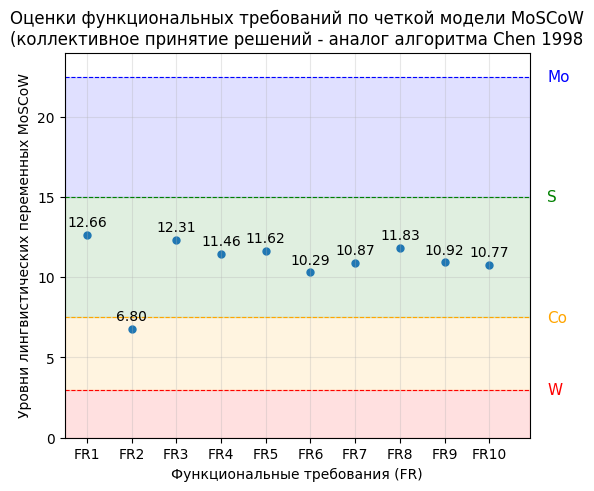

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [group_scores[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW\n(коллективное принятие решений - аналог алгоритма Chen 1998")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

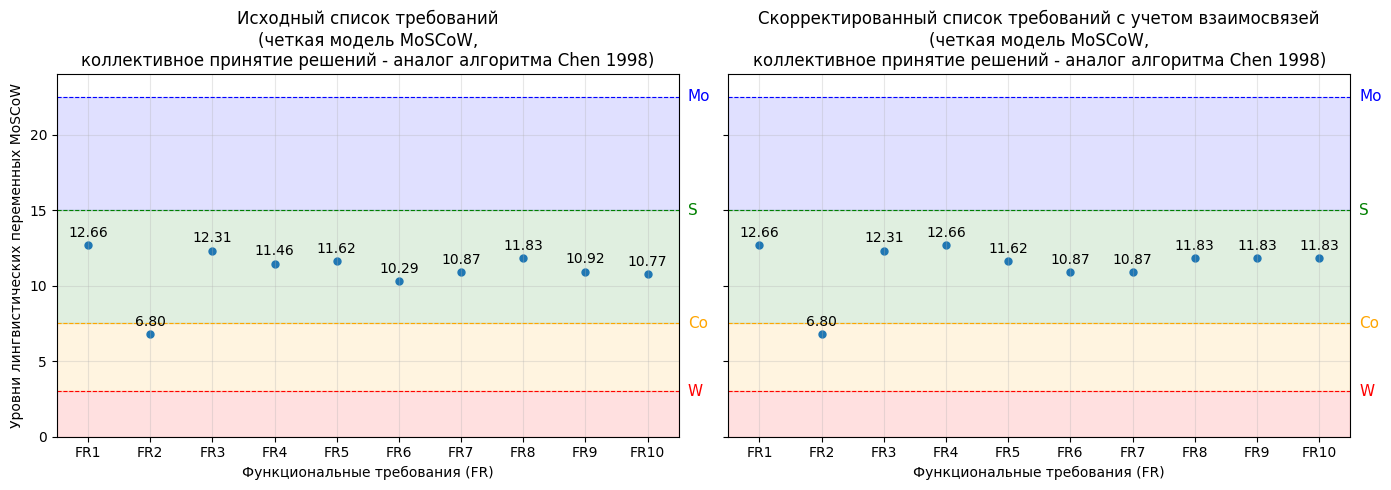

In [222]:
# Преобразуем скорректированный результат в словарь: {FR: adjusted_score}
adjusted_scores_by_fr = {fr: adjusted_val for fr, original_val, adjusted_val in adjusted_ranked}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [group_scores[fr] for fr in fr_labels]
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Chen 1998)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Chen 1998)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 24)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка из файла/ в файл Excel**

In [ ]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками.
# Произвольное число экспертов, функциональных требований и критериев их оценки.
# Загрузка и выгрузка из файла/ в файл Excel

import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter


# 1) Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS.keys())


# 2) Парсинг листа эксперта
def parse_expert_sheet(ws):
    name = ws["A1"].value
    if not isinstance(name, str) or not name.strip():
        name = ws.title
    name = name.strip()

    # Ищем строку "Нефункциональное требование..."
    nfr_header_row = None
    for r in range(1, ws.max_row + 1):
        v = ws.cell(r, 1).value
        if isinstance(v, str) and "Нефункциональное требование" in v:
            nfr_header_row = r
            break
    if nfr_header_row is None:
        raise ValueError(f"Не найден блок NFR в листе: {ws.title}")

    # Имена NFR (со 2-го столбца)
    nfr_names = []
    c = 2
    while True:
        v = ws.cell(nfr_header_row, c).value
        if v is None or (isinstance(v, str) and v.strip() == ""):
            break
        nfr_names.append(str(v).strip())
        c += 1
    n = len(nfr_names)
    if n == 0:
        raise ValueError(f"{ws.title}: не найдены имена NFR")

    # Приоритеты NFR в следующей строке
    pr_row = nfr_header_row + 1
    nfr_priorities = []
    for c in range(2, 2 + n):
        v = ws.cell(pr_row, c).value
        if v is None:
            raise ValueError(f"{ws.title}: пустой приоритет NFR (строка {pr_row}, столбец {c})")
        nfr_priorities.append(str(v).strip())

    # Ищем блок FR: строка с "Функциональное требование"
    fr_header_row = None
    for r in range(1, ws.max_row + 1):
        v = ws.cell(r, 1).value
        if isinstance(v, str) and "Функциональное требование" in v:
            fr_header_row = r
            break
    if fr_header_row is None:
        raise ValueError(f"Не найден блок FR в листе: {ws.title}")

    fr_nfr_row = fr_header_row + 1      # строка с NFR1..NFRn для FR-таблицы
    fr_start = fr_nfr_row + 1           # строки FR начинаются ниже

    fr_names = []
    frs = []
    r = fr_start
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or (isinstance(fr_name, str) and fr_name.strip() == ""):
            break
        fr_name = str(fr_name).strip()
        fr_names.append(fr_name)

        row_ratings = []
        for c in range(2, 2 + n):
            v = ws.cell(r, c).value
            if v is None:
                raise ValueError(f"{ws.title}: пустая оценка FR={fr_name} (строка {r}, столбец {c})")
            row_ratings.append(str(v).strip())
        frs.append(row_ratings)
        r += 1

    if not fr_names:
        raise ValueError(f"{ws.title}: не найдены FR строки")

    return {"name": name, "nfr": nfr_priorities, "frs": frs, "fr_names": fr_names, "nfr_names": nfr_names}


# 3) Веса экспертов
def normalize_expert_weights(experts, weights, normalize=True):
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    return names, w_norm, dict(zip(names, w_norm)), dict(zip(names, w_raw))


# 4) PFR одного эксперта
def moscow_pfr_scores_for_expert(nfr_priorities, fr_vs_nfr_priorities, fr_names):
    # NFR - веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    scores = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")
        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))
    return scores


# 5) Подготовка входа
def prepare_crisp_moscow_inputs(experts, weights, fr_names=None, normalize_weights=True):
    if fr_names is None:
        fr_names = experts[0]["fr_names"]
    fr_names = list(fr_names)

    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    expert_scores = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(e["nfr"], e["frs"], fr_names)

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,
        "expert_scores": expert_scores,  # PFR_raw
    }

# 6) Нормализация PFR по m
def compute_m_max(prepared) -> float:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    all_vals = []
    for fr in fr_names:
        for e in expert_names:
            all_vals.append(float(scores[e][fr]))
    if not all_vals:
        raise ValueError("Нет PFR значений для поиска m.")
    m = max(all_vals)
    if m <= 0:
        raise ValueError("m должно быть > 0.")
    return m

def normalize_scores_by_m(prepared, m: float) -> dict[str, dict[str, float]]:
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores = prepared["expert_scores"]

    norm_scores = {}
    for e in expert_names:
        norm_scores[e] = {fr: float(scores[e][fr]) / float(m) for fr in fr_names}
    return norm_scores


def normalize_y(y1: float, y2: float) -> tuple[float, float, float]:
    s = float(y1) + float(y2)
    if s == 0:
        raise ValueError("y1 + y2 не должно быть равно 0.")
    return float(y1) / s, float(y2) / s, s

# 7) Матрицы согласия AM
def build_am_matrices_by_fr_norm_scores(fr_names, expert_names, norm_scores):
    am_by_fr = {}
    for fr in fr_names:
        vals = [float(norm_scores[e][fr]) for e in expert_names]
        k = len(vals)
        am = [[0.0] * k for _ in range(k)]
        for i in range(k):
            for j in range(k):
                am[i][j] = 1.0 - abs(vals[i] - vals[j])
        am_by_fr[fr] = am
    return am_by_fr

# 8) A(Ei), RA(Ei), C(Ei)
def average_agreement_by_fr(AM_by_fr, expert_names):
    k = len(expert_names)
    if k < 2:
        raise ValueError("Нужно минимум 2 эксперта для расчета степени согласия.")

    A_by_fr = {}
    for fr, AM in AM_by_fr.items():
        if len(AM) != k or any(len(row) != k for row in AM):
            raise ValueError(f"{fr}: матрица AM должна быть размера {k}x{k}.")
        A_fr = {}
        for i, name in enumerate(expert_names):
            s = sum(AM[i][j] for j in range(k) if j != i)
            A_fr[name] = s / (k - 1)
        A_by_fr[fr] = A_fr
    return A_by_fr

def ra_by_fr(A_by_fr, expert_names):
    RA_by_fr = {}
    for fr, A_fr in A_by_fr.items():
        s = sum(float(A_fr[e]) for e in expert_names)
        if s == 0:
            RA_by_fr[fr] = {e: 1.0 / len(expert_names) for e in expert_names}
        else:
            RA_by_fr[fr] = {e: float(A_fr[e]) / s for e in expert_names}
    return RA_by_fr


def c_by_fr(RA_by_fr, weights_norm_by_name, expert_names, y1_norm: float, y2_norm: float):
    C_by_fr = {}
    for fr, RA_fr in RA_by_fr.items():
        C_by_fr[fr] = {
            e: float(y1_norm) * float(weights_norm_by_name[e]) + float(y2_norm) * float(RA_fr[e])
            for e in expert_names
        }
    return C_by_fr


# 9) Вклады и итог группы
def contributions_and_group(prepared, C_by_fr):
    fr_names = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    scores_raw = prepared["expert_scores"]

    contrib_by_fr = {}
    group = {}
    for fr in fr_names:
        contrib = {e: float(scores_raw[e][fr]) * float(C_by_fr[fr][e]) for e in expert_names}
        contrib_by_fr[fr] = contrib
        group[fr] = sum(contrib.values())
    return contrib_by_fr, group


# 10) Оформление листа в Excel
def _write_table_title(ws, row, title, merge_to_col):
    ws.cell(row, 1, value=title).font = Font(bold=True)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=merge_to_col)
    ws.cell(row, 1).alignment = Alignment(wrap_text=True, horizontal="center", vertical="center")
    return row + 1


def _write_headers(ws, row, headers):
    for c, h in enumerate(headers, start=1):
        cell = ws.cell(row, c, value=h)
        cell.font = Font(bold=True)
        cell.alignment = Alignment(wrap_text=True, horizontal="center", vertical="center")
    return row + 1


def _autoset_col_width(ws, max_col, min_width=10, max_width=55):
    for c in range(1, max_col + 1):
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, c).value
            if v is None:
                continue
            max_len = max(max_len, len(str(v)))
        ws.column_dimensions[get_column_letter(c)].width = min(max(min_width, max_len + 2), max_width)


def write_y_block(ws, start_row: int, m: float, y1_raw: float, y2_raw: float, y1_norm: float, y2_norm: float) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=3)
    t = ws.cell(start_row, 1, value="Нормализация параметров (для матриц согласия и C(Ei))")
    t.font = bold
    t.alignment = center
    r = start_row + 1

    ws.cell(r, 1, value="m = max(PFR) по всем экспертам и FR").font = bold
    ws.cell(r, 2, value=float(m))
    r += 1

    ws.cell(r, 1, value="Параметр").font = bold
    ws.cell(r, 2, value="Нормализованные данные").font = bold
    ws.cell(r, 3, value="Ненормализованные данные").font = bold
    for c in (1, 2, 3):
        ws.cell(r, c).alignment = center
    r += 1

    ws.cell(r, 1, value="y1").font = bold
    ws.cell(r, 2, value=float(y1_norm))
    ws.cell(r, 3, value=float(y1_raw))
    r += 1

    ws.cell(r, 1, value="y2").font = bold
    ws.cell(r, 2, value=float(y2_norm))
    ws.cell(r, 3, value=float(y2_raw))
    r += 2

    ws.column_dimensions["A"].width = 45
    ws.column_dimensions["B"].width = 22
    ws.column_dimensions["C"].width = 22

    return r

# 11) Главная функция (чтение, расчеты, запись результатов)
def export_crisp_consensus_to_excel(
    input_xlsx: str,
    output_xlsx: str,
    weights: list[float],          # raw веса экспертов (в порядке листов)
    y1: float,
    y2: float,
    sheet_name: str = "Четкий MoSCoW_коллектив",
):
    wb = openpyxl.load_workbook(input_xlsx)

    # 1) читаем экспертов (все листы, кроме итогового)
    experts = []
    fr_names = None
    for sname in wb.sheetnames:
        if sname == sheet_name:
            continue
        ed = parse_expert_sheet(wb[sname])
        if fr_names is None:
            fr_names = ed["fr_names"]
        experts.append({"name": ed["name"], "nfr": ed["nfr"], "frs": ed["frs"], "fr_names": ed["fr_names"]})

    if not experts:
        raise ValueError("Не найдено ни одного листа эксперта для чтения.")

    # 2) считаем базовые PFR и веса экспертов
    prepared = prepare_crisp_moscow_inputs(experts, weights, fr_names=fr_names)

    # 3) нормализация по m (для матриц согласия)
    m = compute_m_max(prepared)
    norm_scores = normalize_scores_by_m(prepared, m)

    # 4) y1/y2 нормализация
    y1_norm, y2_norm, _sumy = normalize_y(y1, y2)

    # 5) матрицы согласия по нормированным оценкам
    fr_list = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    AM = build_am_matrices_by_fr_norm_scores(fr_list, expert_names, norm_scores)

    # 6) A(Ei) - RA(Ei)
    A = average_agreement_by_fr(AM, expert_names)
    RA = ra_by_fr(A, expert_names)

    # 7) C(Ei)=y1_norm*w_i + y2_norm*RA(Ei)
    C = c_by_fr(
        RA_by_fr=RA,
        weights_norm_by_name=prepared["weights_norm"],
        expert_names=expert_names,
        y1_norm=y1_norm,
        y2_norm=y2_norm
    )

    # 8) вклады и итог группы: C(Ei) * PFR_raw (ненормализованные оценки)
    contrib, group = contributions_and_group(prepared, C)

    # 9) создаем/пересоздаем лист результата в конце
    if sheet_name in wb.sheetnames:
        wb.remove(wb[sheet_name])
    ws = wb.create_sheet(sheet_name)

    k = len(expert_names)
    merge_to_col = max(6, 1 + k)

    r = 1
    ws.cell(r, 1, value="Пример применения MoSCoW (четкая модель) + КПР (четкий аналог Chen 1998)").font = Font(bold=True)
    ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=merge_to_col)
    r += 2

    # Таблица 1 (веса экспертов)
    r = _write_table_title(ws, r, "Таблица 1. Удельные веса экспертов", merge_to_col)
    r = _write_headers(ws, r, ["Эксперт", "Вес_raw (r)", "Вес_norm (w)"])
    for name in expert_names:
        ws.cell(r, 1, value=name)
        ws.cell(r, 2, value=float(prepared["weights_raw"][name]))
        ws.cell(r, 3, value=float(prepared["weights_norm"][name]))
        r += 1
    ws.cell(r, 1, value="SUM").font = Font(bold=True)
    ws.cell(r, 2, value=sum(float(prepared["weights_raw"][n]) for n in expert_names))
    ws.cell(r, 3, value=sum(float(prepared["weights_norm"][n]) for n in expert_names))
    r += 2

    # Блок нормализации m, y1/y2
    r = write_y_block(ws, r, m=m, y1_raw=y1, y2_raw=y2, y1_norm=y1_norm, y2_norm=y2_norm)

    # Таблица 2 (индивидуальные рейтинги PFR_raw)
    r = _write_table_title(ws, r, "Таблица 2. Индивидуальные экспертные рейтинги FR по MoSCoW (PFR_raw)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + [f"PFR_raw {name}" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(prepared["expert_scores"][name][fr]))
        r += 1
    r += 2

    # Таблица 3 (PFR_norm = PFR_raw / m) - для матриц согласия
    r = _write_table_title(ws, r, "Таблица 3. Нормализованные оценки PFR_norm)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + [f"PFR_norm {name}" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(norm_scores[name][fr]))
        r += 1
    r += 2

    # Матрицы AM
    ws.cell(r, 1, value="Матрицы согласия AM(Sij) по PFR_norm").font = Font(bold=True)
    ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=merge_to_col)
    r += 1
    for fr in fr_list:
        ws.cell(r, 1, value=fr).font = Font(bold=True)
        mat = AM[fr]
        for i in range(k):
            for j in range(k):
                ws.cell(r + i, 2 + j, value=float(mat[i][j]))
        r += k + 1
    r += 1

    # Таблица 4 (A(Ei))
    r = _write_table_title(ws, r, "Таблица 4. Средняя степень согласия эксперта A(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(A[fr][name]))
        r += 1
    r += 2

    # Таблица 5 (RA(Ei))
    r = _write_table_title(ws, r, "Таблица 5. Относительная степень согласия эксперта RA(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(RA[fr][name]))
        r += 1
    r += 2

    # Таблица 6 (C(Ei))
    r = _write_table_title(ws, r, "Таблица 6. Коэффициент степени консенсуса эксперта C(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(C[fr][name]))
        r += 1
    r += 2

    # Таблица 7 (вклады: PFR_raw * C(Ei))
    r = _write_table_title(ws, r, "Таблица 7. Коллективный рейтинг", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + [f"{name}: PFR_raw*C(Ei)" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(contrib[fr][name]))
        r += 1
    r += 2

    # Таблица 8 (итог и сортировка)
    r = _write_table_title(ws, r, "Таблица 8. Итоговый коллективный рейтинг FR (сортировка по убыванию)", merge_to_col)
    r = _write_headers(ws, r, ["FR", "Group_score"])
    for fr, val in sorted(group.items(), key=lambda x: x[1], reverse=True):
        ws.cell(r, 1, value=fr)
        ws.cell(r, 2, value=float(val))
        r += 1

    _autoset_col_width(ws, max(3, 1 + k))

    wb.save(output_xlsx)


In [ ]:
# Пример запуска
input_path = "Загрузочные данные_MoSCoW_коллектив.xlsx"
output_path = "Итоги_четкий MoSCoW_Chen 1998.xlsx"

weights = [0.75, 0.75, 1.0]  # ненормализованные веса экспертов (порядок = порядок листов)
y1 = 0.9
y2 = 0.6

export_crisp_consensus_to_excel(
    input_xlsx=input_path,
    output_xlsx=output_path,
    weights=weights,
    y1=y1,
    y2=y2,
    sheet_name="Четкий MoSCoW_коллектив"
)

print("Файл сохранен:", output_path)

Файл сохранен: Итоги_четкий MoSCoW_Chen 1998.xlsx


# 2.4 Коллективное принятие решений (КПР) с использованием мер сходства и расстояния в оценках экспертов

# 2.4.1. Fuzzy_MoSCoW + Алгоритм Lu 2006 для коллективного приняти решений

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://link.springer.com/article/10.1007/s11424-006-0063-y

Lu, C., Lan, J., Wang, Z. Aggregation of fuzzy opinions under group decision-making based on similarity and distance //Journal of Systems Science and Complexity. 2006, 19(1)

**Нечеткий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [223]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

In [224]:
# Произведение двух нечетких трапециевидных чисел 2-го типа
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    # Правило: все zi должны быть неотрицательными (если < 0, то 0)
    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0, z) for z in (z1, z2, z3, z4, z5, z6, z7, z8))

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [225]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

In [226]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [227]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [228]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

In [229]:
# нечеткая приоритизация методом MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований),
# когда решение принимается одним экспертом
from typing import List, Sequence, Dict, Any, Tuple

# 1) Задаем нечеткие веса (IT2 TrFN)
MOSCOW_NFR_WEIGHTS = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8))
}

MOSCOW_FR_REL_WEIGHTS = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15))
}

IT2 = Tuple[Tuple[float, float, float, float], Tuple[float, float, float, float]]


# 2) Нечеткий MoSCoW (для произвольного числа нефункциональных (NFR) и функциональных (FR) требований)

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],                 # длина = n (NFR1..NFRn), значения Mo/S/Co/W
    fr_vs_nfr_priorities: Sequence[Sequence[str]], # m строк, каждая длины n
    fr_names: Sequence[str] | None = None,         # необязательно: ["FR1","FR2",...]
) -> List[Dict[str, Any]]:

    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")

    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, len(fr_vs_nfr_priorities) + 1)]
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # Преобразуем NFR-термы в IT2 веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

    results: List[Dict[str, Any]] = []

    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")

        # Преобразуем FR_NFR термы в IT2 веса
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{name}: недопустимое значение в fr_vs_nfr_priorities: {e}. Допустимо: Mo, S, Co, W")

        # PFR_it2 = сумма произведений NFR_it2 на FRvsNFR_it2
        pfr_it2: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for w_nfr, w_fr in zip(nfr_w, fr_w):
            pfr_it2 = add_intuitionistic_trapezoidal_fuzzy_numbers(
                pfr_it2,
                multiply_intuitionistic_trapezoidal_fuzzy_numbers(w_nfr, w_fr)
            )

        results.append({
            "fr": name,
            "pfr": pfr_it2,          # ((x1,x2,x3,x4),(x5,x6,x7,x8))
            "ratings": list(fr_row), # исходные Mo/S/Co/W
        })

    return results

In [230]:
# Расширение нечеткого MoSCoW для группы экспертов
EPS = 1e-12

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r = [float(x) for x in r]
    s = sum(r)
    n = len(r)
    if n == 0:
        return []
    if s <= EPS:
        return [1.0 / n] * n
    return [ri / s for ri in r]

def prepare_moscow_it2_inputs(
    experts: Sequence[Dict[str, Any]],
    expert_weights_raw: Sequence[float],       # r_i (ненормализованные)
    fr_names: Sequence[str] | None = None,
    normalize_weights: bool = True,
) -> List[Dict[str, Any]]:
    if len(experts) == 0:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(expert_weights_raw):
        raise ValueError("Длины experts и expert_weights_raw должны совпадать.")

    # проверка размерности
    m = len(experts[0]["frs"])
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR.")
    n = len(experts[0]["nfr"])
    if n == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 NFR.")

    for e in experts:
        if len(e["frs"]) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR.")
        if len(e["nfr"]) != n:
            raise ValueError("У всех экспертов должно быть одинаковое количество NFR.")
        for row in e["frs"]:
            if len(row) != n:
                raise ValueError(f"У эксперта {e.get('name','?')} есть строка FR длины != n.")

    # имена FR
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # имена экспертов
    expert_names = [e.get("name", f"E{i+1}") for i, e in enumerate(experts)]

    # веса: от raw к norm
    r = [float(x) for x in expert_weights_raw]
    w = normalize_weights_w(r) if normalize_weights else r[:]

    # Для каждого эксперта считаем IT2 PFR по всем FR
    prepared: List[Dict[str, Any]] = []
    for e, name, ri, wi in zip(experts, expert_names, r, w):
        # pfr_moscow_it2 в коде выше, возвращает список:
        # [{"fr": "FR1", "pfr": IT2}, ...]
        res = pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_names)

        ratings = {item["fr"]: item["pfr"] for item in res}

        prepared.append({
            "name": name,
            "r": ri,
            "w": wi,
            "ratings": ratings
        })

    return prepared

In [231]:
# Пример для группы из трех экспертов
# Четкие ненормализованные веса экспертов
W_S1 = 0.75
W_S2 = 0.75
W_S3 = 1

S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S", "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S", "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}
experts = [S1, S2, S3]
weights = [W_S1, W_S2, W_S3]  # ненормализованные

# имена FR (опционально; если не задать - будут FR1..FRm)
fr_names = [f"FR{i}" for i in range(1, len(S1["frs"]) + 1)]

prepared_experts = prepare_moscow_it2_inputs(
    experts=experts,
    expert_weights_raw=weights,
    fr_names=fr_names,
    normalize_weights=True,
)

print("Веса экспертов")
print("r (raw):", {e["name"]: round(e["r"], 2) for e in prepared_experts})
print("w (norm):", {e["name"]: round(e["w"], 2) for e in prepared_experts})

print("\nIT2-оценки PFR каждого эксперта по всем FR")
for e in prepared_experts:
    print(f"\nЭксперт {e['name']}:")
    for fr in fr_names:
        print(f"  {fr}: {e['ratings'][fr]}")


Веса экспертов
r (raw): {'S1': 0.75, 'S2': 0.75, 'S3': 1.0}
w (norm): {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

IT2-оценки PFR каждого эксперта по всем FR

Эксперт S1:
  FR1: ((6.46, 12.6, 15.81, 20.65), (8.31, 12.6, 15.81, 19.03))
  FR2: ((1.16, 4.46, 9.07, 14.03), (1.81, 4.46, 9.07, 12.43))
  FR3: ((4.0, 7.43, 12.71, 19.96), (5.08, 7.43, 12.71, 17.49))
  FR4: ((5.66, 10.57, 14.55, 20.3), (7.14, 10.57, 14.55, 18.36))
  FR5: ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
  FR6: ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
  FR7: ((4.5, 9.09, 12.73, 17.34), (5.63, 9.09, 12.73, 15.83))
  FR8: ((5.25, 10.35, 14.66, 20.66), (6.83, 10.35, 14.66, 18.63))
  FR9: ((4.45, 8.32, 13.39, 20.32), (5.66, 8.32, 13.39, 17.96))
  FR10: ((2.2, 6.02, 10.75, 16.21), (3.12, 6.02, 10.75, 14.43))

Эксперт S2:
  FR1: ((4.21, 9.89, 15.18, 21.21), (5.67, 9.89, 15.18, 19.23))
  FR2: ((1.16, 5.55, 11.28, 16.77), (1.96, 5.55, 11.28, 15.03))
  FR3: ((7.29, 13.32, 18.39, 25.32), (9.12, 13.32, 18.39, 22

In [232]:
# вычисление матриц сходства AM для каждого функционального требования FRi
from typing import List, Tuple, Sequence
import numpy as np

type Trap1 = Tuple[float, float, float, float]  # (a1,a2,a3,a4)

# Кусочно-линейное представление функций принадлежности

def segments_trap(trap: Trap1, L: float, R: float) -> List[Tuple[float, float, float, float]]:
    a1, a2, a3, a4 = map(float, trap)
    L, R = float(L), float(R)

    seg = []

    # слева 0
    if L < a1:
        seg.append((L, min(a1, R), 0.0, 0.0))

    # рост (a1,a2)
    if a1 < a2 and max(a1, L) < min(a2, R):
        m = 1.0 / (a2 - a1)
        c = -a1 / (a2 - a1)
        seg.append((max(a1, L), min(a2, R), m, c))

    # полка (a2,a3)
    if max(a2, L) < min(a3, R):
        seg.append((max(a2, L), min(a3, R), 0.0, 1.0))

    # спад (a3,a4)
    if a3 < a4 and max(a3, L) < min(a4, R):
        m = -1.0 / (a4 - a3)
        c = a4 / (a4 - a3)
        seg.append((max(a3, L), min(a4, R), m, c))

    # справа 0
    if a4 < R:
        seg.append((max(a4, L), R, 0.0, 0.0))

    # склейка соседних сегментов с одинаковыми (m,c)
    merged = []
    for x0, x1, m, c in seg:
        if x1 <= x0:
            continue
        if (
            merged
            and abs(merged[-1][2] - m) < 1e-12
            and abs(merged[-1][3] - c) < 1e-12
            and abs(merged[-1][1] - x0) < 1e-12
        ):
            merged[-1] = (merged[-1][0], x1, m, c)
        else:
            merged.append((x0, x1, m, c))

    return merged


def mu_from_segments(x: float, segs: List[Tuple[float, float, float, float]]) -> float:
    for x0, x1, m, c in segs:
        if x0 <= x <= x1:
            return m * x + c
    return 0.0


def line_at(segs: List[Tuple[float, float, float, float]], x: float) -> Tuple[float, float]:
    for x0, x1, m, c in segs:
        if x0 - 1e-12 <= x <= x1 + 1e-12:
            return m, c
    return 0.0, 0.0


def intersections(segsA, segsB) -> set:
    pts = set()
    for x0a, x1a, ma, ca in segsA:
        for x0b, x1b, mb, cb in segsB:
            lo, hi = max(x0a, x0b), min(x1a, x1b)
            if hi <= lo:
                continue
            if abs(ma - mb) < 1e-12:
                continue
            x = (cb - ca) / (ma - mb)
            if lo - 1e-9 <= x <= hi + 1e-9:
                pts.add(float(x))
    return pts


def build_breakpoints(segsA, segsB) -> List[float]:
    pts = set()
    for x0, x1, *_ in segsA:
        pts.add(x0); pts.add(x1)
    for x0, x1, *_ in segsB:
        pts.add(x0); pts.add(x1)
    pts |= intersections(segsA, segsB)

    bp = sorted(pts)
    cleaned = []
    for x in bp:
        if not cleaned or abs(cleaned[-1] - x) > 1e-9:
            cleaned.append(x)
    return cleaned

# Интегралы
def integral_square_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m*m/3.0) * (x1**3 - x0**3) + (m*c) * (x1**2 - x0**2) + (c*c) * (x1 - x0)

# Sw для трапеций 1-го типа
def Sw(trapA: Trap1, trapB: Trap1) -> float:
    a1, a2, a3, a4 = map(float, trapA)
    b1, b2, b3, b4 = map(float, trapB)

    L, R = min(a1, b1), max(a4, b4)

    segA = segments_trap(trapA, L, R)
    segB = segments_trap(trapB, L, R)
    bp = build_breakpoints(segA, segB)

    Imin = 0.0
    Imax = 0.0

    for x0, x1 in zip(bp[:-1], bp[1:]):
        if x1 <= x0:
            continue

        xm = (x0 + x1) / 2.0
        muA = mu_from_segments(xm, segA)
        muB = mu_from_segments(xm, segB)

        mA, cA = line_at(segA, xm)
        mB, cB = line_at(segB, xm)

        if muA <= muB:
            Imin += integral_square_linear(mA, cA, x0, x1)
            Imax += integral_square_linear(mB, cB, x0, x1)
        else:
            Imin += integral_square_linear(mB, cB, x0, x1)
            Imax += integral_square_linear(mA, cA, x0, x1)

    return 0.0 if Imax <= 0 else Imin / Imax

def print_matrix_list(M: np.ndarray, name: str, decimals: int = 2) -> None:
    M = np.asarray(M, dtype=float)
    fmt = f"{{:.{decimals}f}}"
    print(f"{name}:")
    for row in M:
        row_str = ", ".join(fmt.format(x) for x in row)
        print(f"[{row_str}]")


In [233]:
# Расширение для трапециевидных чисел 2-го типа
from typing import Dict, Any

Trap1 = Tuple[float, float, float, float]
IT2 = Tuple[Trap1, Trap1]  # (UMF, LMF)


def build_AM_matrices_it2(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # Проверим, что у каждого эксперта есть ratings по всем FR
    for e in prepared_experts:
        if "ratings" not in e:
            raise ValueError("Каждый эксперт должен содержать ключ 'ratings'.")
        for fr in fr_names:
            if fr not in e["ratings"]:
                raise ValueError(f"У эксперта {e.get('name','?')} нет оценки ratings['{fr}'].")

            it2 = e["ratings"][fr]
            if not (isinstance(it2, tuple) and len(it2) == 2 and len(it2[0]) == 4 and len(it2[1]) == 4):
                raise ValueError(f"{e.get('name','?')}:{fr} — ожидается IT2=((u1..u4),(l1..l4)).")

    k = len(prepared_experts)

    AM_upper_by_fr: Dict[str, np.ndarray] = {}
    AM_lower_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        AM_u = np.zeros((k, k), dtype=float)
        AM_l = np.zeros((k, k), dtype=float)

        for i in range(k):
            (u_i, l_i) = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                (u_j, l_j) = prepared_experts[j]["ratings"][fr]

                AM_u[i, j] = Sw(u_i, u_j)  # Sw для трапеций 1-го типа
                AM_l[i, j] = Sw(l_i, l_j)

        AM_upper_by_fr[fr] = AM_u
        AM_lower_by_fr[fr] = AM_l

    return AM_upper_by_fr, AM_lower_by_fr

In [234]:
# Запуск
AM_upper_by_fr, AM_lower_by_fr = build_AM_matrices_it2(prepared_experts, fr_names)

print("\nМатрицы сходства AM по UMF (Upper)")
for fr in fr_names:
    print()
    print_matrix_list(AM_upper_by_fr[fr], f"{fr}", decimals=2)

print("\nМатрицы сходства AM по LMF (Lower)")
for fr in fr_names:
    print()
    print_matrix_list(AM_lower_by_fr[fr], f"{fr}", decimals=2)



Матрицы сходства AM по UMF (Upper)

FR1:
[1.00, 0.70, 0.51]
[0.70, 1.00, 0.75]
[0.51, 0.75, 1.00]

FR2:
[1.00, 0.68, 0.79]
[0.68, 1.00, 0.54]
[0.79, 0.54, 1.00]

FR3:
[1.00, 0.27, 0.74]
[0.27, 1.00, 0.37]
[0.74, 0.37, 1.00]

FR4:
[1.00, 0.68, 0.31]
[0.68, 1.00, 0.20]
[0.31, 0.20, 1.00]

FR5:
[1.00, 0.32, 0.59]
[0.32, 1.00, 0.13]
[0.59, 0.13, 1.00]

FR6:
[1.00, 0.40, 0.29]
[0.40, 1.00, 0.10]
[0.29, 0.10, 1.00]

FR7:
[1.00, 0.40, 0.53]
[0.40, 1.00, 0.20]
[0.53, 0.20, 1.00]

FR8:
[1.00, 0.87, 0.62]
[0.87, 1.00, 0.65]
[0.62, 0.65, 1.00]

FR9:
[1.00, 0.63, 0.59]
[0.63, 1.00, 0.33]
[0.59, 0.33, 1.00]

FR10:
[1.00, 0.28, 0.53]
[0.28, 1.00, 0.56]
[0.53, 0.56, 1.00]

Матрицы сходства AM по LMF (Lower)

FR1:
[1.00, 0.64, 0.43]
[0.64, 1.00, 0.73]
[0.43, 0.73, 1.00]

FR2:
[1.00, 0.65, 0.77]
[0.65, 1.00, 0.51]
[0.77, 0.51, 1.00]

FR3:
[1.00, 0.18, 0.68]
[0.18, 1.00, 0.30]
[0.68, 0.30, 1.00]

FR4:
[1.00, 0.64, 0.24]
[0.64, 1.00, 0.13]
[0.24, 0.13, 1.00]

FR5:
[1.00, 0.24, 0.56]
[0.24, 1.00, 0.07]
[

In [235]:
# Вычисление матриц расстояния DM и матриц нормированного расстояния dM для каждого функционального требования FRi
EPS = 1e-12

def integral_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m / 2.0) * (x1**2 - x0**2) + c * (x1 - x0)

def d_inf(trapA: Trap1, trapB: Trap1) -> float:
    a1, _, _, a4 = map(float, trapA)
    b1, _, _, b4 = map(float, trapB)

    if a4 < b1:
        return b1 - a4
    if b4 < a1:
        return a1 - b4
    return 0.0

def dH(trapA: Trap1, trapB: Trap1) -> float:
    a1, _, _, a4 = map(float, trapA)
    b1, _, _, b4 = map(float, trapB)
    L, R = min(a1, b1), max(a4, b4)

    segA = segments_trap(trapA, L, R)
    segB = segments_trap(trapB, L, R)
    bp = build_breakpoints(segA, segB)

    total = 0.0
    for x0, x1 in zip(bp[:-1], bp[1:]):
        if x1 <= x0:
            continue
        xm = (x0 + x1) / 2.0

        mA, cA = line_at(segA, xm)
        mB, cB = line_at(segB, xm)

        # Дельта(x) = (mA-mB)x + (cA-cB) линейна на [x0,x1]
        m = mA - mB
        c = cA - cB

        # знак постоянен внутри интервала (точки пересечений уже в bp)
        area_signed = integral_linear(m, c, x0, x1)
        total += abs(area_signed)

    return total

def D_trap(trapA: Trap1, trapB: Trap1) -> float:
    return 0.5 * (dH(trapA, trapB) + d_inf(trapA, trapB))


In [236]:
# Расширение для трапециевидных чисел 2-го типа
def build_dM_matrices_it2(
    prepared_experts: Sequence[Dict[str, Any]],
    fr_names: Sequence[str],
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    k = len(prepared_experts)

    dM_upper_by_fr: Dict[str, np.ndarray] = {}
    dM_lower_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        DM_u = np.zeros((k, k), dtype=float)
        DM_l = np.zeros((k, k), dtype=float)

        # 1) считаем ненормированную DM
        for i in range(k):
            (u_i, l_i) = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                (u_j, l_j) = prepared_experts[j]["ratings"][fr]
                DM_u[i, j] = D_trap(u_i, u_j)
                DM_l[i, j] = D_trap(l_i, l_j)

        # 2) нормировка внутри FR: D* отдельно для UMF и LMF
        D_star_u = float(DM_u.max())
        D_star_l = float(DM_l.max())

        if D_star_u <= EPS:
            dM_u = np.zeros_like(DM_u)
        else:
            dM_u = DM_u / D_star_u

        if D_star_l <= EPS:
            dM_l = np.zeros_like(DM_l)
        else:
            dM_l = DM_l / D_star_l

        dM_upper_by_fr[fr] = dM_u
        dM_lower_by_fr[fr] = dM_l

    return dM_upper_by_fr, dM_lower_by_fr


In [237]:
dM_upper_by_fr, dM_lower_by_fr = build_dM_matrices_it2(prepared_experts, fr_names)

print("\n Нормированные матрицы расстояний dM по UMF (Upper)")
for fr in fr_names:
    print()
    print_matrix_list(dM_upper_by_fr[fr], f"{fr}", decimals=2)

print("\n Нормированные матрицы расстояний dM по LMF (Lower)")
for fr in fr_names:
    print()
    print_matrix_list(dM_lower_by_fr[fr], f"{fr}", decimals=2)



 Нормированные матрицы расстояний dM по UMF (Upper)

FR1:
[0.00, 0.65, 1.00]
[0.65, 0.00, 0.61]
[1.00, 0.61, 0.00]

FR2:
[0.00, 0.64, 0.36]
[0.64, 0.00, 1.00]
[0.36, 1.00, 0.00]

FR3:
[0.00, 1.00, 0.22]
[1.00, 0.00, 0.78]
[0.22, 0.78, 0.00]

FR4:
[0.00, 0.27, 0.74]
[0.27, 0.00, 1.00]
[0.74, 1.00, 0.00]

FR5:
[0.00, 0.68, 0.35]
[0.68, 0.00, 1.00]
[0.35, 1.00, 0.00]

FR6:
[0.00, 0.49, 0.56]
[0.49, 0.00, 1.00]
[0.56, 1.00, 0.00]

FR7:
[0.00, 0.62, 0.39]
[0.62, 0.00, 1.00]
[0.39, 1.00, 0.00]

FR8:
[0.00, 0.35, 1.00]
[0.35, 0.00, 0.96]
[1.00, 0.96, 0.00]

FR9:
[0.00, 0.41, 0.59]
[0.41, 0.00, 1.00]
[0.59, 1.00, 0.00]

FR10:
[0.00, 1.00, 0.52]
[1.00, 0.00, 0.48]
[0.52, 0.48, 0.00]

 Нормированные матрицы расстояний dM по LMF (Lower)

FR1:
[0.00, 0.65, 1.00]
[0.65, 0.00, 0.53]
[1.00, 0.53, 0.00]

FR2:
[0.00, 0.64, 0.36]
[0.64, 0.00, 1.00]
[0.36, 1.00, 0.00]

FR3:
[0.00, 1.00, 0.24]
[1.00, 0.00, 0.76]
[0.24, 0.76, 0.00]

FR4:
[0.00, 0.27, 0.75]
[0.27, 0.00, 1.00]
[0.75, 1.00, 0.00]

FR5:
[0.00

In [238]:
# Функция построения матриц согласованности AMr по функциональным требованиям
def build_R_matrices_from_AM_dM(
    AM_by_fr: Dict[str, np.ndarray],
    dM_by_fr: Dict[str, np.ndarray],
    beta: float,
) -> Dict[str, np.ndarray]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0,1].")

    R_by_fr: Dict[str, np.ndarray] = {}
    for fr in AM_by_fr.keys():
        AM = np.asarray(AM_by_fr[fr], dtype=float)
        dM = np.asarray(dM_by_fr[fr], dtype=float)

        if AM.shape != dM.shape:
            raise ValueError(f"{fr}: AM и dM должны быть одного размера. Сейчас {AM.shape} vs {dM.shape}")

        R = beta * AM + (1.0 - beta) * (1.0 - dM)
        R_by_fr[fr] = R

    return R_by_fr


In [239]:
# Запуск
beta = 0.4

R_upper_by_fr = build_R_matrices_from_AM_dM(AM_upper_by_fr, dM_upper_by_fr, beta)
R_lower_by_fr = build_R_matrices_from_AM_dM(AM_lower_by_fr, dM_lower_by_fr, beta)

print("\nМатрицы согласованности AMr (r_ij) по UMF (Upper)")
for fr in fr_names:
    print()
    print_matrix_list(R_upper_by_fr[fr], f"{fr}", decimals=2)

print("\nМатрицы согласованности AMr (r_ij) по LMF (Lower)")
for fr in fr_names:
    print()
    print_matrix_list(R_lower_by_fr[fr], f"{fr}", decimals=2)



Матрицы согласованности AMr (r_ij) по UMF (Upper)

FR1:
[1.00, 0.49, 0.20]
[0.49, 1.00, 0.53]
[0.20, 0.53, 1.00]

FR2:
[1.00, 0.49, 0.70]
[0.49, 1.00, 0.22]
[0.70, 0.22, 1.00]

FR3:
[1.00, 0.11, 0.76]
[0.11, 1.00, 0.28]
[0.76, 0.28, 1.00]

FR4:
[1.00, 0.71, 0.28]
[0.71, 1.00, 0.08]
[0.28, 0.08, 1.00]

FR5:
[1.00, 0.32, 0.62]
[0.32, 1.00, 0.05]
[0.62, 0.05, 1.00]

FR6:
[1.00, 0.46, 0.38]
[0.46, 1.00, 0.04]
[0.38, 0.04, 1.00]

FR7:
[1.00, 0.39, 0.57]
[0.39, 1.00, 0.08]
[0.57, 0.08, 1.00]

FR8:
[1.00, 0.74, 0.25]
[0.74, 1.00, 0.28]
[0.25, 0.28, 1.00]

FR9:
[1.00, 0.61, 0.48]
[0.61, 1.00, 0.13]
[0.48, 0.13, 1.00]

FR10:
[1.00, 0.11, 0.50]
[0.11, 1.00, 0.54]
[0.50, 0.54, 1.00]

Матрицы согласованности AMr (r_ij) по LMF (Lower)

FR1:
[1.00, 0.46, 0.17]
[0.46, 1.00, 0.57]
[0.17, 0.57, 1.00]

FR2:
[1.00, 0.48, 0.69]
[0.48, 1.00, 0.20]
[0.69, 0.20, 1.00]

FR3:
[1.00, 0.07, 0.73]
[0.07, 1.00, 0.26]
[0.73, 0.26, 1.00]

FR4:
[1.00, 0.70, 0.25]
[0.70, 1.00, 0.05]
[0.25, 0.05, 1.00]

FR5:
[1.00, 0.

In [240]:
# Расчет усредненных матриц агрегированной меры согласованности для каждого FR
def average_R_matrices(
    R_upper_by_fr: Dict[str, np.ndarray],
    R_lower_by_fr: Dict[str, np.ndarray],
) -> Dict[str, np.ndarray]:
    R_avg_by_fr: Dict[str, np.ndarray] = {}

    for fr in R_upper_by_fr.keys():
        if fr not in R_lower_by_fr:
            raise ValueError(f"{fr}: отсутствует в R_lower_by_fr.")

        Ru = np.asarray(R_upper_by_fr[fr], dtype=float)
        Rl = np.asarray(R_lower_by_fr[fr], dtype=float)

        if Ru.shape != Rl.shape:
            raise ValueError(f"{fr}: размеры Ru и Rl не совпадают: {Ru.shape} vs {Rl.shape}")

        R_avg_by_fr[fr] = 0.5 * (Ru + Rl)

    return R_avg_by_fr

In [241]:
# Запуск
R_avg_by_fr = average_R_matrices(R_upper_by_fr, R_lower_by_fr)

print("Усредненные матрицы согласованности R_avg")
for fr in fr_names:
    print()
    print_matrix_list(R_avg_by_fr[fr], f"{fr}", decimals=2)


Усредненные матрицы согласованности R_avg

FR1:
[1.00, 0.48, 0.19]
[0.48, 1.00, 0.55]
[0.19, 0.55, 1.00]

FR2:
[1.00, 0.48, 0.70]
[0.48, 1.00, 0.21]
[0.70, 0.21, 1.00]

FR3:
[1.00, 0.09, 0.74]
[0.09, 1.00, 0.27]
[0.74, 0.27, 1.00]

FR4:
[1.00, 0.70, 0.26]
[0.70, 1.00, 0.07]
[0.26, 0.07, 1.00]

FR5:
[1.00, 0.30, 0.63]
[0.30, 1.00, 0.04]
[0.63, 0.04, 1.00]

FR6:
[1.00, 0.45, 0.36]
[0.45, 1.00, 0.03]
[0.36, 0.03, 1.00]

FR7:
[1.00, 0.38, 0.56]
[0.38, 1.00, 0.07]
[0.56, 0.07, 1.00]

FR8:
[1.00, 0.72, 0.24]
[0.72, 1.00, 0.29]
[0.24, 0.29, 1.00]

FR9:
[1.00, 0.58, 0.49]
[0.58, 1.00, 0.12]
[0.49, 0.12, 1.00]

FR10:
[1.00, 0.10, 0.49]
[0.10, 1.00, 0.52]
[0.49, 0.52, 1.00]


In [242]:
# Расчет взвешенной степени согласованности эксперта С(Ei)
from typing import Dict, Any, Sequence, Tuple
import numpy as np

def compute_C_for_all_fr(
    prepared_experts: Sequence[Dict[str, Any]],
    R_avg_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # e = веса экспертов (нормализованные)
    e = np.asarray([float(ex["w"]) for ex in prepared_experts], dtype=float)
    k = len(e)

    if e.shape != (k,):
        raise ValueError("Некорректный вектор весов экспертов e.")
    if np.any(e < 0):
        raise ValueError("Вес эксперта w должен быть >= 0.")
    if float(e.sum()) <= EPS:
        raise ValueError("Сумма весов экспертов должна быть > 0.")

    C_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        if fr not in R_avg_by_fr:
            raise ValueError(f"{fr}: нет матрицы в R_avg_by_fr.")

        R = np.asarray(R_avg_by_fr[fr], dtype=float)
        if R.shape != (k, k):
            raise ValueError(f"{fr}: R_avg должен быть размера ({k},{k}), сейчас {R.shape}.")

        C_by_fr[fr] = R @ e

    return C_by_fr

def print_C_by_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_list: Sequence[str],
    round_to: int = 3,
) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        C = np.asarray(C_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in C)
        print(f"{fr}: [{row}]")

In [243]:
# Запуск
C_by_fr = compute_C_for_all_fr(
    prepared_experts=prepared_experts,
    R_avg_by_fr=R_avg_by_fr,
    fr_names=fr_names
)

print("Взвешенные степени согласованности C(Ei)")
print_C_by_fr(C_by_fr, fr_list=fr_names, round_to=2)

Взвешенные степени согласованности C(Ei)
FR1: [0.52, 0.66, 0.62]
FR2: [0.72, 0.53, 0.67]
FR3: [0.62, 0.44, 0.70]
FR4: [0.62, 0.54, 0.50]
FR5: [0.64, 0.41, 0.60]
FR6: [0.58, 0.45, 0.52]
FR7: [0.64, 0.44, 0.59]
FR8: [0.61, 0.63, 0.56]
FR9: [0.67, 0.52, 0.58]
FR10: [0.52, 0.54, 0.70]


In [244]:
# Расчет весов агрегирования экспертов w(Ei)
def compute_wE_for_all_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    w_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        C = np.asarray(C_by_fr[fr], dtype=float)
        if C.ndim != 1 or C.size == 0:
            raise ValueError(f"{fr}: C должен быть непустым 1D-вектором.")
        if np.any(C < 0):
            raise ValueError(f"{fr}: C(Ei) должны быть >= 0.")

        s = float(C.sum())
        k = C.size

        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            w = C / s

        w_by_fr[fr] = w

    return w_by_fr

def print_w_by_fr(
    w_by_fr: Dict[str, np.ndarray],
    fr_list: Sequence[str],
    round_to: int = 3,
) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        w = np.asarray(w_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in w)
        print(f"{fr}: [{row}]")

In [245]:
# Запуск
wE_by_fr = compute_wE_for_all_fr(C_by_fr, fr_names)

print("Веса агрегирования экспертов w(Ei)")
print_w_by_fr(wE_by_fr, fr_list=fr_names, round_to=2)


Веса агрегирования экспертов w(Ei)
FR1: [0.29, 0.37, 0.34]
FR2: [0.38, 0.27, 0.35]
FR3: [0.35, 0.25, 0.40]
FR4: [0.37, 0.33, 0.30]
FR5: [0.39, 0.25, 0.36]
FR6: [0.38, 0.29, 0.34]
FR7: [0.38, 0.26, 0.35]
FR8: [0.34, 0.35, 0.31]
FR9: [0.38, 0.29, 0.33]
FR10: [0.30, 0.31, 0.40]


In [246]:
# Вычисление итоговой агрегированной нечеткиой оценки R для каждого функционального требования FR
def aggregate_group_it2_for_all_fr(
    prepared_experts: Sequence[Dict[str, Any]],
    wE_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, IT2]:
    if len(prepared_experts) == 0:
        raise ValueError("prepared_experts не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    k = len(prepared_experts)

    group_by_fr: Dict[str, IT2] = {}

    for fr in fr_names:
        if fr not in wE_by_fr:
            raise ValueError(f"{fr}: отсутствует в wE_by_fr.")
        w = np.asarray(wE_by_fr[fr], dtype=float)
        if w.shape != (k,):
            raise ValueError(f"{fr}: веса w должны быть размера ({k},), сейчас {w.shape}.")
        if np.any(w < 0):
            raise ValueError(f"{fr}: веса w должны быть >= 0.")
        s = float(w.sum())
        if s <= EPS:
            # если все 0 - равные веса
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            # нормализация
            w = w / s

        # суммирование IT2
        acc: IT2 = ((0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0))
        for i, expert in enumerate(prepared_experts):
            it2 = expert["ratings"][fr]
            acc = add_intuitionistic_trapezoidal_fuzzy_numbers(
                acc,
                multiply_fuzzy_number_by_constant(it2, float(w[i]))
            )

        group_by_fr[fr] = acc

    return group_by_fr

def print_group_it2_by_fr_compact(
    group_by_fr: Dict[str, IT2],
    fr_list: Sequence[str],
    round_to: int = 2,
) -> None:
    for fr in fr_list:
        (u1, u2, u3, u4), (l1, l2, l3, l4) = group_by_fr[fr]
        print(
            f"{fr}: "
            f"(({u1:.{round_to}f}, {u2:.{round_to}f}, {u3:.{round_to}f}, {u4:.{round_to}f}), "
            f"({l1:.{round_to}f}, {l2:.{round_to}f}, {l3:.{round_to}f}, {l4:.{round_to}f}))"
        )


In [247]:
group_it2_by_fr = aggregate_group_it2_for_all_fr(
    prepared_experts=prepared_experts,
    wE_by_fr=wE_by_fr,
    fr_names=fr_names
)

print("Итоговые коллективные IT2-оценки по всем FR")
print_group_it2_by_fr_compact(group_it2_by_fr, fr_list=fr_names, round_to=2)


Итоговые коллективные IT2-оценки по всем FR
FR1: ((5.14, 10.68, 14.81, 20.11), (6.69, 10.68, 14.81, 18.34))
FR2: ((0.97, 4.47, 9.39, 14.39), (1.58, 4.47, 9.39, 12.79))
FR3: ((5.14, 9.69, 14.62, 21.42), (6.54, 9.69, 14.62, 19.11))
FR4: ((4.77, 9.60, 14.07, 19.73), (6.07, 9.60, 14.07, 17.85))
FR5: ((4.46, 9.12, 13.87, 20.05), (5.80, 9.12, 13.87, 17.98))
FR6: ((3.86, 8.33, 12.62, 17.68), (4.92, 8.33, 12.62, 16.03))
FR7: ((4.13, 8.74, 13.05, 18.27), (5.26, 8.74, 13.05, 16.56))
FR8: ((4.65, 9.80, 14.24, 19.83), (6.05, 9.80, 14.24, 17.97))
FR9: ((4.00, 8.72, 13.41, 19.23), (5.29, 8.72, 13.41, 17.29))
FR10: ((3.87, 8.64, 13.17, 18.64), (5.14, 8.64, 13.17, 16.83))


In [248]:
# Применяем оператор согласованной линейной редукции типов ко всем групповым нечетким приоритетам
a = 0.6

results_reduction = []
for fr in fr_names:
    reduced = cltr_type_reduction(group_it2_by_fr[fr], a)
    results_reduction.append({
        "fr": fr,
        "pfr_it2": group_it2_by_fr[fr],
        "a": a,
        "pfr_t1": reduced,       # (y1, y2, y3, y4)
    })

# Печать в наглядном виде
for r in results_reduction:
    y1, y2, y3, y4 = r["pfr_t1"]
    print(f"{r['fr']}: a={r['a']}, ({y1}, {y2}, {y3}, {y4})")

FR1: a=0.6, (6.07, 10.68, 14.81, 19.05)
FR2: a=0.6, (1.34, 4.47, 9.39, 13.43)
FR3: a=0.6, (5.98, 9.69, 14.62, 20.03)
FR4: a=0.6, (5.55, 9.6, 14.07, 18.6)
FR5: a=0.6, (5.26, 9.12, 13.87, 18.81)
FR6: a=0.6, (4.5, 8.33, 12.62, 16.69)
FR7: a=0.6, (4.81, 8.74, 13.05, 17.24)
FR8: a=0.6, (5.49, 9.8, 14.24, 18.71)
FR9: a=0.6, (4.77, 8.72, 13.41, 18.07)
FR10: a=0.6, (4.63, 8.64, 13.17, 17.55)


In [249]:
# Применяем альфа-срез ко всему списку редуцированных нечетких групповых приоритетов
alpha = 0.8

results_alpha = []
for r in results_reduction:
    cut = alpha_cut(r["pfr_t1"], alpha)
    results_alpha.append({
        "fr": r["fr"],
        "pfr_it2": r["pfr_it2"],
        "a": r["a"],
        "pfr_t1": r["pfr_t1"],
        "alpha": alpha,
        "alpha_cut": cut,        # (start, end)
    })

# Печать в наглядном виде
for r in results_alpha:
    start, end = r["alpha_cut"]
    print(f"{r['fr']}: альфа={r['alpha']}, ({start}; {end})")

FR1: альфа=0.8, (9.76; 15.66)
FR2: альфа=0.8, (3.84; 10.2)
FR3: альфа=0.8, (8.95; 15.7)
FR4: альфа=0.8, (8.79; 14.98)
FR5: альфа=0.8, (8.35; 14.86)
FR6: альфа=0.8, (7.56; 13.43)
FR7: альфа=0.8, (7.95; 13.89)
FR8: альфа=0.8, (8.94; 15.13)
FR9: альфа=0.8, (7.93; 14.34)
FR10: альфа=0.8, (7.84; 14.05)


In [250]:
# Вычисляем центроид для оценки приоритета каждого функционального требования
for r in results_alpha:
    r["centroid"] = centroid(r["alpha_cut"])

# Сортировка по убыванию значения центроида
results_alpha_sorted = sorted(results_alpha, key=lambda x: x["centroid"], reverse=True)

# Печать отсортированного результата
for i, r in enumerate(results_alpha_sorted, start=1):
    print(f"{i}. {r['fr']}: centroid={r['centroid']}")

1. FR1: centroid=12.71
2. FR3: centroid=12.32
3. FR8: centroid=12.04
4. FR4: centroid=11.88
5. FR5: centroid=11.61
6. FR9: centroid=11.13
7. FR10: centroid=10.95
8. FR7: centroid=10.92
9. FR6: centroid=10.49
10. FR2: centroid=7.02


Алгоритм учета взаимосвязанности функциональных требований

In [251]:
def adjust_fuzzy_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый дефаззифицированный список ranked_list с учетом взаимосвязи требований.

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_centroid"] = item["centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [253]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_results_alpha_sorted = adjust_fuzzy_ranked_by_interdependencies(
    results_alpha_sorted,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, r in enumerate(adjusted_results_alpha_sorted, start=1):
    print(
        f"{i}. {r['fr']}: "
        f"исходный centroid={r['centroid']:.2f}, "
        f"скорректированный centroid={r['adjusted_centroid']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный centroid=12.71, скорректированный centroid=12.71
2. FR4: исходный centroid=11.88, скорректированный centroid=12.71
3. FR3: исходный centroid=12.32, скорректированный centroid=12.32
4. FR8: исходный centroid=12.04, скорректированный centroid=12.04
5. FR9: исходный centroid=11.13, скорректированный centroid=12.04
6. FR10: исходный centroid=10.95, скорректированный centroid=12.04
7. FR5: исходный centroid=11.61, скорректированный centroid=11.61
8. FR7: исходный centroid=10.92, скорректированный centroid=10.92
9. FR6: исходный centroid=10.49, скорректированный centroid=10.92
10. FR2: исходный centroid=7.02, скорректированный centroid=7.02


Визуализации исходного и итогового приоритизированного списков функциональных требований

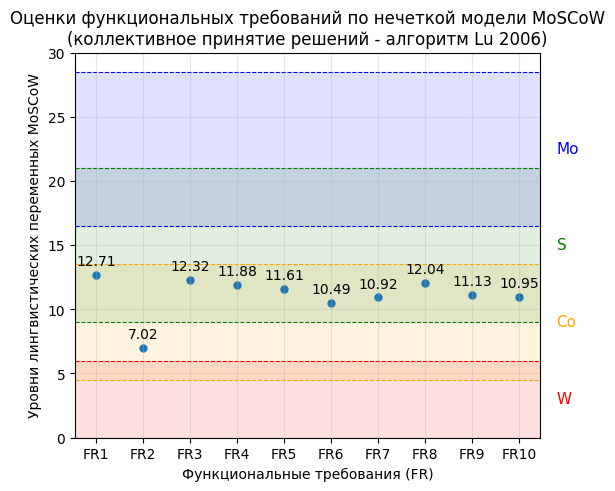

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Преобразуем результаты в словарь: {FR: centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) - 0.2   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW\n(коллективное принятие решений - алгоритм Lu 2006)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

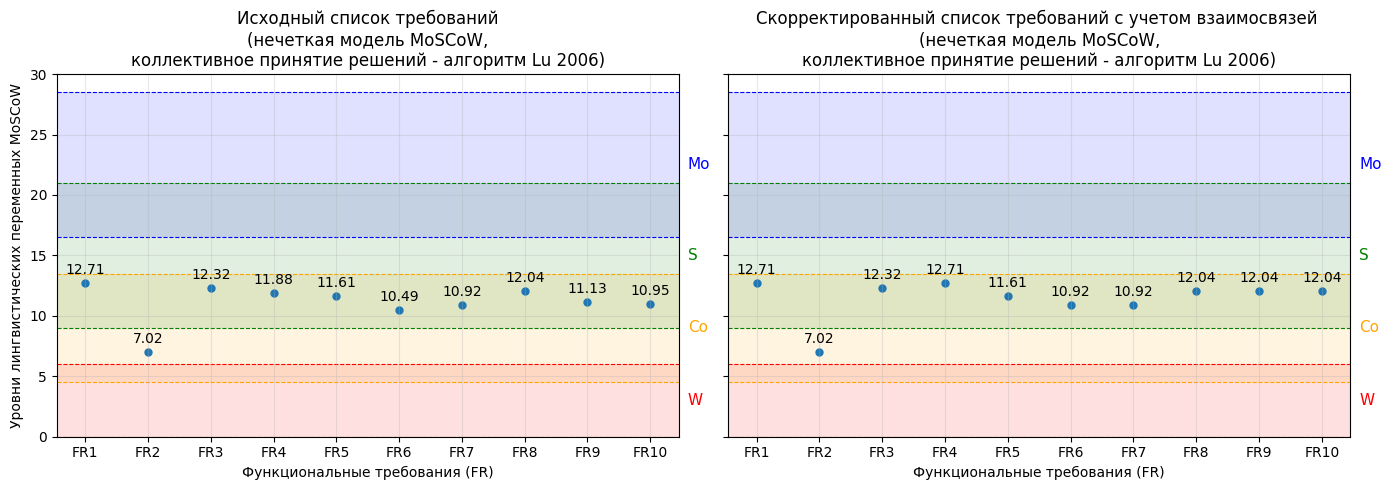

In [255]:
# Преобразуем результаты в словари: {FR: centroid} и {FR: adjusted_centroid}
centroid_by_fr = {r["fr"]: r["centroid"] for r in results_alpha}
adjusted_centroid_by_fr = {r["fr"]: r["adjusted_centroid"] for r in adjusted_results_alpha_sorted}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [centroid_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_centroid_by_fr[fr] for fr in fr_labels]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Lu 2006)",
    "Скорректированный список требований с учетом взаимосвязей \n(нечеткая модель MoSCoW,\nколлективное принятие решений - алгоритм Lu 2006)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Интервалы: заливка + две пунктирные границы + подпись справа
    x_text = len(fr_labels) - 0.4
    alpha_fill = 0.12

    for label, (y_low, y_high) in moscow_intervals.items():
        ax.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)
        ax.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
        ax.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

        y_mid = (y_low + y_high) / 2
        ax.text(
            x_text,
            y_mid,
            label,
            color=line_colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 30)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл**

In [ ]:
# С загрузкой/ выгрузкой данных из файла/ в файл Excel

from typing import List, Dict, Any, Sequence, Tuple, Optional
import re
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

# Типы данных и констант
EPS = 1e-12

Trap = Tuple[float, float, float, float]          # (a1,a2,a3,a4)
IT2  = Tuple[Trap, Trap]                          # (UMF, LMF)
Seg  = Tuple[float, float, float, float]          # (x0,x1,m,c) for mu(x)=m*x+c on [x0,x1]

bold_font = Font(bold=True)
center = Alignment(horizontal="center", vertical="center", wrap_text=True)

def _set_col_width(ws, col_idx: int, width: float):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

# Нечеткие веса для приоритизации по методу MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((5.5, 7, 8, 9.5), (6, 7, 8, 9)),
    "S":  ((3, 4.5, 5.5, 7), (3.5, 4.5, 5.5, 6.5)),
    "Co": ((1.5, 2, 3, 4.5), (1.7, 2, 3, 4)),
    "W":  ((0, 0.5, 1.5, 2), (0, 0.5, 1.5, 1.8)),
}

MOSCOW_FR_REL_WEIGHTS: Dict[str, IT2] = {
    "Mo": ((0.77, 1, 1, 1), (0.83, 1, 1, 1)),
    "S":  ((0.44, 0.55, 0.77, 1), (0.47, 0.55, 0.77, 0.92)),
    "Co": ((0, 0.22, 0.44, 0.55), (0.06, 0.22, 0.44, 0.52)),
    "W":  ((0, 0, 0, 0.22), (0, 0, 0, 0.15)),
}

# Функции арифметических операций над нечеткими числами
def add_it2(a: IT2, b: IT2) -> IT2:
    (a1, a2, a3, a4), (a5, a6, a7, a8) = a
    (b1, b2, b3, b4), (b5, b6, b7, b8) = b
    return ((round(a1 + b1, 2), round(a2 + b2 ,2), round(a3 + b3, 2),round(a4 + b4, 2)),
            (round(a5 + b5, 2), round(a6 + b6, 2), round(a7 + b7, 2),round(a8 + b8, 2)))

def multiply_it2_trap_moscow(X: IT2, Y: IT2) -> IT2:
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    z1, z2, z3, z4, z5, z6, z7, z8 = (max(0.0, float(z)) for z in (z1,z2,z3,z4,z5,z6,z7,z8))
    return ((z1,z2,z3,z4),(z5,z6,z7,z8))

def mul_it2_const(x: IT2, c: float) -> IT2:
    (a,b,c1,d),(e,f,g,h)=x
    return ((a*c, b*c, c1*c, d*c), (e*c, f*c, g*c, h*c))

def alpha_cut(it2: IT2, alpha: float):
    (x1,x2,x3,x4),(x5,x6,x7,x8)=it2
    upper_start = alpha*x2 + (1-alpha)*x1
    upper_end   = alpha*x3 + (1-alpha)*x4
    lower_start = alpha*x6 + (1-alpha)*x5
    lower_end   = alpha*x7 + (1-alpha)*x8
    return ((round(upper_start,2), round(upper_end,2)),
            (round(lower_start,2), round(lower_end,2)))

def pfr_moscow_it2(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Optional[Sequence[str]] = None
) -> List[Dict[str,Any]]:
    n=len(nfr_priorities)
    if n==0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if fr_names is None:
        fr_names=[f"FR{i}" for i in range(1,len(fr_vs_nfr_priorities)+1)]
    if len(fr_names)!=len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    nfr_w=[MOSCOW_NFR_WEIGHTS[str(x).strip()] for x in nfr_priorities]

    results=[]
    for name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row)!=n:
            raise ValueError(f"{name}: ожидалось {n} оценок по числу NFR.")
        fr_w=[MOSCOW_FR_REL_WEIGHTS[str(x).strip()] for x in fr_row]

        pfr: IT2=((0,0,0,0),(0,0,0,0))
        for wn,wf in zip(nfr_w, fr_w):
            pfr = add_it2(pfr, multiply_it2_trap_moscow(wn,wf))

        results.append({"fr":name,"pfr":pfr,"ratings":list(fr_row)})
    return results

def normalize_weights_w(r: Sequence[float]) -> List[float]:
    r=[float(x) for x in r]
    s=sum(r); n=len(r)
    if n==0:
        return []
    if s<=EPS:
        return [1.0/n]*n
    return [ri/s for ri in r]

# Вычисление меры сходства между нечеткими числами
def segments_trap(trap: Trap, L: float, R: float) -> List[Seg]:
    a1,a2,a3,a4 = map(float, trap)
    L,R=float(L),float(R)
    seg=[]
    if L < a1:
        seg.append((L, min(a1,R), 0.0, 0.0))
    if a1 < a2 and max(a1,L) < min(a2,R):
        m=1.0/(a2-a1); c=-a1/(a2-a1)
        seg.append((max(a1,L), min(a2,R), m, c))
    if max(a2,L) < min(a3,R):
        seg.append((max(a2,L), min(a3,R), 0.0, 1.0))
    if a3 < a4 and max(a3,L) < min(a4,R):
        m=-1.0/(a4-a3); c=a4/(a4-a3)
        seg.append((max(a3,L), min(a4,R), m, c))
    if a4 < R:
        seg.append((max(a4,L), R, 0.0, 0.0))

    merged=[]
    for x0,x1,m,c in seg:
        if x1<=x0:
            continue
        if merged and abs(merged[-1][2]-m)<1e-12 and abs(merged[-1][3]-c)<1e-12 and abs(merged[-1][1]-x0)<1e-12:
            merged[-1]=(merged[-1][0], x1, m, c)
        else:
            merged.append((x0,x1,m,c))
    return merged

def mu_from_segments(x: float, segs: List[Seg]) -> float:
    for x0,x1,m,c in segs:
        if x0 <= x <= x1:
            return m*x + c
    return 0.0

def line_at(segs: List[Seg], x: float) -> Tuple[float,float]:
    for x0,x1,m,c in segs:
        if x0-1e-12 <= x <= x1+1e-12:
            return m,c
    return 0.0,0.0

def intersections(segsA: List[Seg], segsB: List[Seg]) -> set:
    pts=set()
    for x0a,x1a,ma,ca in segsA:
        for x0b,x1b,mb,cb in segsB:
            lo,hi=max(x0a,x0b),min(x1a,x1b)
            if hi<=lo:
                continue
            if abs(ma-mb)<1e-12:
                continue
            x=(cb-ca)/(ma-mb)
            if lo-1e-9 <= x <= hi+1e-9:
                pts.add(float(x))
    return pts

def build_breakpoints(segsA: List[Seg], segsB: List[Seg]) -> List[float]:
    pts=set()
    for x0,x1,_,_ in segsA:
        pts.add(x0); pts.add(x1)
    for x0,x1,_,_ in segsB:
        pts.add(x0); pts.add(x1)
    pts |= intersections(segsA,segsB)
    bp=sorted(pts)
    cleaned=[]
    for x in bp:
        if not cleaned or abs(cleaned[-1]-x)>1e-9:
            cleaned.append(x)
    return cleaned

def integral_square_linear(m: float, c: float, x0: float, x1: float) -> float:
    return (m*m/3.0)*(x1**3-x0**3) + (m*c)*(x1**2-x0**2) + (c*c)*(x1-x0)

def Sw(trapA: Trap, trapB: Trap) -> float:
    a1,a2,a3,a4 = map(float, trapA)
    b1,b2,b3,b4 = map(float, trapB)
    L,R=min(a1,b1), max(a4,b4)
    segA=segments_trap(trapA,L,R)
    segB=segments_trap(trapB,L,R)
    bp=build_breakpoints(segA,segB)

    Imin=0.0; Imax=0.0
    for x0,x1 in zip(bp[:-1], bp[1:]):
        if x1<=x0:
            continue
        xm=(x0+x1)/2.0
        muA=mu_from_segments(xm,segA)
        muB=mu_from_segments(xm,segB)
        mA,cA=line_at(segA,xm)
        mB,cB=line_at(segB,xm)

        if muA <= muB:
            Imin += integral_square_linear(mA,cA,x0,x1)
            Imax += integral_square_linear(mB,cB,x0,x1)
        else:
            Imin += integral_square_linear(mB,cB,x0,x1)
            Imax += integral_square_linear(mA,cA,x0,x1)

    return 0.0 if Imax<=0 else Imin/Imax

# Вычисление расстояния между нечеткими числами
def integral_linear(m: float,c: float,x0: float,x1: float)->float:
    return (m/2.0)*(x1**2-x0**2) + c*(x1-x0)

def d_inf(trapA: Trap, trapB: Trap)->float:
    a1,_,_,a4=map(float,trapA)
    b1,_,_,b4=map(float,trapB)
    if a4 < b1: return b1-a4
    if b4 < a1: return a1-b4
    return 0.0

def dH(trapA: Trap, trapB: Trap)->float:
    a1,_,_,a4=map(float,trapA)
    b1,_,_,b4=map(float,trapB)
    L,R=min(a1,b1), max(a4,b4)
    segA=segments_trap(trapA,L,R)
    segB=segments_trap(trapB,L,R)
    bp=build_breakpoints(segA,segB)

    total=0.0
    for x0,x1 in zip(bp[:-1], bp[1:]):
        if x1<=x0:
            continue
        xm=(x0+x1)/2.0
        mA,cA=line_at(segA,xm)
        mB,cB=line_at(segB,xm)
        m=mA-mB; c=cA-cB
        area_signed=integral_linear(m,c,x0,x1)
        total += abs(area_signed)
    return total

def D_trap(trapA: Trap, trapB: Trap)->float:
    return 0.5*(dH(trapA,trapB) + d_inf(trapA,trapB))

# Построением матриц сходства, расстояния, вычисление весов агрегирования оценок экспертов
def build_AM_matrices_it2(prepared_experts: Sequence[Dict[str,Any]], fr_names: Sequence[str]) -> Tuple[Dict[str,np.ndarray], Dict[str,np.ndarray]]:
    k=len(prepared_experts)
    AM_u_by_fr={}
    AM_l_by_fr={}
    for fr in fr_names:
        AMu=np.zeros((k,k),float)
        AMl=np.zeros((k,k),float)
        for i in range(k):
            u_i, l_i = prepared_experts[i]["ratings"][fr]
            for j in range(k):
                u_j, l_j = prepared_experts[j]["ratings"][fr]
                AMu[i,j]=Sw(u_i,u_j)
                AMl[i,j]=Sw(l_i,l_j)
        AM_u_by_fr[fr]=AMu
        AM_l_by_fr[fr]=AMl
    return AM_u_by_fr, AM_l_by_fr

def build_dM_matrices_it2(prepared_experts: Sequence[Dict[str,Any]], fr_names: Sequence[str]) -> Tuple[Dict[str,np.ndarray], Dict[str,np.ndarray]]:
    k=len(prepared_experts)
    dM_u_by_fr={}
    dM_l_by_fr={}
    for fr in fr_names:
        DMu=np.zeros((k,k),float)
        DMl=np.zeros((k,k),float)
        for i in range(k):
            u_i,l_i=prepared_experts[i]["ratings"][fr]
            for j in range(k):
                u_j,l_j=prepared_experts[j]["ratings"][fr]
                DMu[i,j]=D_trap(u_i,u_j)
                DMl[i,j]=D_trap(l_i,l_j)

        Du=float(DMu.max())
        Dl=float(DMl.max())

        dMu=np.zeros_like(DMu) if Du<=EPS else DMu/Du
        dMl=np.zeros_like(DMl) if Dl<=EPS else DMl/Dl

        dM_u_by_fr[fr]=dMu
        dM_l_by_fr[fr]=dMl
    return dM_u_by_fr, dM_l_by_fr

def build_R_matrices_from_AM_dM(AM_by_fr: Dict[str,np.ndarray], dM_by_fr: Dict[str,np.ndarray], beta: float) -> Dict[str,np.ndarray]:
    if not (0.0<=beta<=1.0):
        raise ValueError("beta должен быть в диапазоне [0,1].")
    out={}
    for fr, AM in AM_by_fr.items():
        dM=dM_by_fr[fr]
        if AM.shape != dM.shape:
            raise ValueError(f"{fr}: AM и dM должны быть одного размера.")
        out[fr] = beta*AM + (1.0-beta)*(1.0-dM)
    return out

def average_R_matrices(Ru_by_fr: Dict[str,np.ndarray], Rl_by_fr: Dict[str,np.ndarray]) -> Dict[str,np.ndarray]:
    return {fr: 0.5*(Ru_by_fr[fr]+Rl_by_fr[fr]) for fr in Ru_by_fr.keys()}

def compute_C_for_all_fr(prepared_experts: Sequence[Dict[str,Any]], R_avg_by_fr: Dict[str,np.ndarray], fr_names: Sequence[str]) -> Dict[str,np.ndarray]:
    e = np.asarray([float(ex["w"]) for ex in prepared_experts], float)
    if e.sum()<=EPS:
        raise ValueError("Сумма нормализованных весов экспертов должна быть > 0.")
    out={}
    for fr in fr_names:
        out[fr] = np.asarray(R_avg_by_fr[fr], float) @ e
    return out

def compute_wE_for_all_fr(C_by_fr: Dict[str,np.ndarray], fr_names: Sequence[str]) -> Dict[str,np.ndarray]:
    out={}
    for fr in fr_names:
        C=np.asarray(C_by_fr[fr],float)
        s=float(C.sum()); k=C.size
        out[fr] = (np.full(k,1.0/k,float) if s<=EPS else (C/s))
    return out

def aggregate_group_it2_for_all_fr(prepared_experts: Sequence[Dict[str,Any]], wE_by_fr: Dict[str,np.ndarray], fr_names: Sequence[str]) -> Dict[str,IT2]:
    k=len(prepared_experts)
    out={}
    for fr in fr_names:
        w=np.asarray(wE_by_fr[fr],float)
        s=float(w.sum())
        w = (np.full(k,1.0/k,float) if s<=EPS else (w/s))

        acc: IT2=((0,0,0,0),(0,0,0,0))
        for i,ex in enumerate(prepared_experts):
            acc = add_it2(acc, mul_it2_const(ex["ratings"][fr], float(w[i])))
        out[fr]=acc
    return out

def build_defuzz_rows(it2_by_fr: Dict[str,IT2], alpha: float) -> List[Dict[str,Any]]:
    rows=[]
    for fr,it2 in it2_by_fr.items():
        (U,L)=alpha_cut(it2,alpha)
        u_s,u_e=U; l_s,l_e=L
        mid_U=round((u_s+u_e)/2,2)
        mid_L=round((l_s+l_e)/2,2)
        avg=round((mid_U+mid_L)/2,2)
        (a,b,c,d),(e,f,g,h)=it2
        rows.append({
            "FR":fr,
            "umf":(a,b,c,d),
            "lmf":(e,f,g,h),
            "u_cut":(u_s,u_e),
            "l_cut":(l_s,l_e),
            "mid_umf":mid_U,
            "mid_lmf":mid_L,
            "avg_mid":avg
        })
    return sorted(rows, key=lambda x: x["avg_mid"], reverse=True)

# Загрузка данных из Excel
_nfr_pat=re.compile(r"^NFR\d+$", re.I)
_fr_pat=re.compile(r"^FR\d+$", re.I)

def load_expert_sheet(ws) -> Dict[str,Any]:
    # поиск строки заголовка NFR, содержащую NFR1..NFRn
    nfr_header_row=None
    nfr_names=[]
    nfr_cols=[]
    for r in range(1, ws.max_row+1):
        row_vals=[ws.cell(r,c).value for c in range(1, ws.max_column+1)]
        cols=[c for c,v in enumerate(row_vals, start=1) if isinstance(v,str) and _nfr_pat.match(v.strip())]
        if len(cols)>=2:
            start=min(cols)
            for c in range(start, ws.max_column+1):
                v=ws.cell(r,c).value
                if isinstance(v,str) and _nfr_pat.match(v.strip()):
                    nfr_names.append(v.strip()); nfr_cols.append(c)
                else:
                    if nfr_names:
                        break
            nfr_header_row=r
            break
    if nfr_header_row is None:
        raise ValueError(f"Не найдена строка заголовков NFR на листе '{ws.title}'.")

    # Строка с оценками NFR (Mo/S/Co/W)
    nfr_priorities_row=nfr_header_row+1
    nfr_priorities=[]
    for c in nfr_cols:
        v=ws.cell(nfr_priorities_row,c).value
        if v is None or str(v).strip()=="":
            raise ValueError(f"Пустой приоритет NFR на листе '{ws.title}' в строке {nfr_priorities_row}.")
        nfr_priorities.append(str(v).strip())

    # Строка с оценками FR, содержащую NFR1..NFRn в заголовке
    fr_header_row=None
    fr_cols=[]
    for r in range(nfr_priorities_row+1, ws.max_row+1):
        vals=[ws.cell(r,c).value for c in range(1, ws.max_column+1)]
        found={str(v).strip() for v in vals if isinstance(v,str)}
        if all(name in found for name in nfr_names):
            col_map={}
            for c in range(1, ws.max_column+1):
                v=ws.cell(r,c).value
                if isinstance(v,str) and str(v).strip() in nfr_names:
                    col_map[str(v).strip()]=c
            fr_cols=[col_map[name] for name in nfr_names]
            fr_header_row=r
            break
    if fr_header_row is None:
        raise ValueError(f"Не найдена шапка таблицы FR (строка с NFR1..NFRn) на листе '{ws.title}'.")

    # чтение строк FR
    fr_names=[]
    fr_matrix=[]
    r=fr_header_row+1
    while r<=ws.max_row:
        fr_name=ws.cell(r,1).value
        if fr_name is None or str(fr_name).strip()=="":
            break
        fr_name=str(fr_name).strip()
        if not _fr_pat.match(fr_name):
            break
        row=[]
        for c in fr_cols:
            v=ws.cell(r,c).value
            row.append("" if v is None else str(v).strip())
        if any(x!="" for x in row):
            fr_names.append(fr_name)
            fr_matrix.append(row)
        r += 1

    return {"name": ws.title, "nfr": nfr_priorities, "fr_names": fr_names, "frs": fr_matrix}

# Запись в Excel
def write_weights_block(ws, start_row: int, expert_names: List[str], r_raw: List[float], w_norm: List[float]) -> int:
    ws.cell(start_row,1).value="Эксперт"
    ws.cell(start_row,2).value="Вес_raw (r)"
    ws.cell(start_row,3).value="Вес_norm (w)"
    for c in [1,2,3]:
        ws.cell(start_row,c).font=bold_font
        ws.cell(start_row,c).alignment=center
    for i,(nm,rr,ww) in enumerate(zip(expert_names,r_raw,w_norm), start=1):
        rrw=start_row+i
        ws.cell(rrw,1).value=nm
        ws.cell(rrw,2).value=float(rr)
        ws.cell(rrw,3).value=round(float(ww),2)
    sum_row=start_row+len(expert_names)+1
    ws.cell(sum_row,1).value="SUM"
    ws.cell(sum_row,2).value=round(sum(r_raw),2)
    ws.cell(sum_row,3).value=round(sum(w_norm),2)
    for c in [1,2,3]:
        ws.cell(sum_row,c).font=bold_font
    ws.column_dimensions["A"].width=25.29
    ws.column_dimensions["B"].width=16
    ws.column_dimensions["C"].width=16
    return sum_row+2

def write_params(ws, start_row: int, alpha: float, beta: float) -> int:
    ws.cell(start_row,1).value="уровень альфа-среза (alpha)"; ws.cell(start_row,2).value=float(alpha)
    ws.cell(start_row+1,1).value="параметр бета (beta)";      ws.cell(start_row+1,2).value=float(beta)
    for rr in range(start_row, start_row+2):
        ws.cell(rr,1).font=bold_font
        ws.cell(rr,2).font=bold_font
    return start_row+3

def write_result_table(ws, start_row: int, title: str, alpha: float, rows_sorted: List[Dict[str,Any]]) -> int:
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=17)
    t=ws.cell(start_row,1); t.value=title; t.font=bold_font; t.alignment=center

    r1,r2=start_row+1,start_row+2

    ws.merge_cells(start_row=r1,start_column=1,end_row=r2,end_column=1)
    ws.merge_cells(start_row=r1,start_column=2,end_row=r2,end_column=2)
    ws.merge_cells(start_row=r1,start_column=3,end_row=r1,end_column=10)
    ws.merge_cells(start_row=r1,start_column=11,end_row=r1,end_column=14)
    ws.merge_cells(start_row=r1,start_column=15,end_row=r1,end_column=16)
    ws.merge_cells(start_row=r1,start_column=17,end_row=r2,end_column=17)

    ws.cell(r1,1).value="Rank"; ws.cell(r1,2).value="FR"
    ws.cell(r1,3).value="IT2"; ws.cell(r1,11).value=f"alpha-cut ({alpha})"
    ws.cell(r1,15).value="Centroids"; ws.cell(r1,17).value="avg_mid"

    for col in [1,2,3,11,15,17]:
        ws.cell(r1,col).font=bold_font; ws.cell(r1,col).alignment=center

    ws.cell(r2,3).value="UMF (a,b,c,d)"
    ws.cell(r2,7).value="LMF (e,f,g,h)"
    ws.cell(r2,11).value="UMF [u1,u2]"
    ws.cell(r2,13).value="LMF [l1,l2]"
    ws.cell(r2,15).value="mid_UMF"
    ws.cell(r2,16).value="mid_LMF"

    for col in [3,7,11,13,15,16]:
        ws.cell(r2,col).font=bold_font; ws.cell(r2,col).alignment=center

    data_start=start_row+3
    for i,item in enumerate(rows_sorted,start=1):
        rr=data_start+i-1
        ws.cell(rr,1).value=i
        ws.cell(rr,2).value=item["FR"]

        (a,b,c,d)=item["umf"]; (e,f,g,h)=item["lmf"]
        (u1,u2)=item["u_cut"]; (l1,l2)=item["l_cut"]

        for j,val in enumerate([a,b,c,d], start=3):
            ws.cell(rr,j).value=round(float(val),2)
        for j,val in enumerate([e,f,g,h], start=7):
            ws.cell(rr,j).value=round(float(val),2)

        ws.cell(rr,11).value=round(float(u1),2); ws.cell(rr,12).value=round(float(u2),2)
        ws.cell(rr,13).value=round(float(l1),2); ws.cell(rr,14).value=round(float(l2),2)
        ws.cell(rr,15).value=round(float(item["mid_umf"]),2)
        ws.cell(rr,16).value=round(float(item["mid_lmf"]),2)
        ws.cell(rr,17).value=round(float(item["avg_mid"]),2)

    _set_col_width(ws,1,10); _set_col_width(ws,2,10)
    for col in range(3,15): _set_col_width(ws,col,14)
    _set_col_width(ws,15,12); _set_col_width(ws,16,12); _set_col_width(ws,17,12)

    return data_start+len(rows_sorted)+2

def write_dual_matrices_block(
    ws, start_row: int, title: str,
    subtitle_left: str, subtitle_right: str,
    fr_list: List[str],
    mats_left: Dict[str,np.ndarray], mats_right: Dict[str,np.ndarray],
    k: int
) -> int:
    left_start=1; left_width=1+k; gap=1
    right_start=left_start+left_width+gap; right_width=1+k
    end_col=right_start+right_width-1

    ws.merge_cells(start_row=start_row,start_column=1,end_row=start_row,end_column=end_col)
    c=ws.cell(start_row,1); c.value=title; c.font=bold_font; c.alignment=center

    ws.merge_cells(start_row=start_row+1,start_column=left_start,end_row=start_row+1,end_column=left_start+left_width-1)
    ws.merge_cells(start_row=start_row+1,start_column=right_start,end_row=start_row+1,end_column=right_start+right_width-1)

    ws.cell(start_row+1,left_start).value=subtitle_left
    ws.cell(start_row+1,left_start).font=bold_font
    ws.cell(start_row+1,right_start).value=subtitle_right
    ws.cell(start_row+1,right_start).font=bold_font

    r=start_row+3
    for fr in fr_list:
        M1=np.asarray(mats_left[fr],float); M2=np.asarray(mats_right[fr],float)

        ws.cell(r,left_start).value=fr;  ws.cell(r,left_start).font=bold_font
        ws.cell(r,right_start).value=fr; ws.cell(r,right_start).font=bold_font

        for i in range(k):
            for j in range(k):
                ws.cell(r+i, left_start+1+j).value=round(float(M1[i,j]),2)
                ws.cell(r+i, right_start+1+j).value=round(float(M2[i,j]),2)

        r = r + k + 1

    _set_col_width(ws,left_start,10)
    for cidx in range(left_start+1, left_start+left_width):
        _set_col_width(ws,cidx,10)

    _set_col_width(ws,right_start,10)
    for cidx in range(right_start+1, right_start+right_width):
        _set_col_width(ws,cidx,10)

    return r+1

def write_single_matrices_block(ws, start_row:int, title:str, fr_list:List[str], mats:Dict[str,np.ndarray], k:int, start_col:int=1) -> int:
    end_col = start_col + 1 + k - 1
    ws.merge_cells(start_row=start_row,start_column=start_col,end_row=start_row,end_column=end_col)
    c=ws.cell(start_row,start_col); c.value=title; c.font=bold_font; c.alignment=center

    r=start_row+2
    for fr in fr_list:
        M=np.asarray(mats[fr],float)
        ws.cell(r,start_col).value=fr; ws.cell(r,start_col).font=bold_font
        for i in range(k):
            for j in range(k):
                ws.cell(r+i, start_col+1+j).value=round(float(M[i,j]),2)
        r = r + k + 1

    _set_col_width(ws,start_col,10)
    for cidx in range(start_col+1, start_col+1+k):
        _set_col_width(ws,cidx,10)

    return r+1

def write_vectors_block(ws, start_row:int, title:str, fr_list:List[str], vec:Dict[str,np.ndarray], k:int) -> int:
    ws.merge_cells(start_row=start_row,start_column=1,end_row=start_row,end_column=1+k)
    c=ws.cell(start_row,1); c.value=title; c.font=bold_font; c.alignment=center

    r=start_row+2
    for fr in fr_list:
        ws.cell(r,1).value=fr; ws.cell(r,1).font=bold_font
        arr=np.asarray(vec[fr],float).reshape(-1)
        for j,val in enumerate(arr, start=0):
            ws.cell(r,2+j).value=round(float(val),2)
        r += 1

    return r+2

# Главная функция (чтение, расчеты, запись результатов)
def run_all_append_one_sheet_beta(
    input_xlsx: str,
    output_xlsx: str,
    weights_raw: List[float],
    alpha: float,
    beta: float,
    result_sheet_name: str = "Нечеткий MoSCoW_коллектив",
) -> str:

    if not (0.0 <= alpha <= 1.0):
        raise ValueError("ALPHA должен быть в диапазоне [0,1].")
    if not (0.0 <= beta <= 1.0):
        raise ValueError("BETA должен быть в диапазоне [0,1].")

    wb=load_workbook(input_xlsx)

    # Чтение страниц с оценками экспертов
    experts_loaded=[]
    for sname in wb.sheetnames:
        if sname == result_sheet_name:
            continue
        ws=wb[sname]
        data=load_expert_sheet(ws)
        experts_loaded.append(data)

    if not experts_loaded:
        raise ValueError("Не найдено листов-экспертов (с NFR-шапкой).")

    fr_list=experts_loaded[0]["fr_names"]
    for e in experts_loaded[1:]:
        if e["fr_names"] != fr_list:
            raise ValueError("У экспертов разные списки FR (имена/порядок должны совпадать).")

    k=len(experts_loaded)
    if len(weights_raw)!=k:
        raise ValueError(f"WEIGHTS_RAW должен быть длины {k} (по числу листов экспертов).")

    w_norm=normalize_weights_w(weights_raw)

    # PFR IT2 каждого эксперта (исходные оценки)
    prepared=[]
    for e,ri,wi in zip(experts_loaded, weights_raw, w_norm):
        res=pfr_moscow_it2(e["nfr"], e["frs"], fr_names=fr_list)
        ratings={item["fr"]: item["pfr"] for item in res}
        prepared.append({"name": e["name"], "r": float(ri), "w": float(wi), "ratings": ratings})

    # Формирование AM, dM, R, R_avg, C, wE, коллективной оценки
    AMu_by_fr, AMl_by_fr = build_AM_matrices_it2(prepared, fr_list)
    dMu_by_fr, dMl_by_fr = build_dM_matrices_it2(prepared, fr_list)

    Ru_by_fr = build_R_matrices_from_AM_dM(AMu_by_fr, dMu_by_fr, beta)
    Rl_by_fr = build_R_matrices_from_AM_dM(AMl_by_fr, dMl_by_fr, beta)
    Ravg_by_fr = average_R_matrices(Ru_by_fr, Rl_by_fr)

    C_by_fr  = compute_C_for_all_fr(prepared, Ravg_by_fr, fr_list)
    wE_by_fr = compute_wE_for_all_fr(C_by_fr, fr_list)
    group_by_fr = aggregate_group_it2_for_all_fr(prepared, wE_by_fr, fr_list)

    # Запись листа с выходными данными
    if result_sheet_name in wb.sheetnames:
        wb.remove(wb[result_sheet_name])
    ws_out=wb.create_sheet(result_sheet_name)

    r=1
    expert_names=[e["name"] for e in prepared]
    r = write_weights_block(ws_out, r, expert_names, list(weights_raw), w_norm)
    r = write_params(ws_out, r, alpha, beta)

    # Таблицы экспертов
    for e in prepared:
        rows_sorted=build_defuzz_rows(e["ratings"], alpha)
        r = write_result_table(ws_out, r, title=f"Эксперт: {e['name']}", alpha=alpha, rows_sorted=rows_sorted)

    # Матрицы и вектора
    r = write_dual_matrices_block(ws_out, r, "Матрицы сходства AM (Sw)", "AM_UMF", "AM_LMF", fr_list, AMu_by_fr, AMl_by_fr, k)
    r = write_dual_matrices_block(ws_out, r, "Нормированные матрицы расстояний dM", "dM_UMF", "dM_LMF", fr_list, dMu_by_fr, dMl_by_fr, k)
    r = write_dual_matrices_block(ws_out, r, f"Матрицы согласованности AMr", "R_UMF", "R_LMF", fr_list, Ru_by_fr, Rl_by_fr, k)
    r = write_single_matrices_block(ws_out, r, "Усредненные матрицы согласованности R_avg", fr_list, Ravg_by_fr, k)
    r = write_vectors_block(ws_out, r, "Взвешенная степень согласованности эксперта C(Ei)", fr_list, C_by_fr, k)
    r = write_vectors_block(ws_out, r, "Веса агрегирования экспертов w(Ei)", fr_list, wE_by_fr, k)

    # Формирование итоговой таблицы
    rows_sorted_group=build_defuzz_rows(group_by_fr, alpha)
    r = write_result_table(ws_out, r, title="Итог группы (R_group_IT2)", alpha=alpha, rows_sorted=rows_sorted_group)

    wb.save(output_xlsx)
    return output_xlsx


In [ ]:
# Запуск

INPUT_XLSX  = r"Загрузочные данные_MoSCoW_коллектив.xlsx"
OUTPUT_XLSX = r"Итоги_Fuzzy MoSCoW_Lu 2006.xlsx"

# Порядок весов равен порядку листов экспертов во входном файле
WEIGHTS_RAW = [0.75, 0.75, 1.0]

ALPHA = 0.8
BETA  = 0.4

RESULT_SHEET_NAME = "Нечеткий MoSCoW_коллектив"


out = run_all_append_one_sheet_beta(
    input_xlsx=INPUT_XLSX,
    output_xlsx=OUTPUT_XLSX,
    weights_raw=WEIGHTS_RAW,
    alpha=ALPHA,
    beta=BETA,
    result_sheet_name=RESULT_SHEET_NAME
)

print("Файл сохранен:", out)

Файл сохранен: Итоги_Fuzzy MoSCoW_Lu 2006.xlsx


# 2.4.2. Четкий MoSCoW + Аналог алгоритма Lu 2006 (КПР) для сравнения с нечетким алгоритмом

**Fuzzy MoSCoW данные взяты из статьи**

https://ieeexplore.ieee.org/abstract/document/8342602

Ahmad, K. S., Ahmad, N., Tahir, H., Khan, S. Fuzzy_MoSCoW: A fuzzy based MoSCoW method for the prioritization of software requirements // In 2017 International Conference

**Коллективное принятие решений**

https://link.springer.com/article/10.1007/s11424-006-0063-y

Lu, C., Lan, J., Wang, Z. Aggregation of fuzzy opinions under group decision-making based on similarity and distance //Journal of Systems Science and Complexity. 2006, 19(1)

**Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке**

In [256]:
# Четкий алгоритм MoSCoW с коллективными агрегированными оценками. Загрузка и выгрузка в ноутбуке
from typing import Sequence, Any, Dict, Tuple, Optional

# Шкалы MoSCoW
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS)  # {"Mo","S","Co","W"}


def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    expert_names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = list(weights)

    if normalize:
        s = sum(w_raw)
        if s == 0:
            raise ValueError("Сумма весов равна 0 — невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    w_norm_by_name = dict(zip(expert_names, w_norm))
    w_raw_by_name = dict(zip(expert_names, w_raw))
    return expert_names, w_norm, w_norm_by_name, w_raw_by_name


def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # NFR -  веса
    try:
        nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]
    except KeyError as e:
        raise ValueError(f"Недопустимое значение в nfr_priorities: {e}. Допустимо: {_ALLOWED}")

    # FR_NFR -  PFR
    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        try:
            fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        except KeyError as e:
            raise ValueError(f"{fr_name}: недопустимое значение {e}. Допустимо: {_ALLOWED}")

        scores[fr_name] = sum(a * b for a, b in zip(nfr_w, fr_w))

    return scores


def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:

    # базовые проверки по структуре FR
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    m = len(experts[0].get("frs", []))
    if m == 0:
        raise ValueError("У экспертов должен быть хотя бы 1 FR (поле 'frs').")
    for e in experts:
        if len(e.get("frs", [])) != m:
            raise ValueError("У всех экспертов должно быть одинаковое количество FR (одинаковый набор FR).")

    # FR names
    if fr_names is None:
        fr_names = [f"FR{i}" for i in range(1, m + 1)]
    else:
        fr_names = list(fr_names)

    if len(fr_names) != m:
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    # веса экспертов
    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    # оценки каждого эксперта: {expert - оценка {fr - в pfr}}
    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,   # список в том же порядке, что expert_names
        "expert_scores": expert_scores,     # ключевой результат шага
    }


In [257]:
# Пример использования (3 эксперта)
S1 = {
    "name": "S1",
    "nfr": ["Mo", "Co", "S"],
    "frs": [
        ["Mo", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "S",  "S"],
        ["Mo", "S",  "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Mo"],
        ["S",  "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S2 = {
    "name": "S2",
    "nfr": ["Mo", "Mo", "S"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["Co", "Co", "S"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["Co", "Mo", "S"],
        ["Co", "Mo", "S"],
    ]
}

S3 = {
    "name": "S3",
    "nfr": ["Co", "S", "Mo"],
    "frs": [
        ["Co", "S",  "Mo"],
        ["S",  "Co", "Co"],
        ["S",  "Mo", "S"],
        ["Mo", "S",  "Co"],
        ["S",  "Mo", "Co"],
        ["Co", "S",  "Co"],
        ["Mo", "S",  "Co"],
        ["S",  "Co", "Mo"],
        ["S",  "Mo", "Co"],
        ["Co", "Mo", "S"],
    ]
}

experts = [S1, S2, S3]
weights = [0.75, 0.75, 1]  # ненормализованные

prepared = prepare_crisp_moscow_inputs(experts, weights)

print("Normalized weights:", {k: round(v, 2) for k, v in prepared["weights_norm"].items()})
print()

# Печать
fr_names = prepared["fr_names"]
expert_names = prepared["expert_names"]
expert_scores = prepared["expert_scores"]

for fr in fr_names:
    row = {expert: round(expert_scores[expert][fr], 2) for expert in expert_names}
    print(f"{fr}: {row}")


Normalized weights: {'S1': 0.3, 'S2': 0.3, 'S3': 0.4}

FR1: {'S1': 14.15, 'S2': 12.43, 'S3': 11.62}
FR2: {'S1': 6.6, 'S2': 8.25, 'S3': 5.78}
FR3: {'S1': 9.9, 'S2': 15.75, 'S3': 11.6}
FR4: {'S1': 12.45, 'S2': 14.1, 'S3': 8.28}
FR5: {'S1': 10.75, 'S2': 15.75, 'S3': 9.12}
FR6: {'S1': 10.8, 'S2': 14.1, 'S3': 6.6}
FR7: {'S1': 10.8, 'S2': 14.1, 'S3': 8.28}
FR8: {'S1': 12.45, 'S2': 12.43, 'S3': 10.8}
FR9: {'S1': 10.75, 'S2': 13.28, 'S3': 9.12}
FR10: {'S1': 8.28, 'S2': 13.28, 'S3': 10.78}


In [258]:
# Расчет матриц сходства AM, нормированного расстояния dM и агрегированной меры согласованности AMr
import numpy as np

EPS = 1e-12

def build_crisp_matrices_by_fr(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
    beta: float,
) -> Tuple[
    Dict[str, np.ndarray],  # dM_by_fr
    Dict[str, np.ndarray],  # AM_by_fr
    Dict[str, np.ndarray],  # AMr_by_fr
]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1].")

    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # Проверки наличия оценок
    for ex in expert_names:
        if ex not in expert_scores:
            raise ValueError(f"Нет expert_scores для эксперта '{ex}'.")
        for fr in fr_names:
            if fr not in expert_scores[ex]:
                raise ValueError(f"У эксперта '{ex}' нет оценки для '{fr}'.")

    dM_by_fr: Dict[str, np.ndarray] = {}
    AM_by_fr: Dict[str, np.ndarray]  = {}
    AMr_by_fr: Dict[str, np.ndarray]  = {}

    for fr in fr_names:
        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)  # (k,)

        # попарные модули разностей (xi-xj)
        diff = np.abs(x[:, None] - x[None, :])  # (k,k)
        D_star = float(diff.max())

        if D_star <= EPS:
            dM = np.zeros((k, k), dtype=float)
        else:
            dM = diff / D_star

        S = (1.0 - dM) ** 2
        R = beta * S + (1.0 - beta) * (1.0 - dM)

        dM_by_fr[fr] = dM
        AM_by_fr[fr]  = S
        AMr_by_fr[fr]  = R

    return dM_by_fr, AM_by_fr, AMr_by_fr

def print_matrix_list(M: np.ndarray, name: str, decimals: int = 2) -> None:
    M = np.asarray(M, dtype=float)
    fmt = f"{{:.{decimals}f}}"
    print(f"{name}:")
    for row in M:
        row_str = ", ".join(fmt.format(x) for x in row)
        print(f"[{row_str}]")

In [259]:
# Запуск
beta = 0.4

dM_by_fr, AM_by_fr, AMr_by_fr = build_crisp_matrices_by_fr(
    fr_names=fr_names,
    expert_names=expert_names,
    expert_scores=expert_scores,
    beta=beta
)

print("Нормированные матрицы расстояний dM")
for fr in fr_names:
    print()
    print_matrix_list(dM_by_fr[fr], f"{fr}", decimals=2)

print("\nМатрицы сходства AM")
for fr in fr_names:
    print()
    print_matrix_list(AM_by_fr[fr], f"{fr}", decimals=2)

print(f"\nМатрицы агрегированной меры согласованности AMr")
for fr in fr_names:
    print()
    print_matrix_list(AMr_by_fr[fr], f"{fr}", decimals=2)

Нормированные матрицы расстояний dM

FR1:
[0.00, 0.68, 1.00]
[0.68, 0.00, 0.32]
[1.00, 0.32, 0.00]

FR2:
[0.00, 0.67, 0.33]
[0.67, 0.00, 1.00]
[0.33, 1.00, 0.00]

FR3:
[0.00, 1.00, 0.29]
[1.00, 0.00, 0.71]
[0.29, 0.71, 0.00]

FR4:
[0.00, 0.28, 0.72]
[0.28, 0.00, 1.00]
[0.72, 1.00, 0.00]

FR5:
[0.00, 0.75, 0.25]
[0.75, 0.00, 1.00]
[0.25, 1.00, 0.00]

FR6:
[0.00, 0.44, 0.56]
[0.44, 0.00, 1.00]
[0.56, 1.00, 0.00]

FR7:
[0.00, 0.57, 0.43]
[0.57, 0.00, 1.00]
[0.43, 1.00, 0.00]

FR8:
[0.00, 0.02, 1.00]
[0.02, 0.00, 0.98]
[1.00, 0.98, 0.00]

FR9:
[0.00, 0.61, 0.39]
[0.61, 0.00, 1.00]
[0.39, 1.00, 0.00]

FR10:
[0.00, 1.00, 0.50]
[1.00, 0.00, 0.50]
[0.50, 0.50, 0.00]

Матрицы сходства AM

FR1:
[1.00, 0.10, 0.00]
[0.10, 1.00, 0.47]
[0.00, 0.47, 1.00]

FR2:
[1.00, 0.11, 0.44]
[0.11, 1.00, 0.00]
[0.44, 0.00, 1.00]

FR3:
[1.00, 0.00, 0.50]
[0.00, 1.00, 0.08]
[0.50, 0.08, 1.00]

FR4:
[1.00, 0.51, 0.08]
[0.51, 1.00, 0.00]
[0.08, 0.00, 1.00]

FR5:
[1.00, 0.06, 0.57]
[0.06, 1.00, 0.00]
[0.57, 0.00, 1.0

In [260]:
# Вычисление взвешенных степеней согласованности экспертов С(Ei)

def build_crisp_matrices_by_fr(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
    beta: float,
) -> Tuple[
    Dict[str, np.ndarray],  # dM_by_fr
    Dict[str, np.ndarray],  # AM_by_fr  (S)
    Dict[str, np.ndarray],  # AMr_by_fr (R)
]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1].")

    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    for ex in expert_names:
        if ex not in expert_scores:
            raise ValueError(f"Нет expert_scores для эксперта '{ex}'.")
        for fr in fr_names:
            if fr not in expert_scores[ex]:
                raise ValueError(f"У эксперта '{ex}' нет оценки для '{fr}'.")

    dM_by_fr: Dict[str, np.ndarray] = {}
    AM_by_fr: Dict[str, np.ndarray] = {}
    AMr_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)  # (k,)
        diff = np.abs(x[:, None] - x[None, :])  # (k,k)
        D_star = float(diff.max())

        if D_star <= EPS:
            dM = np.zeros((k, k), dtype=float)
        else:
            dM = diff / D_star

        S = (1.0 - dM) ** 2
        R = beta * S + (1.0 - beta) * (1.0 - dM)

        dM_by_fr[fr] = dM
        AM_by_fr[fr] = S
        AMr_by_fr[fr] = R

    return dM_by_fr, AM_by_fr, AMr_by_fr

def compute_C_for_all_fr_crisp(
    expert_names: Sequence[str],
    weights_norm: Dict[str, float],          # prepared["weights_norm"]
    AMr_by_fr: Dict[str, np.ndarray],        # матрицы согласованности по FR
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    # e - нормированные веса в нужном порядке
    e = np.asarray([float(weights_norm[name]) for name in expert_names], dtype=float)

    if np.any(e < 0):
        raise ValueError("weights_norm должны быть >= 0.")
    s = float(e.sum())
    if s <= EPS:
        raise ValueError("Сумма weights_norm должна быть > 0.")
    # пересчет, если веса ненормализованные
    e = e / s

    C_by_fr: Dict[str, np.ndarray] = {}
    for fr in fr_names:
        if fr not in AMr_by_fr:
            raise ValueError(f"{fr}: нет матрицы AMr в AMr_by_fr.")
        R = np.asarray(AMr_by_fr[fr], dtype=float)
        if R.shape != (k, k):
            raise ValueError(f"{fr}: AMr должен быть размера ({k},{k}), сейчас {R.shape}.")
        C_by_fr[fr] = R @ e

    return C_by_fr

def print_C_by_fr(C_by_fr: Dict[str, np.ndarray], fr_list: Sequence[str], round_to: int = 3) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        C = np.asarray(C_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in C)
        print(f"{fr}: [{row}]")


In [261]:
# Запуск
beta = 0.4

dM_by_fr, AM_by_fr, AMr_by_fr = build_crisp_matrices_by_fr(
    fr_names=fr_names,
    expert_names=expert_names,
    expert_scores=expert_scores,
    beta=beta
)

# C(Ei) с использованием уже нормализованных весов экспертов
C_by_fr = compute_C_for_all_fr_crisp(
    expert_names=expert_names,
    weights_norm=prepared["weights_norm"],   # используем готовые нормализованные веса
    AMr_by_fr=AMr_by_fr,
    fr_names=fr_names
)

print("Взвешенные степени согласованности C(Ei)")
print_C_by_fr(C_by_fr, fr_list=fr_names, round_to=2)


Взвешенные степени согласованности C(Ei)
FR1: [0.37, 0.61, 0.58]
FR2: [0.60, 0.37, 0.57]
FR3: [0.55, 0.38, 0.65]
FR4: [0.57, 0.49, 0.46]
FR5: [0.62, 0.35, 0.60]
FR6: [0.58, 0.44, 0.50]
FR7: [0.59, 0.40, 0.54]
FR8: [0.59, 0.60, 0.40]
FR9: [0.59, 0.39, 0.55]
FR10: [0.46, 0.46, 0.64]


In [262]:
# Вычисление весов агрегирования экспертов w(Ei)

def compute_wE_for_all_fr_crisp(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    wE_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        if fr not in C_by_fr:
            raise ValueError(f"{fr}: отсутствует в C_by_fr.")

        C = np.asarray(C_by_fr[fr], dtype=float)
        if C.ndim != 1 or C.size == 0:
            raise ValueError(f"{fr}: C должен быть непустым 1D-вектором.")
        if np.any(C < -1e-15):
            raise ValueError(f"{fr}: C(Ei) должны быть >= 0.")
        # отсечение ошибок округления
        C = np.maximum(C, 0.0)

        s = float(C.sum())
        k = int(C.size)

        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            w = C / s

        wE_by_fr[fr] = w

    return wE_by_fr

def print_w_by_fr(
    w_by_fr: Dict[str, np.ndarray],
    fr_list: Sequence[str],
    round_to: int = 2,
) -> None:
    fmt = f"{{:.{round_to}f}}"
    for fr in fr_list:
        w = np.asarray(w_by_fr[fr], dtype=float).tolist()
        row = ", ".join(fmt.format(x) for x in w)
        print(f"{fr}: [{row}]")

In [263]:
# Запуск
wE_by_fr = compute_wE_for_all_fr_crisp(C_by_fr=C_by_fr, fr_names=fr_names)

print("Веса агрегирования экспертов w(Ei)")
print_w_by_fr(wE_by_fr, fr_list=fr_names, round_to=2)

Веса агрегирования экспертов w(Ei)
FR1: [0.24, 0.39, 0.37]
FR2: [0.39, 0.24, 0.37]
FR3: [0.35, 0.24, 0.41]
FR4: [0.38, 0.32, 0.30]
FR5: [0.39, 0.22, 0.38]
FR6: [0.38, 0.29, 0.33]
FR7: [0.38, 0.26, 0.35]
FR8: [0.37, 0.37, 0.25]
FR9: [0.39, 0.25, 0.36]
FR10: [0.29, 0.29, 0.41]


In [264]:
# Расчет групповых агрегированных оценок
def aggregate_group_crisp_for_all_fr(
    expert_scores: Dict[str, Dict[str, float]],
    wE_by_fr: Dict[str, np.ndarray],     # dict[FR] -> (k,) веса экспертов по этому FR
    fr_names: Sequence[str],
    expert_names: Sequence[str],
) -> Dict[str, float]:
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")
    if len(expert_names) == 0:
        raise ValueError("expert_names не должен быть пустым.")

    k = len(expert_names)
    R_group_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        if fr not in wE_by_fr:
            raise ValueError(f"{fr}: отсутствует в wE_by_fr.")
        w = np.asarray(wE_by_fr[fr], dtype=float)

        if w.shape != (k,):
            raise ValueError(f"{fr}: wE должен быть размера ({k},), сейчас {w.shape}.")
        if np.any(w < -1e-12):
            raise ValueError(f"{fr}: в wE есть отрицательные веса (ниже -1e-12).")

        # отсечение ошибок округления
        w = np.maximum(w, 0.0)

        s = float(w.sum())
        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            # контроль нормализации
            w = w / s

        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)

        R_group_by_fr[fr] = float(np.dot(w, x))

    return R_group_by_fr


def print_group_crisp_by_fr(
    R_group_by_fr: Dict[str, float],
    fr_list: Sequence[str],
    round_to: int = 2,
) -> None:
    for fr in fr_list:
        print(f"{fr}: {R_group_by_fr[fr]:.{round_to}f}")


In [265]:
# Запуск
R_group_by_fr = aggregate_group_crisp_for_all_fr(
    expert_scores=expert_scores,
    wE_by_fr=wE_by_fr,
    fr_names=fr_names,
    expert_names=expert_names
)

print("Итоговые коллективные четкие оценки по всем функциональным требованиям (R_group)")
print_group_crisp_by_fr(R_group_by_fr, fr_list=fr_names, round_to=2)


Итоговые коллективные четкие оценки по всем функциональным требованиям (R_group)
FR1: 12.54
FR2: 6.69
FR3: 12.01
FR4: 11.72
FR5: 11.24
FR6: 10.36
FR7: 10.77
FR8: 12.02
FR9: 10.80
FR10: 10.78


In [266]:
# Сортировка по убыванию групповой оценки
def sort_fr_by_group_score(R_group_by_fr: Dict[str, float], fr_names: Sequence[str]):
    def fr_num(fr: str) -> int:
        return int(fr.replace("FR", ""))
    return sorted(
        [{"fr": fr, "R_group": float(R_group_by_fr[fr])} for fr in fr_names],
        key=lambda x: (-x["R_group"], fr_num(x["fr"]))
    )

sorted_fr = sort_fr_by_group_score(R_group_by_fr, fr_names)

print("\nОтсортированный список функциональных требований по убыванию групповой оценки:")
for i, item in enumerate(sorted_fr, start=1):
    print(f"{i}. {item['fr']}: {item['R_group']:.2f}")


Отсортированный список функциональных требований по убыванию групповой оценки:
1. FR1: 12.54
2. FR8: 12.02
3. FR3: 12.01
4. FR4: 11.72
5. FR5: 11.24
6. FR9: 10.80
7. FR10: 10.78
8. FR7: 10.77
9. FR6: 10.36
10. FR2: 6.69


Алгоритм учета взаимосвязанности функциональных требований

In [267]:
def adjust_fuzzy_group_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый список ranked_list с учетом взаимосвязи требований.

    ranked_list: список словарей, где есть как минимум:
        - "fr"
        - "R_group"

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "fr".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(fr_name: str) -> int:
        if not fr_name.startswith("FR"):
            raise ValueError(f"Ожидалось имя требования вида FR1, FR2, ... Получено: {fr_name}")
        return int(fr_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["fr"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["adjusted_R_group"] = item["R_group"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["fr"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_r_group = max(matrix_idx_to_item[i]["R_group"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["adjusted_R_group"] = max_r_group

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["adjusted_R_group"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [268]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_sorted_fr = adjust_fuzzy_group_ranked_by_interdependencies(
    sorted_fr,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for i, item in enumerate(adjusted_sorted_fr, start=1):
    print(
        f"{i}. {item['fr']}: "
        f"исходный R_group={item['R_group']:.2f}, "
        f"скорректированный R_group={item['adjusted_R_group']:.2f}"
    )

Скорректированный ранжированный список:
1. FR1: исходный R_group=12.54, скорректированный R_group=12.54
2. FR4: исходный R_group=11.72, скорректированный R_group=12.54
3. FR8: исходный R_group=12.02, скорректированный R_group=12.02
4. FR9: исходный R_group=10.80, скорректированный R_group=12.02
5. FR10: исходный R_group=10.78, скорректированный R_group=12.02
6. FR3: исходный R_group=12.01, скорректированный R_group=12.01
7. FR5: исходный R_group=11.24, скорректированный R_group=11.24
8. FR7: исходный R_group=10.77, скорректированный R_group=10.77
9. FR6: исходный R_group=10.36, скорректированный R_group=10.77
10. FR2: исходный R_group=6.69, скорректированный R_group=6.69


Визуализации исходного и итогового приоритизированного списков функциональных требований

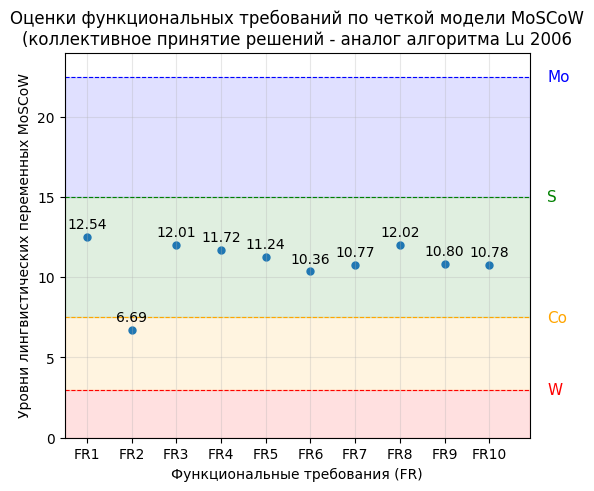

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [R_group_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW\n(коллективное принятие решений - аналог алгоритма Lu 2006")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

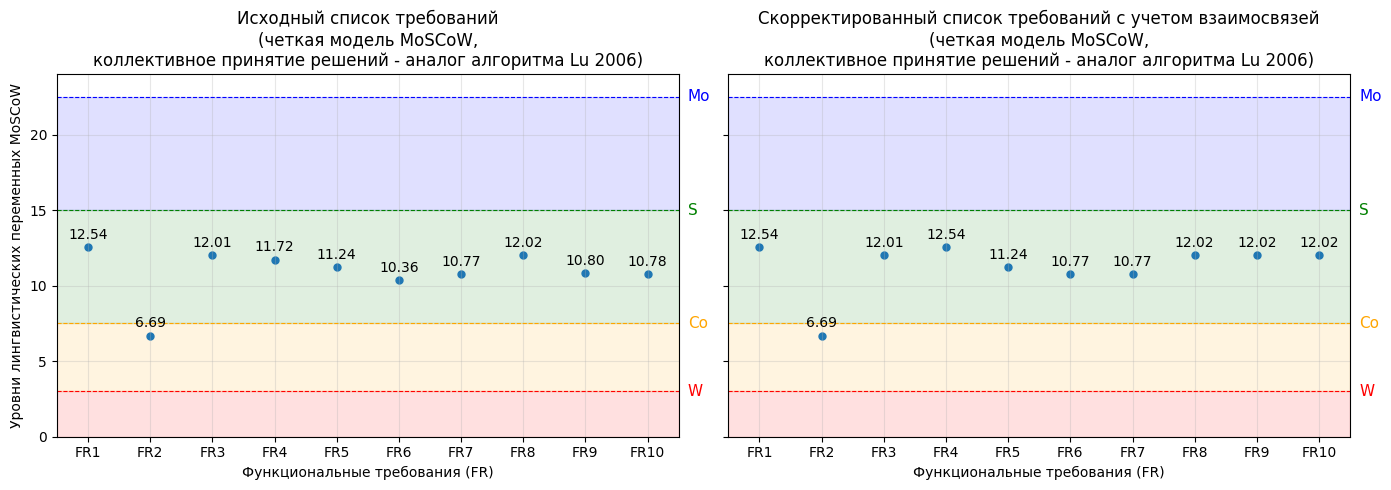

In [274]:
# Преобразуем скорректированный результат в словарь: {FR: adjusted_R_group}
adjusted_scores_by_fr = {item["fr"]: item["adjusted_R_group"] for item in adjusted_sorted_fr}

# Оценки требований в порядке FR1, FR2, ..., FR10
scores = [R_group_by_fr[fr] for fr in fr_labels]
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Lu 2006)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель MoSCoW,\nколлективное принятие решений - аналог алгоритма Lu 2006)"
]

all_scores = [scores, adjusted_scores]

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Полупрозрачная заливка интервалов
    for label, (ymin, ymax) in level_bounds.items():
        ax.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

    # Горизонтальные пунктирные линии
    for level in boundary_lines:
        ax.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    # Подписи уровней справа
    x_text = len(fr_labels) - 0.35
    for label, y in label_levels.items():
        ax.text(
            x_text,
            y,
            label,
            color=colors[label],
            ha="left",
            va="center",
            fontsize=11,
            zorder=2
        )

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, 24)
    ax.set_xlim(-0.5, len(fr_labels) - 0.5)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Уровни лингвистических переменных MoSCoW")

plt.tight_layout()
plt.show()

**Версия с загрузкой данных из файла и выгрузкой итогов в файл**

In [ ]:
# Версия с загрузкой данных из файла и выгрузкой итогов в файл Excel

from typing import Sequence, Any, Dict, Tuple, Optional, List
import numpy as np
import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

EPS = 1e-12

# 1) Шкалы MoSCoW (четкие)
MOSCOW_NFR_WEIGHTS: Dict[str, float] = {"Mo": 7.5, "S": 5.0, "Co": 2.5, "W": 1.0}
MOSCOW_FR_REL_WEIGHTS: Dict[str, float] = {"Mo": 1.0, "S": 0.66, "Co": 0.33, "W": 0.0}
_ALLOWED = set(MOSCOW_NFR_WEIGHTS.keys())


# 2) Парсинг листа эксперта
def parse_expert_sheet(ws) -> Dict[str, Any]:
    name = ws["A1"].value
    if not isinstance(name, str) or not name.strip():
        name = ws.title
    name = name.strip()

    # Заголовки столбцов NFR
    nfr_header_row = None
    for r in range(1, ws.max_row + 1):
        v = ws.cell(r, 1).value
        if isinstance(v, str) and "Нефункциональное требование" in v:
            nfr_header_row = r
            break
    if nfr_header_row is None:
        raise ValueError(f"Не найден блок NFR в листе: {ws.title}")

    # NFR names (со 2-го столбца)
    nfr_names = []
    c = 2
    while True:
        v = ws.cell(nfr_header_row, c).value
        if v is None or (isinstance(v, str) and v.strip() == ""):
            break
        nfr_names.append(str(v).strip())
        c += 1
    n = len(nfr_names)
    if n == 0:
        raise ValueError(f"{ws.title}: не найдены имена NFR")

    # Оценки NFR (следующая строка)
    pr_row = nfr_header_row + 1
    nfr_priorities = []
    for c in range(2, 2 + n):
        v = ws.cell(pr_row, c).value
        if v is None:
            raise ValueError(f"{ws.title}: пустой приоритет NFR (строка {pr_row}, столбец {c})")
        term = str(v).strip()
        if term not in _ALLOWED:
            raise ValueError(f"{ws.title}: недопустимый NFR приоритет '{term}'. Допустимо: {_ALLOWED}")
        nfr_priorities.append(term)

    # Столбцы заголовков FR
    fr_header_row = None
    for r in range(1, ws.max_row + 1):
        v = ws.cell(r, 1).value
        if isinstance(v, str) and "Функциональное требование" in v:
            fr_header_row = r
            break
    if fr_header_row is None:
        raise ValueError(f"Не найден блок FR в листе: {ws.title}")

    fr_start = fr_header_row + 2  # (строка с NFR в заголовке FR-таблицы + 1)
    fr_names = []
    frs = []
    r = fr_start
    while r <= ws.max_row:
        fr_name = ws.cell(r, 1).value
        if fr_name is None or (isinstance(fr_name, str) and fr_name.strip() == ""):
            break
        fr_name = str(fr_name).strip()
        fr_names.append(fr_name)

        row_ratings = []
        for c in range(2, 2 + n):
            v = ws.cell(r, c).value
            if v is None:
                raise ValueError(f"{ws.title}: пустая оценка FR={fr_name} (строка {r}, столбец {c})")
            term = str(v).strip()
            if term not in _ALLOWED:
                raise ValueError(f"{ws.title}: недопустимая оценка '{term}' в FR={fr_name}. Допустимо: {_ALLOWED}")
            row_ratings.append(term)

        frs.append(row_ratings)
        r += 1

    if not fr_names:
        raise ValueError(f"{ws.title}: не найдены строки FR")

    return {
        "name": name,
        "nfr": nfr_priorities,
        "frs": frs,
        "fr_names": fr_names,
        "nfr_names": nfr_names
    }

# 3) Нормализация весов экспертов
def normalize_expert_weights(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    normalize: bool = True,
) -> Tuple[List[str], List[float], Dict[str, float], Dict[str, float]]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")
    if len(experts) != len(weights):
        raise ValueError("Длины experts и weights должны совпадать.")

    names = [e.get("name", f"S{i+1}") for i, e in enumerate(experts)]
    w_raw = [float(x) for x in weights]

    if normalize:
        s = sum(w_raw)
        if abs(s) <= EPS:
            raise ValueError("Сумма весов экспертов равна 0 - невозможно нормировать.")
        w_norm = [x / s for x in w_raw]
    else:
        w_norm = w_raw[:]

    return names, w_norm, dict(zip(names, w_norm)), dict(zip(names, w_raw))

# 4) PFR одного эксперта
def moscow_pfr_scores_for_expert(
    nfr_priorities: Sequence[str],
    fr_vs_nfr_priorities: Sequence[Sequence[str]],
    fr_names: Sequence[str],
) -> Dict[str, float]:
    n = len(nfr_priorities)
    if n == 0:
        raise ValueError("nfr_priorities не должен быть пустым.")
    if len(fr_names) != len(fr_vs_nfr_priorities):
        raise ValueError("Длина fr_names должна совпадать с количеством FR.")

    nfr_w = [MOSCOW_NFR_WEIGHTS[x] for x in nfr_priorities]

    scores: Dict[str, float] = {}
    for fr_name, fr_row in zip(fr_names, fr_vs_nfr_priorities):
        if len(fr_row) != n:
            raise ValueError(f"{fr_name}: ожидалось {n} оценок (по числу NFR), получено {len(fr_row)}.")
        fr_w = [MOSCOW_FR_REL_WEIGHTS[x] for x in fr_row]
        scores[fr_name] = float(sum(a * b for a, b in zip(nfr_w, fr_w)))

    return scores

# 5) Подготовка входа
def prepare_crisp_moscow_inputs(
    experts: Sequence[Dict[str, Any]],
    weights: Sequence[float],
    fr_names: Optional[Sequence[str]] = None,
    normalize_weights: bool = True,
) -> Dict[str, Any]:
    if not experts:
        raise ValueError("experts не должен быть пустым.")

    if fr_names is None:
        fr_names = experts[0]["fr_names"]
    fr_names = list(fr_names)

    expert_names, w_norm_list, w_norm_by_name, w_raw_by_name = normalize_expert_weights(
        experts, weights, normalize=normalize_weights
    )

    expert_scores: Dict[str, Dict[str, float]] = {}
    for e, name in zip(experts, expert_names):
        expert_scores[name] = moscow_pfr_scores_for_expert(
            nfr_priorities=e["nfr"],
            fr_vs_nfr_priorities=e["frs"],
            fr_names=fr_names,
        )

    return {
        "fr_names": fr_names,
        "expert_names": expert_names,
        "weights_raw": w_raw_by_name,
        "weights_norm": w_norm_by_name,
        "weights_norm_list": w_norm_list,
        "expert_scores": expert_scores,  # PFR_raw
    }

# 6) Матрицы dM / AM(S) / AMr(R)
def build_crisp_matrices_by_fr(
    fr_names: Sequence[str],
    expert_names: Sequence[str],
    expert_scores: Dict[str, Dict[str, float]],
    beta: float,
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    if not (0.0 <= beta <= 1.0):
        raise ValueError("beta должен быть в диапазоне [0, 1].")

    k = len(expert_names)
    if k == 0:
        raise ValueError("expert_names не должен быть пустым.")
    if len(fr_names) == 0:
        raise ValueError("fr_names не должен быть пустым.")

    for ex in expert_names:
        if ex not in expert_scores:
            raise ValueError(f"Нет expert_scores для эксперта '{ex}'.")
        for fr in fr_names:
            if fr not in expert_scores[ex]:
                raise ValueError(f"У эксперта '{ex}' нет оценки для '{fr}'.")

    dM_by_fr: Dict[str, np.ndarray] = {}
    AM_by_fr: Dict[str, np.ndarray] = {}
    AMr_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        x = np.array([float(expert_scores[ex][fr]) for ex in expert_names], dtype=float)
        diff = np.abs(x[:, None] - x[None, :])
        D_star = float(diff.max())

        if D_star <= EPS:
            dM = np.zeros((k, k), dtype=float)
        else:
            dM = diff / D_star

        S = (1.0 - dM) ** 2
        R = beta * S + (1.0 - beta) * (1.0 - dM)

        dM_by_fr[fr] = dM
        AM_by_fr[fr] = S
        AMr_by_fr[fr] = R

    return dM_by_fr, AM_by_fr, AMr_by_fr


def average_R_matrices(AMr_by_fr: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    return {fr: np.asarray(M, dtype=float) for fr, M in AMr_by_fr.items()}

# 8) C(Ei)
def compute_C_for_all_fr(
    prepared: Dict[str, Any],
    R_avg_by_fr: Dict[str, np.ndarray],
) -> Dict[str, np.ndarray]:
    expert_names: List[str] = prepared["expert_names"]
    fr_names: List[str] = prepared["fr_names"]

    e = np.array([float(prepared["weights_norm"][name]) for name in expert_names], dtype=float)
    if e.sum() <= EPS:
        raise ValueError("Сумма нормализованных весов экспертов должна быть > 0.")

    k = len(expert_names)
    C_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        R = np.asarray(R_avg_by_fr[fr], dtype=float)
        if R.shape != (k, k):
            raise ValueError(f"{fr}: ожидаю матрицу {k}x{k}, получено {R.shape}")
        C_by_fr[fr] = R @ e

    return C_by_fr

# 9) w(Ei)
def compute_wE_for_all_fr(
    C_by_fr: Dict[str, np.ndarray],
    fr_names: Sequence[str],
) -> Dict[str, np.ndarray]:
    wE_by_fr: Dict[str, np.ndarray] = {}

    for fr in fr_names:
        C = np.asarray(C_by_fr[fr], dtype=float)

        # отсечение ошибок округления
        C = np.maximum(C, 0.0)

        s = float(C.sum())
        k = int(C.size)

        if s <= EPS:
            w = np.full(k, 1.0 / k, dtype=float)
        else:
            w = C / s

        wE_by_fr[fr] = w

    return wE_by_fr


# 10) Расчет итоговой оценки
def contributions_and_group(
    prepared: Dict[str, Any],
    wE_by_fr: Dict[str, np.ndarray],
) -> Tuple[Dict[str, Dict[str, float]], Dict[str, float]]:
    fr_names: List[str] = prepared["fr_names"]
    expert_names: List[str] = prepared["expert_names"]
    scores_raw: Dict[str, Dict[str, float]] = prepared["expert_scores"]

    contrib_by_fr: Dict[str, Dict[str, float]] = {}
    group_score_by_fr: Dict[str, float] = {}

    for fr in fr_names:
        w = np.asarray(wE_by_fr[fr], dtype=float)
        if w.shape != (len(expert_names),):
            raise ValueError(f"{fr}: w(Ei) имеет неверную размерность: {w.shape}")

        row = {}
        total = 0.0
        for i, ex in enumerate(expert_names):
            v = float(scores_raw[ex][fr]) * float(w[i])
            row[ex] = v
            total += v

        contrib_by_fr[fr] = row
        group_score_by_fr[fr] = total

    return contrib_by_fr, group_score_by_fr

# Формирование листа Excel
def _write_table_title(ws, row, title, merge_to_col):
    ws.cell(row, 1, value=title).font = Font(bold=True)
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=merge_to_col)
    ws.cell(row, 1).alignment = Alignment(wrap_text=True, horizontal="center", vertical="center")
    return row + 1

def _write_headers(ws, row, headers):
    for c, h in enumerate(headers, start=1):
        cell = ws.cell(row, c, value=h)
        cell.font = Font(bold=True)
        cell.alignment = Alignment(wrap_text=True, horizontal="center", vertical="center")
    return row + 1

def _autoset_col_width(ws, max_col, min_width=10, max_width=60):
    for c in range(1, max_col + 1):
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, c).value
            if v is None:
                continue
            max_len = max(max_len, len(str(v)))
        ws.column_dimensions[get_column_letter(c)].width = min(max(min_width, max_len + 2), max_width)

# Оформление матриц
def _write_matrix_block_no_labels(ws, start_row, title, fr_list, M_by_fr, merge_to_col) -> int:
    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    r = start_row
    ws.cell(r, 1, value=title).font = bold
    ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=merge_to_col)
    ws.cell(r, 1).alignment = center
    r += 1

    for fr in fr_list:
        ws.cell(r, 1, value=str(fr)).font = bold
        mat = np.asarray(M_by_fr[fr], dtype=float)
        k = mat.shape[0]

        for i in range(k):
            for j in range(k):
                ws.cell(r + i, 2 + j, value=float(mat[i, j]))

        r += k + 1  # матрица + пустая строка

    return r

# Главная функция(чтение, расчеты, выгрузка)
def export_crisp_beta_consensus_to_excel(
    input_xlsx: str,
    output_xlsx: str,
    weights: List[float],
    beta: float,
    sheet_name: str = "Четкий MoSCoW_коллектив",
):
    wb = openpyxl.load_workbook(input_xlsx)

    experts = []
    fr_names = None

    source_sheets = [s for s in wb.sheetnames if s != sheet_name]
    if len(weights) != len(source_sheets):
        raise ValueError(
            f"Число весов ({len(weights)}) должно совпадать с числом листов экспертов ({len(source_sheets)})."
        )

    for sname in source_sheets:
        ed = parse_expert_sheet(wb[sname])
        if fr_names is None:
            fr_names = ed["fr_names"]
        else:
            if ed["fr_names"] != fr_names:
                raise ValueError(f"Лист {sname}: набор FR отличается от первого листа.")
        experts.append({
            "name": ed["name"],
            "nfr": ed["nfr"],
            "frs": ed["frs"],
            "fr_names": ed["fr_names"],
        })

    if not experts:
        raise ValueError("Не найдено ни одного листа эксперта для чтения.")

    prepared = prepare_crisp_moscow_inputs(experts, weights, fr_names=fr_names, normalize_weights=True)
    fr_list = prepared["fr_names"]
    expert_names = prepared["expert_names"]
    expert_scores = prepared["expert_scores"]

    dM_by_fr, AM_by_fr, AMr_by_fr = build_crisp_matrices_by_fr(
        fr_names=fr_list,
        expert_names=expert_names,
        expert_scores=expert_scores,
        beta=float(beta),
    )

    R_avg_by_fr = average_R_matrices(AMr_by_fr)
    C_by_fr = compute_C_for_all_fr(prepared, R_avg_by_fr)
    wE_by_fr = compute_wE_for_all_fr(C_by_fr, fr_list)
    contrib_by_fr, group_score_by_fr = contributions_and_group(prepared, wE_by_fr)

    if sheet_name in wb.sheetnames:
        wb.remove(wb[sheet_name])
    ws = wb.create_sheet(sheet_name)

    k = len(expert_names)
    merge_to_col = max(6, 2 + k)

    bold = Font(bold=True)
    center = Alignment(horizontal="center", vertical="center", wrap_text=True)

    r = 1
    ws.cell(r, 1, value="Четкий MoSCoW - коллективное решение (алгоритм, сопоставимый с нечетким)").font = bold
    ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=merge_to_col)
    ws.cell(r, 1).alignment = center
    r += 2

    # Таблица 1: веса
    r = _write_table_title(ws, r, "Таблица 1. Удельные веса экспертов", merge_to_col)
    r = _write_headers(ws, r, ["Эксперт", "Вес_raw (r)", "Вес_norm (e)"])
    for name in expert_names:
        ws.cell(r, 1, value=name)
        ws.cell(r, 2, value=float(prepared["weights_raw"][name]))
        ws.cell(r, 3, value=float(prepared["weights_norm"][name]))
        r += 1
    ws.cell(r, 1, value="SUM").font = bold
    ws.cell(r, 2, value=sum(float(prepared["weights_raw"][n]) for n in expert_names))
    ws.cell(r, 3, value=sum(float(prepared["weights_norm"][n]) for n in expert_names))
    r += 2

    # beta
    ws.cell(r, 1, value="Параметр beta").font = bold
    ws.cell(r, 2, value=float(beta))
    r += 2

    # Таблица 2: PFR_raw
    r = _write_table_title(ws, r, "Таблица 2. Индивидуальные рейтинги FR по MoSCoW (PFR_raw)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + [f"PFR_raw {name}" for name in expert_names])
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(prepared["expert_scores"][name][fr]))
        r += 1
    r += 2

    # Матрицы dM, AM, AMr
    r = _write_matrix_block_no_labels(
        ws, r,
        title="Матрицы нормированного расстояния dM  по каждому FR",
        fr_list=fr_list,
        M_by_fr=dM_by_fr,
        merge_to_col=merge_to_col
    )
    r += 1

    r = _write_matrix_block_no_labels(
        ws, r,
        title="Матрицы сходства AM по каждому FR",
        fr_list=fr_list,
        M_by_fr=AM_by_fr,
        merge_to_col=merge_to_col
    )
    r += 1

    r = _write_matrix_block_no_labels(
        ws, r,
        title="Матрицы согласованности AMr по каждому FR",
        fr_list=fr_list,
        M_by_fr=AMr_by_fr,
        merge_to_col=merge_to_col
    )
    r += 1

    # Таблица 3: C(Ei)
    r = _write_table_title(ws, r, "Таблица 3. Взвешенная степень согласованности эксперта C(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        C = np.asarray(C_by_fr[fr], dtype=float)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(C[ci - 2]))
        r += 1
    r += 2

    # Таблица 4: w(Ei)
    r = _write_table_title(ws, r, "Таблица 4. Веса агрегирования экспертов w(Ei)", merge_to_col)
    r = _write_headers(ws, r, ["FR"] + expert_names)
    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        w = np.asarray(wE_by_fr[fr], dtype=float)
        for ci, name in enumerate(expert_names, start=2):
            ws.cell(r, ci, value=float(w[ci - 2]))
        r += 1
    r += 2

    # Таблица 5: вклады экспертов в агрегированную оценку + итоговая сумма
    r = _write_table_title(ws, r, "Таблица 5. Коллективный рейтинг функциональных задач", merge_to_col)
    r = _write_headers(
        ws, r,
        ["Функциональная задача"]
        + [f"Оценка {name} * w(Ei)" for name in expert_names]
        + ["Итог по FR"]
    )

    for fr in fr_list:
        ws.cell(r, 1, value=fr)
        row_sum = 0.0
        for ci, name in enumerate(expert_names, start=2):
            v = float(contrib_by_fr[fr][name])
            ws.cell(r, ci, value=v)
            row_sum += v
        ws.cell(r, 2 + k, value=float(row_sum))
        r += 1

    r += 2

    # Таблица 6: сортировка
    r = _write_table_title(ws, r, "Таблица 6. Итоговый коллективный рейтинг FR (сортировка по убыванию)", merge_to_col)
    r = _write_headers(ws, r, ["FR", "Агрегировання оценка"])
    for fr, val in sorted(group_score_by_fr.items(), key=lambda x: x[1], reverse=True):
        ws.cell(r, 1, value=fr)
        ws.cell(r, 2, value=float(val))
        r += 1

    _autoset_col_width(ws, max_col=max(3, 2 + k))
    wb.save(output_xlsx)


In [ ]:
# Запуск
input_path = "Загрузочные данные_MoSCoW_коллектив.xlsx"
output_path = "Итоги_четкий MoSCoW_Lu 2006.xlsx"

weights = [0.75, 0.75, 1.0]  # порядок = порядок листов экспертов в книге
beta = 0.4

export_crisp_beta_consensus_to_excel(
    input_xlsx=input_path,
    output_xlsx=output_path,
    weights=weights,
    beta=beta,
    sheet_name="Четкий MoSCoW_коллектив"
)

print("Файл сохранен:", output_path)

Файл сохранен: Итоги_четкий MoSCoW_Lu 2006.xlsx


# Визуализации к расчетной части проекта

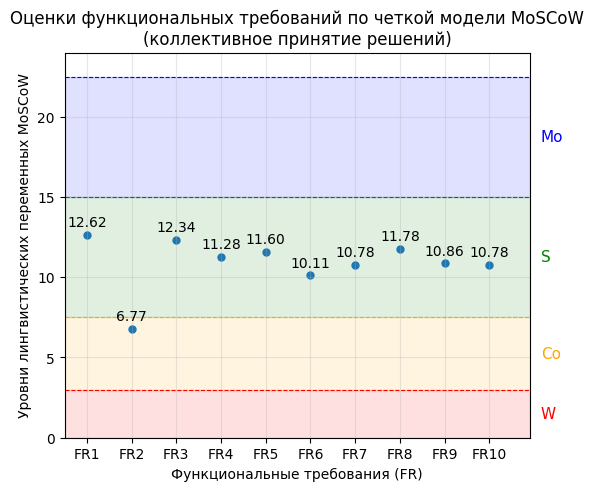

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований по MoSCoW (числовые значения)
scores = [12.62, 6.77, 12.34, 11.28, 11.60, 10.11, 10.78, 11.78, 10.86, 10.78]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи интервалов справа по центру каждого диапазона
x_text = len(fr_labels) + 0.15

for label, (ymin, ymax) in level_bounds.items():
    y_center = (ymin + ymax) / 2
    plt.text(
        x_text,
        y_center,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW\n(коллективное принятие решений)")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

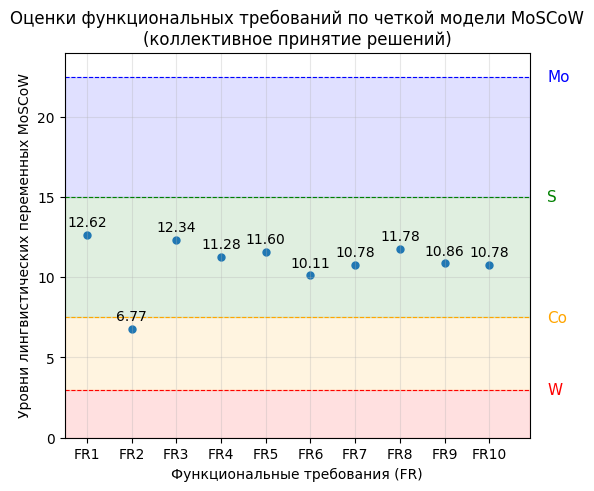

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований по MoSCoW (числовые значения)
scores = [12.62, 6.77, 12.34, 11.28, 11.60, 10.11, 10.78, 11.78, 10.86, 10.78]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW\n(коллективное принятие решений)")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

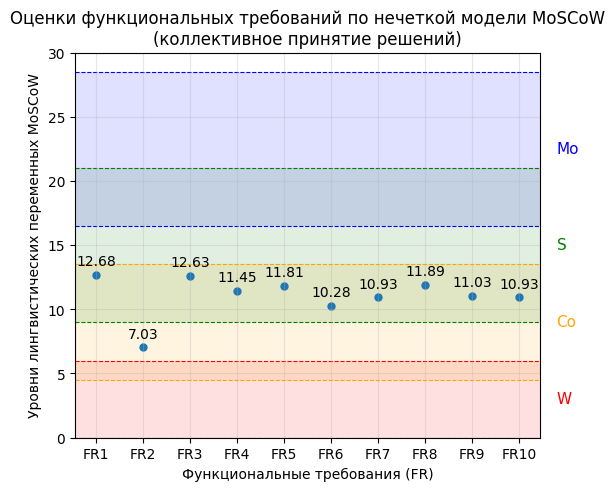

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований (точки остаются теми же)
scores = [12.68, 7.03, 12.63, 11.45, 11.81, 10.28, 10.93, 11.89, 11.03, 10.93]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) - 0.2   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW\n(коллективное принятие решений)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

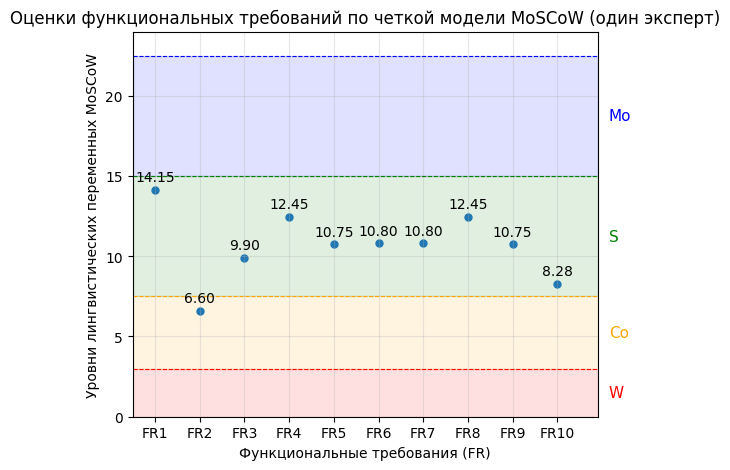

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований по MoSCoW (числовые значения)
scores = [14.15, 6.6, 9.9, 12.45, 10.75, 10.80, 10.80, 12.45, 10.75, 8.28]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи интервалов справа по центру каждого диапазона
x_text = len(fr_labels) + 0.15

for label, (ymin, ymax) in level_bounds.items():
    y_center = (ymin + ymax) / 2
    plt.text(
        x_text,
        y_center,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW (один эксперт)")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

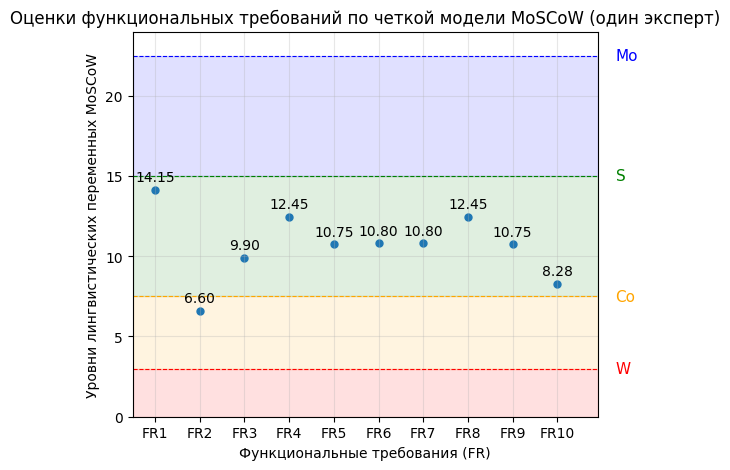

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований по MoSCoW (числовые значения)
scores = [14.15, 6.6, 9.9, 12.45, 10.75, 10.80, 10.80, 12.45, 10.75, 8.28]

# Позиции по оси X
x = np.arange(len(fr_labels))

# Границы интервалов
level_bounds = {
    "Mo": (15, 22.5),
    "S": (7.5, 15),
    "Co": (3, 7.5),
    "W": (0, 3)
}

# Цвета интервалов
colors = {
    "Mo": "blue",
    "S": "green",
    "Co": "orange",
    "W": "red"
}

# Уровни, на которых будут стоять подписи букв
label_levels = {
    "Mo": 22.5,
    "S": 15,
    "Co": 7.5,
    "W": 3
}

plt.figure(figsize=(6, 5))

# Полупрозрачная заливка интервалов
for label, (ymin, ymax) in level_bounds.items():
    plt.axhspan(ymin, ymax, color=colors[label], alpha=0.12)

# Горизонтальные пунктирные линии по границам интервалов
boundary_lines = [3, 7.5, 15, 22.5]
boundary_colors = {
    3: "red",
    7.5: "orange",
    15: "green",
    22.5: "blue"
}

for level in boundary_lines:
    plt.axhline(y=level, linestyle="--", linewidth=0.8, color=boundary_colors[level])

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.35, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Подписи уровней справа напротив пунктирных линий
x_text = len(fr_labels) + 0.3

for label, y in label_levels.items():
    plt.text(
        x_text,
        y,
        label,
        color=colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

# Заголовок
plt.title("Оценки функциональных требований по четкой модели MoSCoW (один эксперт)")

# Пределы осей
plt.ylim(0, 24)
plt.xlim(-0.5, len(fr_labels) - 0.1)

# Сетка
plt.grid(alpha=0.3)

plt.show()

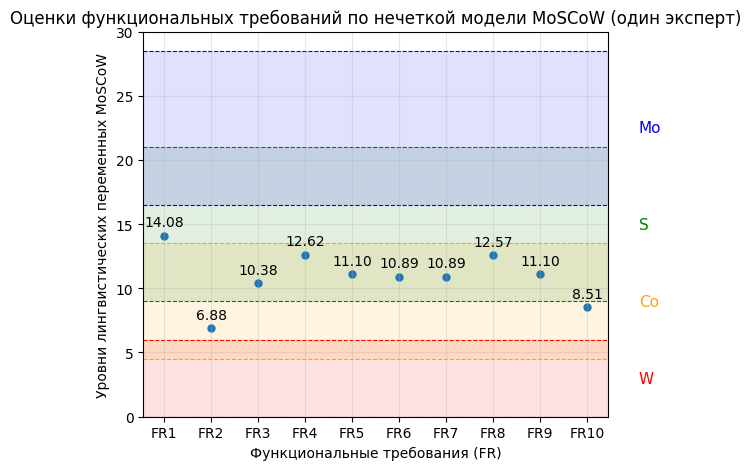

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = ["FR1", "FR2", "FR3", "FR4", "FR5", "FR6", "FR7", "FR8", "FR9", "FR10"]

# Оценки требований
scores = [14.08, 6.88, 10.38, 12.62, 11.1, 10.89, 10.89, 12.57, 11.1, 8.51]

x = np.arange(len(fr_labels))

# Интервалы нечетких лингвистических уровней MoSCoW (нижняя и верхняя границы)
moscow_intervals = {
    "W":  (0.0, 6.0),
    "Co": (4.5, 13.5),
    "S":  (9.0, 21.0),
    "Mo": (16.5, 28.5)
}

# Цвета (линии)
line_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

# Цвета заливки (как линии)
fill_colors = {
    "W": "red",
    "Co": "orange",
    "S": "green",
    "Mo": "blue"
}

plt.figure(figsize=(6, 5))

# Точки (оценки функциональных требований)
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 0.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Рисуем интервалы: заливка + две пунктирные границы + подпись справа по центру
x_text = len(fr_labels) + 0.1   # положение подписей справа внутри области графика
alpha_fill = 0.12               # прозрачность заливки (регулируй для наглядности пересечений)

for label, (y_low, y_high) in moscow_intervals.items():
    # Полупрозрачная заливка полосы (пересечения автоматически дадут смешанные цвета)
    plt.axhspan(y_low, y_high, facecolor=fill_colors[label], alpha=alpha_fill, zorder=0)

    # Границы интервала: две пунктирные линии
    plt.axhline(y=y_low,  linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)
    plt.axhline(y=y_high, linestyle="--", linewidth=0.8, color=line_colors[label], zorder=1)

    # Подпись уровня справа по центру интервала
    y_mid = (y_low + y_high) / 2
    plt.text(
        x_text,
        y_mid,
        label,
        color=line_colors[label],
        ha="left",
        va="center",
        fontsize=11,
        zorder=2
    )

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Уровни лингвистических переменных MoSCoW")

plt.title("Оценки функциональных требований по нечеткой модели MoSCoW (один эксперт)")

# Пределы по оси Y (чтобы был виден верхний уровень Mo = 28.5)
plt.ylim(0, 30)

plt.grid(alpha=0.3)
plt.show()

# 3 Приоритизации по методу RICE

# 3.1. Нечеткий метод RICE

In [277]:
# Функция произведения двуж нечетких трапециевидных чисел
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [278]:
# Функция вычмсления произведения нескольких нечетких чисел, для данной модели - показателей R, I, C в нечетком виде
def calculate_RIC_multiply(*params):
    RIC_multiply = params[0]
    for param in params[1:]:
        RIC_multiply = multiply_intuitionistic_trapezoidal_fuzzy_numbers (RIC_multiply, param)
    return RIC_multiply

In [279]:
# Функция округления параметров трапециевидного нечеткого числа (интуиционистского или интервального 2 типа)
def round_fuzzy_number(fuzzy_number):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    return ((round(x1, 2), round(x2, 2), round(x3, 2), round(x4, 2)),
            (round(x5, 2), round(x6, 2), round(x7, 2), round(x8, 2)))

In [280]:
# Функция деления отдного нечеткого трапециевичного числа на другое
def divide_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для частного от деления
    z1 = (x2 * y3 - x2 * y4 + x1 * y3) / ((y3)**2)
    z2 = x2 / y3
    z3 = x3 / y2
    z4 = (x3 * y2 - x3 * y1 + x4 * y2) / ((y2)**2)

    z5 = (x6 * y7 - x6 * y8 + x5 * y7) / ((y7)**2)
    z6 = x6 / y7
    z7 = x7 / y6
    z8 = (x7 * y6 - x7 * y5 + x8 * y6) / ((y6)**2)

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

In [281]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )

In [282]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

In [283]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central

**Пример интерпретации нечеткого метода RICE: расчет для FR1**

In [ ]:
# Ввод показателей R, I, C, E в нечетком виде.
R = ((9700, 9900, 10100, 10300), (9800, 9900, 10100, 10200))  # Reach (Охват), количество человек
I = ((0.97, 0.99, 1.01, 1.03), (0.98, 0.99, 1.01, 1.02)) # Impact (Влияние), оценка в баллах
C = ((0.58, 0.59, 0.61, 0.62), (0.59, 0.59, 0.61, 0.61)) # Confidence (Уверенность), коэффициент от 0,5 до 1
E = ((9.70, 9.90, 10.10, 10.30), (9.80, 9.90, 10.10, 10.20)) # Effort (Трудозатраты), количество недель

RIC_mult = calculate_RIC_multiply(R, I, C)
# Округляем RIC
RIC_rounded = round_fuzzy_number(RIC_mult)

print(f"При вышеуказанных значениях параметров R, I, C, произведение RIC в нечетком виде принимает значение {RIC_rounded}")

При вышеуказанных значениях параметров R, I, C, произведение RIC в нечетком виде принимает значение ((5450.94, 5782.59, 6222.61, 6571.06), (5665.77, 5782.59, 6222.61, 6345.83))


In [ ]:
RICE_score = divide_intuitionistic_trapezoidal_fuzzy_numbers(RIC_mult, E)
# Округляем RICE
RICE_rounded = round_fuzzy_number(RICE_score)

print(f"При вышеуказанных значениях параметров R, I, C, E показатель RICE в нечетком виде принимает значение {RICE_rounded}")

При вышеуказанных значениях параметров R, I, C, E показатель RICE в нечетком виде принимает значение ((528.36, 572.53, 628.55, 676.44), (555.3, 572.53, 628.55, 647.34))


In [ ]:
# Редукция типа ИНМТ2 в ИНМТ1 для показателя RICE

a = 0.6  # параметр редукции

RICE_reduced = cltr_type_reduction(RICE_rounded, a)

print(f"При параметре редукции a={a} показатель RICE в виде ИНМТ1 принимает значение {RICE_reduced}")

При параметре редукции a=0.6 показатель RICE в виде ИНМТ1 принимает значение (544.52, 572.53, 628.55, 658.98)


In [ ]:
# Дефаззификация ИНМТ1 через альфа-срез

alpha = 0.8
alpha_cut_result = alpha_cut(RICE_reduced, alpha)

print(f"Альфа-срез при alpha={alpha} для RICE_reduced {RICE_reduced} равен {alpha_cut_result}")

Альфа-срез при alpha=0.8 для RICE_reduced (544.52, 572.53, 628.55, 658.98) равен (566.93, 634.64)


In [ ]:
# Вычисление центроида по результату альфа-среза

central_result = centroid(alpha_cut_result)

print(f"Центроид для альфа-среза {alpha_cut_result} при alpha={alpha} равен {central_result}")

Центроид для альфа-среза (566.93, 634.64) при alpha=0.8 равен 600.78


**Реализация нечеткой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных в ноутбуке**

In [284]:
# Ввод данных для функциональных требований FR в виде словаря.
# Каждое значение R, I, C, E задается как ИНМТ2:
# ((x1, x2, x3, x4), (x5, x6, x7, x8))

features_fuzzy = [
    {
        "Feature": "FR1",
        "R": ((9700, 9900, 10100, 10300), (9800, 9900, 10100, 10200)),
        "I": ((0.97, 0.99, 1.01, 1.03), (0.98, 0.99, 1.01, 1.02)),
        "C": ((0.582, 0.594, 0.606, 0.618), (0.588, 0.594, 0.606, 0.612)),
        "E": ((9.70, 9.90, 10.10, 10.30), (9.80, 9.90, 10.10, 10.20)),
    },
    {
        "Feature": "FR2",
        "R": ((97, 99, 101, 103), (98, 99, 101, 102)),
        "I": ((2.91, 2.97, 3.03, 3.09), (2.94, 2.97, 3.03, 3.06)),
        "C": ((0.873, 0.891, 0.909, 0.927), (0.882, 0.891, 0.909, 0.918)),
        "E": ((4.85, 4.95, 5.05, 5.15), (4.90, 4.95, 5.05, 5.10)),
    },
    {
        "Feature": "FR3",
        "R": ((970, 990, 1010, 1030), (980, 990, 1010, 1020)),
        "I": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
        "C": ((0.776, 0.792, 0.808, 0.824), (0.784, 0.792, 0.808, 0.816)),
        "E": ((6.79, 6.93, 7.07, 7.21), (6.86, 6.93, 7.07, 7.14)),
    },
    {
        "Feature": "FR4",
        "R": ((97, 99, 101, 103), (98, 99, 101, 102)),
        "I": ((0.485, 0.495, 0.505, 0.515), (0.49, 0.495, 0.505, 0.51)),
        "C": ((0.679, 0.693, 0.707, 0.721), (0.686, 0.693, 0.707, 0.714)),
        "E": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
    },
    {
        "Feature": "FR5",
        "R": ((194, 198, 202, 206), (196, 198, 202, 204)),
        "I": ((2.91, 2.97, 3.03, 3.09), (2.94, 2.97, 3.03, 3.06)),
        "C": ((0.485, 0.495, 0.505, 0.515), (0.49, 0.495, 0.505, 0.51)),
        "E": ((11.64, 11.88, 12.12, 12.36), (11.76, 11.88, 12.12, 12.24)),
    },
    {
        "Feature": "FR6",
        "R": ((9.7, 9.9, 10.1, 10.3), (9.8, 9.9, 10.1, 10.2)),
        "I": ((0.97, 0.99, 1.01, 1.03), (0.98, 0.99, 1.01, 1.02)),
        "C": ((0.97, 0.99, 1.01, 1.03), (0.98, 0.99, 1.01, 1.02)),
        "E": ((12.61, 12.87, 13.13, 13.39), (12.74, 12.87, 13.13, 13.26)),
    },
    {
        "Feature": "FR7",
        "R": ((48.5, 49.5, 50.5, 51.5), (49.0, 49.5, 50.5, 51.0)),
        "I": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
        "C": ((0.776, 0.792, 0.808, 0.824), (0.784, 0.792, 0.808, 0.816)),
        "E": ((20.37, 20.79, 21.21, 21.63), (20.58, 20.79, 21.21, 21.42)),
    },
    {
        "Feature": "FR8",
        "R": ((970, 990, 1010, 1030), (980, 990, 1010, 1020)),
        "I": ((0.485, 0.495, 0.505, 0.515), (0.49, 0.495, 0.505, 0.51)),
        "C": ((0.873, 0.891, 0.909, 0.927), (0.882, 0.891, 0.909, 0.918)),
        "E": ((4.85, 4.95, 5.05, 5.15), (4.90, 4.95, 5.05, 5.10)),
    },
    {
        "Feature": "FR9",
        "R": ((19400, 19800, 20200, 20600), (19600, 19800, 20200, 20400)),
        "I": ((0.2425, 0.2475, 0.2525, 0.2575), (0.245, 0.2475, 0.2525, 0.255)),
        "C": ((0.582, 0.594, 0.606, 0.618), (0.588, 0.594, 0.606, 0.612)),
        "E": ((6.79, 6.93, 7.07, 7.21), (6.86, 6.93, 7.07, 7.14)),
    },
    {
        "Feature": "FR10",
        "R": ((291, 297, 303, 309), (294, 297, 303, 306)),
        "I": ((1.94, 1.98, 2.02, 2.06), (1.96, 1.98, 2.02, 2.04)),
        "C": ((0.679, 0.693, 0.707, 0.721), (0.686, 0.693, 0.707, 0.714)),
        "E": ((2.91, 2.97, 3.03, 3.09), (2.94, 2.97, 3.03, 3.06)),
    },
]

In [285]:
# Расчет нечетких оценок RICE для произвольного числа функциональных требований

rice_results_fuzzy = []

for feature_data in features_fuzzy:
    feature_name = feature_data["Feature"]
    R = feature_data["R"]
    I = feature_data["I"]
    C = feature_data["C"]
    E = feature_data["E"]

    # Вычисляем произведение R * I * C
    RIC_mult = calculate_RIC_multiply(R, I, C)
    RIC_rounded = round_fuzzy_number(RIC_mult)

    # Вычисляем нечеткую оценку RICE = (R * I * C) / E
    RICE_score = divide_intuitionistic_trapezoidal_fuzzy_numbers(RIC_mult, E)
    RICE_rounded = round_fuzzy_number(RICE_score)

    rice_results_fuzzy.append({
        "Feature": feature_name,
        "RICE Score Fuzzy": RICE_rounded
    })

# Вывод списка нечетких оценок RICE
for item in rice_results_fuzzy:
    print(f"{item['Feature']}: {item['RICE Score Fuzzy']}")

FR1: ((530.07, 576.42, 624.42, 674.13), (553.24, 576.42, 624.42, 649.28))
FR2: ((47.71, 51.88, 56.2, 60.67), (49.79, 51.88, 56.2, 58.44))
FR3: ((201.93, 219.59, 237.88, 256.81), (210.76, 219.59, 237.88, 247.34))
FR4: ((15.46, 16.81, 18.21, 19.66), (16.14, 16.81, 18.21, 18.94))
FR5: ((22.09, 24.02, 26.02, 28.09), (23.05, 24.02, 26.02, 27.05))
FR6: ((0.68, 0.74, 0.8, 0.86), (0.71, 0.74, 0.8, 0.83))
FR7: ((3.37, 3.66, 3.96, 4.28), (3.51, 3.66, 3.96, 4.12))
FR8: ((79.51, 86.46, 93.66, 101.12), (82.99, 86.46, 93.66, 97.39))
FR9: ((378.62, 411.73, 446.02, 481.52), (395.17, 411.73, 446.02, 463.77))
FR10: ((123.68, 134.5, 145.7, 157.3), (129.09, 134.5, 145.7, 151.5))


In [286]:
# Редукция типа ИНМТ2 в ИНМТ1 для всех функциональных требований

a = 0.6  # параметр редукции

rice_reduced_results = []

for item in rice_results_fuzzy:
    feature_name = item["Feature"]
    rice_fuzzy = item["RICE Score Fuzzy"]

    rice_reduced = cltr_type_reduction(rice_fuzzy, a)

    rice_reduced_results.append({
        "Feature": feature_name,
        "RICE Score Reduced": rice_reduced
    })

for item in rice_reduced_results:
    print(f"{item['Feature']}: {item['RICE Score Reduced']}")

FR1: (543.97, 576.42, 624.42, 659.22)
FR2: (48.96, 51.88, 56.2, 59.33)
FR3: (207.23, 219.59, 237.88, 251.13)
FR4: (15.87, 16.81, 18.21, 19.23)
FR5: (22.67, 24.02, 26.02, 27.47)
FR6: (0.7, 0.74, 0.8, 0.84)
FR7: (3.45, 3.66, 3.96, 4.18)
FR8: (81.6, 86.46, 93.66, 98.88)
FR9: (388.55, 411.73, 446.02, 470.87)
FR10: (126.93, 134.5, 145.7, 153.82)


In [287]:
# Дефаззификация ИНМТ1 через альфа-срез для всех функциональных требований

alpha = 0.8

rice_alpha_cut_results = []

for item in rice_reduced_results:
    feature_name = item["Feature"]
    rice_reduced = item["RICE Score Reduced"]

    alpha_cut_result = alpha_cut(rice_reduced, alpha)

    rice_alpha_cut_results.append({
        "Feature": feature_name,
        "Alpha-cut": alpha_cut_result
    })

for item in rice_alpha_cut_results:
    print(f"{item['Feature']}: {item['Alpha-cut']}")

FR1: (569.93, 631.38)
FR2: (51.3, 56.83)
FR3: (217.12, 240.53)
FR4: (16.62, 18.41)
FR5: (23.75, 26.31)
FR6: (0.73, 0.81)
FR7: (3.62, 4.0)
FR8: (85.49, 94.7)
FR9: (407.09, 450.99)
FR10: (132.99, 147.32)


In [288]:
# Вычисление центроида для всех функциональных требований

rice_centroid_results = []

for item in rice_alpha_cut_results:
    feature_name = item["Feature"]
    alpha_cut_result = item["Alpha-cut"]

    centroid_result = centroid(alpha_cut_result)

    rice_centroid_results.append({
        "Feature": feature_name,
        "Centroid": centroid_result
    })

for item in rice_centroid_results:
    print(f"{item['Feature']}: {item['Centroid']}")

FR1: 600.65
FR2: 54.06
FR3: 228.82
FR4: 17.52
FR5: 25.03
FR6: 0.77
FR7: 3.81
FR8: 90.09
FR9: 429.04
FR10: 140.16


In [289]:
# Итоговая приоритизация функциональных требований по значению центроида

import pandas as pd

df_rice_final = pd.DataFrame(rice_centroid_results)

# Сортировка по убыванию значения центроида
df_rice_final = df_rice_final.sort_values("Centroid", ascending=False).reset_index(drop=True)

# Добавляем ранг
df_rice_final.insert(0, "Rank", df_rice_final.index + 1)

print(df_rice_final.to_string(index=False))

 Rank Feature  Centroid
    1     FR1    600.65
    2     FR9    429.04
    3     FR3    228.82
    4    FR10    140.16
    5     FR8     90.09
    6     FR2     54.06
    7     FR5     25.03
    8     FR4     17.52
    9     FR7      3.81
   10     FR6      0.77


Алгоритм учета взаимосвязанности функциональных требований

In [290]:
def adjust_rice_ranked_by_interdependencies(
    ranked_list: List[Dict[str, Any]],
    relation_matrix: Sequence[Sequence[int]],
) -> List[Dict[str, Any]]:
    """
    Корректирует итоговый дефаззифицированный список ranked_list с учетом взаимосвязи требований.

    ranked_list: список словарей, где есть как минимум:
        - "Feature"
        - "Centroid"

    ВАЖНО:
    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn

    Поэтому привязка к матрице идет не по позиции элемента в ranked_list,
    а по номеру требования из поля "Feature".
    """

    n = len(ranked_list)
    if n == 0:
        return []

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(feature_name: str) -> int:
        if not feature_name.startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {feature_name}"
            )
        return int(feature_name.replace("FR", "")) - 1

    fr_indices = [fr_to_index(item["Feature"]) for item in ranked_list]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в ranked_list должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted = []
    for idx, item in enumerate(ranked_list):
        new_item = dict(item)
        new_item["original_rank"] = idx + 1
        new_item["Adjusted_Centroid"] = item["Centroid"]
        adjusted.append(new_item)

    matrix_idx_to_item = {}
    for item in adjusted:
        matrix_idx_to_item[fr_to_index(item["Feature"])] = item

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_centroid = max(matrix_idx_to_item[i]["Centroid"] for i in comp)
        for i in comp:
            matrix_idx_to_item[i]["Adjusted_Centroid"] = max_centroid

    adjusted_sorted = sorted(
        adjusted,
        key=lambda x: (-x["Adjusted_Centroid"], x["original_rank"])
    )

    return adjusted_sorted

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [292]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_rice_centroid_results = adjust_rice_ranked_by_interdependencies(
    rice_centroid_results,
    relation_matrix
)

print("Скорректированный ранжированный список:")
for item in adjusted_rice_centroid_results:
    print(
        f"{item['Feature']}: "
        f"исходный Centroid = {item['Centroid']:.2f}, "
        f"скорректированный Centroid = {item['Adjusted_Centroid']:.2f}"
    )

Скорректированный ранжированный список:
FR1: исходный Centroid = 600.65, скорректированный Centroid = 600.65
FR4: исходный Centroid = 17.52, скорректированный Centroid = 600.65
FR8: исходный Centroid = 90.09, скорректированный Centroid = 429.04
FR9: исходный Centroid = 429.04, скорректированный Centroid = 429.04
FR10: исходный Centroid = 140.16, скорректированный Centroid = 429.04
FR3: исходный Centroid = 228.82, скорректированный Centroid = 228.82
FR2: исходный Centroid = 54.06, скорректированный Centroid = 54.06
FR5: исходный Centroid = 25.03, скорректированный Centroid = 25.03
FR6: исходный Centroid = 0.77, скорректированный Centroid = 3.81
FR7: исходный Centroid = 3.81, скорректированный Centroid = 3.81


Визуализации исходного и итогового приоритизированного списков функциональных требований

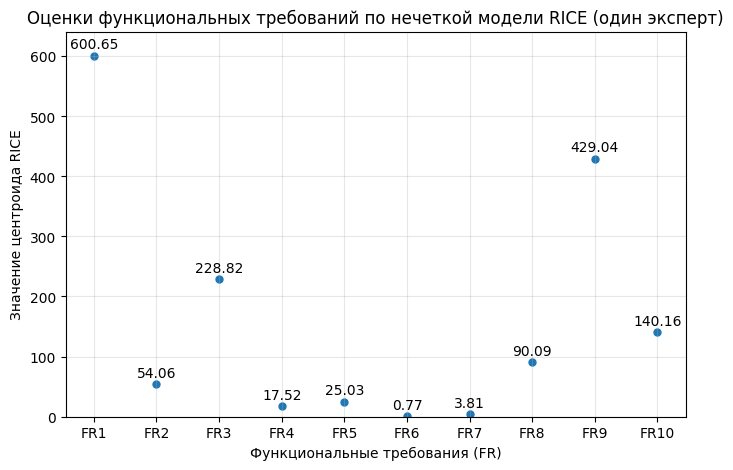

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Подписи функциональных требований
fr_labels = [r["Feature"] for r in rice_centroid_results]

# Оценки требований: уже вычисленные центроиды
scores = [r["Centroid"] for r in rice_centroid_results]

# Позиции по оси X
x = np.arange(len(fr_labels))

plt.figure(figsize=(8, 5))

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
for i, value in enumerate(scores):
    plt.text(x[i], value + 7.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Значение центроида RICE")

plt.title("Оценки функциональных требований по нечеткой модели RICE (один эксперт)")

# Пределы по оси Y с небольшим запасом сверху
plt.ylim(0, max(scores) + 40)

plt.grid(alpha=0.3)
plt.show()

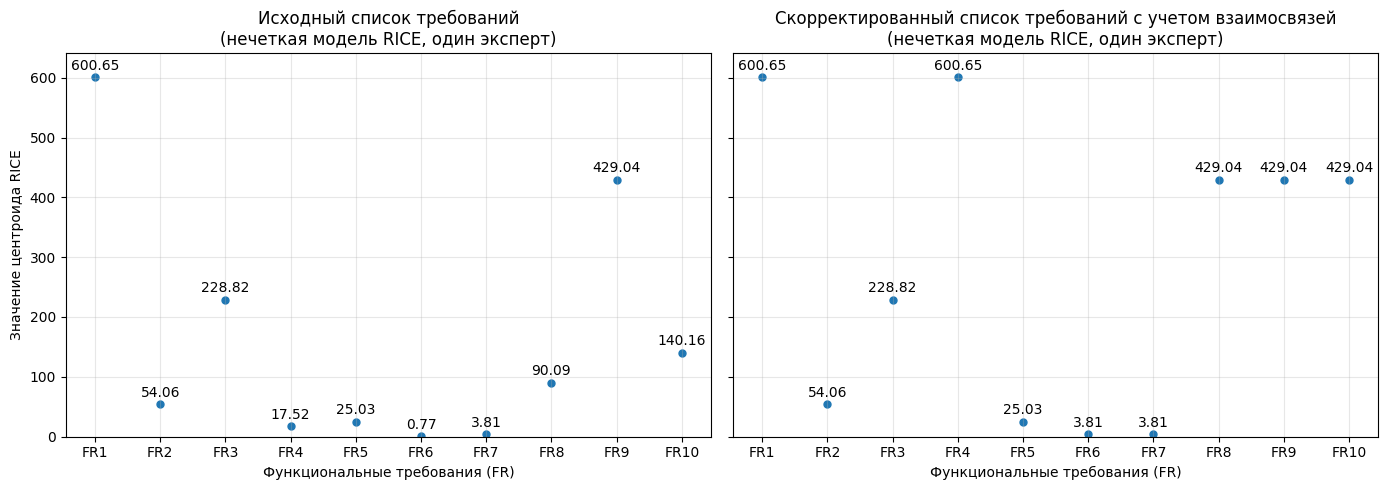

In [294]:
# Исходные и скорректированные оценки требований
scores = [r["Centroid"] for r in rice_centroid_results]
adjusted_scores_by_fr = {r["Feature"]: r["Adjusted_Centroid"] for r in adjusted_rice_centroid_results}
adjusted_scores = [adjusted_scores_by_fr[fr] for fr in fr_labels]

# Позиции по оси X
x = np.arange(len(fr_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(нечеткая модель RICE, один эксперт)",
    "Скорректированный список требований с учетом взаимосвязей\n(нечеткая модель RICE, один эксперт)"
]

all_scores = [scores, adjusted_scores]
y_max = max(max(scores), max(adjusted_scores)) + 40

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + 7.5, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Значение центроида RICE")

plt.tight_layout()
plt.show()

**Реализация нечеткой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных из файла/ в файл**

In [ ]:
# Реализация Fuzzy RICE с загрузкой данных из Excel

from pathlib import Path
import shutil
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.utils import get_column_letter


def compute_fuzzy_rice_from_file(
    input_path: str,
    input_sheet_name: str = "Fuzzy RICE_эксперт 1",
    output_sheet_name: str = "Итоги_Fuzzy RICE_эксперт 1",
    output_path: str | None = None,
    a: float = 0.6,
    alpha: float = 0.8
) -> pd.DataFrame:
    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Файл не найден: {input_path}")

    if input_path.suffix.lower() not in [".xlsx", ".xls"]:
        raise ValueError("Для такого режима работы нужен Excel-файл .xlsx или .xls")

    if output_path is None:
        output_path = input_path.with_name("Итоги_Fuzzy RICE_один эксперт" + input_path.suffix)
    else:
        output_path = Path(output_path)

    # Читаем лист без заголовков, так как структура входного листа нестандартная
    raw_df = pd.read_excel(input_path, sheet_name=input_sheet_name, header=None)

    if raw_df.shape[0] < 3:
        raise ValueError("На листе недостаточно строк для чтения данных.")

    data_rows = raw_df.iloc[2:].copy().reset_index(drop=True)

    results = []

    for _, row in data_rows.iterrows():
        feature = row[0]

        if pd.isna(feature):
            continue

        feature = str(feature).strip()
        if feature == "":
            continue

        try:
            # R
            R = (
                (float(row[1]),  float(row[2]),  float(row[3]),  float(row[4])),
                (float(row[5]),  float(row[6]),  float(row[7]),  float(row[8]))
            )

            # I
            I = (
                (float(row[9]),  float(row[10]), float(row[11]), float(row[12])),
                (float(row[13]), float(row[14]), float(row[15]), float(row[16]))
            )

            # C
            C = (
                (float(row[17]), float(row[18]), float(row[19]), float(row[20])),
                (float(row[21]), float(row[22]), float(row[23]), float(row[24]))
            )

            # E
            E = (
                (float(row[25]), float(row[26]), float(row[27]), float(row[28])),
                (float(row[29]), float(row[30]), float(row[31]), float(row[32]))
            )
        except Exception as e:
            raise ValueError(f"Ошибка чтения параметров для {feature}: {e}")

        # 1) RICE в формате ИНМТ2
        RIC_mult = calculate_RIC_multiply(R, I, C)
        RICE_score = divide_intuitionistic_trapezoidal_fuzzy_numbers(RIC_mult, E)
        RICE_fuzzy = round_fuzzy_number(RICE_score)

        # 2) Редукция ИНМТ2 -> ИНМТ1
        RICE_reduced = cltr_type_reduction(RICE_fuzzy, a)

        # 3) Дефаззификация через alpha-cut
        alpha_interval = alpha_cut(RICE_reduced, alpha)

        # 4) Центроид
        centroid_value = centroid(alpha_interval)

        # Распаковка ИНМТ2
        (it2_x1, it2_x2, it2_x3, it2_x4), (it2_x5, it2_x6, it2_x7, it2_x8) = RICE_fuzzy

        # Распаковка ИНМТ1
        it1_x1, it1_x2, it1_x3, it1_x4 = RICE_reduced

        # Распаковка alpha-cut
        alpha_left, alpha_right = alpha_interval

        results.append({
            "Ранг": None,
            "Feature": feature,

            "ИНМТ2 x1": it2_x1,
            "ИНМТ2 x2": it2_x2,
            "ИНМТ2 x3": it2_x3,
            "ИНМТ2 x4": it2_x4,
            "ИНМТ2 x5": it2_x5,
            "ИНМТ2 x6": it2_x6,
            "ИНМТ2 x7": it2_x7,
            "ИНМТ2 x8": it2_x8,

            "ИНМТ1 x1": it1_x1,
            "ИНМТ1 x2": it1_x2,
            "ИНМТ1 x3": it1_x3,
            "ИНМТ1 x4": it1_x4,

            "Альфа-срез левый": alpha_left,
            "Альфа-срез правый": alpha_right,

            "Центроид": round(centroid_value, 2)
        })

    if not results:
        raise ValueError("Не удалось прочитать ни одной строки с функциональными требованиями.")

    result_df = pd.DataFrame(results)

    ordered_columns = [
        "Ранг", "Feature",
        "ИНМТ2 x1", "ИНМТ2 x2", "ИНМТ2 x3", "ИНМТ2 x4",
        "ИНМТ2 x5", "ИНМТ2 x6", "ИНМТ2 x7", "ИНМТ2 x8",
        "ИНМТ1 x1", "ИНМТ1 x2", "ИНМТ1 x3", "ИНМТ1 x4",
        "Альфа-срез левый", "Альфа-срез правый",
        "Центроид"
    ]
    result_df = result_df[ordered_columns]

    # Сортировка по убыванию центроида
    result_df = result_df.sort_values("Центроид", ascending=False).reset_index(drop=True)
    result_df["Ранг"] = result_df.index + 1

    # Создаем новый файл как копию исходного
    shutil.copy2(input_path, output_path)

    # Записываем данные без стандартного заголовка, начиная с 3-й строки
    with pd.ExcelWriter(
        output_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        result_df.to_excel(writer, sheet_name=output_sheet_name, index=False, header=False, startrow=2)

    # Открываем книгу для оформления
    workbook = load_workbook(output_path)
    worksheet = workbook[output_sheet_name]

    # Двухстрочный заголовок

    worksheet["A1"] = "Приоритизация"
    worksheet["B1"] = "Функциональное требование"
    worksheet["C1"] = "RICE в формате ИНМТ2"
    worksheet["K1"] = "RICE после редукции в ИНМТ1"
    worksheet["O1"] = "Альфа-срез"
    worksheet["Q1"] = "Итог"

    # Объединение ячеек
    worksheet.merge_cells("A1:A2")
    worksheet.merge_cells("B1:B2")
    worksheet.merge_cells("C1:J1")
    worksheet.merge_cells("K1:N1")
    worksheet.merge_cells("O1:P1")
    worksheet.merge_cells("Q1:Q2")

    # Вторая строка заголовка
    worksheet["C2"] = "x1"
    worksheet["D2"] = "x2"
    worksheet["E2"] = "x3"
    worksheet["F2"] = "x4"
    worksheet["G2"] = "x5"
    worksheet["H2"] = "x6"
    worksheet["I2"] = "x7"
    worksheet["J2"] = "x8"

    worksheet["K2"] = "x1"
    worksheet["L2"] = "x2"
    worksheet["M2"] = "x3"
    worksheet["N2"] = "x4"

    worksheet["O2"] = "Левый"
    worksheet["P2"] = "Правый"

    # Оформление

    bold_font = Font(bold=True)
    center_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    thin = Side(style="thin")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    header_fill = PatternFill(fill_type="solid", fgColor="D9EAF7")

    # Границы и выравнивание
    for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
        for cell in row:
            cell.alignment = center_alignment
            cell.border = border

    # Оформление заголовков
    for row in worksheet.iter_rows(min_row=1, max_row=2, min_col=1, max_col=worksheet.max_column):
        for cell in row:
            cell.font = bold_font
            cell.fill = header_fill

    worksheet.row_dimensions[1].height = 24
    worksheet.row_dimensions[2].height = 24

    # Автонастройка ширины столбцов
    for col_idx in range(1, worksheet.max_column + 1):
        max_length = 0
        column_letter = get_column_letter(col_idx)

        for row_idx in range(1, worksheet.max_row + 1):
            cell = worksheet.cell(row=row_idx, column=col_idx)
            cell_value = "" if cell.value is None else str(cell.value)
            max_length = max(max_length, len(cell_value))

        worksheet.column_dimensions[column_letter].width = max_length + 2

    workbook.save(output_path)

    print(f"Результат сохранен в новый файл: {output_path}")

    return result_df

In [ ]:
df_fuzzy_result = compute_fuzzy_rice_from_file(
    input_path="Загрузочные данные_Fuzzy RICE_один эксперт.xlsx",
    input_sheet_name="Fuzzy RICE_эксперт 1",
    output_sheet_name="Итоги_Fuzzy RICE_эксперт 1",
    output_path="Итоги_Fuzzy RICE_один эксперт.xlsx",
    a=0.6,
    alpha=0.8
)

print(df_fuzzy_result.to_string(index=False))

Результат сохранен в новый файл: Итоги_Fuzzy RICE_один эксперт.xlsx
 Ранг Feature  ИНМТ2 x1  ИНМТ2 x2  ИНМТ2 x3  ИНМТ2 x4  ИНМТ2 x5  ИНМТ2 x6  ИНМТ2 x7  ИНМТ2 x8  ИНМТ1 x1  ИНМТ1 x2  ИНМТ1 x3  ИНМТ1 x4  Альфа-срез левый  Альфа-срез правый  Центроид
    1     FR1    530.07    576.42    624.42    674.13    553.24    576.42    624.42    649.28    543.97    576.42    624.42    659.22            569.93             631.38    600.65
    2     FR9    378.62    411.73    446.02    481.52    395.17    411.73    446.02    463.77    388.55    411.73    446.02    470.87            407.09             450.99    429.04
    3     FR3    201.93    219.59    237.88    256.81    210.76    219.59    237.88    247.34    207.23    219.59    237.88    251.13            217.12             240.53    228.82
    4    FR10    123.68    134.50    145.70    157.30    129.09    134.50    145.70    151.50    126.93    134.50    145.70    153.82            132.99             147.32    140.16
    5     FR8     79.51    

# 3.2. Метод RICE с использованием четких оценок

In [ ]:
# основная функция - расчет по четкому методу RICE

def RICE (R, I, C, E):
    RICE = round(R * I* C / E, 2)
    return RICE

In [ ]:
# Пример интерпретации: расчет для FR1

R = 10000 # Reach (Охват), количество человек, ед.
I = 1 # Impact (Влияние), оценка в баллах: 3 - очень влияние, 2 - сильное, 1 - среднее, 0,5 - малое, 0,25 - минимальное
C = 0.6 # Confidence (Уверенность), коэффициент от 0,5 до 1
E = 10 # Effort (Трудозатраты), количество недель, ед.
print(f"При охвате {R} пользователей, оценке влияния, равной {I}, коэффициенте уверенности в оценках, равном {C} и трудозатратах {E} недель, приоритет задачи равен {RICE (R, I, C, E)} условных единиц")

При охвате 10000 пользователей, оценке влияния, равной 1, коэффициенте уверенности в оценках, равном 0.6 и трудозатратах 10 недель, приоритет задачи равен 600.0 условных единиц


**Реализация четкой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных в ноутбуке**

In [297]:
# Реализация четкого RICE  с загрузкой оценкок нефункциональных требований в виде списка словарей
# (для произвольного числа функциональных требований FRi)

import pandas as pd

def rice_score(reach: float, impact: float, confidence: float, effort: float) -> float:
    if effort == 0:
        raise ValueError("Effort (E) не может быть 0")
    return round(reach * impact * confidence / effort, 2)


features = [
    {"Feature": "FR1", "Reach (R)": 10000, "Impact (I)": 1, "Confidence (C)": 0.6, "Effort (E)": 10},
    {"Feature": "FR2", "Reach (R)": 100,   "Impact (I)": 3, "Confidence (C)": 0.9, "Effort (E)": 5},
    {"Feature": "FR3", "Reach (R)": 1000,  "Impact (I)": 2, "Confidence (C)": 0.8, "Effort (E)": 7},
    {"Feature": "FR4", "Reach (R)": 100,  "Impact (I)": 0.5, "Confidence (C)": 0.7, "Effort (E)": 2},
    {"Feature": "FR5", "Reach (R)": 200,  "Impact (I)": 3, "Confidence (C)": 0.5, "Effort (E)": 12},
    {"Feature": "FR6", "Reach (R)": 10,  "Impact (I)": 1, "Confidence (C)": 1.0, "Effort (E)": 13},
    {"Feature": "FR7", "Reach (R)": 50,  "Impact (I)": 2, "Confidence (C)": 0.8, "Effort (E)": 21},
    {"Feature": "FR8", "Reach (R)": 1000,  "Impact (I)": 0.5, "Confidence (C)": 0.9, "Effort (E)": 5},
    {"Feature": "FR9", "Reach (R)": 20000,  "Impact (I)": 0.25, "Confidence (C)": 0.6, "Effort (E)": 7},
    {"Feature": "FR10", "Reach (R)": 300,  "Impact (I)": 2, "Confidence (C)": 0.7, "Effort (E)": 3}
]

df = pd.DataFrame(features)

# считаем RICE
df["RICE Score"] = df.apply(
    lambda r: rice_score(r["Reach (R)"], r["Impact (I)"], r["Confidence (C)"], r["Effort (E)"]),
    axis=1
)

# сортируем по убыванию RICE и добавляем ранг
df = df.sort_values("RICE Score", ascending=False).reset_index(drop=True)
df.insert(0, "Rank", df.index + 1)

# вывод
df_pretty = df.copy()
df_pretty["Reach (R)"] = df_pretty["Reach (R)"].map(lambda x: f"{int(x):,}".replace(",", " "))
df_pretty["RICE Score"] = df_pretty["RICE Score"].map(lambda x: f"{x:,.2f}".replace(",", " "))

print(df_pretty.to_string(index=False))


 Rank Feature Reach (R)  Impact (I)  Confidence (C)  Effort (E) RICE Score
    1     FR1    10 000        1.00             0.6          10     600.00
    2     FR9    20 000        0.25             0.6           7     428.57
    3     FR3     1 000        2.00             0.8           7     228.57
    4    FR10       300        2.00             0.7           3     140.00
    5     FR8     1 000        0.50             0.9           5      90.00
    6     FR2       100        3.00             0.9           5      54.00
    7     FR5       200        3.00             0.5          12      25.00
    8     FR4       100        0.50             0.7           2      17.50
    9     FR7        50        2.00             0.8          21       3.81
   10     FR6        10        1.00             1.0          13       0.77


Алгоритм учета взаимосвязанности функциональных требований

In [298]:
def adjust_rice_scores_by_interdependencies(
    df_ranked: pd.DataFrame,
    relation_matrix: Sequence[Sequence[int]],
) -> pd.DataFrame:
    """
    Корректирует итоговые оценки RICE с учетом взаимосвязи требований.

    df_ranked: DataFrame, где есть как минимум столбцы:
        - "Feature"
        - "RICE Score"

    relation_matrix задается в исходном порядке требований:
    FR1, FR2, ..., FRn
    """

    n = len(df_ranked)
    if n == 0:
        return df_ranked.copy()

    if len(relation_matrix) != n:
        raise ValueError(f"Матрица взаимосвязей должна быть размера {n}x{n}.")
    for i, row in enumerate(relation_matrix):
        if len(row) != n:
            raise ValueError(f"Строка {i} матрицы взаимосвязей должна иметь длину {n}.")

    for i in range(n):
        if relation_matrix[i][i] != 1:
            raise ValueError(f"На главной диагонали матрицы в позиции [{i}][{i}] должна стоять 1.")
        for j in range(n):
            if relation_matrix[i][j] != relation_matrix[j][i]:
                raise ValueError(
                    f"Матрица взаимосвязей должна быть симметричной. "
                    f"Нарушение в позициях [{i}][{j}] и [{j}][{i}]."
                )

    def fr_to_index(feature_name: str) -> int:
        if not str(feature_name).startswith("FR"):
            raise ValueError(
                f"Ожидалось имя требования вида FR1, FR2, ... Получено: {feature_name}"
            )
        return int(str(feature_name).replace("FR", "")) - 1

    fr_indices = [fr_to_index(feature) for feature in df_ranked["Feature"]]
    if sorted(fr_indices) != list(range(n)):
        raise ValueError(
            "Имена требований в df_ranked должны соответствовать полному набору FR1..FRn "
            "без пропусков и повторов."
        )

    adjusted_df = df_ranked.copy().reset_index(drop=True)
    adjusted_df["Original Rank"] = adjusted_df.index + 1
    adjusted_df["Adjusted RICE Score"] = adjusted_df["RICE Score"].astype(float)

    matrix_idx_to_row = {
        fr_to_index(feature): idx
        for idx, feature in enumerate(adjusted_df["Feature"])
    }

    visited = [False] * n

    def dfs(v: int, component: List[int]) -> None:
        visited[v] = True
        component.append(v)
        for u in range(n):
            if relation_matrix[v][u] == 1 and not visited[u]:
                dfs(u, component)

    components = []
    for i in range(n):
        if not visited[i]:
            comp = []
            dfs(i, comp)
            components.append(comp)

    for comp in components:
        max_score = max(
            float(adjusted_df.loc[matrix_idx_to_row[i], "RICE Score"])
            for i in comp
        )
        for i in comp:
            adjusted_df.loc[matrix_idx_to_row[i], "Adjusted RICE Score"] = max_score

    adjusted_df = adjusted_df.sort_values(
        by=["Adjusted RICE Score", "Original Rank"],
        ascending=[False, True]
    ).reset_index(drop=True)

    adjusted_df["Adjusted Rank"] = adjusted_df.index + 1

    cols = ["Adjusted Rank", "Feature", "RICE Score", "Adjusted RICE Score"]
    other_cols = [c for c in adjusted_df.columns if c not in cols + ["Original Rank"]]
    adjusted_df = adjusted_df[cols + other_cols]

    return adjusted_df

Для примера взаимосвязаны пары: FR1 и FR4; FR6 и FR7; FR8, FR9, FR10 - одна связанная группа

In [299]:
relation_matrix = [
    [1,0,0,1,0,0,0,0,0,0],  # FR1 связано с FR4
    [0,1,0,0,0,0,0,0,0,0],  # FR2
    [0,0,1,0,0,0,0,0,0,0],  # FR3
    [1,0,0,1,0,0,0,0,0,0],  # FR4 связано с FR1
    [0,0,0,0,1,0,0,0,0,0],  # FR5
    [0,0,0,0,0,1,1,0,0,0],  # FR6 связано с FR7
    [0,0,0,0,0,1,1,0,0,0],  # FR7 связано с FR6
    [0,0,0,0,0,0,0,1,1,1],  # FR8 связано с FR9 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR9 связано с FR8 и FR10
    [0,0,0,0,0,0,0,1,1,1],  # FR10 связано с FR8 и FR9
]

adjusted_df = adjust_rice_scores_by_interdependencies(df, relation_matrix)

df_adjusted_pretty = adjusted_df.copy()
df_adjusted_pretty["Reach (R)"] = df_adjusted_pretty["Reach (R)"].map(lambda x: f"{int(x):,}".replace(",", " "))
df_adjusted_pretty["RICE Score"] = df_adjusted_pretty["RICE Score"].map(lambda x: f"{x:,.2f}".replace(",", " "))
df_adjusted_pretty["Adjusted RICE Score"] = df_adjusted_pretty["Adjusted RICE Score"].map(lambda x: f"{x:,.2f}".replace(",", " "))

print("Скорректированный список требований:")
print(df_adjusted_pretty.to_string(index=False))

Скорректированный список требований:
 Adjusted Rank Feature RICE Score Adjusted RICE Score  Rank Reach (R)  Impact (I)  Confidence (C)  Effort (E)
             1     FR1     600.00              600.00     1    10 000        1.00             0.6          10
             2     FR4      17.50              600.00     8       100        0.50             0.7           2
             3     FR9     428.57              428.57     2    20 000        0.25             0.6           7
             4    FR10     140.00              428.57     4       300        2.00             0.7           3
             5     FR8      90.00              428.57     5     1 000        0.50             0.9           5
             6     FR3     228.57              228.57     3     1 000        2.00             0.8           7
             7     FR2      54.00               54.00     6       100        3.00             0.9           5
             8     FR5      25.00               25.00     7       200        3.00  

Визуализации исходного и итогового приоритизированного списков функциональных требований

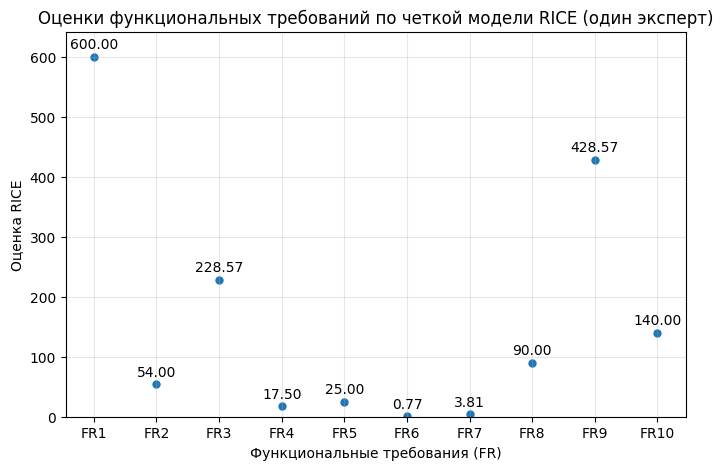

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Берем копию исходной таблицы и восстанавливаем порядок FR по номеру
df_plot = df.copy()

# Сортировка по номеру FR, а не по убыванию оценки
df_plot["FR_num"] = df_plot["Feature"].str.replace("FR", "", regex=False).astype(int)
df_plot = df_plot.sort_values("FR_num").reset_index(drop=True)

# Подписи функциональных требований
fr_labels = df_plot["Feature"].tolist()

# Четкие оценки RICE
scores = df_plot["RICE Score"].tolist()

# Позиции по оси X
x = np.arange(len(fr_labels))

plt.figure(figsize=(8, 5))

# Точки
plt.scatter(x, scores, s=25)

# Подписи значений над точками
offset = max(scores) * 0.015
for i, value in enumerate(scores):
    plt.text(x[i], value + offset, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

# Настройки осей
plt.xticks(x, fr_labels)
plt.xlabel("Функциональные требования (FR)")
plt.ylabel("Оценка RICE")
plt.title("Оценки функциональных требований по четкой модели RICE (один эксперт)")

plt.ylim(0, max(scores) * 1.07)

plt.grid(alpha=0.3)
plt.show()

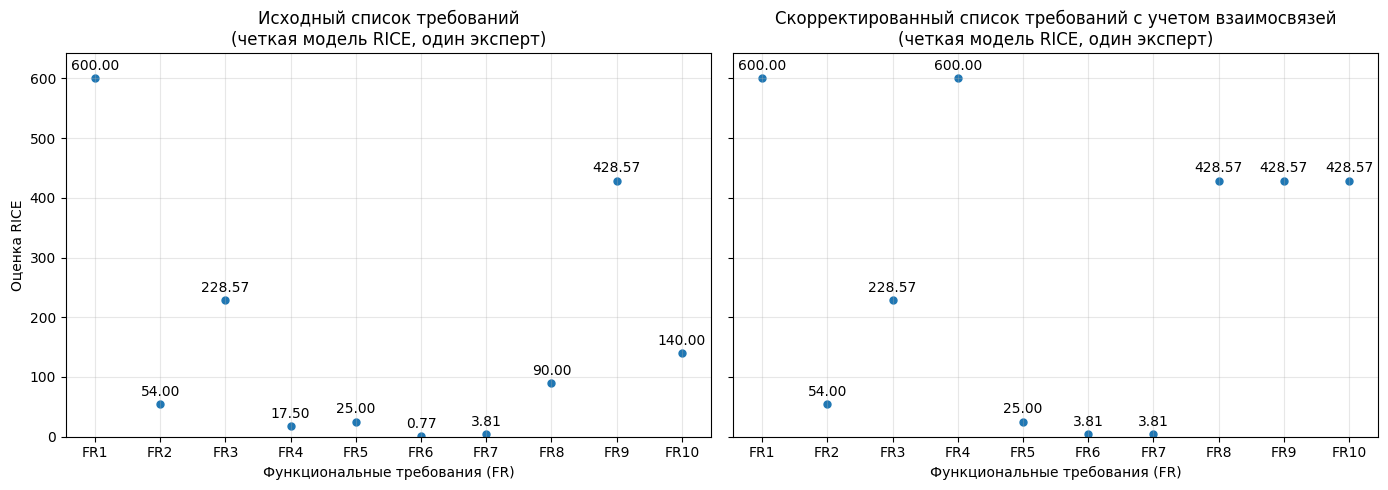

In [301]:
# Копии исходной и скорректированной таблиц с восстановлением порядка FR1...FR10
df_plot = df.copy()
df_adjusted_plot = adjusted_df.copy()

df_plot["FR_num"] = df_plot["Feature"].str.replace("FR", "", regex=False).astype(int)
df_adjusted_plot["FR_num"] = df_adjusted_plot["Feature"].str.replace("FR", "", regex=False).astype(int)

df_plot = df_plot.sort_values("FR_num").reset_index(drop=True)
df_adjusted_plot = df_adjusted_plot.sort_values("FR_num").reset_index(drop=True)

# Подписи функциональных требований
fr_labels = df_plot["Feature"].tolist()

# Исходные и скорректированные оценки RICE
scores = df_plot["RICE Score"].tolist()
adjusted_scores = df_adjusted_plot["Adjusted RICE Score"].tolist()

# Позиции по оси X
x = np.arange(len(fr_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

titles = [
    "Исходный список требований\n(четкая модель RICE, один эксперт)",
    "Скорректированный список требований с учетом взаимосвязей\n(четкая модель RICE, один эксперт)"
]

all_scores = [scores, adjusted_scores]
y_max = max(max(scores), max(adjusted_scores)) * 1.07
offset = max(max(scores), max(adjusted_scores)) * 0.015

for ax, current_scores, title in zip(axes, all_scores, titles):
    # Точки
    ax.scatter(x, current_scores, s=25)

    # Подписи значений над точками
    for i, value in enumerate(current_scores):
        ax.text(x[i], value + offset, f"{value:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(x, fr_labels)
    ax.set_xlabel("Функциональные требования (FR)")
    ax.set_title(title)
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Оценка RICE")

plt.tight_layout()
plt.show()

**Реализация четкой модели RICE для произвольного числа функциональных требований FR (расчет выполнен одним экспертом). Загрузка и выгрузка данных из файла/ в файл**

In [ ]:
# Реализация четкого RICE с датасетом входящих и исходящих параметров

from pathlib import Path
import re
import shutil
import pandas as pd

def _normalize_col(s: str) -> str:
    return " ".join(str(s).strip().lower().split())

def _detect_columns(columns):
    cols_norm = {_normalize_col(c): c for c in columns}
    originals = list(columns)

    synonyms = {
        "Feature": ["feature", "name", "название", "название фичи", "фича", "задача"],
        "R": ["r", "reach", "охват", "reach (r)", "охват (r)"],
        "I": ["i", "impact", "влияние", "impact (i)", "влияние (i)"],
        "C": ["c", "confidence", "уверенность", "confidence (c)", "уверенность (c)"],
        "E": ["e", "effort", "трудозатраты", "трудоемкость", "усилия", "effort (e)", "трудозатраты (e)"],
    }

    detected = {}
    for canonical, syns in synonyms.items():
        found = None

        # 1) точное совпадение по словарю синонимов
        for syn in syns:
            syn_norm = _normalize_col(syn)
            if syn_norm in cols_norm:
                found = cols_norm[syn_norm]
                break

        # 2) поиск по шаблону "(r)" "(i)" "(c)" "(e)"
        if found is None and canonical in ["R", "I", "C", "E"]:
            key = canonical.lower()
            for c in originals:
                cn = _normalize_col(c)
                if re.search(rf"\({key}\)", cn):
                    found = c
                    break

        # 3) поиск по ключевым словам
        if found is None:
            keywords = {
                "Feature": ["fr", "feature", "назван", "задач", "фич"],
                "R": ["reach", "охват"],
                "I": ["impact", "влияни"],
                "C": ["confidence", "уверенн"],
                "E": ["effort", "трудозат", "трудоемк", "усили"],
            }[canonical]
            for c in originals:
                cn = _normalize_col(c)
                if any(k in cn for k in keywords):
                    found = c
                    break

        if found is None:
            raise ValueError(f"Не найдена колонка для '{canonical}'. Доступные колонки: {list(columns)}")

        detected[canonical] = found

    return detected

def compute_rice_from_file(
    input_path: str,
    input_sheet_name: str = "Четкий RICE_эксперт 1",
    output_sheet_name: str = "Итоги_четкий RICE_эксперт 1",
    output_path: str | None = None
) -> pd.DataFrame:
    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Файл не найден: {input_path}")

    if input_path.suffix.lower() not in [".xlsx", ".xls"]:
        raise ValueError("Для такого режима работы нужен Excel-файл .xlsx или .xls")

    # Новый файл-результат
    if output_path is None:
        output_path = input_path.with_name("Итоги_четкий RICE_один эксперт" + input_path.suffix)
    else:
        output_path = Path(output_path)

    # 1) читаем исходный лист
    df = pd.read_excel(input_path, sheet_name=input_sheet_name)

    # 2) определяем и нормализуем названия колонок
    colmap = _detect_columns(df.columns)
    df = df.rename(columns={
        colmap["Feature"]: "Feature",
        colmap["R"]: "R",
        colmap["I"]: "I",
        colmap["C"]: "C",
        colmap["E"]: "E",
    })

    # 3) приводим типы + поддержка десятичной запятой
    for col in ["R", "I", "C", "E"]:
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 4) валидации
    bad = df[df[["Feature", "R", "I", "C", "E"]].isna().any(axis=1)]
    if not bad.empty:
        raise ValueError("Есть строки с пустыми/некорректными значениями:\n" + bad.to_string(index=False))

    if (df["E"] == 0).any():
        raise ValueError("Есть строки с Effort (E) = 0 — деление невозможно.")

    # Если confidence задан в процентах: 60 вместо 0.6
    if (df["C"] > 1).any() and (df["C"] <= 100).all():
        df["C"] = df["C"] / 100.0

    # 5) расчет + ранжирование
    df["RICE"] = (df["R"] * df["I"] * df["C"] / df["E"]).round(2)
    df = df.sort_values("RICE", ascending=False).reset_index(drop=True)
    df.insert(0, "Rank", df.index + 1)

    # 6) создаем новый файл как копию исходного
    shutil.copy2(input_path, output_path)

    # 7) записываем в копию новый лист с итогами
    with pd.ExcelWriter(
        output_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        df.to_excel(writer, sheet_name=output_sheet_name, index=False)

    print(f"Исходный файл не изменен: {input_path}")
    print(f"Результат сохранен в новый файл: {output_path}")
    print(f"В новом файле есть листы: '{input_sheet_name}' и '{output_sheet_name}'")

    return df

df_result = compute_rice_from_file(
    input_path="Загрузочные данные_четкий RICE_один эксперт.xlsx",
    input_sheet_name="Четкий RICE_эксперт 1",
    output_sheet_name="Итоги_четкий RICE_эксперт 1",
    output_path="Итоги_четкий RICE_один эксперт.xlsx"
)

print(df_result)

Исходный файл не изменен: Загрузочные данные_четкий RICE_один эксперт.xlsx
Результат сохранен в новый файл: Итоги_четкий RICE_один эксперт.xlsx
В новом файле есть листы: 'Четкий RICE_эксперт 1' и 'Итоги_четкий RICE_эксперт 1'
   Rank Feature      R     I    C   E    RICE
0     1     FR1  10000  1.00  0.6  10  600.00
1     2     FR9  20000  0.25  0.6   7  428.57
2     3     FR3   1000  2.00  0.8   7  228.57
3     4    FR10    300  2.00  0.7   3  140.00
4     5     FR8   1000  0.50  0.9   5   90.00
5     6     FR2    100  3.00  0.9   5   54.00
6     7     FR5    200  3.00  0.5  12   25.00
7     8     FR4    100  0.50  0.7   2   17.50
8     9     FR7     50  2.00  0.8  21    3.81
9    10     FR6     10  1.00  1.0  13    0.77


# Выводы по расчетной части проекта

# Приложение: функции - основные операции с нечеткими числами

**Умножение двух нечетких трапециевидных чисел 2-го типа**

In [ ]:
def multiply_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для произведения
    z1 = x2 * y1 - x2 * y2 + x1 * y2
    z2 = x2 * y2
    z3 = x3 * y3
    z4 = x3 * y4 - x3 * y3 + y3 * x4

    z5 = x6 * y5 - x6 * y6 + x5 * y6
    z6 = x6 * y6
    z7 = x7 * y7
    z8 = x7 * y8 - x7 * y7 + y7 * x8

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

**Деление одного нечеткого трапециевидного числа 2-го типа на другое нечеткое трапециевидное число 2-го типа**

In [ ]:
def divide_intuitionistic_trapezoidal_fuzzy_numbers(X, Y):
    # Распаковка параметров интервальных трапециевидных чисел 2 типа
    (x1, x2, x3, x4), (x5, x6, x7, x8) = X
    (y1, y2, y3, y4), (y5, y6, y7, y8) = Y

    # Вычисление координат для частного от деления
    z1 = (x2 * y3 - x2 * y4 + x1 * y3) / ((y3)**2)
    z2 = x2 / y3
    z3 = x3 / y2
    z4 = (x3 * y2 - x3 * y1 + x4 * y2) / ((y2)**2)

    z5 = (x6 * y7 - x6 * y8 + x5 * y7) / ((y7)**2)
    z6 = x6 / y7
    z7 = x7 / y6
    z8 = (x7 * y6 - x7 * y5 + x8 * y6) / ((y6)**2)

    return ((z1, z2, z3, z4), (z5, z6, z7, z8))

**Сумма двух нечетких трапециевидных чисел 2-го типа**

In [ ]:
# Функция сложения двух трапециевидных нечетких чисел (интуиционистских или интервальных 2 типа)
def add_intuitionistic_trapezoidal_fuzzy_numbers(fuzzy_number1, fuzzy_number2):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number1
    (y1, y2, y3, y4), (y5, y6, y7, y8) = fuzzy_number2
    return ((round(x1 + y1, 2), round(x2 + y2, 2), round(x3 + y3, 2), round(x4 + y4, 2)),
            (round(x5 + y5, 2), round(x6 + y6, 2), round(x7 + y7, 2), round(x8 + y8, 2)))

**Умножение нечеткого трапециевидного числа 2-го типа на константу**

In [ ]:
# Функция умножения трапециевидного нечеткого числа (интуиционистского или интервального 2 типа) на константу
def multiply_fuzzy_number_by_constant(fuzzy_number, constant):
    # Умножение нечеткого числа на константу
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    if constant < 0:
        # Умножение всех координат на константу в обратном порядке
        new_X = (
            (x4 * constant, x3 * constant, x2 * constant, x1 * constant),
            (x8 * constant, x7 * constant, x6 * constant, x5 * constant)
        )
    else:
        # Умножение всех координат на константу в обычном порядке
        new_X = (
            (x1 * constant, x2 * constant, x3 * constant, x4 * constant),
            (x5 * constant, x6 * constant, x7 * constant, x8 * constant)
        )
    return new_X

**Оператор согласованной линейной редукции типа (CLTR) для дефаззификации трапециевидного НЧ 2-го типа**

In [ ]:
# Функция согласованной линейной редукции типов (CLTR) для интервального нечеткого трапециевидного числа 2-го типа
def cltr_type_reduction(fuzzy_number, a):
    # Проверка параметра a
    if a < 0 or a > 1:
        raise ValueError("Параметр a должен принадлежать интервалу [0, 1].")

    # Распаковка ВФП и НФП
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number

    # Вычисление координат результирующего нечеткого числа 1-го типа
    return (
        round(a * x5 + (1 - a) * x1, 2),
        round(a * x6 + (1 - a) * x2, 2),
        round(a * x7 + (1 - a) * x3, 2),
        round(a * x8 + (1 - a) * x4, 2)
    )


In [ ]:
X = ((1, 2, 4, 5), (1.5, 2, 4, 4.5))

a = 0.6

Y = cltr_type_reduction(X, a)

print("X =", X)
print("a =", a)
print("Y =", Y)

X = ((1, 2, 4, 5), (1.5, 2, 4, 4.5))
a = 0.6
Y = (1.3, 2.0, 4.0, 4.7)


**Округление нечеткого трапециевидного числа 2-го типа**

In [ ]:
# Функция округления параметров трапециевидного нечеткого числа (интуиционистского или интервального 2 типа)
def round_fuzzy_number(fuzzy_number):
    (x1, x2, x3, x4), (x5, x6, x7, x8) = fuzzy_number
    return ((round(x1, 2), round(x2, 2), round(x3, 2), round(x4, 2)),
            (round(x5, 2), round(x6, 2), round(x7, 2), round(x8, 2)))

**Вычисление границ альфа-среза для нечеткого трапециевидного числа 1-го типа**

In [ ]:
# Функция для вычисления альфа-среза
def alpha_cut(fuzzy_number, alpha):
    # Распаковка параметров нечеткого числа
    (x1, x2, x3, x4) = fuzzy_number

    # Вычисление концов интервала альфа-среза
    start = alpha * x2 + (1 - alpha) * x1
    end = alpha * x3 + (1 - alpha) * x4

    # Округляем значения до 2 знаков после запятой
    start = round(start, 2)
    end = round(end, 2)

    # Возвращаем альфа-срез в виде четкого интервала
    return (start, end)

**Нахождение центроида системы из двух точек**

In [ ]:
# Функция вычисления центроида системы двух точек
def centroid(alpha_cut_result):
    # Распаковка верхнего и нижнего отрезков альфа-среза
    (start, end) = alpha_cut_result

    # Расчет среднего значения
    central = round((start + end) / 2, 2)

    # Возвращаем результат в нужном формате
    return central